# **Análisis exploratorio de factores asociados con la edad de inicio de la enfermedad de Alzheimer en una cohorte del Atlántico**

## **Objetivo general**

Caracterizar de manera integral la cohorte de pacientes con enfermedad de Alzheimer del Atlántico y explorar la relación entre sus características sociodemográficas, clínicas y neuropsicológicas y la **edad de inicio de la enfermedad (AOO, *Age of Onset*)**, con el propósito de identificar variables potencialmente asociadas con un inicio más temprano o más tardío y establecer una base analítica rigurosa para la posterior incorporación de información genética.

El análisis busca, además, evaluar la calidad, completitud, consistencia, distribución y redundancia de las variables disponibles antes de avanzar hacia análisis multivariados y estudios de asociación genética.

## **Pregunta orientadora**

> **¿Qué características sociodemográficas, clínicas y neuropsicológicas presentan asociación con una edad de inicio más temprana o más tardía de la enfermedad de Alzheimer en la cohorte estudiada?**

Esta pregunta constituye la etapa clínica y exploratoria del estudio. En una fase posterior se incorporarán las variantes genéticas con el propósito de evaluar su posible papel como modificadores de la edad de inicio.

## **Fuentes de información**

El análisis integra tres fuentes de datos complementarias:

- `hxgen.xlsx`: información clínica, antecedentes, hábitos, historia familiar y variables relacionadas con la reconstrucción del perfil clínico-genético.
- `neuropsicologia-casos.xlsx`: información sociodemográfica, clínica y resultados de pruebas neuropsicológicas, incluyendo las variables utilizadas para reconstruir la edad de inicio.
- `moca.xlsx`: resultados de la prueba Montreal Cognitive Assessment (MoCA).

La población de referencia del análisis corresponde a **391 pacientes con historia clínico-genética reconstruida**, definidos a partir de `hxgen.xlsx`.

## **Decisiones metodológicas**

- **Cohorte maestra.** `hxgen.xlsx` se utiliza como fuente maestra debido a que contiene los 391 pacientes con perfil clínico-genético reconstruido que delimitan la cohorte de interés. Las demás fuentes se integran sobre estos pacientes sin ampliar artificialmente la población de estudio.

- **Integración de las fuentes.** La información de `neuropsicologia-casos.xlsx` y `moca.xlsx` se incorpora mediante el identificador del paciente, preservando los 391 individuos de la cohorte maestra. La disponibilidad de información complementaria puede variar entre pacientes, por lo que se documenta el tamaño efectivo de muestra utilizado en cada análisis.

- **Variable principal de estudio.** La **edad de inicio de la enfermedad de Alzheimer (AOO)** constituye la variable de respuesta principal. Se construye de manera trazable a partir de las variables de edad de inicio disponibles en la fuente neuropsicológica, utilizando la edad de inicio original como primera fuente y la edad de inicio actualizada únicamente cuando la primera no se encuentra disponible.

- **Valores faltantes de AOO.** Los pacientes sin una edad de inicio documentada se conservan dentro de la cohorte para la caracterización general, pero se excluyen únicamente de los análisis que requieren AOO. **La edad de inicio no se imputa**, debido a que constituye el desenlace principal de la investigación y su estimación artificial podría introducir sesgos en los análisis posteriores.

- **Dos conjuntos analíticos.**
  - `base_full`: contiene la cohorte completa de 391 pacientes y se utiliza para describir las características generales de la población y evaluar la calidad de los datos.
  - `base_aoo`: contiene temporalmente a los pacientes con AOO disponible y se utiliza para los análisis de asociación con la edad de inicio.

- **Datos faltantes en covariables.** Durante el EDA se cuantifica y caracteriza la ausencia de información, pero no se realiza imputación definitiva de covariables. Si posteriormente se desarrolla un modelo predictivo o multivariado que requiera imputación, sus parámetros deberán estimarse exclusivamente a partir de los datos de entrenamiento para evitar *data leakage*.

- **Variables neuropsicológicas.** El conjunto completo de pruebas neuropsicológicas se examina inicialmente para evaluar completitud, variabilidad, distribución y redundancia. Debido al elevado número de medidas y a la correlación entre pruebas que evalúan dominios similares, se realiza una reducción justificada evitando incorporar información redundante.

- **Variables neuropsicológicas prioritarias.** MMSE, MoCA y FAST se conservan como indicadores clínicos de especial interés para la caracterización cognitiva y funcional. Otras pruebas pueden seleccionarse como representantes de dominios neuropsicológicos cuando presenten adecuada calidad, variabilidad, relevancia clínica y baja redundancia.

- **Temporalidad y riesgo de `data leakage`.** Varias variables clínicas y neuropsicológicas pudieron haber sido medidas después del inicio de la enfermedad. Por esta razón, una asociación con AOO no implica necesariamente que la variable haya precedido o modificado el inicio de la enfermedad. El riesgo de temporalidad se documenta explícitamente y condiciona la interpretación de los resultados.

- **Análisis de asociación.** Los análisis bivariados se realizan utilizando los casos con información disponible para cada par de variables, sin imputar AOO. Se emplean métodos estadísticos acordes con la naturaleza y distribución de cada variable y se controla el problema de comparaciones múltiples cuando se evalúan numerosas asociaciones simultáneamente.

- **Alcance exploratorio.** Los resultados obtenidos en esta etapa representan asociaciones estadísticas y patrones descriptivos de la cohorte. **No se interpretan como relaciones causales ni como evidencia definitiva de factores protectores o de riesgo.**

- **Proyección genética.** Esta etapa constituye la preparación clínica y fenotípica para el análisis genético posterior. Una vez incorporada y sometida a control de calidad la información de variantes genéticas, se evaluará su asociación con AOO con el objetivo de identificar posibles modificadores genéticos relacionados con un inicio más temprano o más tardío de la enfermedad.

## **1. Preparación del entorno**

In [4]:
#%pip install pandas numpy matplotlib scipy statsmodels scikit-learn openpyxl

from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import openpyxl

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Para los gráficos
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


## **2. Carga de archivos**

In [5]:
DATA_DIR = Path(".")

PATH_NEURO = DATA_DIR / "neuropsicologia-casos.xlsx"
PATH_MOCA  = DATA_DIR / "moca.xlsx"
PATH_HXGEN = DATA_DIR / "hxgen.xlsx"

In [6]:
df_neuro_raw = pd.read_excel(PATH_NEURO)
df_moca_raw  = pd.read_excel(PATH_MOCA)
df_hxgen_raw = pd.read_excel(PATH_HXGEN)

print("Archivos cargados.")

Archivos cargados.


## **3. Reconocimiento inicial de cada fuente**

Antes de limpiar, transformar o unir, revisemos:
- `shape`
- `head`
- `tail`
- `columns`
- `info`
- tipos de datos
- cardinalidad

In [7]:
def inspeccion_inicial(df, nombre):
    print("=" * 90)
    print(nombre)
    print("=" * 90)
    print("Shape:", df.shape)

    print("\nHEAD:")
    display(df.head())

    print("\nTAIL:")
    display(df.tail())

    print("\nCOLUMNAS:")
    for i, c in enumerate(df.columns, 1):
        print(f"{i:03d}. {repr(c)}")

    print("\nINFO:")
    df.info()

    print("\nVALORES ÚNICOS:")
    display(df.nunique(dropna=False).sort_values().to_frame("n_unicos").head())

inspeccion_inicial(df_neuro_raw, "NEUROPSICOLOGÍA")

NEUROPSICOLOGÍA
Shape: (399, 123)

HEAD:


,CODIGO,genero,Dx,mes y año de nacimiento,EDAD,IDIOMA,OTRO IDOMA,Nivel educativo,Estado civil,Estado Habitacional,Nivel de independencia,Tipo de residencia,Lateralidad,Relación del Informante,Tiempo (años de conocerce),¿Vive el informante con el sujeto?,"Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?","Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?","¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)?",Familiar afectado,Edad de inicio,Edad de inicio actualizada,Peso,Talla,MEDICAMENTO DEL SUJETO 1,MEDICAMENTO DEL SUJETO 2,MEDICAMENTO DEL SUJETO 3,MEDICAMENTO DEL SUJETO 4,MEDICAMENTO DEL SUJETO 5,MEDICAMENTO DEL SUJETO 6,MEDICAMENTO DEL SUJETO 7,MEDICAMENTO DEL SUJETO 8,MEDICAMENTO DEL SUJETO 9,El sujeto ha fumado en los pasados 30 días,¿El sujeto ha fumado más de 100 cigarros / cigarrillos\n en su vida?,Número total de años que ha fumado el sujeto (99 = desconocido):,Ataque cardiaco o paro cardíaco,Fibrilación auricular,Angioplastía/ endarterectomía/ stent,Bypass cardíaco/coronario,Marcapasos y/o desfibrilador,Insuficiencia cardíaca congestiva,ENFERMEDAD CEREBRO-VASCULAR (ECV),PARKINSON,CONVULSIONES,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),DIABETES,CANCER,Hipercholesterolemia,Hipertensión arterial,NIVELES DE VITAMINA D,Deficiencia de B12,Enfermedad tiroidea,Artritis,Artrosis,Osteoporosis,Incontinencia — urinaria,Incontinencia — fecal,Apnea del sueño U OTRO,Trastorno de estrés postraumático (TEPT),Trastorno bipolar,Esquizofrenia,Depresión,Ansiedad,Trastorno obsesivo-compulsivo (TOC),"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",Estudio Cerebral Electroencefalograma (EEG),¿Hay valoración NPS anterior?,Si tiene anteriormente valoración NPS ¿en que fecha se aplico?,MMSE,CMWESCHLER,FVSa,Perdida Categoria FVSA,Perseveraciones FVSA,FVSc,Perdida Categoria FVSC,Perseveraciones FVSC,FVFf,Perdida Categoria FVFf,Perseveraciones FVFf,FVFa,Perdida Categoria FVFa,Perseveraciones FVFa,FVFs,Perdida Categoria FVFs,Perseveraciones FVFs,FCROCOP,FCROEVO,TOKEN,TAAVREY1,TAAVREY2,TAAVREY3,TAAVREY4,TAAVREY5,TAAVREYB1,TAAVREY6,TAAVREY7,TAAVREY REC si,TAAVREY REC no,TBN espontanea,TBN semántica,TBN total,TSPAL,TSCOL,TSPALCOL,TMTA,TMTB,TSMYDORAL,TSMYD ESCR,TEAC,BENTON,RELOJ,TWISCAT,TWISENP,TWISEP,TWISCORRESCTAS,QUEJAS SUBJETIVAS,YESAVAGE,BARTHEL,LAWTON Y BRODY,IKATZ,FAST,ESC DETERIOROGLOBAL
0,16,1,1,1961-07-02 00:00:00,61,2,2,5.0,2,3,2.0,1.0,2,2,30,1,-,-,0,0,59 AÑOS,0,78,1.7,NEBOPURIXINA,-,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,6,-,2,0,0,4,0,0,1,0,0,0,2,0,2,1,0,0,0,-,0,1,1,1,0,0,0,0,0,15,11,2,13,-,-,-,-,-,-,-,-,0,-,-,-,-,-,3,16,0,3,4,4,4.0
1,17,1,1,1950-04-13 00:00:00,72,2,2,5.0,7,7,1.0,1.0,2,2,35,1,-,-,0,0,70 AÑOS,0,56,1.58,-,-,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,30,8,4,0,0,9,0,0,9,0,0,6,0,0,3,2,0,18,8,30,2,5,6,7,11,5,7,6,14,13,37,0,37,51,41,13,179,300,7,6,16,3,4,2,33,36,59,0,0,50,0,0,3,3.0
2,18,1,1,1951-03-01 00:00:00,71,2,2,12.0,1,3,2.0,1.0,2,1,40,1,-,-,1,1 Y 2,67 AÑOS,0,65,1.66,MEMANTINA,-,-,-,-,-,-,-,-,0,1,20 AÑOS,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,3,-,1,0,0,0,0,0,-,-,-,-,-,-,-,-,-,0,0,7,0,0,0,0,2,1,0,0,12,3,1,0,1,-,-,-,-,-,-,-,-,-,-,0,42,6,0,3,16,0,3,6,4,4.0
3,19,1,1,1947-02-14 00:00:00,76,2,2,12.0,1,7,2.0,1.0,2,2,40,1,-,-,0,0,72 AÑOS,0,52,1.67,ALODIPINA,-,-,-,-,-,-,-,-,0,1,15 AÑOS,0,0.0,0,0,0,0.0,0.0,0.0,0,0,1,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,12,0,2,0,0,1,0,0,-,-,-,-,-,-,-,-,-,0,-,2,1,2,2,2,2,1,0,0,-,-,15,0,15,-,-,-,-,-,-,-,-,-,-,-,-,-,-,3,16,0,3,6,4,6.0
4,20,1,1,1933-03-27 00:00:00,89,2,2,5.0,2,5,1.0,1.0,2,2,49,1,-,-,0,0,NaN,83,40,1.5,LOSARTAN,METROP


TAIL:


,CODIGO,genero,Dx,mes y año de nacimiento,EDAD,IDIOMA,OTRO IDOMA,Nivel educativo,Estado civil,Estado Habitacional,Nivel de independencia,Tipo de residencia,Lateralidad,Relación del Informante,Tiempo (años de conocerce),¿Vive el informante con el sujeto?,"Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?","Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?","¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)?",Familiar afectado,Edad de inicio,Edad de inicio actualizada,Peso,Talla,MEDICAMENTO DEL SUJETO 1,MEDICAMENTO DEL SUJETO 2,MEDICAMENTO DEL SUJETO 3,MEDICAMENTO DEL SUJETO 4,MEDICAMENTO DEL SUJETO 5,MEDICAMENTO DEL SUJETO 6,MEDICAMENTO DEL SUJETO 7,MEDICAMENTO DEL SUJETO 8,MEDICAMENTO DEL SUJETO 9,El sujeto ha fumado en los pasados 30 días,¿El sujeto ha fumado más de 100 cigarros / cigarrillos\n en su vida?,Número total de años que ha fumado el sujeto (99 = desconocido):,Ataque cardiaco o paro cardíaco,Fibrilación auricular,Angioplastía/ endarterectomía/ stent,Bypass cardíaco/coronario,Marcapasos y/o desfibrilador,Insuficiencia cardíaca congestiva,ENFERMEDAD CEREBRO-VASCULAR (ECV),PARKINSON,CONVULSIONES,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),DIABETES,CANCER,Hipercholesterolemia,Hipertensión arterial,NIVELES DE VITAMINA D,Deficiencia de B12,Enfermedad tiroidea,Artritis,Artrosis,Osteoporosis,Incontinencia — urinaria,Incontinencia — fecal,Apnea del sueño U OTRO,Trastorno de estrés postraumático (TEPT),Trastorno bipolar,Esquizofrenia,Depresión,Ansiedad,Trastorno obsesivo-compulsivo (TOC),"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",Estudio Cerebral Electroencefalograma (EEG),¿Hay valoración NPS anterior?,Si tiene anteriormente valoración NPS ¿en que fecha se aplico?,MMSE,CMWESCHLER,FVSa,Perdida Categoria FVSA,Perseveraciones FVSA,FVSc,Perdida Categoria FVSC,Perseveraciones FVSC,FVFf,Perdida Categoria FVFf,Perseveraciones FVFf,FVFa,Perdida Categoria FVFa,Perseveraciones FVFa,FVFs,Perdida Categoria FVFs,Perseveraciones FVFs,FCROCOP,FCROEVO,TOKEN,TAAVREY1,TAAVREY2,TAAVREY3,TAAVREY4,TAAVREY5,TAAVREYB1,TAAVREY6,TAAVREY7,TAAVREY REC si,TAAVREY REC no,TBN espontanea,TBN semántica,TBN total,TSPAL,TSCOL,TSPALCOL,TMTA,TMTB,TSMYDORAL,TSMYD ESCR,TEAC,BENTON,RELOJ,TWISCAT,TWISENP,TWISEP,TWISCORRESCTAS,QUEJAS SUBJETIVAS,YESAVAGE,BARTHEL,LAWTON Y BRODY,IKATZ,FAST,ESC DETERIOROGLOBAL
394,785,1,1,1937-12-08 00:00:00,86,2,2,5.0,1,5,4.0,1.0,2,2,-,1,1,1,0,-,80,0,65,162,METOPROLOL,ESCITALOPRAM,FUROCEMIDA,ATORVASTATINA,LEVOTIROXINA,CLOPIDOGREL,VALSARTAN,VASTAREL,-,0,0,0,1,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,25,0,4,0,0,6,0,0,3,0,0,0,0,0,1,0,0,0,0,14,2,4,5,3,6,2,1,1,12,10,36,3,39,42,28,10,0,0,0,0,0,0,0,2,3,32,13,2,6,20,3,4,4,4.0
395,786,0,1,1937-07-09 00:00:00,87,2,2,5.0,1,5,2.0,1.0,2,2,-,1,1,1,1,2,86,0,70,170,FUROSEMIDA,VASTAREL-SACUBITRIL,ACIDO ACETILSALICILICO,TAMSULOSINA,ESTALAN,ENTRESTO,BETALOC,EPNONE,FORXIGA,0,0,0,1,0.0,0,0,0,0.0,0.0,0.0,0,0,1,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,25,0,8,0,0,11,0,0,9,0,0,5,0,0,6,0,0,26,1,25,3,2,4,4,5,2,0,0,9,11,27,6,33,59,42,24,"124""",0,0,0,16,2,10,4,10,9,29,2,7,50,1,0,3,4.0
396,787,0,1,10/0571958,66,2,2,12.0,5,5,1.0,1.0,2,6,-,-,-,-,1,4,66,0,70,172,-,-,-,-,-,-,-,-,-,1,1,9,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,30,5,9,0,0,9,0,0,5,0,0,5,0,0,5,0,0,31,10,34,5,4,5,5,8,3,4,4,7,14,35,2,37,66,52,25,"112""",0,23,20,16,6,10,1,14,20,14,0,3,50,0,0,3,4.0
397,788,0,1,1936-05-17 00:00:00,88,2,2,16.0,1,2,4.0,1.0,2,4,-,1,1,1,0,-,72,0,78,170,QUETIAPINA,MEMANTINA,AVODART,DEFAL,DONEPEZILO,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,


COLUMNAS:
001. 'CODIGO'
002. 'genero'
003. 'Dx'
004. 'mes y año de nacimiento'
005. 'EDAD'
006. 'IDIOMA'
007. 'OTRO IDOMA '
008. 'Nivel educativo'
009. 'Estado civil '
010. 'Estado Habitacional'
011. 'Nivel de independencia'
012. 'Tipo de residencia '
013. 'Lateralidad'
014. 'Relación del Informante'
015. 'Tiempo (años de conocerce)'
016. '¿Vive el informante con el sujeto?'
017. 'Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?'
018. 'Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?'
019. '¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)? '
020. 'Familiar afectado'
021. 'Edad de inicio'
022. 'Edad de inicio actualizada'
023. 'Peso'
024. 'Talla'
025. 'MEDICAMENTO DEL SUJETO 1'
026. 'MEDICAMENTO DEL SUJETO 2'
027. 'MEDICAMENTO DEL SUJETO 3'
028. 'MEDICAMENTO DEL SUJETO 4'
029. 'MEDICAMENTO DEL SUJETO 5'
030. 'M

,n_unicos
Dx,1
IDIOMA,1
Bypass cardíaco/coronario,1
Trastorno bipolar,1
NIVELES DE VITAMINA D,1


In [8]:
inspeccion_inicial(df_moca_raw, "MOCA")

MOCA
Shape: (791, 2)

HEAD:


,CODIGO,MoCA
0,1,26
1,2,28
2,3,26
3,4,26
4,5,27



TAIL:


,CODIGO,MoCA
786,796,26
787,797,29
788,798,23
789,799,24
790,800,22



COLUMNAS:
001. 'CODIGO'
002. 'MoCA'

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   CODIGO  791 non-null    int64 
 1   MoCA    790 non-null    object
dtypes: int64(1), object(1)
memory usage: 12.5+ KB

VALORES ÚNICOS:


,n_unicos
MoCA,33
CODIGO,790


In [9]:
inspeccion_inicial(df_hxgen_raw, "HXGEN")

HXGEN
Shape: (391, 24)

HEAD:


,Código,Edad,Ciudad o municipio de residencia,Enfermedad actual,¿Qué síntomas presenta? \n,El Paciente necesita apoyo para realizar las siguientes tareas,Indique que estudios previos le han realizado.,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",Antecedentes,¿Actualmente se encuentra en algún tratamiento farmacológico?,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",¿Usted fuma?,"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",¿Con que frecuencia consume alcohol?,¿Le han realizado algún procedimiento quirúrgico?,Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?,¿En que fecha le realizaron la cirugía?,¿Sufre de algún tipo de alergia?,Si la respuesta anterior es SI. ¿A que es alérgico?,Peso en Kilogramo,Altura en centímetro,¿Alguien más en su familia tiene o tuvo Alzheimer?,Si la respuesta anterior es afirmativa. ¿Cuántas personas han tenido o tienen Alzheimer en su familia ?,¿Qué parentesco tienen con usted?
0,16,61,Barranquilla,Demencia,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;,Electroencefalograma (EEG);Resonancia magnética (RM);,Debilitamiento en la membrana del cerebro,Diabetes ;,SI,Quetiapina y memantina,NO,NaN,Nunca,SI,Histerectomía,1996-07-18 00:00:00,SI,Atópica,75,160,NO,NaN,NaN
1,17,71,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Falla en orientación temporal;Fallo...",No aplica;,Tomografía computarizada (TAC);,Quistes,Hipertensión ;Artrosis;,SI,"Micardio, anlodipino",NO,NaN,Nunca,NO,NaN,NaN,NO,NaN,70,62,SI,2,Mamá y tio abuelo
2,18,66,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;,Resonancia magnética (RM);Electroencefalograma (EEG);,Esperando resultados,No aplica;,SI,"Memantina, clozapina, efexor",NO,Fumadora pasiva,Nunca,SI,Histerectomía,NaN,NO,NaN,56,167,SI,5,"Papá, prima, tios y hermanos"
3,19,74,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;Comer ;,Tomografía computarizada (TAC);,"Atrofia cerebral, diminución del cerebro",Falla Renal ;Diabetes ;Hipertensión ;,SI,"Anlodipino, iirbesartan, acido fólico, atorvastatina asa",NO,Fumo 10 alos,Ocasionalmente (Una vez por semestre),SI,"Cesarea, histerectomía",NaN,SI,"Tramadol, clonidina",48,167,SI,1,Tia abuela
4,20,89,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Falla en orientación temporal;Pregu...",N/A;,Electroencefalograma (EEG);,NaN,Hipertensión ;Insuficiencia renal Et 4;,SI,"Metoprolol, amlodipino, furosemida",NO,NaN,Nunca,SI,Colecistectomía,2001-06-06 00:00:00,NO,NaN,42,148,NO,NaN,NaN



TAIL:


,Código,Edad,Ciudad o municipio de residencia,Enfermedad actual,¿Qué síntomas presenta? \n,El Paciente necesita apoyo para realizar las siguientes tareas,Indique que estudios previos le han realizado.,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",Antecedentes,¿Actualmente se encuentra en algún tratamiento farmacológico?,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",¿Usted fuma?,"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",¿Con que frecuencia consume alcohol?,¿Le han realizado algún procedimiento quirúrgico?,Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?,¿En que fecha le realizaron la cirugía?,¿Sufre de algún tipo de alergia?,Si la respuesta anterior es SI. ¿A que es alérgico?,Peso en Kilogramo,Altura en centímetro,¿Alguien más en su familia tiene o tuvo Alzheimer?,Si la respuesta anterior es afirmativa. ¿Cuántas personas han tenido o tienen Alzheimer en su familia ?,¿Qué parentesco tienen con usted?
386,785,86,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial; falla en orientación temporal","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,"Paro cardiaco, Enfermedad Cerebrovascular, hipertensión",Sí,"Furocemida, METOPROLOL, levotiroxina, ESCITALOPRAM, ATORVASTATINA, vastarel, valsartran, CLOPIDOGREL",No,NaN,Nunca,No,NaN,NaN,No,NaN,65,162,No,NaN,NaN
387,786,87,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,"Paro cardiaco, hipertensión, diabetes",Si,"furocemida, VASTAREL-SACUBITRIL, ácido acetilsalicílico, estalan, betaloc, TAMSULOSINA, Epnone, ENTRESTO",No,NaN,Nunca,No,NaN,NaN,No,NaN,70,170,Sí,1,Hermano
388,787,66,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,NaN,No,NaN,No,NaN,Nunca,No,NaN,NaN,No,NaN,70,172,Sí,1,Tío
389,788,88,MAGDALENA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,Hipertensión,Sí,"Quetiapina, memantina, defal, AVODART, DONEPEZILO",No,NaN,Nunca,No,NaN,NaN,No,NaN,78,170,No,NaN,NaN
390,789,71,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial; falla en orientación temporal","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,Hipertensión,S{i,Losartan,No,NaN,Nunca,No,NaN,NaN,No,NaN,-,160,No,NaN,NaN



COLUMNAS:
001. 'Código'
002. 'Edad\xa0'
003. 'Ciudad o municipio de residencia\xa0'
004. 'Enfermedad actual\xa0'
005. '¿Qué síntomas presenta?\xa0\n'
006. 'El Paciente necesita apoyo para realizar las siguientes tareas\xa0'
007. 'Indique que estudios previos le han realizado.'
008. 'Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?'
009. 'Antecedentes\xa0'
010. '¿Actualmente se encuentra en algún tratamiento farmacológico?\xa0'
011. 'Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?'
012. '¿Usted fuma?'
013. 'Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?\xa0'
014. '¿Con que frecuencia consume alcohol?\xa0'
015. '¿Le han realizado algún procedimiento quirúrgico?'
016. 'Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?\xa0'
017. '¿En que fecha le realizaron la cirugía?\xa0'
018. '¿Sufre de algún tipo de alergia?\xa0'
019. 'Si la respuesta anterior es SI. ¿A que es alérgico?\xa0'
020. 'Peso en Kilogramo'
021. 'Altura 

,n_unicos
¿Usted fuma?,3
¿Sufre de algún tipo de alergia?,3
¿Le han realizado algún procedimiento quirúrgico?,4
Enfermedad actual,6
¿Alguien más en su familia tiene o tuvo Alzheimer?,8



**Nota de la inspección:** las columnas `Edad de inicio` y `Edad de inicio actualizada` (la variable AOO) se encuentran en `neuropsicologia-casos.xlsx`, no en `hxgen.xlsx`. `hxgen.xlsx` sí sigue siendo la cohorte maestra (391 pacientes con historia clínico-genética reconstruida), pero la variable AOO debe traerse desde `neuropsicologia-casos.xlsx` en el merge. 


## **4. Clasificación explícita de variables**

In [10]:
VARIABLES_DEMO_SOCIALES_ORIG = [
    "CODIGO",
    "genero",
    "Dx",
    "mes y año de nacimiento",
    "EDAD",
    "IDIOMA",
    "OTRO IDOMA ",
    "Nivel educativo",
    "Estado   civil ",
    "Estado   Habitacional",
    "Nivel de   independencia",
    "Tipo de   residencia ",
    "Lateralidad",
    "Relación del   Informante",
    "Tiempo (años de   conocerce)",
    "¿Vive el   informante con el sujeto?",
    "Si el   informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",
    "Si el   informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?",
    "¿Hay miembros   afectados de la familia (padres biológicos, hermanos consanguíneos completos   (comparten ambos padres), o hijos biológicos)? ",
    "Familiar   afectado",
    "Edad de inicio",
    "Edad de inicio   actualizada",
    "Peso",
    "Talla",
    "MEDICAMENTO DEL   SUJETO 1",
    "MEDICAMENTO DEL   SUJETO 2",
    "MEDICAMENTO DEL   SUJETO 3",
    "MEDICAMENTO DEL   SUJETO 4",
    "MEDICAMENTO DEL   SUJETO 5",
    "MEDICAMENTO DEL   SUJETO 6",
    "MEDICAMENTO DEL   SUJETO 7",
    "MEDICAMENTO DEL   SUJETO 8",
    "MEDICAMENTO DEL   SUJETO 9",
    "El sujeto ha   fumado en los pasados 30 días",
    "¿El sujeto ha   fumado más de 100 cigarros / cigarrillos en su vida?",
    "Número total de   años que ha fumado el sujeto (99 = desconocido): ",
    "Ataque cardiaco   o paro cardíaco",
    "Fibrilación   auricular",
    "Angioplastía/   endarterectomía/ stent",
    "Bypass   cardíaco/coronario",
    "Marcapasos y/o   desfibrilador",
    " Insuficiencia cardíaca congestiva",
    "ENFERMEDAD   CEREBRO-VASCULAR (ECV)",
    "PARKINSON",
    "CONVULSIONES",
    "TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE)",
    "DIABETES",
    "CANCER",
    "Hipercholesterolemia",
    "Hipertensión   arterial",
    "NIVELES DE   VITAMINA D",
    "Deficiencia de   B12",
    "Enfermedad   tiroidea",
    "Artritis",
    "Artrosis",
    "Osteoporosis",
    "Incontinencia — urinaria",
    "Incontinencia — fecal",
    "Apnea del sueño   U OTRO",
    "Trastorno de   estrés postraumático (TEPT)",
    "Trastorno bipolar",
    "Esquizofrenia",
    "Depresión",
    "Ansiedad",
    "Trastorno obsesivo-compulsivo (TOC)",
    "Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro   autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",
    "Estudio Cerebral Electroencefalograma (EEG)"
]

In [11]:
VARIABLES_NEUROPSICOLOGICAS_ORIG = [
    "¿Hay valoración NPS anterior?",
    "Si tiene anteriormente  valoración NPS ¿en que fecha se aplico?",
    "MMSE",
    "CMWESCHLER",
    "FVSa",
    "Perdida Categoria FVSA",
    "Perseveraciones FVSA",
    "FVSc",
    "Perdida Categoria FVSC",
    "Perseveraciones FVSC",
    "FVFf",
    "Perdida Categoria FVFf",
    "Perseveraciones FVFf",
    "FVFa",
    "Perdida Categoria FVFa",
    "Perseveraciones FVFa",
    "FVFs",
    "Perdida Categoria FVFs",
    "Perseveraciones FVFs",
    "FCROCOP",
    "FCROEVO",
    "TOKEN",
    "TAAVREY1",
    "TAAVREY2",
    "TAAVREY3",
    "TAAVREY4",
    "TAAVREY5",
    "TAAVREYB1",
    "TAAVREY6",
    "TAAVREY7",
    "TAAVREY REC si",
    "TAAVREY REC no",
    "TBN espontanea",
    "TBN semántica",
    "TBN total",
    "TSPAL",
    "TSCOL",
    "TSPALCOL",
    "TMTA",
    "TMTB",
    "TSMYDORAL",
    "TSMYD ESCR",
    "TEAC",
    "BENTON",
    "RELOJ",
    "TWISCAT",
    "TWISENP",
    "TWISEP",
    "TWISCORRESCTAS",
    "QUEJAS   SUBJETIVAS",
    "YESAVAGE",
    "BARTHEL",
    "LAWTON Y BRODY",
    "IKATZ",
    "FAST",
    "ESC DETERIOROGLOBAL"
]

### **4.1 Subgrupos conceptuales**

Las variables se organizan por familias para facilitar el EDA.

In [12]:
GRUPOS_DEMO = {
    "identificacion_diagnostico": [
        "CODIGO", "Dx"
    ],
    "sociodemograficas": [
        "genero", "mes y año de nacimiento", "EDAD", "IDIOMA", "OTRO IDOMA ",
        "Nivel educativo", "Estado   civil ", "Estado   Habitacional",
        "Nivel de   independencia", "Tipo de   residencia ", "Lateralidad"
    ],
    "informante_red_apoyo": [
        "Relación del   Informante",
        "Tiempo (años de   conocerce)",
        "¿Vive el   informante con el sujeto?",
        "Si el   informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",
        "Si el   informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?"
    ],
    "historia_familiar": [
        "¿Hay miembros   afectados de la familia (padres biológicos, hermanos consanguíneos completos(comparten ambos padres), o hijos biológicos)? ",
        "Familiar   afectado"
    ],
    "outcome_aoo": [
        "Edad de inicio", "Edad de inicio   actualizada"
    ],
    "antropometria": [
        "Peso", "Talla"
    ],
    "medicamentos": [
        f"MEDICAMENTO DEL   SUJETO {i}" for i in range(1, 10)
    ],
    "tabaquismo": [
        "El sujeto ha   fumado en los pasados 30 días",
        "¿El sujeto ha   fumado más de 100 cigarros / cigarrillos en su vida?",
        "Número total de   años que ha fumado el sujeto (99 = desconocido): "
    ],
    "cardiovasculares_cerebrovasculares": [
        "Ataque cardiaco   o paro cardíaco",
        "Fibrilación   auricular",
        "Angioplastía/   endarterectomía/ stent",
        "Bypass   cardíaco/coronario",
        "Marcapasos y/o   desfibrilador",
        " Insuficiencia cardíaca congestiva",
        "ENFERMEDAD   CEREBRO-VASCULAR (ECV)"
    ],
    "neurologicos": [
        "PARKINSON", "CONVULSIONES",
        "TRAUMATISMO DE   CRÁNEO-ENCEFÁLICO (TCE)"
    ],
    "metabolicos_otros": [
        "DIABETES", "CANCER", "Hipercholesterolemia",
        "Hipertensión   arterial", "NIVELES DE   VITAMINA D",
        "Deficiencia de   B12", "Enfermedad   tiroidea",
        "Artritis", "Artrosis", "Osteoporosis",
        "Incontinencia —   urinaria", "Incontinencia —   fecal",
        "Apnea del sueño   U OTRO"
    ],
    "psiquiatricos": [
        "Trastorno de   estrés postraumático (TEPT)",
        "Trastorno   bipolar", "Esquizofrenia", "Depresión",
        "Ansiedad", "Trastorno   obsesivo-compulsivo (TOC)",
        "Trastornos   neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro   autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)"
    ],
    "estudios_complementarios": [
        "Estudio Cerebral   Electroencefalograma (EEG)"
    ]
}

In [13]:
GRUPOS_NEURO = {
    "metadatos_nps": [
        "¿Hay   valoración NPS anterior?",
        "Si tiene   anteriormente  valoración NPS  ¿en que fecha se aplico?"
    ],
    "cognicion_global": [
        "MMSE", "ESC   DETERIOROGLOBAL"
    ],
    "memoria": [
        "CMWESCHLER",
        "TAAVREY1", "TAAVREY2", "TAAVREY3", "TAAVREY4", "TAAVREY5",
        "TAAVREYB1", "TAAVREY6", "TAAVREY7",
        "TAAVREY REC si", "TAAVREY REC no"
    ],
    "fluidez_verbal": [
        "FVSa", "Perdida   Categoria FVSA", "Perseveraciones   FVSA",
        "FVSc", "Perdida   Categoria FVSC", "Perseveraciones   FVSC",
        "FVFf", "Perdida   Categoria FVFf", "Perseveraciones   FVFf",
        "FVFa", "Perdida   Categoria FVFa", "Perseveraciones   FVFa",
        "FVFs", "Perdida   Categoria FVFs", "Perseveraciones   FVFs"
    ],
    "lenguaje": [
        "TOKEN", "TBN espontanea", "TBN semántica", "TBN total"
    ],
    "praxia_visuoconstruccion": [
        "FCROCOP", "FCROEVO", "RELOJ"
    ],
    "funcion_ejecutiva_atencion": [
        "TSPAL", "TSCOL", "TSPALCOL",
        "TMTA", "TMTB", "TEAC",
        "TWISCAT", "TWISENP", "TWISEP", "TWISCORRESCTAS"
    ],
    "memoria_semantica_conocimiento": [
        "TSMYDORAL", "TSMYD ESCR", "BENTON"
    ],
    "funcional_afectivo_quejas": [
        "QUEJAS   SUBJETIVAS", "YESAVAGE", "BARTHEL",
        "LAWTON Y BRODY", "IKATZ", "FAST"
    ]
}

## **5. Normalización de nombres de columnas**
Objetivo: limpiar espacios/saltos de línea/caracteres invisibles en los nombres de columnas (sin renombrar su significado) y estandarizar la columna identificadora del paciente en las tres bases para permitir el merge.

Justificación: los encabezados originales contienen saltos de línea, espacios no separables (`\xa0`) y espacios finales que romperían cualquier `merge`, `groupby` o referencia por nombre si no se normalizan primero.

* Se mantiene una tabla de equivalencia entre nombre original y nombre limpio.
* Es solo para el manejo interno de las variables y poder facilitar la estructura.

In [14]:
def normalizar_texto(s):
    if pd.isna(s):
        return s
    s = str(s).replace("\xa0", " ").strip()
    s = s.replace("ñ", "ni").replace("Ñ", "Ni")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(
        ch for ch in s
        if not unicodedata.combining(ch)
    )
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s

def normalizar_columna(s):
    s = normalizar_texto(s)
    s = s.replace("<br>", " ")
    s = re.sub(r"[¿?()/,:;.%+\-]+", "_", s)
    s = re.sub(r"[^a-z0-9_ ]", "", s)
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def nombres_unicos(cols):
    vistos = {}
    salida = []
    for c in cols:
        base = normalizar_columna(c)
        if base not in vistos:
            vistos[base] = 1
            salida.append(base)
        else:
            vistos[base] += 1
            salida.append(f"{base}_{vistos[base]}")
    return salida

def mapa_columnas(df):
    nuevas = nombres_unicos(df.columns)
    return pd.DataFrame({"original": list(df.columns), "normalizada": nuevas}), nuevas

map_neuro, cols_neuro = mapa_columnas(df_neuro_raw)
map_moca, cols_moca = mapa_columnas(df_moca_raw)
map_hx, cols_hx = mapa_columnas(df_hxgen_raw)

df_neuro = df_neuro_raw.copy()
df_moca = df_moca_raw.copy()
df_hxgen = df_hxgen_raw.copy()

df_neuro.columns = cols_neuro
df_moca.columns = cols_moca
df_hxgen.columns = cols_hx

print("Columnas originales NEURO vs normalizadas:") 
display(map_neuro.head(5))
print("Columnas originales MOCA vs normalizadas:")
display(map_moca.head(5))
print("Columnas originales HXGEN vs normalizadas:")
display(map_hx.head(5))

Columnas originales NEURO vs normalizadas:


,original,normalizada
0,CODIGO,codigo
1,genero,genero
2,Dx,dx
3,mes y año de nacimiento,mes_y_anio_de_nacimiento
4,EDAD,edad


Columnas originales MOCA vs normalizadas:


,original,normalizada
0,CODIGO,codigo
1,MoCA,moca


Columnas originales HXGEN vs normalizadas:


,original,normalizada
0,Código,codigo
1,Edad,edad
2,Ciudad o municipio de residencia,ciudad_o_municipio_de_residencia
3,Enfermedad actual,enfermedad_actual
4,¿Qué síntomas presenta? \n,que_sintomas_presenta


## **6. Validación de listas explícitas contra el Excel real**

Aquí se comprueba qué variables de las listas entregadas aparecen exactamente en `neuropsicologia-casos.xlsx`.
* Queremos comprobar que ninguna variable demográfica o neuropsicológica se pierda por diferencias irrelevantes de escritura.

In [15]:
def normalizar_para_match(s):
    s = str(s).replace("\xa0", " ").replace("<br>", " ")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(
        ch for ch in s
        if not unicodedata.combining(ch)
    )
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

columnas_excel_norm = {
    normalizar_para_match(c): c
    for c in df_neuro_raw.columns
}

#DEMOGRÁFICAS / SOCIALES
demo_encontradas = []
demo_no_encontradas = []

for variable in VARIABLES_DEMO_SOCIALES_ORIG:
    clave = normalizar_para_match(variable)

    if clave in columnas_excel_norm:
        demo_encontradas.append(columnas_excel_norm[clave])
    else:
        demo_no_encontradas.append(variable)

# NEUROPSICOLÓGICAS
neuro_encontradas = []
neuro_no_encontradas = []

for variable in VARIABLES_NEUROPSICOLOGICAS_ORIG:
    clave = normalizar_para_match(variable)

    if clave in columnas_excel_norm:
        neuro_encontradas.append(columnas_excel_norm[clave])
    else:
        neuro_no_encontradas.append(variable)

print(
    "DEMO/SOCIALES encontradas:",
    len(demo_encontradas),
    "/",
    len(VARIABLES_DEMO_SOCIALES_ORIG)
)

print("DEMO/SOCIALES no encontradas:")
display(pd.DataFrame({
    "variable": demo_no_encontradas
}))

print(
    "NEUROPSICOLÓGICAS encontradas:",
    len(neuro_encontradas),
    "/",
    len(VARIABLES_NEUROPSICOLOGICAS_ORIG)
)

print("NEUROPSICOLÓGICAS no encontradas:")
display(pd.DataFrame({
    "variable": neuro_no_encontradas
}))

DEMO/SOCIALES encontradas: 67 / 67
DEMO/SOCIALES no encontradas:


,variable


NEUROPSICOLÓGICAS encontradas: 56 / 56
NEUROPSICOLÓGICAS no encontradas:


,variable


In [16]:
mapa_neuro_dict = dict(zip(
    map_neuro["original"],
    map_neuro["normalizada"]
))

demo_norm = [
    f"neuro__{mapa_neuro_dict[v]}"
    for v in demo_encontradas
    if v in mapa_neuro_dict
]

neuro_norm = [
    f"neuro__{mapa_neuro_dict[v]}"
    for v in neuro_encontradas
    if v in mapa_neuro_dict
]

print("Variables demo/sociales normalizadas:", len(demo_norm))
print("Variables neuropsicológicas normalizadas:", len(neuro_norm))

Variables demo/sociales normalizadas: 67
Variables neuropsicológicas normalizadas: 56


## **7. Diccionario y operacionalización de variables**

Se construye un diccionario con:

- variable original
- variable normalizada
- fuente
- grupo principal
- dominio/subgrupo
- tipo técnico
- cardinalidad
- faltantes
- uso propuesto
- riesgo de leakage para AOO

In [17]:
def dict_fuente(df, mapa, fuente):
    dic = mapa.copy()
    dic["fuente"] = fuente
    dic["dtype"] = [str(df[c].dtype) for c in df.columns]
    dic["n_unicos"] = [df[c].nunique(dropna=True) for c in df.columns]
    dic["n_faltantes"] = [df[c].isna().sum() for c in df.columns]
    dic["pct_faltantes"] = [df[c].isna().mean() * 100 for c in df.columns]
    return dic

dic_neuro = dict_fuente(
    df_neuro,
    map_neuro,
    "neuropsicologia"
)
dic_moca = dict_fuente(
    df_moca,
    map_moca,
    "moca"
)
dic_hx = dict_fuente(
    df_hxgen,
    map_hx,
    "hxgen"
)
diccionario = pd.concat(
    [dic_neuro, dic_moca, dic_hx],
    ignore_index=True
)
print("Diccionario creado:", diccionario.shape)

Diccionario creado: (149, 7)


In [63]:
demo_norm_match = {normalizar_para_match(v) for v in VARIABLES_DEMO_SOCIALES_ORIG} # Preparar versiones normalizadas de las listas

neuro_norm_match = {normalizar_para_match(v) for v in VARIABLES_NEUROPSICOLOGICAS_ORIG}

grupos_demo_norm = {
    grupo: {
        normalizar_para_match(v)
        for v in variables
    }
    for grupo, variables in GRUPOS_DEMO.items()
}

grupos_neuro_norm = {
    grupo: {
        normalizar_para_match(v)
        for v in variables
    }
    for grupo, variables in GRUPOS_NEURO.items()
}


def detectar_grupo(original, fuente):
    clave = normalizar_para_match(original)
    if fuente == "neuropsicologia":
        if clave in demo_norm_match:
            return "demografica_social"
        if clave in neuro_norm_match:
            return "neuropsicologica"
    if fuente == "moca" and clave == "moca":
        return "neuropsicologica"
    if fuente == "hxgen":
        return "clinica_hxgen"
    return "otra"

def detectar_subgrupo(original, fuente):
    clave = normalizar_para_match(original)
    if fuente == "neuropsicologia":
        for grupo, variables in grupos_demo_norm.items():
            if clave in variables:
                return grupo
        for grupo, variables in grupos_neuro_norm.items():
            if clave in variables:
                return grupo
    if fuente == "moca" and clave == "moca":
        return "cognicion_global"
    if fuente == "hxgen":
        return "historia_clinica_genetica"
    return ""

diccionario["grupo_principal"] = diccionario.apply(
    lambda fila: detectar_grupo(
        fila["original"],
        fila["fuente"]
    ),
    axis=1
)

diccionario["subgrupo"] = diccionario.apply(
    lambda fila: detectar_subgrupo(
        fila["original"],
        fila["fuente"]
    ),
    axis=1
)

def asignar_uso(fila):
    grupo = fila["grupo_principal"]
    subgrupo = fila["subgrupo"]
    variable = normalizar_para_match(fila["original"])
    if "edad de inicio" == variable:
        return "Outcome principal"
    if "edad de inicio actualizada" == variable:
        return "Complemento para completar AOO faltante"
    if grupo == "demografica_social":
        return "Caracterización / covariable candidata"
    if grupo == "neuropsicologica":
        return "Caracterización clínica / reducción / análisis secundario"
    if grupo == "clinica_hxgen":
        return "Caracterización clínica / covariable candidata"
    return "Revisar"


def asignar_leakage(fila):

    fuente = fila["fuente"]
    grupo = fila["grupo_principal"]
    subgrupo = fila["subgrupo"]
    variable = normalizar_para_match(fila["original"])

    # 1. NO APLICA
    if variable in {
        "codigo",
        "edad de inicio",
        "edad de inicio actualizada"
    }:
        return "No aplica"

    # 2. BAJO RIESGO: Variables razonablemente previas al inicio
    bajo_riesgo = {
        "genero",
        "mes y anio de nacimiento",
        "idioma",
        "otro idoma",
        "nivel educativo",
        "lateralidad",
        "hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hijos biologicos",
        "familiar afectado"
    }
    if variable in bajo_riesgo:
        return "Bajo"

    # 3. ALTO RIESGO: Medidas claramente posteriores o contemporáneas al estado de enfermedad
    alto_riesgo = {
        "mmse",
        "moca",
        "fast",
        "esc deterioroglobal",
        "quejas subjetivas",
        "barthel",
        "lawton y brody",
        "ikatz",
        "yesavage",
        "enfermedad actual",
        "que sintomas presenta",
        "el paciente necesita apoyo para realizar las siguientes tareas",
        "actualmente se encuentra en algun tratamiento farmacologico",
        "si la respuesta anterior fue si que medicamentos esta consumiendo"
    }
    if variable in alto_riesgo:
        return "Alto"

    # 4. POTENCIAL: Batería neuropsicológica completa
    if grupo == "neuropsicologica":
        return "Potencial"

    # 5. REVISAR TEMPORALIDAD: Comorbilidades, hábitos, cirugía, medicación, residencia, antropometría, etc.
    if fuente == "hxgen":
        return "Revisar temporalidad"

    if subgrupo in {
        "cardiovasculares_cerebrovasculares",
        "neurologicos",
        "metabolicos_otros",
        "psiquiatricos",
        "tabaquismo",
        "medicamentos",
        "antropometria",
        "informante_red_apoyo"
    }:
        return "Revisar temporalidad"
    if grupo == "demografica_social":
        return "Bajo / revisar temporalidad"
    return "Revisar"


diccionario["uso_propuesto"] = diccionario.apply(
    asignar_uso,
    axis=1
)

def asignar_descripcion(fila): #Asigna una descripción preliminar a cada variable.

    variable = normalizar_para_match(fila["original"])
    fuente = fila["fuente"]

    # 1. IDENTIFICACIÓN Y VARIABLES SOCIODEMOGRÁFICAS
    descripciones = {
        "codigo":
            "Identificador asignado al participante.",
        "genero":
            "Género o sexo registrado del participante.",
        "dx":
            "Diagnóstico registrado para el participante.",
        "mes y ano de nacimiento":
            "Mes y año de nacimiento del participante.",
        "edad":
            "Edad registrada del participante.",
        "idioma":
            "Idioma principal registrado para el participante.",
        "otro idoma":
            "Registro de otro idioma reportado por el participante.",
        "nivel educativo":
            "Nivel educativo alcanzado por el participante.",
        "estado civil":
            "Estado civil registrado del participante.",
        "estado habitacional":
            "Situación habitacional registrada del participante.",
        "nivel de independencia":
            "Nivel de independencia registrado para realizar actividades cotidianas.",
        "tipo de residencia":
            "Tipo de residencia en la que vive el participante.",
        "lateralidad":
            "Lateralidad predominante registrada para el participante.",

        # 2. INFORMANTE Y RED DE APOYO
        "relacion del informante":
            "Relación o parentesco del informante con el participante.",
        "tiempo anos de conocerce":
            "Tiempo durante el cual el informante ha conocido al participante.",
        "vive el informante con el sujeto":
            "Indica si el informante convive con el participante.",
        "si el informante no vive con el sujeto con que frecuencia visita personalmente al sujeto":
            "Frecuencia con la que el informante visita personalmente al participante.",
        "si el informante no vive con el sujeto con que frecuencia tiene contacto telefonico con el":
            "Frecuencia de contacto telefónico entre el informante y el participante.",

        # 3. HISTORIA FAMILIAR Y EDAD DE INICIO
        "familiar afectado":
            "Registro del familiar reportado como afectado por la enfermedad.",
        "edad de inicio":
            "Edad registrada como inicio de la enfermedad.",
        "edad de inicio actualizada":
            "Valor actualizado o complementario de la edad de inicio.",

        # 4. ANTROPOMETRÍA
        "peso":
            "Peso registrado del participante.",
        "talla":
            "Talla o estatura registrada del participante.",

        # 5. MEDICAMENTOS
        "medicamento del sujeto 1":
            "Primer medicamento registrado para el participante.",
        "medicamento del sujeto 2":
            "Segundo medicamento registrado para el participante.",
        "medicamento del sujeto 3":
            "Tercer medicamento registrado para el participante.",
        "medicamento del sujeto 4":
            "Cuarto medicamento registrado para el participante.",
        "medicamento del sujeto 5":
            "Quinto medicamento registrado para el participante.",
        "medicamento del sujeto 6":
            "Sexto medicamento registrado para el participante.",
        "medicamento del sujeto 7":
            "Séptimo medicamento registrado para el participante.",
        "medicamento del sujeto 8":
            "Octavo medicamento registrado para el participante.",
        "medicamento del sujeto 9":
            "Noveno medicamento registrado para el participante.",
            
        # 6. TABAQUISMO
        "el sujeto ha fumado en los pasados 30 dias":
            "Indica si el participante reportó consumo reciente de cigarrillos.",
        "el sujeto ha fumado mas de 100 cigarros / cigarrillos en su vida":
            "Indica si el participante reportó haber fumado más de 100 cigarrillos durante su vida.",
        "numero total de anos que ha fumado el sujeto 99 = desconocido:":
            "Número total de años de consumo de cigarrillos registrado para el participante.",

        # 7. CARDIOVASCULARES Y CEREBROVASCULARES
        "ataque cardiaco o paro cardiaco":
            "Registro de antecedente de ataque cardíaco o paro cardíaco.",
        "fibrilacion auricular":
            "Registro de antecedente o presencia de fibrilación auricular.",
        "angioplastia/ endarterectomia/ stent":
            "Registro de antecedentes de procedimientos vasculares.",
        "bypass cardiaco/coronario":
            "Registro de antecedente de bypass cardíaco o coronario.",
        "marcapasos y/o desfibrilador":
            "Registro del uso o antecedente de marcapasos o desfibrilador.",
        "insuficiencia cardiaca congestiva":
            "Registro de antecedente o presencia de insuficiencia cardíaca congestiva.",
        "enfermedad cerebro-vascular ecv":
            "Registro de antecedente o presencia de enfermedad cerebrovascular.",


        # 8. NEUROLÓGICOS
        "parkinson":
            "Registro de antecedente o presencia de enfermedad de Parkinson.",
        "convulsiones":
            "Registro de antecedente o presencia de convulsiones.",
        "traumatismo de craneo-encefalico tce":
            "Registro de antecedente de traumatismo craneoencefálico.",

        # 9. OTRAS CONDICIONES MÉDICAS
        "diabetes":
            "Registro de antecedente o presencia de diabetes.",
        "cancer":
            "Registro de antecedente o presencia de cáncer.",
        "hipercholesterolemia":
            "Registro de antecedente o presencia de hipercolesterolemia.",
        "hipertension arterial":
            "Registro de antecedente o presencia de hipertensión arterial.",
        "niveles de vitamina d":
            "Información registrada relacionada con los niveles de vitamina D.",
        "deficiencia de b12":
            "Registro de antecedente o presencia de deficiencia de vitamina B12.",
        "enfermedad tiroidea":
            "Registro de antecedente o presencia de enfermedad tiroidea.",
        "artritis":
            "Registro de antecedente o presencia de artritis.",
        "artrosis":
            "Registro de antecedente o presencia de artrosis.",
        "osteoporosis":
            "Registro de antecedente o presencia de osteoporosis.",
        "incontinencia — urinaria":
            "Registro de presencia de incontinencia urinaria.",
        "incontinencia — fecal":
            "Registro de presencia de incontinencia fecal.",
        "apnea del sueno u otro":
            "Registro de apnea del sueño u otra condición relacionada.",

        # 10. PSIQUIÁTRICOS
        "trastorno de estres postraumatico tept":
            "Registro de antecedente o presencia de trastorno de estrés postraumático.",
        "trastorno bipolar":
            "Registro de antecedente o presencia de trastorno bipolar.",
        "esquizofrenia":
            "Registro de antecedente o presencia de esquizofrenia.",
        "depresion":
            "Registro de antecedente o presencia de depresión.",
        "ansiedad":
            "Registro de antecedente o presencia de ansiedad.",
        "trastorno obsesivo-compulsivo toc":
            "Registro de antecedente o presencia de trastorno obsesivo-compulsivo.",
        "eeg":
            "Información registrada relacionada con electroencefalograma.",


        # 11. EVALUACIÓN NEUROPSICOLÓGICA
        "hay valoracion nps anterior":
            "Indica si existe una valoración neuropsicológica previa.",
        "si tiene anteriormente valoracion nps en que fecha se aplico":
            "Fecha registrada de una valoración neuropsicológica previa.",
        "mmse":
            "Puntaje obtenido en una prueba de evaluación cognitiva global.",
        "cmweschler":
            "Resultado registrado de una prueba relacionada con memoria.",


        # 12. FLUIDEZ VERBAL
        "fvsa":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvsa":
            "Registro de pérdida de categoría durante la tarea FVSa.",
        "perseveraciones fvsa":
            "Número o registro de perseveraciones observadas en FVSa.",
        "fvsc":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvsc":
            "Registro de pérdida de categoría durante la tarea FVSc.",
        "perseveraciones fvsc":
            "Número o registro de perseveraciones observadas en FVSc.",
        "fvff":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvff":
            "Registro de pérdida de categoría durante la tarea FVFf.",
        "perseveraciones fvff":
            "Número o registro de perseveraciones observadas en FVFf.",
        "fvfa":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvfa":
            "Registro de pérdida de categoría durante la tarea FVFa.",
        "perseveraciones fvfa":
            "Número o registro de perseveraciones observadas en FVFa.",
        "fvfs":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvfs":
            "Registro de pérdida de categoría durante la tarea FVFs.",
        "perseveraciones fvfs":
            "Número o registro de perseveraciones observadas en FVFs.",

        # 13. FIGURA COMPLEJA DE REY Y LENGUAJE
        "fcrocop":
            "Resultado obtenido en la tarea de copia de una figura compleja.",
        "fcroevo":
            "Resultado obtenido en la tarea de evocación de una figura compleja.",
        "token":
            "Resultado obtenido en una prueba relacionada con comprensión del lenguaje.",
            
        # 14. APRENDIZAJE Y MEMORIA - REY
        "taavrey1":
            "Resultado del primer ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey2":
            "Resultado del segundo ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey3":
            "Resultado del tercer ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey4":
            "Resultado del cuarto ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey5":
            "Resultado del quinto ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavreyb1":
            "Resultado registrado en la lista o ensayo de interferencia de la prueba.",
        "taavrey6":
            "Resultado de un ensayo posterior de recuerdo en la prueba de memoria verbal.",
        "taavrey7":
            "Resultado de un ensayo posterior de recuerdo en la prueba de memoria verbal.",
        "taavrey rec si":
            "Número de respuestas afirmativas registradas en la fase de reconocimiento.",
        "taavrey rec no":
            "Número de respuestas negativas registradas en la fase de reconocimiento.",


        # 15. TEST DE BOSTON
        "tbn espontanea":
            "Resultado de denominación espontánea registrado en el Test de Boston.",
        "tbn semantica":
            "Resultado registrado con ayuda o clave semántica en el Test de Boston.",
        "tbn total":
            "Puntuación total registrada en el Test de Boston.",

        # 16. FUNCIÓN EJECUTIVA Y ATENCIÓN
        "tspal":
            "Resultado registrado en la condición de palabras de una prueba de atención y control ejecutivo.",
        "tscol":
            "Resultado registrado en la condición de colores de una prueba de atención y control ejecutivo.",
        "tspalcol":
            "Resultado registrado en una condición combinada de palabras y colores.",
        "tmta":
            "Resultado de la parte A de una prueba de seguimiento y atención.",
        "tmtb":
            "Resultado de la parte B de una prueba de seguimiento y función ejecutiva.",
        "teac":
            "Resultado registrado en una prueba relacionada con atención y funcionamiento ejecutivo.",

        # 17. MEMORIA SEMÁNTICA Y CONOCIMIENTO
        "tsmydoral":
            "Resultado de una evaluación oral relacionada con memoria semántica o conocimiento.",
        "tsmyd escr":
            "Resultado de una evaluación escrita relacionada con memoria semántica o conocimiento.",
        "benton":
            "Resultado registrado en la prueba de Benton.",
        "reloj":
            "Resultado obtenido en la prueba del dibujo del reloj.",

        # 18. WISCONSIN
        "twiscat":
            "Número o resultado de categorías alcanzadas en la prueba Wisconsin.",
        "twisenp":
            "Registro de errores no perseverativos en la prueba Wisconsin.",
        "twisep":
            "Registro de errores perseverativos en la prueba Wisconsin.",
        "twiscorresctas":
            "Número de respuestas correctas registrado en la prueba Wisconsin.",

        # 19. FUNCIONAL, AFECTIVO Y QUEJAS
        "quejas subjetivas":
            "Registro de quejas cognitivas subjetivas reportadas.",
        "yesavage":
            "Resultado obtenido en una escala de evaluación de síntomas depresivos.",
        "barthel":
            "Resultado de una escala de independencia en actividades de la vida diaria.",
        "lawton y brody":
            "Resultado de una escala de actividades instrumentales de la vida diaria.",
        "ikatz":
            "Resultado registrado en una escala de funcionamiento en actividades cotidianas.",
        "fast":
            "Resultado de una escala utilizada para valorar el estado funcional asociado al deterioro.",
        "esc deterioroglobal":
            "Resultado de una escala de valoración global del deterioro.",

        # 20. MOCA
        "moca":
            "Puntaje obtenido en una prueba de evaluación cognitiva global.",

        # 21. HXGEN
        "ciudad o municipio de residencia":
            "Ciudad o municipio de residencia registrado para el participante.",
        "enfermedad actual":
            "Enfermedad o condición actual registrada para el participante.",
        "que sintomas presenta":
            "Síntomas registrados para el participante.",
        "el paciente necesita apoyo para realizar las siguientes tareas":
            "Actividades para las que se reporta que el participante requiere apoyo.",
        "indique que estudios previos le han realizado.":
            "Estudios o evaluaciones previas realizadas al participante.",
        "si le han realizado estudios previos encontraron hallazgos cuales":
            "Hallazgos reportados en estudios previos.",
        "antecedentes":
            "Antecedentes clínicos registrados para el participante.",
        "actualmente se encuentra en algun tratamiento farmacologico":
            "Indica si el participante se encuentra actualmente en tratamiento farmacológico.",
        "si la respuesta anterior fue si que medicamentos esta consumiendo":
            "Medicamentos que el participante reporta consumir actualmente.",
        "usted fuma":
            "Indica si el participante reporta consumo actual de cigarrillos.",
        "si respuesta anterior fue afirmativa hace cuantos anos fuma":
            "Tiempo de consumo de cigarrillos reportado por el participante.",
        "con que frecuencia consume alcohol":
            "Frecuencia de consumo de alcohol reportada por el participante.",
        "le han realizado algun procedimiento quirurgico":
            "Indica si el participante reporta antecedentes de procedimientos quirúrgicos.",
        "si la respuesta anterior fue si. que cirugia le han realizado":
            "Procedimiento quirúrgico reportado por el participante.",
        "en que fecha le realizaron la cirugia":
            "Fecha registrada del procedimiento quirúrgico.",
        "sufre de algun tipo de alergia":
            "Indica si el participante reporta algún tipo de alergia.",
        "si la respuesta anterior es si. a que es alergico":
            "Sustancia o elemento al que se reporta alergia.",
        "peso en kilogramo":
            "Peso del participante registrado en kilogramos.",
        "altura en centimetro":
            "Altura del participante registrada en centímetros.",
        "alguien mas en su familia tiene o tuvo alzheimer":
            "Indica si se reportan familiares con antecedente de enfermedad de Alzheimer.",
        "si la respuesta anterior es afirmativa. cuantas personas han tenido o tienen alzheimer en su familia ?":
            "Número de familiares reportados con antecedente de enfermedad de Alzheimer.",
        "que parentesco tienen con usted":
            "Parentesco de los familiares reportados con enfermedad de Alzheimer."
    }

    # Las variables con encabezados muy largos se manejan por búsqueda de palabras
    if (
        "miembros afectados de la familia" in variable
        and "padres biologicos" in variable
    ):
        return "Indica si existen familiares biológicos reportados como afectados por la enfermedad."
    if "trastornos neuropsiquiatricos del desarrollo" in variable:
        return "Registro de antecedentes o presencia de trastornos neuropsiquiátricos del desarrollo."
  
    if variable in descripciones:
        return descripciones[variable]

diccionario["descripcion"] = diccionario.apply(
    asignar_descripcion,
    axis=1
)

diccionario["riesgo_leakage_aoo"] = diccionario.apply(
    asignar_leakage,
    axis=1
)


# Incorporar al diccionario las codificaciones documentadas en los comentarios de Excel.
def _normalizar_etiqueta_diccionario(texto):
    s = re.sub(r"\s+", " ", str(texto)).strip(" .;:-")
    base = normalizar_para_match(s)
    if base == "si": return "Sí"
    if base == "no": return "No"
    if "desconocid" in base: return "Desconocido"
    return s[:1].upper() + s[1:] if s else s

def _extraer_codificacion_diccionario(texto, encabezado=""):
    lineas=[]
    for linea in str(texto or "").replace("\r", "\n").split("\n"):
        linea=re.sub(r"\s+", " ", linea).strip()
        if not linea or linea == "======" or linea.startswith("ID#"): continue
        if re.search(r"\(20\d{2}-\d{2}-\d{2}", linea): continue
        if re.fullmatch(r"[A-Za-zÁÉÍÓÚáéíóúÑñ ]+:", linea): continue
        lineas.append(linea)
    pares=[]; ultimo=None
    for linea in lineas:
        inicios=list(re.finditer(r"(?<![\w/.-])(GDS\s*)?(-?\d+(?:\s*-\s*\d+)?)\s*(?:[:.=]\s*|\s+)", linea, re.I))
        if inicios:
            for j,m in enumerate(inicios):
                codigo=re.sub(r"\s+", "", m.group(2))
                fin=inicios[j+1].start() if j+1 < len(inicios) else len(linea)
                etiqueta=linea[m.end():fin].strip(" .;:-")
                if etiqueta:
                    pares.append([codigo, _normalizar_etiqueta_diccionario(etiqueta)])
                    ultimo=len(pares)-1
        elif ultimo is not None and not re.match(r"^[A-ZÁÉÍÓÚ ]{4,}$", linea):
            pares[ultimo][1]=re.sub(r"\s+", " ", pares[ultimo][1]+" "+linea).strip()
    for m in re.finditer(r"(?<!\d)(\d+)\s*=\s*([^):,;]+)", str(encabezado), re.I):
        pares.append([m.group(1), _normalizar_etiqueta_diccionario(m.group(2))])
    salida={}
    for codigo, etiqueta in pares:
        if codigo not in salida: salida[codigo]=etiqueta
    return salida

def extraer_metadatos_excel_diccionario():
    fuentes=[("neuropsicologia", PATH_NEURO), ("moca", PATH_MOCA), ("hxgen", PATH_HXGEN)]
    registros=[]
    for fuente, ruta in fuentes:
        wb=openpyxl.load_workbook(ruta, data_only=False, read_only=False)
        for ws in wb.worksheets:
            for celda in ws[1]:
                if celda.value is None: continue
                original=str(celda.value)
                comentario=celda.comment.text.strip() if celda.comment else ""
                registros.append({
                    "fuente":fuente, "normalizada":normalizar_columna(original),
                    "comentario_excel":comentario,
                    "etiquetas_codigos_dict":_extraer_codificacion_diccionario(comentario, original)
                })
    return pd.DataFrame(registros)

metadatos_diccionario=extraer_metadatos_excel_diccionario()
# Correcciones manualesde comentarios que contienen números dentro de la descripción.
for (fuente, normalizada, codigo), etiqueta in {
    ("neuropsicologia", "diabetes", "3"): "Otro tipo (diabetes insípida, diabetes autoinmune latente/tipo 1.5, diabetes gestacional)",
    ("neuropsicologia", "tmtb", "0"): "No lo hace"
}.items():
    mask=(metadatos_diccionario["fuente"].eq(fuente) & metadatos_diccionario["normalizada"].eq(normalizada))
    for idx in metadatos_diccionario.index[mask]:
        metadatos_diccionario.at[idx, "etiquetas_codigos_dict"][codigo]=etiqueta



columnas_metadata = [
    "comentario_excel",
    "etiquetas_codigos_dict"
]

diccionario = diccionario.drop(
    columns=[
        c for c in columnas_metadata
        if c in diccionario.columns
    ],
    errors="ignore"
)

diccionario = diccionario.merge(
    metadatos_diccionario[
        [
            "fuente",
            "normalizada",
            "comentario_excel",
            "etiquetas_codigos_dict"
        ]
    ],
    on=["fuente", "normalizada"],
    how="left"
)


diccionario["comentario_excel"]=diccionario["comentario_excel"].fillna("")
diccionario["etiquetas_codigos_dict"]=diccionario["etiquetas_codigos_dict"].map(lambda d: d if isinstance(d, dict) else {})
diccionario["codificacion_original"]=diccionario["etiquetas_codigos_dict"].map(
    lambda d: "; ".join(f"{k} = {v}" for k,v in d.items())
)
diccionario["etiquetas_codigos"]=diccionario["codificacion_original"]
diccionario["valores_especiales"]=diccionario["etiquetas_codigos_dict"].map(
    lambda d: "; ".join(f"{k} = {v}" for k,v in d.items() if v in {"Desconocido", "No registrado"})
)

tabla_dic = diccionario[
    [
        "original",
        "normalizada",
        "fuente",
        "dtype",
        "n_unicos",
        "n_faltantes",
        "pct_faltantes",
        "grupo_principal",
        "subgrupo",
        "descripcion",
        "codificacion_original",
        "valores_especiales",
        "uso_propuesto",
        "riesgo_leakage_aoo"
    ]
].copy()

tabla_dic = tabla_dic.rename(columns={
    "original": "Variable original",
    "normalizada": "Variable normalizada",
    "fuente": "Fuente",
    "dtype": "Tipo",
    "n_unicos": "N. únicos",
    "n_faltantes": "N. faltantes",
    "pct_faltantes": "% faltantes",
    "grupo_principal": "Grupo principal",
    "subgrupo": "Subgrupo",
    "descripcion": "Descripción",
    "codificacion_original": "Codificación",
    "valores_especiales": "Valores especiales",
    "uso_propuesto": "Uso propuesto",
    "riesgo_leakage_aoo": "Riesgo leakage AOO"
})

tabla_dic["% faltantes"] = tabla_dic["% faltantes"].round(2)

display(
    tabla_dic.head(8).style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align", "left"),
            ("font-weight", "bold"),
            ("background-color", "#2f2f2f"),
            ("color", "white")
        ]},
        {"selector": "td", "props": [
            ("padding", "8px"),
            ("vertical-align", "top")
        ]}
    ])
)


Variable original,Variable normalizada,Fuente,Tipo,N. únicos,N. faltantes,% faltantes,Grupo principal,Subgrupo,Descripción,Codificación,Valores especiales,Uso propuesto,Riesgo leakage AOO
CODIGO,codigo,neuropsicologia,int64,398,0,0.000000,demografica_social,identificacion_diagnostico,Identificador asignado al participante.,,,Caracterización / covariable candidata,No aplica
genero,genero,neuropsicologia,int64,2,0,0.000000,demografica_social,sociodemograficas,Género o sexo registrado del participante.,0 = Masculino; 1 = Femenino,,Caracterización / covariable candidata,Bajo
Dx,dx,neuropsicologia,int64,1,0,0.000000,demografica_social,identificacion_diagnostico,Diagnóstico registrado para el participante.,3 = Control; 1 = AD+,,Caracterización / covariable candidata,Bajo / revisar temporalidad
mes y año de nacimiento,mes_y_anio_de_nacimiento,neuropsicologia,object,384,2,0.500000,demografica_social,sociodemograficas,Mes y año de nacimiento del participante.,,,Caracterización / covariable candidata,Bajo / revisar temporalidad
EDAD,edad,neuropsicologia,int64,40,0,0.000000,demografica_social,sociodemograficas,Edad registrada del participante.,,,Caracterización / covariable candidata,Bajo / revisar temporalidad
IDIOMA,idioma,neuropsicologia,int64,1,0,0.000000,demografica_social,sociodemograficas,Idioma principal registrado para el participante.,1 = Inglés; 2 = Español; 3 = Mandarín; 4 = Cantonés; 5 = Ruso; 6 = Japonés; 7 = Otro idioma principal (ESPECIFICAR); 8 = Desconocido,8 = Desconocido,Caracterización / covariable candidata,Bajo
OTRO IDOMA,otro_idoma,neuropsicologia,int64,3,0,0.000000,demografica_social,sociodemograficas,Registro de otro idioma reportado por el participante.,1 = Sí; 2 = No,,Caracterización / covariable candidata,Bajo
Nivel educativo,nivel_educativo,neuropsicologia,float64,9,1,0.250000,demografica_social,sociodemograficas,Nivel educativo alcanzado por el participante.,0 = No escolarizada; 5 = Primaria; 12 = Preparatoria / bachillerato o GED; 16 = Licenciatura; 18 = Maestría; 20 = Doctorado; 99 = Desconocido,99 = Desconocido,Caracterización / covariable candidata,Bajo


## **8. Estandarización del identificador y duplicados**

In [19]:
def limpiar_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    return s

print("ID neuro:", [c for c in df_neuro.columns if "codigo" in c or c == "id"])
print("ID moca :", [c for c in df_moca.columns if "codigo" in c or c == "id"])
print("ID hxgen:", [c for c in df_hxgen.columns if "codigo" in c or c == "id"])

ID neuro: ['codigo']
ID moca : ['codigo']
ID hxgen: ['codigo']


In [20]:
ID_NEURO = "codigo"
ID_MOCA  = "codigo"
ID_HXGEN = "codigo"

for df, col in [(df_neuro, ID_NEURO), (df_moca, ID_MOCA), (df_hxgen, ID_HXGEN)]:
    df[col] = df[col].apply(limpiar_id)

print("IDs únicos neuro:", df_neuro[ID_NEURO].nunique())
print("IDs únicos moca :", df_moca[ID_MOCA].nunique())
print("IDs únicos hxgen:", df_hxgen[ID_HXGEN].nunique())

IDs únicos neuro: 398
IDs únicos moca : 790
IDs únicos hxgen: 391


In [21]:
def reporte_duplicados(df, id_col, nombre):
    dup = df[df[id_col].duplicated(keep=False)].sort_values(id_col)
    print(f"{nombre}: {dup[id_col].nunique()} IDs duplicados; {len(dup)} filas implicadas.")
    return dup

dup_neuro = reporte_duplicados(df_neuro, ID_NEURO, "neuro")
dup_moca = reporte_duplicados(df_moca, ID_MOCA, "moca")
dup_hxgen = reporte_duplicados(df_hxgen, ID_HXGEN, "hxgen")

display(dup_neuro)
display(dup_moca)
display(dup_hxgen)

neuro: 1 IDs duplicados; 2 filas implicadas.
moca: 1 IDs duplicados; 2 filas implicadas.
hxgen: 0 IDs duplicados; 0 filas implicadas.


,codigo,genero,dx,mes_y_anio_de_nacimiento,edad,idioma,otro_idoma,nivel_educativo,estado_civil,estado_habitacional,nivel_de_independencia,tipo_de_residencia,lateralidad,relacion_del_informante,tiempo_anios_de_conocerce,vive_el_informante_con_el_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_visita_personalmente_al_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_tiene_contacto_telefonico_con_el,hay_miembros_afectados_de_la_familia_padres_biologicos_hermanos_consanguineos_completos_comparten_ambos_padres_o_hijos_biologicos,familiar_afectado,edad_de_inicio,edad_de_inicio_actualizada,peso,talla,medicamento_del_sujeto_1,medicamento_del_sujeto_2,medicamento_del_sujeto_3,medicamento_del_sujeto_4,medicamento_del_sujeto_5,medicamento_del_sujeto_6,medicamento_del_sujeto_7,medicamento_del_sujeto_8,medicamento_del_sujeto_9,el_sujeto_ha_fumado_en_los_pasados_30_dias,el_sujeto_ha_fumado_mas_de_100_cigarros_cigarrillos_en_su_vida,numero_total_de_anios_que_ha_fumado_el_sujeto_99_desconocido,ataque_cardiaco_o_paro_cardiaco,fibrilacion_auricular,angioplastia_endarterectomia_stent,bypass_cardiaco_coronario,marcapasos_y_o_desfibrilador,insuficiencia_cardiaca_congestiva,enfermedad_cerebro_vascular_ecv,parkinson,convulsiones,traumatismo_de_craneo_encefalico_tce,diabetes,cancer,hipercholesterolemia,hipertension_arterial,niveles_de_vitamina_d,deficiencia_de_b12,enfermedad_tiroidea,artritis,artrosis,osteoporosis,incontinencia_urinaria,incontinencia_fecal,apnea_del_suenio_u_otro,trastorno_de_estres_postraumatico_tept,trastorno_bipolar,esquizofrenia,depresion,ansiedad,trastorno_obsesivo_compulsivo_toc,trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,estudio_cerebral_electroencefalograma_eeg,hay_valoracion_nps_anterior,si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,mmse,cmweschler,fvsa,perdida_categoria_fvsa,perseveraciones_fvsa,fvsc,perdida_categoria_fvsc,perseveraciones_fvsc,fvff,perdida_categoria_fvff,perseveraciones_fvff,fvfa,perdida_categoria_fvfa,perseveraciones_fvfa,fvfs,perdida_categoria_fvfs,perseveraciones_fvfs,fcrocop,fcroevo,token,taavrey1,taavrey2,taavrey3,taavrey4,taavrey5,taavreyb1,taavrey6,taavrey7,taavrey_rec_si,taavrey_rec_no,tbn_espontanea,tbn_semantica,tbn_total,tspal,tscol,tspalcol,tmta,tmtb,tsmydoral,tsmyd_escr,teac,benton,reloj,twiscat,twisenp,twisep,twiscorresctas,quejas_subjetivas,yesavage,barthel,lawton_y_brody,ikatz,fast,esc_deterioroglobal
352,701,0,1,1946-09-15 00:00:00,75,2,2,5.0,7,6,4.0,1.0,2,5,1,1,1,1,0,-,74,0,50,160,LOSARTAN,AMLODIPINO,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,16,10,3,5,4,4.0
353,701,1,1,1945-10-28 00:00:00,78,2,2,5.0,2,5,2.0,1.0,2,4,-,1,1,1,1,1,76,0,52,153,SERTRALINA,LOSARTAN,ATORVASTATINA,METFORMINA,CILOSTAZOL,LOPERAMIDA,QUETIAPINA,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,2,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,14,0,9,0,0,4,0,0,0,0,0,0,0,0,0,0,0,2,0,16,2,2,4,3,5,1,3,3,8,11,9,0,9,40,25,7,"120""",0,3,2,15,1,2,0,13,22,13,0,6,50,1,0,3,4.0


,codigo,moca
691,701,6
692,701,0


,codigo,edad,ciudad_o_municipio_de_residencia,enfermedad_actual,que_sintomas_presenta,el_paciente_necesita_apoyo_para_realizar_las_siguientes_tareas,indique_que_estudios_previos_le_han_realizado,si_le_han_realizado_estudios_previos_encontraron_hallazgos_cuales,antecedentes,actualmente_se_encuentra_en_algun_tratamiento_farmacologico,si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,usted_fuma,si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,con_que_frecuencia_consume_alcohol,le_han_realizado_algun_procedimiento_quirurgico,si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,en_que_fecha_le_realizaron_la_cirugia,sufre_de_algun_tipo_de_alergia,si_la_respuesta_anterior_es_si_a_que_es_alergico,peso_en_kilogramo,altura_en_centimetro,alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,que_parentesco_tienen_con_usted


In [22]:
mask_701_neuro = (
    df_neuro[ID_NEURO]
    .astype(str)
    .str.strip()
    .eq("701")
)

idx_701_neuro = df_neuro.index[mask_701_neuro].tolist()

print("Filas encontradas con ID 701 en neuro:", idx_701_neuro)

if len(idx_701_neuro) == 2:
    df_neuro.loc[idx_701_neuro[1], ID_NEURO] = "702"
    print("Corrección NEURO aplicada")
else:
    print(
        f"Revisar: se encontraron {len(idx_701_neuro)} "
        "registros con ID 701 en NEURO."
    )

Filas encontradas con ID 701 en neuro: [352, 353]
Corrección NEURO aplicada


In [23]:
mask_701_moca = (
    df_moca[ID_MOCA]
    .astype(str)
    .str.strip()
    .eq("701")
)

idx_701_moca = df_moca.index[mask_701_moca].tolist()

print("Filas encontradas con ID 701 en MoCA:", idx_701_moca)

if len(idx_701_moca) == 2:
    df_moca.loc[idx_701_moca[1], ID_MOCA] = "702"
    print("Corrección MOCA aplicada")
else:
    print(
        f"Revisar: se encontraron {len(idx_701_moca)} "
        "registros con ID 701 en MOCA."
    )

Filas encontradas con ID 701 en MoCA: [691, 692]
Corrección MOCA aplicada


In [24]:
dup_neuro = reporte_duplicados(df_neuro, ID_NEURO, "neuro")
dup_moca = reporte_duplicados(df_moca, ID_MOCA, "moca")
dup_hxgen = reporte_duplicados(df_hxgen, ID_HXGEN, "hxgen")

display(dup_neuro)
display(dup_moca)
display(dup_hxgen)

neuro: 0 IDs duplicados; 0 filas implicadas.
moca: 0 IDs duplicados; 0 filas implicadas.
hxgen: 0 IDs duplicados; 0 filas implicadas.


,codigo,genero,dx,mes_y_anio_de_nacimiento,edad,idioma,otro_idoma,nivel_educativo,estado_civil,estado_habitacional,nivel_de_independencia,tipo_de_residencia,lateralidad,relacion_del_informante,tiempo_anios_de_conocerce,vive_el_informante_con_el_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_visita_personalmente_al_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_tiene_contacto_telefonico_con_el,hay_miembros_afectados_de_la_familia_padres_biologicos_hermanos_consanguineos_completos_comparten_ambos_padres_o_hijos_biologicos,familiar_afectado,edad_de_inicio,edad_de_inicio_actualizada,peso,talla,medicamento_del_sujeto_1,medicamento_del_sujeto_2,medicamento_del_sujeto_3,medicamento_del_sujeto_4,medicamento_del_sujeto_5,medicamento_del_sujeto_6,medicamento_del_sujeto_7,medicamento_del_sujeto_8,medicamento_del_sujeto_9,el_sujeto_ha_fumado_en_los_pasados_30_dias,el_sujeto_ha_fumado_mas_de_100_cigarros_cigarrillos_en_su_vida,numero_total_de_anios_que_ha_fumado_el_sujeto_99_desconocido,ataque_cardiaco_o_paro_cardiaco,fibrilacion_auricular,angioplastia_endarterectomia_stent,bypass_cardiaco_coronario,marcapasos_y_o_desfibrilador,insuficiencia_cardiaca_congestiva,enfermedad_cerebro_vascular_ecv,parkinson,convulsiones,traumatismo_de_craneo_encefalico_tce,diabetes,cancer,hipercholesterolemia,hipertension_arterial,niveles_de_vitamina_d,deficiencia_de_b12,enfermedad_tiroidea,artritis,artrosis,osteoporosis,incontinencia_urinaria,incontinencia_fecal,apnea_del_suenio_u_otro,trastorno_de_estres_postraumatico_tept,trastorno_bipolar,esquizofrenia,depresion,ansiedad,trastorno_obsesivo_compulsivo_toc,trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,estudio_cerebral_electroencefalograma_eeg,hay_valoracion_nps_anterior,si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,mmse,cmweschler,fvsa,perdida_categoria_fvsa,perseveraciones_fvsa,fvsc,perdida_categoria_fvsc,perseveraciones_fvsc,fvff,perdida_categoria_fvff,perseveraciones_fvff,fvfa,perdida_categoria_fvfa,perseveraciones_fvfa,fvfs,perdida_categoria_fvfs,perseveraciones_fvfs,fcrocop,fcroevo,token,taavrey1,taavrey2,taavrey3,taavrey4,taavrey5,taavreyb1,taavrey6,taavrey7,taavrey_rec_si,taavrey_rec_no,tbn_espontanea,tbn_semantica,tbn_total,tspal,tscol,tspalcol,tmta,tmtb,tsmydoral,tsmyd_escr,teac,benton,reloj,twiscat,twisenp,twisep,twiscorresctas,quejas_subjetivas,yesavage,barthel,lawton_y_brody,ikatz,fast,esc_deterioroglobal


,codigo,moca


,codigo,edad,ciudad_o_municipio_de_residencia,enfermedad_actual,que_sintomas_presenta,el_paciente_necesita_apoyo_para_realizar_las_siguientes_tareas,indique_que_estudios_previos_le_han_realizado,si_le_han_realizado_estudios_previos_encontraron_hallazgos_cuales,antecedentes,actualmente_se_encuentra_en_algun_tratamiento_farmacologico,si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,usted_fuma,si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,con_que_frecuencia_consume_alcohol,le_han_realizado_algun_procedimiento_quirurgico,si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,en_que_fecha_le_realizaron_la_cirugia,sufre_de_algun_tipo_de_alergia,si_la_respuesta_anterior_es_si_a_que_es_alergico,peso_en_kilogramo,altura_en_centimetro,alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,que_parentesco_tienen_con_usted


## **9. Calidad inicial: datos faltantes por fuente**

In [26]:
def resumen_missing(df, nombre):
    out = pd.DataFrame({
        "n_faltantes": df.isna().sum(),
        "pct_faltantes": df.isna().mean() * 100,
        "n_disponibles": df.notna().sum()
    }).sort_values("pct_faltantes", ascending=False)
    print(nombre)
    display(out.head(10))
    return out

miss_neuro = resumen_missing(df_neuro, "NEURO")
miss_moca = resumen_missing(df_moca, "MOCA")
miss_hx = resumen_missing(df_hxgen, "HXGEN")

NEURO


,n_faltantes,pct_faltantes,n_disponibles
si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,21,5.263158,378
edad_de_inicio,10,2.506266,389
peso,5,1.253133,394
hay_valoracion_nps_anterior,5,1.253133,394
medicamento_del_sujeto_3,4,1.002506,395
medicamento_del_sujeto_2,4,1.002506,395
tiempo_anios_de_conocerce,4,1.002506,395
medicamento_del_sujeto_9,3,0.751880,396
medicamento_del_sujeto_4,3,0.751880,396
medicamento_del_sujeto_1,3,0.751880,396


MOCA


,n_faltantes,pct_faltantes,n_disponibles
moca,1,0.126422,790
codigo,0,0.000000,791


HXGEN


,n_faltantes,pct_faltantes,n_disponibles
si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,12
si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,15
en_que_fecha_le_realizaron_la_cirugia,334,85.421995,57
si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,75
si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,170
que_parentesco_tienen_con_usted,217,55.498721,174
antecedentes,92,23.529412,299
si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,323
alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,43,10.997442,348
peso_en_kilogramo,38,9.718670,353


## **10. Intersección de IDs entre las tres bases**

Queremos cuantificar cuántos pacientes se comparten entre las tres bases antes de decidir la estrategia de unión, y fijar formalmente `hxgen.xlsx` como cohorte maestra (391 pacientes con historia clínico-genética reconstruida).

**Justificación:** un `INNER JOIN` de las tres bases perdería pacientes de la cohorte maestra solo por falta de match en neuropsicología o MoCA; un `LEFT JOIN` desde `hxgen` preserva los 391 pacientes y dejará explícitos los `NaN` donde no haya match.

In [27]:
ids_hx = set(df_hxgen[ID_HXGEN].dropna())
ids_neuro = set(df_neuro[ID_NEURO].dropna())
ids_moca = set(df_moca[ID_MOCA].dropna())

print("HXGEN:", len(ids_hx))
print("NEURO:", len(ids_neuro))
print("MOCA:", len(ids_moca))
print("HXGEN ∩ NEURO:", len(ids_hx & ids_neuro))
print("HXGEN ∩ MOCA:", len(ids_hx & ids_moca))
print("Intersección 3 fuentes:", len(ids_hx & ids_neuro & ids_moca))

print("\nIDs HXGEN ausentes en NEURO:")
print(sorted(ids_hx - ids_neuro))

print("\nIDs HXGEN ausentes en MOCA:")
print(sorted(ids_hx - ids_moca))

HXGEN: 391
NEURO: 399
MOCA: 791
HXGEN ∩ NEURO: 388
HXGEN ∩ MOCA: 390
Intersección 3 fuentes: 387

IDs HXGEN ausentes en NEURO:
['305', '398', '399']

IDs HXGEN ausentes en MOCA:
['374']



**Decisión metodológica:** `hxgen.xlsx` (391 pacientes) se fija como cohorte maestra. Todo merge posterior parte de `hxgen` con `LEFT JOIN` hacia `neuropsicologia-casos.xlsx` (de donde proviene la AOO y las variables demográficas/neuropsicológicas) y hacia `moca.xlsx`. Los pacientes de `hxgen` sin match en alguna de las otras bases no se eliminan: quedan con `NaN` en las columnas correspondientes y se cuentan explícitamente en el reporte de la Sección 9.


## **11. Construcción de la cohorte maestra integrada**

Queremos construir la base clínica integrada partiendo de los 391 pacientes de `hxgen`, agregando las variables de `neuropsicologia-casos` y el puntaje MoCA de `moca.xlsx`, y reportando exactamente cuántos pacientes se perdieron (sin match) en cada unión.

In [28]:
#Identificamos los IDs duplicados/ambiguos
ids_dup_neuro = set(
    df_neuro.loc[
        df_neuro[ID_NEURO].duplicated(keep=False),
        ID_NEURO
    ].dropna()
)

ids_dup_moca = set(
    df_moca.loc[
        df_moca[ID_MOCA].duplicated(keep=False),
        ID_MOCA
    ].dropna()
)

ids_ambiguos = ids_dup_neuro | ids_dup_moca

print("IDs pendientes de validación:", ids_ambiguos)


#Se excluye temporalmente los registros ambiguos de las fuentes secundarias
neuro_u = df_neuro.loc[
    ~df_neuro[ID_NEURO].isin(ids_ambiguos)
].copy()

moca_u = df_moca.loc[
    ~df_moca[ID_MOCA].isin(ids_ambiguos)
].copy()

#HXGEN se mantiene como cohorte maestra
hx_u = df_hxgen.copy()

print("Filas neuro después de excluir ambiguos:", len(neuro_u))
print("Filas moca después de excluir ambiguos:", len(moca_u))
print("Filas hxgen:", len(hx_u))



#Renombramos las columnas por fuente
neuro_m = neuro_u.rename(columns={
    c: f"neuro__{c}"
    for c in neuro_u.columns
    if c != ID_NEURO
}).rename(columns={ID_NEURO: "id"})


moca_m = moca_u.rename(columns={
    c: f"moca__{c}"
    for c in moca_u.columns
    if c != ID_MOCA
}).rename(columns={ID_MOCA: "id"})


hx_m = hx_u.rename(columns={
    c: f"hx__{c}"
    for c in hx_u.columns
    if c != ID_HXGEN
}).rename(columns={ID_HXGEN: "id"})


#Construimos la cohorte maestra integrada
base = (
    hx_m
    .merge(
        neuro_m,
        on="id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        moca_m,
        on="id",
        how="left",
        validate="one_to_one"
    )
)

print("Shape tabla integrada:", base.shape)
print("Pacientes únicos:", base["id"].nunique())

display(base.head())

IDs pendientes de validación: set()
Filas neuro después de excluir ambiguos: 399
Filas moca después de excluir ambiguos: 791
Filas hxgen: 391
Shape tabla integrada: (391, 147)
Pacientes únicos: 391


,id,hx__edad,hx__ciudad_o_municipio_de_residencia,hx__enfermedad_actual,hx__que_sintomas_presenta,hx__el_paciente_necesita_apoyo_para_realizar_las_siguientes_tareas,hx__indique_que_estudios_previos_le_han_realizado,hx__si_le_han_realizado_estudios_previos_encontraron_hallazgos_cuales,hx__antecedentes,hx__actualmente_se_encuentra_en_algun_tratamiento_farmacologico,hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,hx__usted_fuma,hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,hx__con_que_frecuencia_consume_alcohol,hx__le_han_realizado_algun_procedimiento_quirurgico,hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,hx__en_que_fecha_le_realizaron_la_cirugia,hx__sufre_de_algun_tipo_de_alergia,hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,hx__peso_en_kilogramo,hx__altura_en_centimetro,hx__alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,hx__que_parentesco_tienen_con_usted,neuro__genero,neuro__dx,neuro__mes_y_anio_de_nacimiento,neuro__edad,neuro__idioma,neuro__otro_idoma,neuro__nivel_educativo,neuro__estado_civil,neuro__estado_habitacional,neuro__nivel_de_independencia,neuro__tipo_de_residencia,neuro__lateralidad,neuro__relacion_del_informante,neuro__tiempo_anios_de_conocerce,neuro__vive_el_informante_con_el_sujeto,neuro__si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_visita_personalmente_al_sujeto,neuro__si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_tiene_contacto_telefonico_con_el,neuro__hay_miembros_afectados_de_la_familia_padres_biologicos_hermanos_consanguineos_completos_comparten_ambos_padres_o_hijos_biologicos,neuro__familiar_afectado,neuro__edad_de_inicio,neuro__edad_de_inicio_actualizada,neuro__peso,neuro__talla,neuro__medicamento_del_sujeto_1,neuro__medicamento_del_sujeto_2,neuro__medicamento_del_sujeto_3,neuro__medicamento_del_sujeto_4,neuro__medicamento_del_sujeto_5,neuro__medicamento_del_sujeto_6,neuro__medicamento_del_sujeto_7,neuro__medicamento_del_sujeto_8,neuro__medicamento_del_sujeto_9,neuro__el_sujeto_ha_fumado_en_los_pasados_30_dias,neuro__el_sujeto_ha_fumado_mas_de_100_cigarros_cigarrillos_en_su_vida,neuro__numero_total_de_anios_que_ha_fumado_el_sujeto_99_desconocido,neuro__ataque_cardiaco_o_paro_cardiaco,neuro__fibrilacion_auricular,neuro__angioplastia_endarterectomia_stent,neuro__bypass_cardiaco_coronario,neuro__marcapasos_y_o_desfibrilador,neuro__insuficiencia_cardiaca_congestiva,neuro__enfermedad_cerebro_vascular_ecv,neuro__parkinson,neuro__convulsiones,neuro__traumatismo_de_craneo_encefalico_tce,neuro__diabetes,neuro__cancer,neuro__hipercholesterolemia,neuro__hipertension_arterial,neuro__niveles_de_vitamina_d,neuro__deficiencia_de_b12,neuro__enfermedad_tiroidea,neuro__artritis,neuro__artrosis,neuro__osteoporosis,neuro__incontinencia_urinaria,neuro__incontinencia_fecal,neuro__apnea_del_suenio_u_otro,neuro__trastorno_de_estres_postraumatico_tept,neuro__trastorno_bipolar,neuro__esquizofrenia,neuro__depresion,neuro__ansiedad,neuro__trastorno_obsesivo_compulsivo_toc,neuro__trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,neuro__estudio_cerebral_electroencefalograma_eeg,neuro__hay_valoracion_nps_anterior,neuro__si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,neuro__mmse,neuro__cmweschler,neuro__fvsa,neuro__perdida_categoria_fvsa,neuro__perseveraciones_fvsa,neuro__fvsc,neuro__perdida_categoria_fvsc,neuro__perseveraciones_fvsc,neuro__fvff,neuro__perdida_categoria_fvff,neuro__perseveraciones_fvff,neuro__fvfa,neuro__perdida_categoria_fvfa,neuro__perseveraciones_fvfa,neuro__fvfs,neuro__perdida_categoria_fvfs,neuro__perseveraciones_fvfs,neuro__fcrocop,neuro__fcroevo,neuro__token,neuro__taavrey1,neuro__taavrey2,neuro__taavrey3,neuro__taavrey4,neuro__taavrey5,neuro__taavreyb1,neuro__taavrey6,neuro__taavrey7,neuro__taavrey_rec_si,neu

## **12. Auditoría del merge**

In [29]:
cols_neuro_merged = [c for c in base.columns if c.startswith("neuro__")]
cols_moca_merged = [c for c in base.columns if c.startswith("moca__")]

base["match_neuro"] = base[cols_neuro_merged].notna().any(axis=1) if cols_neuro_merged else False
base["match_moca"] = base[cols_moca_merged].notna().any(axis=1) if cols_moca_merged else False

display(
    base.groupby(["match_neuro", "match_moca"])
    .size()
    .rename("n")
    .reset_index()
)

display(
    base.loc[
        ~(base["match_neuro"] & base["match_moca"]),
        ["id", "match_neuro", "match_moca"]
    ].sort_values("id")
)

,match_neuro,match_moca,n
0,False,True,3
1,True,False,1
2,True,True,387


,id,match_neuro,match_moca
109,305,False,True
126,374,True,False
134,398,False,True
135,399,False,True


## **13. Construcción rigurosa de la variable AOO**

Queremos construir una variable AOO limpia y trazable a partir de `Edad de inicio` y `Edad de inicio actualizada` (ambas provenientes de `neuropsicologia-casos.xlsx`).

**Decisión metodológica:** Extraer letras de los valores de la variable, al igual que que identificar las consideraciones de nulo. 
Prioridad:
1. Edad de inicio original
2. Si falta, usar edad de inicio actualizada

In [30]:
def extraer_numero(x):
    if pd.isna(x):
        return np.nan

    s = normalizar_texto(x)

    if s in {"", "-", "0", "0.0", "na", "nan", "n/a", "no aplica"}:
        return np.nan

    nums = re.findall(r"\d+(?:[\.,]\d+)?", s)

    if not nums:
        return np.nan

    return float(nums[0].replace(",", "."))


col_aoo_original = "neuro__edad_de_inicio"
col_aoo_actualizada = "neuro__edad_de_inicio_actualizada"

base["aoo_original"] = base[col_aoo_original].apply(extraer_numero)
base["aoo_actualizada"] = base[col_aoo_actualizada].apply(extraer_numero)

base["aoo"] = base["aoo_original"].combine_first(
    base["aoo_actualizada"]
)

print("DISPONIBILIDAD DE AOO:")

print(
    "Edad de inicio original disponible:",
    base["aoo_original"].notna().sum()
)

print(
    "Edad de inicio actualizada disponible:",
    base["aoo_actualizada"].notna().sum()
)

print(
    "AOO final disponible:",
    base["aoo"].notna().sum()
)

print(
    "AOO final faltante:",
    base["aoo"].isna().sum()
)


display(
    base[
        ["aoo_original", "aoo_actualizada", "aoo"]
    ].describe()
)

DISPONIBILIDAD DE AOO:
Edad de inicio original disponible: 287
Edad de inicio actualizada disponible: 47
AOO final disponible: 334
AOO final faltante: 57


,aoo_original,aoo_actualizada,aoo
count,287.000000,47.000000,334.000000
mean,75.432056,74.382979,75.284431
std,7.493220,8.042153,7.569097
min,50.000000,58.000000,50.000000
25%,70.000000,68.500000,70.000000
50%,76.000000,75.000000,75.000000
75%,81.000000,79.000000,80.000000
max,98.000000,95.000000,98.000000


In [31]:
ambas_aoo = base.loc[
    base["aoo_original"].notna()
    & base["aoo_actualizada"].notna(),
    [
        "id",
        "aoo_original",
        "aoo_actualizada"
    ]
].copy()

ambas_aoo["diferencia"] = (
    ambas_aoo["aoo_actualizada"]
    - ambas_aoo["aoo_original"]
)

print(
    "Pacientes con valor válido de AOO en ambas columnas:",
    len(ambas_aoo)
)

display(ambas_aoo)

Pacientes con valor válido de AOO en ambas columnas: 0


,id,aoo_original,aoo_actualizada,diferencia


## **14. Cohorte completa y cohorte temporal con AOO**

In [32]:
base_full = base.copy()
base_aoo = base_full.loc[base_full["aoo"].notna()].copy()

print("ESTADO DE LA COHORTE:")
print("Cohorte total:", len(base_full))
print("AOO disponible:", len(base_aoo))
print("AOO pendiente:", base_full["aoo"].isna().sum())
print(f"Completitud AOO: {base_full['aoo'].notna().mean()*100:.1f}%")

pendientes_aoo = (
    base_full.loc[base_full["aoo"].isna(), ["id"]]
    .drop_duplicates()
    .sort_values("id")
    .reset_index(drop=True)
)

display(pendientes_aoo)

ESTADO DE LA COHORTE:
Cohorte total: 391
AOO disponible: 334
AOO pendiente: 57
Completitud AOO: 85.4%


,id
0,174
1,246
2,273
3,277
4,305
5,382
6,390
7,391
8,398
9,399


> **NOTA METODOLÓGICA:** AOO no se imputa.  
> Los análisis dependientes de AOO son preliminares hasta completar los registros pendientes.

## **15. Validación de coherencia de AOO**

Se verifica que la edad de inicio de la enfermedad no sea superior a la edad registrada del participante al momento de la evaluación. Cuando existen dos fuentes de edad, se conserva inicialmente la edad de neuropsicología y se utiliza HXGEN como respaldo si la primera no está disponible. Los casos inconsistentes se mantienen para revisión y no se corrigen automáticamente.

In [33]:
base_full["edad_eval_neuro"] = pd.to_numeric(
    base_full.get("neuro__edad"),
    errors="coerce"
)

base_full["edad_eval_hx"] = pd.to_numeric(
    base_full.get("hx__edad"),
    errors="coerce"
)

#Edad de evaluación de referencia:
#priorizamos neuro y, si falta, se usa hxgen
base_full["edad_evaluacion"] = (
    base_full["edad_eval_neuro"]
    .combine_first(base_full["edad_eval_hx"])
)

#Identificamos casos donde la edad de inicio supera la edad de evaluación
base_full["aoo_mayor_edad_eval"] = (
    base_full["aoo"].notna()
    & base_full["edad_evaluacion"].notna()
    & (base_full["aoo"] > base_full["edad_evaluacion"])
)


inconsistencias_aoo = base_full.loc[
    base_full["aoo_mayor_edad_eval"],
    [
        "id",
        "aoo",
        "aoo_original",
        "aoo_actualizada",
        "edad_eval_neuro",
        "edad_eval_hx",
        "edad_evaluacion"
    ]
].copy()

inconsistencias_aoo["diferencia_anios"] = (
    inconsistencias_aoo["aoo"]
    - inconsistencias_aoo["edad_evaluacion"]
)

print(
    "Casos con AOO mayor que la edad de evaluación:",
    len(inconsistencias_aoo)
)

display(inconsistencias_aoo)

Casos con AOO mayor que la edad de evaluación: 8


,id,aoo,aoo_original,aoo_actualizada,edad_eval_neuro,edad_eval_hx,edad_evaluacion,diferencia_anios
28,59,80.0,80.0,NaN,79.0,87.0,79.0,1.0
47,86,67.0,67.0,NaN,66.0,67.0,66.0,1.0
48,87,68.0,68.0,NaN,67.0,67.0,67.0,1.0
50,89,74.0,74.0,NaN,70.0,70.0,70.0,4.0
59,164,74.0,74.0,NaN,67.0,76.0,67.0,7.0
197,504,80.0,NaN,80.0,78.0,78.0,78.0,2.0
305,656,83.0,83.0,NaN,82.0,82.0,82.0,1.0
377,752,82.0,82.0,NaN,81.0,81.0,81.0,1.0


In [34]:
base_full["edad_eval_neuro"] = pd.to_numeric(
    base_full.get("neuro__edad"),
    errors="coerce"
)

base_full["edad_eval_hx"] = pd.to_numeric(
    base_full.get("hx__edad"),
    errors="coerce"
)

base_full["inconsistente_con_neuro"] = (
    base_full["aoo"].notna()
    & base_full["edad_eval_neuro"].notna()
    & (base_full["aoo"] > base_full["edad_eval_neuro"])
)

base_full["inconsistente_con_hx"] = (
    base_full["aoo"].notna()
    & base_full["edad_eval_hx"].notna()
    & (base_full["aoo"] > base_full["edad_eval_hx"])
)

#clasificamos la situación de cada paciente
def clasificar_consistencia_aoo(fila):

    #Si no hay AOO, no se puede evaluar
    if pd.isna(fila["aoo"]):
        return "AOO no disponible"

    tiene_neuro = pd.notna(fila["edad_eval_neuro"])
    tiene_hx = pd.notna(fila["edad_eval_hx"])

    #Si no tenemos ninguna edad de referencia
    if not tiene_neuro and not tiene_hx:
        return "Sin edad de evaluación"

    inc_neuro = fila["inconsistente_con_neuro"]
    inc_hx = fila["inconsistente_con_hx"]

    if inc_neuro and inc_hx:
        return "Inconsistente en ambas fuentes"

    if inc_neuro and not inc_hx:
        return "Inconsistente solo en neuro"

    if inc_hx and not inc_neuro:
        return "Inconsistente solo en hxgen"

    return "Sin inconsistencia"


base_full["estado_consistencia_aoo"] = base_full.apply(
    clasificar_consistencia_aoo,
    axis=1
)

#Diferencia entre las edades reportadas en ambas fuentes
base_full["diferencia_edad_neuro_hx"] = (
    base_full["edad_eval_neuro"]
    - base_full["edad_eval_hx"]
).abs()

revision_aoo = base_full.loc[
    base_full["inconsistente_con_neuro"]
    | base_full["inconsistente_con_hx"],
    [
        "id",
        "aoo",
        "aoo_original",
        "aoo_actualizada",
        "edad_eval_neuro",
        "edad_eval_hx",
        "diferencia_edad_neuro_hx",
        "estado_consistencia_aoo"
    ]
].copy()

print("Resumen de consistencia de AOO:")
display(
    base_full["estado_consistencia_aoo"]
    .value_counts(dropna=False)
    .to_frame("n_pacientes")
)

print("\nCasos que requieren revisión:")
display(revision_aoo)

Resumen de consistencia de AOO:


,n_pacientes
estado_consistencia_aoo,
Sin inconsistencia,318
AOO no disponible,57
Inconsistente solo en hxgen,8
Inconsistente en ambas fuentes,5
Inconsistente solo en neuro,3



Casos que requieren revisión:


,id,aoo,aoo_original,aoo_actualizada,edad_eval_neuro,edad_eval_hx,diferencia_edad_neuro_hx,estado_consistencia_aoo
2,18,67.0,67.0,NaN,71.0,66.0,5.0,Inconsistente solo en hxgen
14,30,86.0,86.0,NaN,87.0,84.0,3.0,Inconsistente solo en hxgen
28,59,80.0,80.0,NaN,79.0,87.0,8.0,Inconsistente solo en neuro
29,60,78.0,NaN,78.0,79.0,77.0,2.0,Inconsistente solo en hxgen
36,72,76.0,76.0,NaN,79.0,72.0,7.0,Inconsistente solo en hxgen
40,76,77.0,77.0,NaN,81.0,72.0,9.0,Inconsistente solo en hxgen
47,86,67.0,67.0,NaN,66.0,67.0,1.0,Inconsistente solo en neuro
48,87,68.0,68.0,NaN,67.0,67.0,0.0,Inconsistente en ambas fuentes
50,89,74.0,74.0,NaN,70.0,70.0,0.0,Inconsistente en ambas fuentes
59,164,74.0,74.0,NaN,67.0,76.0,9.0,Inconsistente solo en neuro


## **16. Análisis descriptivo de AOO**

n: 334
Media: 75.28
Mediana: 75.0
DE: 7.57
Mínimo: 50.0
Máximo: 98.0
Q1: 70.0
Q3: 80.0


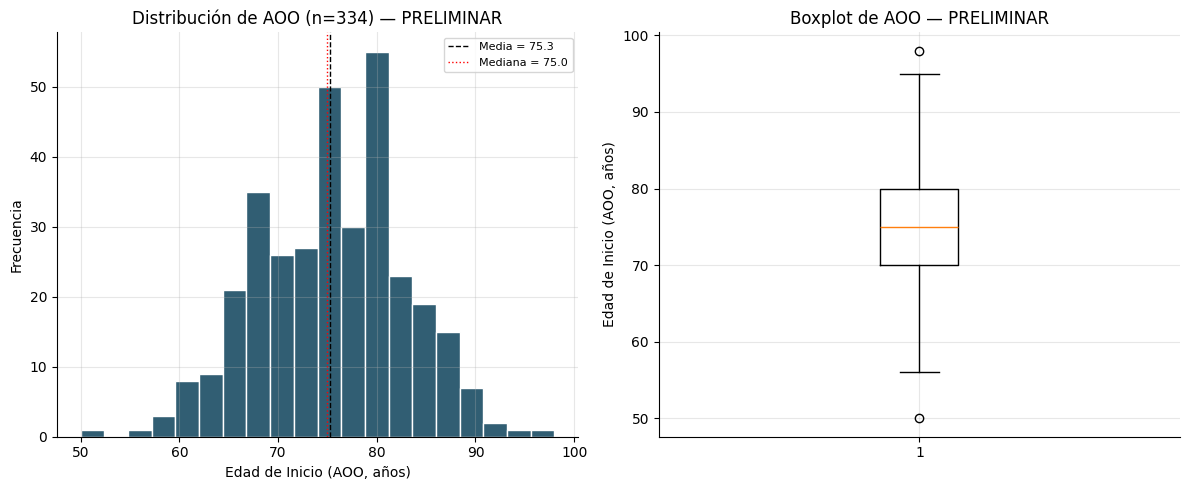

In [35]:
aoo = base_aoo["aoo"]

print("n:", len(aoo)) #PRELIMINAR — 85.2% de la cohorte maestra)
print("Media:", round(aoo.mean(), 2))
print("Mediana:", round(aoo.median(), 2))
print("DE:", round(aoo.std(), 2))
print("Mínimo:", aoo.min())
print("Máximo:", aoo.max())
print("Q1:", aoo.quantile(.25))
print("Q3:", aoo.quantile(.75))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(aoo, bins=20, color='#315e73', edgecolor="white")
ax[0].axvline(aoo.mean(), color="black", linestyle="--", linewidth=1, label=f"Media = {aoo.mean():.1f}")
ax[0].axvline(aoo.median(), color="red", linestyle=":", linewidth=1, label=f"Mediana = {aoo.median():.1f}")
ax[0].set_xlabel("Edad de Inicio (AOO, años)")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title(f"Distribución de AOO (n={len(aoo)}) — PRELIMINAR")
ax[0].legend(fontsize=8)

ax[1].boxplot(aoo, vert=True)
ax[1].set_ylabel("Edad de Inicio (AOO, años)")
ax[1].set_title("Boxplot de AOO — PRELIMINAR")

plt.tight_layout()
plt.show()

In [36]:
q1, q3 = aoo.quantile(0.25), aoo.quantile(0.75)
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers_mask = (aoo < lower_fence) | (aoo > upper_fence)
outlier_ids = base_aoo.loc[aoo[outliers_mask].index, "id"].tolist()
outlier_vals = aoo[outliers_mask]

print(f"Límites IQR: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"n outliers detectados (no eliminados): {outliers_mask.sum()}")
if outliers_mask.sum() > 0:
    for i, v in zip(outlier_ids, outlier_vals):
        print(f"  ID {i}: AOO = {v:.0f} años")


Límites IQR: [55.0, 95.0]
n outliers detectados (no eliminados): 2
  ID 407: AOO = 50 años
  ID 500: AOO = 98 años


> **NOTA:** estos valores NO se eliminan del dataset. Pueden representar fenotipos de inicio muy temprano o muy tardío, de particular interés para el estudio de variantes modificadoras.

In [37]:
#Identificación de posibles fenotipos extremos de interés
p05, p95 = aoo.quantile(0.05), aoo.quantile(0.95)
extremos_tempranos = base_aoo.loc[base_aoo["aoo"] <= p05, ["id", "aoo"]].sort_values("aoo")
extremos_tardios   = base_aoo.loc[base_aoo["aoo"] >= p95, ["id", "aoo"]].sort_values("aoo", ascending=False)

print(f"Percentil 5 = {p05:.1f} años | Percentil 95 = {p95:.1f} años\n")
print("Candidatos a AOO extremadamente temprana (≤ P5):")
print(extremos_tempranos.to_string(index=False))
print("\n")
print("Candidatos a AOO extremadamente tardía (≥ P95):")
print(extremos_tardios.to_string(index=False))
print("\nEstos IDs son de interés prioritario cuando se disponga de la base genética (candidatos a portar variantes moduladoras).")


Percentil 5 = 63.7 años | Percentil 95 = 87.0 años

Candidatos a AOO extremadamente temprana (≤ P5):
 id  aoo
407 50.0
 66 56.0
188 58.0
 16 59.0
409 59.0
303 60.0
275 60.0
 58 60.0
522 60.0
418 60.0
 85 61.0
 75 61.0
681 61.0
679 62.0
298 63.0
 44 63.0
477 63.0


Candidatos a AOO extremadamente tardía (≥ P95):
 id  aoo
500 98.0
511 95.0
469 92.0
306 91.0
506 90.0
422 90.0
238 90.0
320 90.0
467 90.0
322 90.0
487 90.0
 90 88.0
308 88.0
652 88.0
581 88.0
631 88.0
408 87.0
629 87.0
677 87.0
755 87.0

Estos IDs son de interés prioritario cuando se disponga de la base genética (candidatos a portar variantes moduladoras).


## **17. Calidad global de la base integrada**

In [38]:
missing_integrada = pd.DataFrame({
    "n_faltantes": base_full.isna().sum(),
    "pct_faltantes": base_full.isna().mean() * 100,
    "n_disponibles": base_full.notna().sum()
}).sort_values("pct_faltantes", ascending=False)


#dimensiones
print(f"Dimensiones de la base de datos integrada: {base_full.shape[0]} filas, {base_full.shape[1]} columnas")
display(missing_integrada.head(15))

Dimensiones de la base de datos integrada: 391 filas, 160 columnas


,n_faltantes,pct_faltantes,n_disponibles
hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,12
hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,15
aoo_actualizada,344,87.979540,47
hx__en_que_fecha_le_realizaron_la_cirugia,334,85.421995,57
hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,75
hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,170
hx__que_parentesco_tienen_con_usted,217,55.498721,174
aoo_original,104,26.598465,287
hx__antecedentes,92,23.529412,299
hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,323


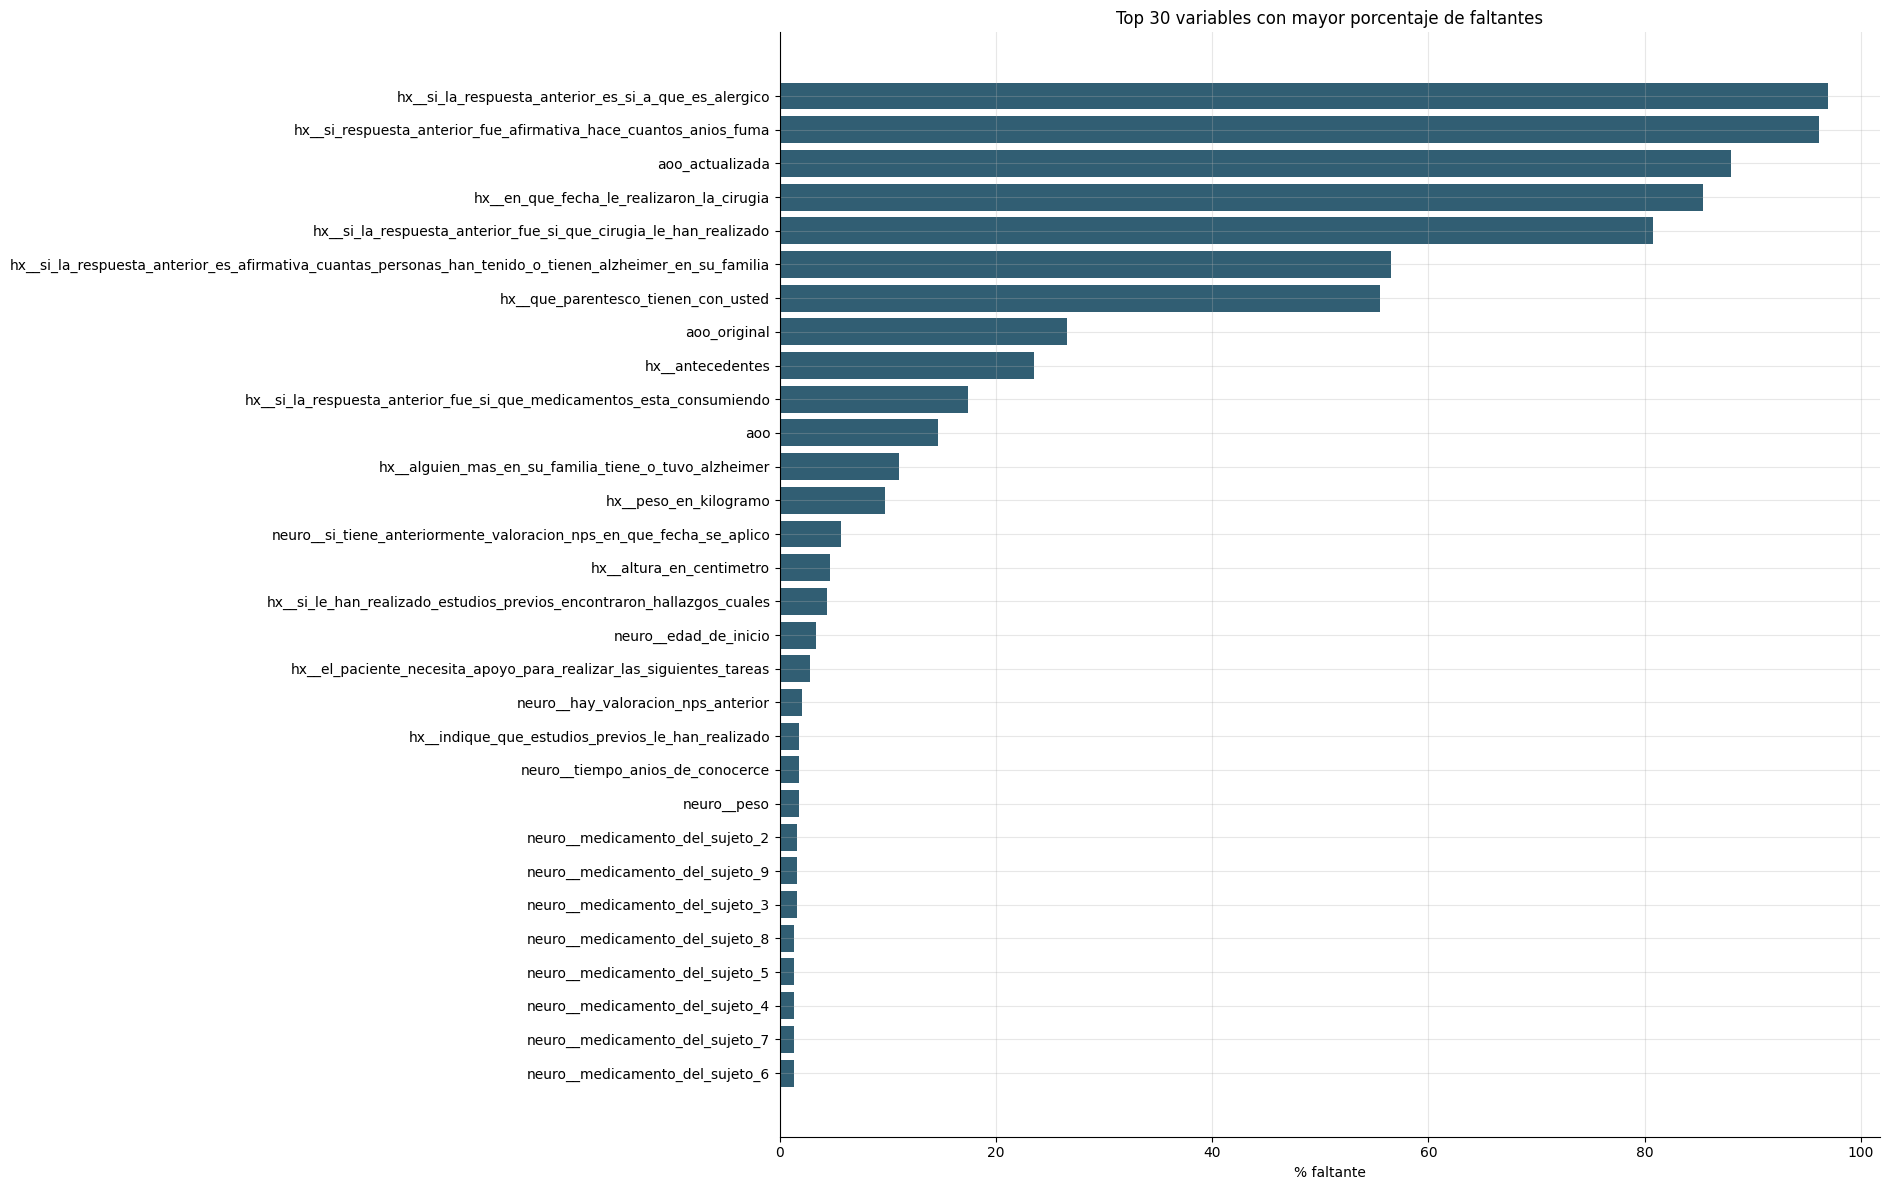

In [ ]:
top_missing = missing_integrada.head(30).sort_values("pct_faltantes")

fig, ax = plt.subplots(figsize=(19, 12))
ax.barh(top_missing.index, top_missing["pct_faltantes"], color='#315e73')
ax.set_title("Top 30 variables con mayor porcentaje de faltantes")
ax.set_xlabel("% faltante")
plt.tight_layout()
plt.show()

In [42]:
n_variables_con_faltantes = (
    tabla_faltantes["n_faltantes"] > 0
).sum()

print(
    "Variables con al menos un faltante:",
    n_variables_con_faltantes
)

print(
    "Total de columnas en base_full:",
    len(tabla_faltantes)
)

print(
    "Total de celdas faltantes:",
    tabla_faltantes["n_faltantes"].sum()
)

Variables con al menos un faltante: 145
Total de columnas en base_full: 160
Total de celdas faltantes: 3125


### **17.1. Estrategia de manejo de datos faltantes**

In [40]:
tabla_faltantes = pd.DataFrame({
    "variable": base_full.columns,
    "n_faltantes": base_full.isna().sum().values,
    "pct_faltantes": (
        base_full.isna().mean().values * 100
    )
})

tabla_faltantes["decision_preliminar"] = np.select(
    [
        tabla_faltantes["pct_faltantes"] == 0,
        tabla_faltantes["pct_faltantes"] <= 5,
        tabla_faltantes["pct_faltantes"] <= 20,
        tabla_faltantes["pct_faltantes"] > 20
    ],
    [
        "Sin acción",
        "Imputación probablemente innecesaria / evaluar",
        "Candidata a imputación",
        "Revisar exclusión o naturaleza estructural"
    ],
    default="Revisar"
)

display(
    tabla_faltantes.sort_values(
        "pct_faltantes",
        ascending=False
    ).head(20)
)

,variable,n_faltantes,pct_faltantes,decision_preliminar
18,hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,Revisar exclusión o naturaleza estructural
12,hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,Revisar exclusión o naturaleza estructural
150,aoo_actualizada,344,87.979540,Revisar exclusión o naturaleza estructural
16,hx__en_que_fecha_le_realizaron_la_cirugia,334,85.421995,Revisar exclusión o naturaleza estructural
15,hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,Revisar exclusión o naturaleza estructural
22,hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,Revisar exclusión o naturaleza estructural
23,hx__que_parentesco_tienen_con_usted,217,55.498721,Revisar exclusión o naturaleza estructural
149,aoo_original,104,26.598465,Revisar exclusión o naturaleza estructural
8,hx__antecedentes,92,23.529412,Revisar exclusión o naturaleza estructural
10,hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,Candidata a imputación


In [43]:
# Base preservada para etapas posteriores:
base_sin_imputar = base_full.copy()

print("Base preservada sin imputación:")
print(base_sin_imputar.shape)

Base preservada sin imputación:
(391, 160)


In [45]:
# Variables excluidas de la regla general de faltantes
excluir_regla_faltantes = [
    "id",
    "aoo",
    "aoo_original",
    "aoo_actualizada",
    "match_neuro",
    "match_moca",
    "inconsistente_con_neuro",
    "inconsistente_con_hx",
    "estado_consistencia_aoo"
]

tabla_faltantes_modelo = tabla_faltantes[
    ~tabla_faltantes["variable"].isin(excluir_regla_faltantes)
].copy()

display(
    tabla_faltantes_modelo.sort_values(
        "pct_faltantes",
        ascending=False
    ).head(10)
)

,variable,n_faltantes,pct_faltantes,decision_preliminar
18,hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,Revisar exclusión o naturaleza estructural
12,hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,Revisar exclusión o naturaleza estructural
16,hx__en_que_fecha_le_realizaron_la_cirugia,334,85.421995,Revisar exclusión o naturaleza estructural
15,hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,Revisar exclusión o naturaleza estructural
22,hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,Revisar exclusión o naturaleza estructural
23,hx__que_parentesco_tienen_con_usted,217,55.498721,Revisar exclusión o naturaleza estructural
8,hx__antecedentes,92,23.529412,Revisar exclusión o naturaleza estructural
10,hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,Candidata a imputación
21,hx__alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,43,10.997442,Candidata a imputación
19,hx__peso_en_kilogramo,38,9.718670,Candidata a imputación


### **Decisión sobre imputación de datos faltantes**

En esta etapa del análisis exploratorio no se realizará imputación de valores faltantes. El objetivo actual es describir la calidad y estructura real de los datos, por lo que modificar los valores faltantes alteraría las distribuciones originales y podría ocultar problemas de calidad o patrones de ausencia relevantes.

Además, la imputación no debe realizarse de forma global antes de definir el esquema de modelamiento. En un contexto predictivo, calcular valores de imputación utilizando toda la base antes de separar conjuntos de entrenamiento y prueba puede generar data leakage, ya que la información del conjunto de prueba influiría indirectamente en el conjunto de entrenamiento.

Por esta razón, las variables se clasifican únicamente de forma preliminar según su porcentaje y naturaleza de datos faltantes. Las variables con más del 20% de faltantes reales serán revisadas para una posible exclusión del modelamiento, salvo que exista una justificación clínica o que la ausencia sea estructural. Las variables con hasta 20% de faltantes podrán considerarse posteriormente para imputación según su tipo y relevancia.

La variable AOO, al ser el desenlace principal del estudio, no será imputada. Los análisis que dependan de AOO se realizarán únicamente sobre los pacientes con un valor válido.

La estrategia definitiva de imputación se aplicará en la fase de modelamiento y se estimará exclusivamente con los datos de entrenamiento o dentro de un pipeline de validación, evitando así fuga de información.

> **Importante:** las categorías Desconocido, No registrado y los faltantes estructurales derivados de preguntas condicionales no se imputarán automáticamente como si fueran datos perdidos convencionales. Su tratamiento dependerá del significado documentado en los metadatos del Excel.

## **18. Variables constantes, casi constantes y cardinalidad**

In [46]:
nunique = base_full.nunique(dropna=True)

constantes = nunique[nunique <= 1]
casi_constantes = nunique[(nunique > 1) & (nunique <= 3)]

print("Constantes:")
display(constantes.to_frame("n_unicos"))

print("\nCon 2 o 3 valores únicos:")
display(casi_constantes.to_frame("n_unicos"))

Constantes:


,n_unicos
neuro__dx,1
neuro__idioma,1
neuro__angioplastia_endarterectomia_stent,1
neuro__bypass_cardiaco_coronario,1
neuro__traumatismo_de_craneo_encefalico_tce,1
neuro__niveles_de_vitamina_d,1
neuro__trastorno_de_estres_postraumatico_tept,1
neuro__trastorno_bipolar,1
neuro__trastorno_obsesivo_compulsivo_toc,1
neuro__trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,1



Con 2 o 3 valores únicos:


,n_unicos
hx__usted_fuma,3
hx__sufre_de_algun_tipo_de_alergia,3
neuro__genero,2
neuro__otro_idoma,3
neuro__tipo_de_residencia,3
neuro__lateralidad,3
neuro__ataque_cardiaco_o_paro_cardiaco,3
neuro__fibrilacion_auricular,2
neuro__marcapasos_y_o_desfibrilador,2
neuro__insuficiencia_cardiaca_congestiva,2


## **19. Limpieza especial de tabaquismo**

In [49]:
col_anios_fumando = next(
    (c for c in demo_norm if "numero_total_de_anios_que_ha_fumado" in c),
    None
)

if col_anios_fumando:
    base_full["anios_fumando_limpio"] = pd.to_numeric(
        base_full[col_anios_fumando],
        errors="coerce"
    )

    base_full.loc[
        base_full["anios_fumando_limpio"] == 99,
        "anios_fumando_limpio"
    ] = np.nan

    display(base_full["anios_fumando_limpio"].describe())

if col_anios_fumando is not None:
    print(
        "Valores 99 recodificados como faltantes:",
        (pd.to_numeric(base_full[col_anios_fumando], errors="coerce") == 99).sum()
    )
    display(base_full["anios_fumando_limpio"].value_counts(dropna=False).sort_index())
else:
    print("La variable de años de tabaquismo no se identificó en demo_norm; validar el encabezado original.")

count    342.000000
mean       3.926901
std       10.171430
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       70.000000
Name: anios_fumando_limpio, dtype: float64

Valores 99 recodificados como faltantes: 13


anios_fumando_limpio
0.0     259
1.0       6
2.0       7
3.0       5
4.0       2
5.0       5
6.0       1
7.0       2
9.0       3
10.0     14
12.0      1
13.0      2
15.0      5
20.0     12
28.0      1
30.0      5
40.0      7
50.0      3
57.0      1
70.0      1
NaN      49
Name: count, dtype: int64

Después de recodificar el valor 99 = desconocido como faltante, se dispone de información válida sobre años de tabaquismo para 342 de los 391 pacientes. En total quedaron 49 registros faltantes, de los cuales 13 correspondían explícitamente al código 99.

La distribución de los años de tabaquismo está fuertemente concentrada en cero: 259 pacientes registran 0 años de consumo, equivalentes aproximadamente al 75,7% de quienes tienen un valor válido. La mediana, el primer cuartil y el tercer cuartil son todos iguales a 0, lo que confirma que la mayor parte de la cohorte no presenta años de tabaquismo acumulado registrados.

Entre los pacientes con valores positivos existe una distribución muy asimétrica hacia la derecha, con duraciones que van desde 1 hasta 70 años. Por esta razón, la media de 3,93 años es considerablemente mayor que la mediana de 0 y no representa adecuadamente al paciente típico de la cohorte. Se observan algunos participantes con exposiciones prolongadas, incluyendo registros de 20, 30, 40, 50, 57 y hasta 70 años.

En conjunto, la variable muestra una cohorte predominantemente sin exposición acumulada registrada, junto con un grupo menor de pacientes con antecedentes de tabaquismo de duración variable y, en algunos casos, prolongada.

## **20. Variables neuropsicológicas: exploración y reducción**

Las neuropsicológicas completas se usarán para:

- calidad y faltantes;
- rangos;
- variabilidad;
- correlaciones;
- redundancia;
- selección de representantes por dominio.

No se pretende incluirlas todas en el modelo principal de AOO.

In [50]:
def convertir_numericas_probables(df, cols, umbral=.70):
    convertidas = []
    for c in cols:
        if c not in df.columns:
            continue

        s = df[c]
        n = s.notna().sum()

        if n == 0:
            continue

        sn = pd.to_numeric(
            s.astype(str)
             .str.replace(",", ".", regex=False)
             .str.replace(r"^\s*-\s*$", "", regex=True),
            errors="coerce"
        )

        if sn.notna().sum() / n >= umbral:
            df[c] = sn
            convertidas.append(c)

    return convertidas

convertidas_neuro = convertir_numericas_probables(base_full, neuro_norm)

print("Variables neuro convertidas a numéricas:", len(convertidas_neuro))

Variables neuro convertidas a numéricas: 54


### **20.1. Calidad de todas las variables neuropsicológicas**

In [51]:
neuro_num = [
    c for c in neuro_norm
    if c in base_full.columns and pd.api.types.is_numeric_dtype(base_full[c])
]

calidad_neuro = pd.DataFrame({
    "variable": neuro_num,
    "n_disponibles": [base_full[c].notna().sum() for c in neuro_num],
    "pct_faltantes": [base_full[c].isna().mean() * 100 for c in neuro_num],
    "n_unicos": [base_full[c].nunique(dropna=True) for c in neuro_num],
    "media": [base_full[c].mean() for c in neuro_num],
    "mediana": [base_full[c].median() for c in neuro_num],
    "DE": [base_full[c].std() for c in neuro_num]
})

display(calidad_neuro.sort_values(["pct_faltantes", "n_unicos"]))

,variable,n_disponibles,pct_faltantes,n_unicos,media,mediana,DE
52,neuro__fast,388,0.767263,5,3.512887,3.0,0.833621
51,neuro__ikatz,388,0.767263,7,1.626289,0.0,2.169087
49,neuro__barthel,388,0.767263,12,37.365979,50.0,18.148258
50,neuro__lawton_y_brody,388,0.767263,14,2.703608,2.0,4.536648
53,neuro__esc_deterioroglobal,387,1.023018,6,3.842377,4.0,0.551458
1,neuro__mmse,385,1.534527,31,16.280519,19.0,9.545356
47,neuro__quejas_subjetivas,383,2.046036,7,2.120104,2.0,2.145539
0,neuro__hay_valoracion_nps_anterior,382,2.301790,2,0.010471,0.0,0.101925
18,neuro__fcrocop,382,2.301790,36,8.057592,2.0,10.844490
21,neuro__taavrey1,380,2.813299,7,1.655263,2.0,1.486828


### **20.2. Exploración neuropsicológica por dominios**

In [52]:
for grupo, vars_orig in GRUPOS_NEURO.items():
    vars_norm = [
        f"neuro__{mapa_neuro_dict[v]}"
        for v in vars_orig
        if v in mapa_neuro_dict
    ]

    vars_num = [
        c for c in vars_norm
        if c in base_full.columns and pd.api.types.is_numeric_dtype(base_full[c])
    ]

    print("\n" + "="*90)
    print(grupo.upper())
    print("="*90)

    if vars_num:
        display(base_full[vars_num].describe().T)

        if len(vars_num) >= 2:
            display(base_full[vars_num].corr(method="spearman"))


METADATOS_NPS

COGNICION_GLOBAL


,count,mean,std,min,25%,50%,75%,max
neuro__mmse,385.0,16.280519,9.545356,0.0,10.0,19.0,24.0,30.0



MEMORIA


,count,mean,std,min,25%,50%,75%,max
neuro__cmweschler,377.0,1.848806,2.930209,0.0,0.00,0.0,3.0,33.0
neuro__taavrey1,380.0,1.655263,1.486828,0.0,0.00,2.0,3.0,6.0
neuro__taavrey2,380.0,2.410526,1.777875,0.0,1.00,2.0,4.0,8.0
neuro__taavrey3,380.0,2.863158,2.000583,0.0,1.00,3.0,4.0,8.0
neuro__taavrey4,380.0,3.007895,2.170184,0.0,1.75,3.0,4.0,13.0
neuro__taavrey5,380.0,3.178947,2.313110,0.0,1.00,3.0,5.0,11.0
neuro__taavreyb1,380.0,1.352632,1.277724,0.0,0.00,1.0,2.0,6.0
neuro__taavrey6,380.0,1.494737,1.750228,0.0,0.00,1.0,3.0,9.0
neuro__taavrey7,379.0,0.841689,1.727846,0.0,0.00,0.0,1.0,19.0
neuro__taavrey_rec_si,376.0,7.257979,5.650245,0.0,0.00,8.0,13.0,15.0


,neuro__cmweschler,neuro__taavrey1,neuro__taavrey2,neuro__taavrey3,neuro__taavrey4,neuro__taavrey5,neuro__taavreyb1,neuro__taavrey6,neuro__taavrey7,neuro__taavrey_rec_si,neuro__taavrey_rec_no
neuro__cmweschler,1.000000,0.469903,0.541435,0.528095,0.515157,0.473002,0.459636,0.355854,0.274067,0.227307,0.348618
neuro__taavrey1,0.469903,1.000000,0.732857,0.718479,0.722502,0.712542,0.569255,0.546638,0.459231,0.411516,0.322874
neuro__taavrey2,0.541435,0.732857,1.000000,0.806074,0.811459,0.821860,0.582742,0.596931,0.457189,0.474322,0.381225
neuro__taavrey3,0.528095,0.718479,0.806074,1.000000,0.850071,0.852250,0.602356,0.660130,0.539097,0.488537,0.386384
neuro__taavrey4,0.515157,0.722502,0.811459,0.850071,1.000000,0.859727,0.641644,0.625329,0.454464,0.479831,0.393549
neuro__taavrey5,0.473002,0.712542,0.821860,0.852250,0.859727,1.000000,0.580749,0.629644,0.508526,0.478471,0.381472
neuro__taavreyb1,0.459636,0.569255,0.582742,0.602356,0.641644,0.580749,1.000000,0.446113,0.377289,0.365481,0.385559
neuro__taavrey6,0.355854,0.546638,0.596931,0.660130,0.625329,0.629644,0.446113,1.000000,0.632103,0.457268,0.253273
neuro__taavrey7,0.274067,0.459231,0.457189,0.539097,0.454464,0.508526,0.377289,0.632103,1.000000,0.329768,0.146782
neuro__taavrey_rec_si,0.227307,0.411516,0.474322,0.488537,0.479831,0.478471,0.365481,0.457268,0.329768,1.000000,-0.156922


...

,count,mean,std,min,25%,50%,75%,max
neuro__tsmydoral,363.0,3.677686,7.388076,0.0,0.0,0.0,4.0,42.0
neuro__tsmyd_escr,363.0,2.922865,5.764686,0.0,0.0,0.0,3.0,35.0
neuro__benton,365.0,0.873973,1.324124,0.0,0.0,0.0,1.0,7.0


,neuro__tsmydoral,neuro__tsmyd_escr,neuro__benton
neuro__tsmydoral,1.000000,0.923304,0.574032
neuro__tsmyd_escr,0.923304,1.000000,0.580855
neuro__benton,0.574032,0.580855,1.000000



FUNCIONAL_AFECTIVO_QUEJAS


,count,mean,std,min,25%,50%,75%,max
neuro__yesavage,372.0,6.373656,5.900126,0.0,1.0,4.0,10.0,16.0
neuro__barthel,388.0,37.365979,18.148258,0.0,25.0,50.0,50.0,50.0
neuro__lawton_y_brody,388.0,2.703608,4.536648,0.0,1.0,2.0,3.0,30.0
neuro__ikatz,388.0,1.626289,2.169087,0.0,0.0,0.0,3.0,6.0
neuro__fast,388.0,3.512887,0.833621,2.0,3.0,3.0,4.0,16.0


,neuro__yesavage,neuro__barthel,neuro__lawton_y_brody,neuro__ikatz,neuro__fast
neuro__yesavage,1.000000,-0.401172,0.351126,0.402058,0.332618
neuro__barthel,-0.401172,1.000000,-0.604605,-0.924373,-0.717583
neuro__lawton_y_brody,0.351126,-0.604605,1.000000,0.598733,0.659746
neuro__ikatz,0.402058,-0.924373,0.598733,1.000000,0.730081
neuro__fast,0.332618,-0.717583,0.659746,0.730081,1.000000


### **20.3. Correlaciones y redundancia neuropsicológica**

In [53]:
corr_cols = [
    c for c in neuro_num
    if base_full[c].notna().sum() >= max(30, int(.50 * len(base_full)))
    and base_full[c].nunique(dropna=True) > 3
]

corr_neuro = base_full[corr_cols].corr(method="spearman")

pares = []
for i in range(len(corr_neuro.columns)):
    for j in range(i + 1, len(corr_neuro.columns)):
        rho = corr_neuro.iloc[i, j]
        if pd.notna(rho):
            pares.append([
                corr_neuro.index[i],
                corr_neuro.columns[j],
                rho,
                abs(rho)
            ])

pares_corr = pd.DataFrame(
    pares,
    columns=["variable_1", "variable_2", "rho_spearman", "abs_rho"]
).sort_values("abs_rho", ascending=False)

display(pares_corr.head(60))

,variable_1,variable_2,rho_spearman,abs_rho
1074,neuro__tbn_espontanea,neuro__tbn_total,0.971922,0.971922
1317,neuro__barthel,neuro__ikatz,-0.924373,0.924373
1206,neuro__tsmydoral,neuro__tsmyd_escr,0.923304,0.923304
1136,neuro__tspal,neuro__tscol,0.905394,0.905394
1155,neuro__tscol,neuro__tspalcol,0.892795,0.892795
891,neuro__taavrey4,neuro__taavrey5,0.859727,0.859727
338,neuro__fvff,neuro__fvfa,0.857331,0.857331
862,neuro__taavrey3,neuro__taavrey5,0.852250,0.852250
467,neuro__fvfa,neuro__fvfs,0.850708,0.850708
861,neuro__taavrey3,neuro__taavrey4,0.850071,0.850071


In [54]:
redundantes_fuertes = pares_corr[pares_corr["abs_rho"] >= .80]
display(redundantes_fuertes)

,variable_1,variable_2,rho_spearman,abs_rho
1074,neuro__tbn_espontanea,neuro__tbn_total,0.971922,0.971922
1317,neuro__barthel,neuro__ikatz,-0.924373,0.924373
1206,neuro__tsmydoral,neuro__tsmyd_escr,0.923304,0.923304
1136,neuro__tspal,neuro__tscol,0.905394,0.905394
1155,neuro__tscol,neuro__tspalcol,0.892795,0.892795
891,neuro__taavrey4,neuro__taavrey5,0.859727,0.859727
338,neuro__fvff,neuro__fvfa,0.857331,0.857331
862,neuro__taavrey3,neuro__taavrey5,0.852250,0.852250
467,neuro__fvfa,neuro__fvfs,0.850708,0.850708
861,neuro__taavrey3,neuro__taavrey4,0.850071,0.850071


La batería neuropsicológica contiene varios grupos de variables con fuerte redundancia interna. Esto sugiere que no es necesario incluir todas las pruebas simultáneamente en análisis posteriores, ya que algunas aportan información muy similar.

### **20.4. Variables clínicas/neuropsicológicas prioritarias**


In [55]:
tabla_reduccion_neuro = pd.DataFrame([
    {
        "grupo_redundante": "Denominación - TBN",
        "variable_conservada": "neuro__tbn_total",
        "variables_excluidas_modelo": "neuro__tbn_espontanea",
        "rho_aprox": 0.972,
        "motivo": "Correlación muy alta; se conserva una medida resumen."
    },
    {
        "grupo_redundante": "Memoria verbal - TAAV Rey",
        "variable_conservada": "neuro__taavrey5",
        "variables_excluidas_modelo": "neuro__taavrey2, neuro__taavrey3, neuro__taavrey4",
        "rho_aprox": "0.81–0.86",
        "motivo": "Alta correlación entre ensayos de aprendizaje; se conserva un ensayo representativo."
    },
    {
        "grupo_redundante": "Fluidez verbal fonológica",
        "variable_conservada": "neuro__fvff",
        "variables_excluidas_modelo": "neuro__fvfa, neuro__fvfs",
        "rho_aprox": "0.84–0.86",
        "motivo": "Alta redundancia entre tareas fonológicas."
    },
    {
        "grupo_redundante": "Stroop",
        "variable_conservada": "neuro__tscol",
        "variables_excluidas_modelo": "neuro__tspal, neuro__tspalcol",
        "rho_aprox": "0.89–0.91",
        "motivo": "Alta correlación entre condiciones de la prueba."
    },
    {
        "grupo_redundante": "Memoria semántica",
        "variable_conservada": "neuro__tsmydoral",
        "variables_excluidas_modelo": "neuro__tsmyd_escr",
        "rho_aprox": 0.923,
        "motivo": "Las versiones oral y escrita presentan información muy similar."
    },
    {
        "grupo_redundante": "Funcionalidad",
        "variable_conservada": "neuro__barthel",
        "variables_excluidas_modelo": "neuro__ikatz",
        "rho_aprox": -0.924,
        "motivo": "Alta relación inversa; ambas escalas reflejan dimensiones funcionales relacionadas."
    }
])

display(tabla_reduccion_neuro)

,grupo_redundante,variable_conservada,variables_excluidas_modelo,rho_aprox,motivo
0,Denominación - TBN,neuro__tbn_total,neuro__tbn_espontanea,0.972,Correlación muy alta; se conserva una medida resumen.
1,Memoria verbal - TAAV Rey,neuro__taavrey5,"neuro__taavrey2, neuro__taavrey3, neuro__taavrey4",0.81–0.86,Alta correlación entre ensayos de aprendizaje; se conserva un ensayo representativo.
2,Fluidez verbal fonológica,neuro__fvff,"neuro__fvfa, neuro__fvfs",0.84–0.86,Alta redundancia entre tareas fonológicas.
3,Stroop,neuro__tscol,"neuro__tspal, neuro__tspalcol",0.89–0.91,Alta correlación entre condiciones de la prueba.
4,Memoria semántica,neuro__tsmydoral,neuro__tsmyd_escr,0.923,Las versiones oral y escrita presentan información muy similar.
5,Funcionalidad,neuro__barthel,neuro__ikatz,-0.924,Alta relación inversa; ambas escalas reflejan dimensiones funcionales relacionadas.


In [58]:
variables_neuro_reducidas = [
    # Cognición global
    "neuro__mmse",
    "moca__moca",
    "neuro__fast",

    # Una representativa de cada grupo redundante
    "neuro__tbn_total",
    "neuro__taavrey5",
    "neuro__fvff",
    "neuro__tscol",
    "neuro__tsmydoral",
    "neuro__barthel"
]

# Dejar solo las que realmente existen en base_full
variables_neuro_reducidas = [
    v for v in variables_neuro_reducidas
    if v in base_full.columns
]

print("Variables neuropsicológicas seleccionadas:")
for v in variables_neuro_reducidas:
    print("-", v)

Variables neuropsicológicas seleccionadas:
- neuro__mmse
- moca__moca
- neuro__fast
- neuro__tbn_total
- neuro__taavrey5
- neuro__fvff
- neuro__tscol
- neuro__tsmydoral
- neuro__barthel


In [59]:
variables_neuro_excluidas_redundancia = [
    "neuro__tbn_espontanea",
    "neuro__taavrey2",
    "neuro__taavrey3",
    "neuro__taavrey4",
    "neuro__fvfa",
    "neuro__fvfs",
    "neuro__tspal",
    "neuro__tspalcol",
    "neuro__tsmyd_escr",
    "neuro__ikatz"
]

variables_neuro_excluidas_redundancia = [
    v for v in variables_neuro_excluidas_redundancia
    if v in base_full.columns
]

In [60]:
print("N variables conservadas:", len(variables_neuro_reducidas))
print("N variables excluidas por redundancia:", len(variables_neuro_excluidas_redundancia))

N variables conservadas: 9
N variables excluidas por redundancia: 10


Las correlaciones de Spearman permitieron identificar grupos de pruebas con fuerte redundancia estadística (|rho| ≥ 0.80). Estas variables no se eliminan de la base original, sino que se excluyen únicamente del conjunto destinado a análisis posteriores. Para cada grupo redundante se conserva una variable representativa, considerando correlación, interpretabilidad clínica, completitud y facilidad de interpretación. La selección es preliminar y podrá ajustarse con criterio del investigador.

### **20.5. Variables clínicas/neuropsicológicas prioritarias**

Se priorizan:

- MMSE
- MoCA
- FAST

Estas sirven principalmente para **caracterización clínica y análisis secundario**.

No deben incluirse automáticamente como predictores del AOO, porque pueden haberse medido después del inicio de la enfermedad.

In [61]:
core_vars = [
    "neuro__mmse",
    "moca__moca",
    "neuro__fast"
]

core_vars = [
    c for c in core_vars
    if c in base_full.columns
]

print(core_vars)
for c in core_vars:
    base_full[c] = pd.to_numeric(
        base_full[c],
        errors="coerce"
    )

display(
    base_full[core_vars]
    .describe()
    .T
)

display(
    base_full[core_vars]
    .corr(method="spearman")
)

['neuro__mmse', 'moca__moca', 'neuro__fast']


,count,mean,std,min,25%,50%,75%,max
neuro__mmse,385.0,16.280519,9.545356,0.0,10.0,19.0,24.0,30.0
moca__moca,389.0,8.884319,7.010632,0.0,3.0,8.0,15.0,28.0
neuro__fast,388.0,3.512887,0.833621,2.0,3.0,3.0,4.0,16.0


,neuro__mmse,moca__moca,neuro__fast
neuro__mmse,1.000000,0.830892,-0.526679
moca__moca,0.830892,1.000000,-0.520567
neuro__fast,-0.526679,-0.520567,1.000000


### **20.5. Tabla para justificar reducción neuropsicológica**

Se evalúa la calidad de las variables neuropsicológicas considerando su porcentaje de datos faltantes y su variabilidad. Se consideran inicialmente de alta completitud aquellas con ≤10% de valores faltantes y con variabilidad suficiente aquellas que presentan más de 5 valores únicos. Estos criterios no determinan por sí solos la selección final, sino que sirven como apoyo junto con la relevancia clínica, la redundancia entre pruebas y el riesgo de data leakage.

In [62]:
tabla_seleccion_neuro = calidad_neuro.copy()

tabla_seleccion_neuro["alta_completitud"] = tabla_seleccion_neuro["pct_faltantes"] <= 10
tabla_seleccion_neuro["variabilidad_suficiente"] = tabla_seleccion_neuro["n_unicos"] > 5

display(
    tabla_seleccion_neuro.sort_values(
        ["alta_completitud", "variabilidad_suficiente", "pct_faltantes"],
        ascending=[False, False, True]
    )
)

,variable,n_disponibles,pct_faltantes,n_unicos,media,mediana,DE,alta_completitud,variabilidad_suficiente
49,neuro__barthel,388,0.767263,12,37.365979,50.0,18.148258,True,True
50,neuro__lawton_y_brody,388,0.767263,14,2.703608,2.0,4.536648,True,True
51,neuro__ikatz,388,0.767263,7,1.626289,0.0,2.169087,True,True
53,neuro__esc_deterioroglobal,387,1.023018,6,3.842377,4.0,0.551458,True,True
1,neuro__mmse,385,1.534527,31,16.280519,19.0,9.545356,True,True
47,neuro__quejas_subjetivas,383,2.046036,7,2.120104,2.0,2.145539,True,True
18,neuro__fcrocop,382,2.301790,36,8.057592,2.0,10.844490,True,True
21,neuro__taavrey1,380,2.813299,7,1.655263,2.0,1.486828,True,True
22,neuro__taavrey2,380,2.813299,9,2.410526,2.0,1.777875,True,True
23,neuro__taavrey3,380,2.813299,9,2.863158,3.0,2.000583,True,True


## **21. Análisis univariado**

La unidad de análisis es el paciente de la cohorte maestra HXGEN (`base_full`). Se conservan los 391 registros, incluidos los que no tienen AOO. Esta sección describe cada variable por separado; no prueba asociaciones con AOO ni selecciona predictores. Los porcentajes válidos excluyen faltantes; los porcentajes totales usan toda la cohorte. Las mediciones contemporáneas o posteriores al inicio describen el estado clínico, sin atribuirles temporalidad previa.

**Nota metodológica sobre secciones previas.** En las listas `GRUPOS_DEMO` y `GRUPOS_NEURO` algunos textos no coinciden exactamente con los encabezados del Excel; esto puede dejar variables fuera de los subgrupos. Además, `base_aoo` se creó antes de algunas columnas de auditoría y transformaciones de `base_full`, y las conversiones numéricas de la sección 20 pueden generar faltantes nuevos. Importa porque una selección automática por nombre, por dtype o por `base_aoo` podría omitir variables o usar versiones distintas. La celda 59 de tabaquismo también buscaba un nombre que no existe y podía causar `KeyError`; en esta copia se añadió una guarda explícita y una advertencia, sin recodificar valores desconocidos. Aquí se propone resolver nombres con el diccionario de columnas realmente integradas, verificar las conversiones y usar `base_full` como única fuente para descripciones. No se altera la lógica anterior.


### **21.1. Codificaciones documentadas en los archivos Excel**

Esta capa semántica se construye directamente desde los comentarios de las celdas de encabezado mediante `openpyxl`. Los valores originales de `base_full` no se modifican. Las etiquetas se aplican únicamente en copias analíticas, tablas y visualizaciones. El símbolo `-` se documenta como **No registrado** según la convención confirmada para esta base.

Si un código observado no aparece en el comentario ni en una definición explícita del encabezado, se conserva como código y se marca como pendiente de validación.


In [78]:
# 21.1.1. Codificaciones documentadas en los archivos Excel

def _clave_codigo(v):
    if pd.isna(v): return None
    if isinstance(v,(int,np.integer)): return str(int(v))
    if isinstance(v,(float,np.floating)) and float(v).is_integer(): return str(int(v))
    s=str(v).strip()
    if re.fullmatch(r"-?\d+\.0",s): return str(int(float(s)))
    return s

def _normalizar_etiqueta_documentada(texto):
    s=re.sub(r"\s+"," ",str(texto)).strip(" .;:-")
    base=normalizar_para_match(s)
    if base in {"si","sí"}: return "Sí"
    if base=="no": return "No"
    if "desconocid" in base: return "Desconocido"
    return s[:1].upper()+s[1:] if s else s

def _lineas_utiles_comentario(texto):
    lineas=[]
    for linea in str(texto or "").replace("\r","\n").split("\n"):
        linea=re.sub(r"\s+"," ",linea).strip()
        if not linea or linea=="======" or linea.startswith("ID#"): continue
        if re.search(r"\(20\d{2}-\d{2}-\d{2}",linea): continue
        if re.fullmatch(r"[A-Za-zÁÉÍÓÚáéíóúÑñ ]+:",linea): continue
        lineas.append(linea)
    return lineas

def _extraer_codificacion(texto,encabezado=""):
    lineas=_lineas_utiles_comentario(texto); pares=[]; ultimo=None
    for linea in lineas:
        inicios=list(re.finditer(r"(?<![\w/.-])(GDS\s*)?(-?\d+(?:\s*-\s*\d+)?)\s*(?:[:.=]\s*|\s+)",linea,re.I))
        if inicios:
            for j,m in enumerate(inicios):
                codigo=re.sub(r"\s+","",m.group(2))
                fin=inicios[j+1].start() if j+1<len(inicios) else len(linea)
                etiqueta=linea[m.end():fin].strip(" .;:-")
                if etiqueta:
                    pares.append([codigo,_normalizar_etiqueta_documentada(etiqueta)])
                    ultimo=len(pares)-1
        elif ultimo is not None and not re.match(r"^[A-ZÁÉÍÓÚ ]{4,}$",linea):
            pares[ultimo][1]=re.sub(r"\s+"," ",pares[ultimo][1]+" "+linea).strip()
    for m in re.finditer(r"(?<!\d)(\d+)\s*=\s*([^):,;]+)",str(encabezado),re.I):
        pares.append([m.group(1),_normalizar_etiqueta_documentada(m.group(2))])
    salida={}
    for codigo,etiqueta in pares:
        if codigo not in salida: salida[codigo]=etiqueta
    return salida

def extraer_metadatos_excel():
    fuentes=[("neuropsicologia",PATH_NEURO),("moca",PATH_MOCA),("hxgen",PATH_HXGEN)]
    registros=[]
    for fuente,ruta in fuentes:
        wb=openpyxl.load_workbook(ruta,data_only=False,read_only=False)
        for ws in wb.worksheets:
            for celda in ws[1]:
                if celda.value is None: continue
                original=str(celda.value)
                comentario=celda.comment.text.strip() if celda.comment else ""
                registros.append({
                    "fuente":fuente,"hoja":ws.title,"celda_encabezado":celda.coordinate,
                    "original_excel":original,"normalizada":normalizar_columna(original),
                    "comentario_excel":comentario,
                    "etiquetas_codigos_dict":_extraer_codificacion(comentario,original)
                })
    return pd.DataFrame(registros)

metadatos_excel=extraer_metadatos_excel()

ajustes_documentados={
    ("neuropsicologia","diabetes","3"):"Otro tipo (diabetes insípida, diabetes autoinmune latente/tipo 1.5, diabetes gestacional)",
    ("neuropsicologia","tmtb","0"):"No lo hace"
}
for (fuente,normalizada,codigo),etiqueta in ajustes_documentados.items():
    mask=metadatos_excel["fuente"].eq(fuente)&metadatos_excel["normalizada"].eq(normalizada)
    for idx in metadatos_excel.index[mask]:
        metadatos_excel.at[idx,"etiquetas_codigos_dict"][codigo]=etiqueta

meta_lookup={(r.fuente,r.normalizada):r for r in metadatos_excel.itertuples()}
def _metadato_fila(fila): return meta_lookup.get((fila["fuente"],fila["normalizada"]))

diccionario["comentario_excel"]=diccionario.apply(lambda f:getattr(_metadato_fila(f),"comentario_excel","") if _metadato_fila(f) else "",axis=1)
diccionario["etiquetas_codigos_dict"]=diccionario.apply(lambda f:getattr(_metadato_fila(f),"etiquetas_codigos_dict",{}) if _metadato_fila(f) else {},axis=1)
diccionario["codificacion_original"]=diccionario["etiquetas_codigos_dict"].map(lambda d:"; ".join(f"{k} = {v}" for k,v in d.items()))
diccionario["etiquetas_codigos"]=diccionario["codificacion_original"]
diccionario["valores_especiales"]=diccionario["etiquetas_codigos_dict"].map(lambda d:"; ".join(f"{k} = {v}" for k,v in d.items() if v in {"Desconocido","No registrado"}))

CODIGO_NO_REGISTRADO="-"
ETIQUETA_NO_REGISTRADO="No registrado"

def _mapa_codigos_columna(col):
    if col not in inventario["columna"].values: return {}
    d=inventario.set_index("columna").at[col,"etiquetas_codigos_dict"]
    return d if isinstance(d,dict) else {}

def _etiquetar_valor(v,mapa):
    if pd.isna(v): return np.nan
    clave=_clave_codigo(v)
    if clave==CODIGO_NO_REGISTRADO: return ETIQUETA_NO_REGISTRADO
    if clave in mapa: return mapa[clave]
    try:
        num=float(clave)
        for rango,etiqueta in mapa.items():
            if re.fullmatch(r"-?\d+-\d+",rango):
                a,b=map(float,rango.split("-"))
                if a<=num<=b: return etiqueta
    except (ValueError,TypeError): pass
    canon=normalizar_para_match(clave)
    if canon=="si": return "Sí"
    if canon=="no": return "No"
    return clave

def serie_etiquetada(col,incluir_especiales=True):
    s=base_full[col].copy()
    tipo=inventario.set_index("columna").at[col,"tipo_analitico"]
    mapa=_mapa_codigos_columna(col)
    if tipo.startswith("cuantitativa"):
        especiales={k for k,v in mapa.items() if v in {"Desconocido","No registrado"}}
        return s.mask(s.map(_clave_codigo).isin(especiales|{CODIGO_NO_REGISTRADO}))
    out=s.map(lambda v:_etiquetar_valor(v,mapa)); out.name=col
    if not incluir_especiales:
        out=out.mask(out.isin(["Desconocido","No registrado"]))
    return out

def serie_analitica(col):
    tipo=inventario.set_index("columna").at[col,"tipo_analitico"]
    if tipo.startswith("cuantitativa") or tipo=="ordinal":
        s=base_full[col].copy(); mapa=_mapa_codigos_columna(col)
        especiales={k for k,v in mapa.items() if v in {"Desconocido","No registrado"}}
        return s.mask(s.map(_clave_codigo).isin(especiales|{CODIGO_NO_REGISTRADO}))
    return serie_etiquetada(col,incluir_especiales=False)

campos_semanticos=["comentario_excel","etiquetas_codigos_dict","codificacion_original","etiquetas_codigos","valores_especiales"]
inventario=inventario.drop(columns=[c for c in campos_semanticos if c in inventario.columns],errors="ignore").merge(
    diccionario[["fuente","normalizada"]+campos_semanticos],on=["fuente","normalizada"],how="left"
)
for c in ["comentario_excel","codificacion_original","etiquetas_codigos","valores_especiales"]:
    inventario[c]=inventario[c].fillna("")
inventario["etiquetas_codigos_dict"]=inventario["etiquetas_codigos_dict"].map(lambda d:d if isinstance(d,dict) else {})

base_full_etiquetada=base_full.copy()
for col in inventario.loc[inventario["tipo_analitico"].isin(["categórica nominal","categórica binaria","ordinal"]),"columna"]:
    base_full_etiquetada[col]=serie_etiquetada(col,incluir_especiales=True)

def _codigos_observados(col):
    return sorted({_clave_codigo(v) for v in base_full[col].dropna()},key=str)

filas_control=[]
for r in inventario.itertuples():
    if r.tipo_analitico not in ["categórica nominal","categórica binaria","ordinal"]: continue
    presentes=_codigos_observados(r.columna); doc=set(r.etiquetas_codigos_dict)
    def documentado(v):
        if v in doc: return True
        try:
            num=float(v)
            return any(float(a)<=num<=float(b) for a,b in (k.split("-") for k in doc if re.fullmatch(r"-?\d+-\d+",k)))
        except (ValueError,TypeError): return False
    candidatos=[v for v in presentes if v!=CODIGO_NO_REGISTRADO]
    if doc:
        no_doc=[v for v in candidatos if not documentado(v)]
    else:
        prop=np.mean([bool(re.fullmatch(r"-?\d+(?:\.0)?",v)) for v in candidatos]) if candidatos else 0
        no_doc=candidatos if prop>.5 else []
    especiales=[v for v in presentes if v==CODIGO_NO_REGISTRADO or r.etiquetas_codigos_dict.get(v) in {"Desconocido","No registrado"}]
    obs=[]
    if no_doc:
        obs.append("Hay códigos observados no documentados" if r.etiquetas_codigos_dict else "Codificación numérica pendiente de validación")
    if CODIGO_NO_REGISTRADO in presentes: obs.append("'-' se presenta como No registrado")
    if not r.comentario_excel: obs.append("Sin comentario de encabezado")
    filas_control.append({
        "variable":r.etiqueta,"fuente":r.fuente,"tipo_analitico":r.tipo_analitico,
        "comentario_encontrado":bool(r.comentario_excel),
        "codificacion_detectada":bool(r.etiquetas_codigos_dict),
        "codigos_presentes":presentes,
        "codigos_documentados":sorted(doc,key=str),
        "codigos_no_documentados":no_doc,
        "valores_especiales_presentes":especiales,
        "observaciones":"; ".join(obs)
    })

control_codificaciones=pd.DataFrame(filas_control)

# SALIDA COMPACTA
display(Markdown("**Ejemplo de codificaciones documentadas**"))
print(f"Variables con codificación documentada: {inventario['codificacion_original'].ne('').sum()}")

display(
    inventario.loc[
        inventario["codificacion_original"].ne(""),
        ["etiqueta","fuente","familia","tipo_analitico","codificacion_original","valores_especiales"]
    ].head(10).reset_index(drop=True)
)

display(Markdown("**Control de calidad de las codificaciones**"))
control_pendientes=control_codificaciones[
    control_codificaciones["observaciones"].astype(str).str.strip().ne("")
].copy()

print(f"Variables categóricas/ordinales revisadas: {len(control_codificaciones)}")
print(f"Variables con observaciones pendientes: {len(control_pendientes)}")

if len(control_pendientes):
    display(
        control_pendientes[
            ["variable","fuente","tipo_analitico","codigos_presentes","codigos_documentados",
             "codigos_no_documentados","valores_especiales_presentes","observaciones"]
        ].reset_index(drop=True).head(10)
    )
else:
    print("No se identificaron codificaciones pendientes de validación.")

**Ejemplo de codificaciones documentadas**

Variables con codificación documentada: 34


,etiqueta,fuente,familia,tipo_analitico,codificacion_original,valores_especiales
0,genero,neuropsicologia,sociodemograficas,categórica binaria,0 = Masculino; 1 = Femenino,
1,Dx,neuropsicologia,identificacion_diagnostico,categórica nominal,3 = Control; 1 = AD+,
2,IDIOMA,neuropsicologia,sociodemograficas,categórica nominal,1 = Inglés; 2 = Español; 3 = Mandarín; 4 = Cantonés; 5 = Ruso; 6 = Japonés; 7 = Otro idioma principal (ESPECIFICAR);...,8 = Desconocido
3,OTRO IDOMA,neuropsicologia,sociodemograficas,texto libre / alta cardinalidad,1 = Sí; 2 = No,
4,Nivel educativo,neuropsicologia,sociodemograficas,ordinal,0 = No escolarizada; 5 = Primaria; 12 = Preparatoria / bachillerato o GED; 16 = Licenciatura; 18 = Maestría; 20 = Do...,99 = Desconocido
5,Estado civil,neuropsicologia,sociodemograficas,categórica nominal,1 = Casado; 2 = Viudo; 3 = Divorciado; 4 = Separado; 5 = Soltero (nunca casado o matrimonio anulado); 6 = Pareja dom...,7 = Desconocido
6,Estado Habitacional,neuropsicologia,sociodemograficas,categórica nominal,"1 = Vive solo; 2 = Vive con otra persona: esposo o pareja; 3 = Vive con otra persona: familiar, amigo o compañero de...",7 = Desconocido
7,Nivel de independencia,neuropsicologia,sociodemograficas,ordinal,1 = Es capaz de vivir independientemente; 2 = Requiere asistencia para actividades complejas; 3 = Requiere asistenci...,5 = Desconocido
8,Tipo de residencia,neuropsicologia,sociodemograficas,categórica nominal,"1 = Residencia privada (departamento, condominio, casa); 2 = Comunidad de retiro o vivienda grupal independiente; 3 ...",5 = Desconocido
9,Lateralidad,neuropsicologia,sociodemograficas,categórica nominal,1 = Zurdo; 2 = Diestro; 3 = Ambidiestro; 4 = Desconocido,4 = Desconocido


**Control de calidad de las codificaciones**

Variables categóricas/ordinales revisadas: 59
Variables con observaciones pendientes: 46


,variable,fuente,tipo_analitico,codigos_presentes,codigos_documentados,codigos_no_documentados,valores_especiales_presentes,observaciones
0,Nivel educativo,neuropsicologia,ordinal,"[0, 12, 16, 18, 20, 3, 5, 7, 99]","[0, 12, 16, 18, 20, 5, 99]","[3, 7]",[99],Hay códigos observados no documentados
1,¿Vive el informante con el sujeto?,neuropsicologia,categórica nominal,"[-, 0, 1, 3]","[0, 1]",[3],[-],Hay códigos observados no documentados; '-' se presenta como No registrado
2,"Si el informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",neuropsicologia,ordinal,"[-, 1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]",[],[-],'-' se presenta como No registrado
3,"Si el informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?",neuropsicologia,ordinal,"[-, 0, 1, 2, 3, 4]","[1, 2, 3, 4, 5]",[0],[-],Hay códigos observados no documentados; '-' se presenta como No registrado
4,"¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres),...",neuropsicologia,categórica nominal,"[-, 0, 1, 9, NO]","[0, 1, 9]",[NO],"[-, 9]",Hay códigos observados no documentados; '-' se presenta como No registrado
5,Familiar afectado,neuropsicologia,categórica nominal,"[-, 0, 1, 1 Y 2, 1, 2, 4, 1-2, 2, 2-3, 2022-02-01 00:00:00, 3, 4, 5]","[1, 2, 3, 4, 5]","[0, 1 Y 2, 1, 2, 4, 1-2, 2-3, 2022-02-01 00:00:00]",[-],Hay códigos observados no documentados; '-' se presenta como No registrado
6,El sujeto ha fumado en los pasados 30 días,neuropsicologia,categórica nominal,"[-, 0, 1, 9]","[0, 1, 9]",[],"[-, 9]",'-' se presenta como No registrado
7,¿El sujeto ha fumado más de 100 cigarros / cigarrillos en su vida?,neuropsicologia,categórica nominal,"[-, 0, 1, 9]","[0, 1, 9]",[],"[-, 9]",'-' se presenta como No registrado
8,Ataque cardiaco o paro cardíaco,neuropsicologia,categórica binaria,"[-, 0, 1]","[0, 1, 9]",[],[-],'-' se presenta como No registrado
9,Fibrilación auricular,neuropsicologia,categórica binaria,"[0, 1]",[],"[0, 1]",[],Codificación numérica pendiente de validación; Sin comentario de encabezado


### **21.2. Criterios metodológicos, inventario y funciones auxiliares**

La clasificación analítica usa el significado de la variable y los valores observados, no sólo el dtype. Las codificaciones ambiguas se conservan como categorías originales y se señalan para validación. Identificadores, columnas derivadas de AOO y auditoría del merge se excluyen del inventario clínico. Los grupos provienen de `diccionario`, con rescate por coincidencia normalizada de los encabezados ya documentados.

Los dos tonos de las barras se usan sólo para facilitar la lectura; no representan grupos clínicos.


In [69]:
from IPython.display import display, Markdown
from textwrap import fill

assert len(base_full) == 391 and base_full['id'].is_unique, 'Revisar la cohorte maestra antes de continuar.'
assert 'aoo' in base_full and 'riesgo_leakage_aoo' in diccionario

def etiqueta_bonita(col):
    especiales = {'aoo':'Edad de inicio de Alzheimer (AOO)', 'neuro__mmse':'MMSE',
                  'moca__moca':'MoCA', 'neuro__fast':'FAST',
                  'anios_fumando_limpio':'Años de tabaquismo (99 = desconocido)'}
    if col in especiales: return especiales[col]
    if 'inventario' in globals() and 'columna' in inventario.columns and col in set(inventario.columna):
        original=inventario.loc[inventario.columna.eq(col),'original'].iloc[0]
        return re.sub(r'\s+',' ',str(original)).strip()
    s = col.removeprefix('neuro__').removeprefix('hx__').removeprefix('moca__')
    return s.replace('_', ' ').strip().capitalize()

def columna_integrada(fila):
    prefijo = {'neuropsicologia':'neuro__', 'moca':'moca__', 'hxgen':'hx__'}.get(fila['fuente'], '')
    return prefijo + fila['normalizada']

inventario = diccionario.copy()
inventario['columna'] = inventario.apply(columna_integrada, axis=1)
inventario = inventario[inventario['columna'].isin(base_full.columns)].copy()
inventario['etiqueta'] = inventario['columna'].map(etiqueta_bonita)

# Se reusan los subgrupos existentes; se rescatan discrepancias de espacios
# usando el normalizador ya definido y se dejan visibles los casos inciertos.
def subgrupo_revisado(fila):
    if fila['subgrupo']: return fila['subgrupo']
    clave = normalizar_para_match(fila['original'])
    # El encabezado real y GRUPOS_DEMO difieren en un espacio antes de
    # '(comparten)'. La pregunta corresponde inequívocamente a historia familiar.
    if fila['fuente'] == 'neuropsicologia' and 'miembros afectados de la familia' in clave and 'padres biologicos' in clave:
        return 'historia_familiar'
    grupos = GRUPOS_NEURO if fila['columna'] in neuro_norm else GRUPOS_DEMO
    for nombre, variables in grupos.items():
        if clave in {normalizar_para_match(v) for v in variables}: return nombre
    return 'sin_asignacion_validada'

inventario['familia'] = inventario.apply(subgrupo_revisado, axis=1)
binarias = ('genero','sexo','vive_el_informante','ha_fumado','ataque_cardiaco','fibrilacion',
            'bypass','marcapasos','insuficiencia','enfermedad_cerebro','parkinson',
            'convulsiones','traumatismo','diabetes','cancer','hipercholesterolemia',
            'hipertension','deficiencia','enfermedad_tiroidea','artritis','artrosis',
            'osteoporosis','incontinencia','apnea','trastorno','esquizofrenia',
            'depresion','ansiedad','valoracion_nps_anterior')
ordinales = ('fast','nivel_educativo','nivel_de_independencia','esc_deterioroglobal',
             'frecuencia_visita','frecuencia_tiene_contacto')
continuas = ('edad','peso','talla','tiempo_anos','anos_que_ha_fumado','anios_fumando')

def tipo_analitico(fila):
    c = fila['columna']; nombre = fila['normalizada']; s = base_full[c]
    if nombre in ('codigo','id') or c == 'id': return 'identificador'
    if nombre in ('edad_de_inicio','edad_de_inicio_actualizada'): return 'variable auxiliar del EDA'
    if any(x in nombre for x in ('medicamento_del_sujeto','otro_idoma','mes_y_ano_de_nacimiento')): return 'texto libre / alta cardinalidad'
    if nombre in ('dx','idioma','estado_civil','estado_habitacional','tipo_de_residencia',
                  'lateralidad','relacion_del_informante','familiar_afectado'): return 'categórica nominal'
    if any(x in nombre for x in ordinales): return 'ordinal'
    if any(x in nombre for x in binarias) and s.nunique(dropna=True) <= 3: return 'categórica binaria'
    if nombre in ('edad','peso','talla','peso_en_kilogramo','altura_en_centimetro','tiempo_anos_de_conocerce') or nombre.startswith('numero_total_de_anios_que_ha_fumado'): return 'cuantitativa continua'
    if fila['fuente'] == 'neuropsicologia' and fila['grupo_principal'] == 'neuropsicologica':
        if any(x in nombre for x in ('fecha','quejas_subjetivas')): return 'texto libre / alta cardinalidad'
        return 'cuantitativa discreta' if pd.to_numeric(s, errors='coerce').notna().sum() >= .8*s.notna().sum() else 'categórica nominal'
    if c == 'moca__moca': return 'cuantitativa discreta'
    if nombre in ('enfermedad_actual','que_sintomas_presenta','antecedentes'): return 'texto libre / alta cardinalidad'
    if s.nunique(dropna=True) <= 12: return 'categórica nominal'
    return 'texto libre / alta cardinalidad'

inventario['tipo_analitico'] = inventario.apply(tipo_analitico, axis=1)
inventario['n_valido'] = inventario['columna'].map(base_full.notna().sum())
inventario['n_faltante'] = len(base_full) - inventario['n_valido']
inventario['n_unicos_cohorte'] = inventario['columna'].map(base_full.nunique(dropna=True))
inventario['observacion'] = np.where(inventario['tipo_analitico'].eq('categórica nominal') &
                                    inventario['columna'].map(lambda c: pd.api.types.is_numeric_dtype(base_full[c])),
                                    'Código numérico: significado/orden requiere validación', '')
print(f"Variables incluidas en el inventario analítico: {len(inventario)}")

display(
    inventario["tipo_analitico"]
    .value_counts()
    .rename_axis("tipo_analitico")
    .reset_index(name="n_variables")
)


Variables incluidas en el inventario analítico: 146


,tipo_analitico,n_variables
0,cuantitativa discreta,51
1,categórica binaria,29
2,texto libre / alta cardinalidad,27
3,categórica nominal,24
4,cuantitativa continua,7
5,ordinal,6
6,variable auxiliar del EDA,2


In [70]:
faltan_en_inventario = diccionario[
    ~diccionario.apply(
        lambda fila: columna_integrada(fila) in base_full.columns,
        axis=1
    )
]

display(
    faltan_en_inventario[
        ["original", "normalizada", "fuente"]
    ]
)

,original,normalizada,fuente
0,CODIGO,codigo,neuropsicologia
123,CODIGO,codigo,moca
125,Código,codigo,hxgen


In [71]:
pendientes = inventario[
    inventario["observacion"].astype(str).str.strip().ne("")
]

print(f"Variables con observaciones pendientes: {len(pendientes)}")

display(
    pendientes[
        ["etiqueta", "fuente", "familia", "tipo_analitico", "observacion"]
    ].reset_index(drop=True)
)

Variables con observaciones pendientes: 11


,etiqueta,fuente,familia,tipo_analitico,observacion
0,Dx,neuropsicologia,identificacion_diagnostico,categórica nominal,Código numérico: significado/orden requiere validación
1,IDIOMA,neuropsicologia,sociodemograficas,categórica nominal,Código numérico: significado/orden requiere validación
2,Estado civil,neuropsicologia,sociodemograficas,categórica nominal,Código numérico: significado/orden requiere validación
3,Estado Habitacional,neuropsicologia,sociodemograficas,categórica nominal,Código numérico: significado/orden requiere validación
4,Tipo de residencia,neuropsicologia,sociodemograficas,categórica nominal,Código numérico: significado/orden requiere validación
5,Lateralidad,neuropsicologia,sociodemograficas,categórica nominal,Código numérico: significado/orden requiere validación
6,Relación del Informante,neuropsicologia,informante_red_apoyo,categórica nominal,Código numérico: significado/orden requiere validación
7,Angioplastía/ endarterectomía/ stent,neuropsicologia,cardiovasculares_cerebrovasculares,categórica nominal,Código numérico: significado/orden requiere validación
8,DIABETES,neuropsicologia,metabolicos_otros,categórica nominal,Código numérico: significado/orden requiere validación
9,NIVELES DE VITAMINA D,neuropsicologia,metabolicos_otros,categórica nominal,Código numérico: significado/orden requiere validación


In [115]:
import math,textwrap
import numpy as np,pandas as pd,matplotlib.pyplot as plt

C1="#315e73"; C2="#789cab"; C3="#b8cbd1"; CES="#d8cfad"
FONDO="#f6f5f2"; PANEL="#eeefed"; PALETA=[C1,C2,C3,"#52798a","#9eb8c2"]

def cortar(txt,w=27,n=2):
    p=textwrap.wrap(str(txt),width=w,break_long_words=False)
    if len(p)>n: p=p[:n]; p[-1]+="…"
    return "\n".join(p)

def tabla_cat(s):
    s=s.copy(); n=len(s)
    esp=s.astype(str).isin(["Desconocido","No registrado"])
    nv=(s.notna()&~esp).sum(); filas=[]
    for cat,cant in s.dropna().astype(str).value_counts().items():
        especial=cat in ["Desconocido","No registrado"]
        pct=100*cant/(n if especial else max(nv,1))
        filas.append([cat,int(cant),pct,"total" if especial else "válido",especial])
    t=pd.DataFrame(filas,columns=["categoria","n","pct","base","especial"])
    if t.empty:return t
    return pd.concat([t[~t.especial].sort_values("n",ascending=False),t[t.especial]],ignore_index=True)

def colores_cat(t):
    out=[]; i=0
    for esp in t.especial:
        if esp: out.append(CES)
        else: out.append(PALETA[i%len(PALETA)]); i+=1
    return out

def modo_cat(t):
    if t.empty:return "vacio"
    if len(t)<=3 and t.categoria.astype(str).str.len().max()<=22:return "donut"
    return "bar"

def panel_donut(ax,titulo,t):
    ax.set_facecolor(PANEL)
    wedges,_,aut=ax.pie(
        t.n,colors=colores_cat(t),startangle=90,counterclock=False,radius=.82,
        wedgeprops=dict(width=.34,edgecolor=FONDO,linewidth=1.4),
        autopct=lambda p:f"{p:.1f}%" if p>=4 else "",pctdistance=.79
    )
    for x in aut:x.set_fontsize(8)
    if len(t)==1:
        r=t.iloc[0]
        ax.text(0,.06,cortar(r.categoria,20,2),ha="center",fontsize=13,fontweight="bold",color=C1)
        ax.text(0,-.11,f"{r.n} pacientes",ha="center",fontsize=9,color="#536168")
    else:
        leg=[f"{cortar(r.categoria,20,2)} — {r.n} ({r.pct:.1f}% {r.base})" for _,r in t.iterrows()]
        ax.legend(wedges,leg,loc="center left",bbox_to_anchor=(.92,.5),frameon=False,fontsize=8)
    ax.set_title(
    "\n".join(textwrap.wrap(titulo, width=42)),
    loc="left",
    fontsize=10,
    fontweight="bold",
    pad=10
)

def panel_bar(ax,titulo,t):
    ax.set_facecolor(PANEL); y=np.arange(len(t))
    ax.barh(y,t.pct,color=colores_cat(t),height=.66,edgecolor="white")
    ax.set_yticks(y,[cortar(x,27,2) for x in t.categoria]); ax.invert_yaxis()
    ax.set_xlim(0,max(105,t.pct.max()+15)); ax.set_xlabel("%",fontsize=8)
    for yy,(_,r) in zip(y,t.iterrows()):
        ax.text(r.pct+1,yy,f"{r.n} ({r.pct:.1f}% {r.base})",va="center",fontsize=8)
    ax.set_title(
    "\n".join(textwrap.wrap(titulo, width=42)),
    loc="left",
    fontsize=10,
    fontweight="bold",
    pad=10
)
    ax.grid(axis="x",alpha=.18); ax.grid(axis="y",visible=False)
    ax.spines[["top","right","left"]].set_visible(False); ax.tick_params(axis="y",length=0)

def panel_num(ax,titulo,s):
    x=pd.to_numeric(s,errors="coerce").dropna(); ax.set_facecolor(PANEL)
    if x.empty: ax.text(.5,.5,"Sin datos válidos",ha="center"); return
    bins=max(5,min(15,int(np.ceil(1+3.322*np.log10(len(x))))))
    ax.hist(x,bins=bins,color=C1,edgecolor="white")
    med=x.median(); ax.axvline(med,color="#8d806c",ls="--",lw=1.8,label=f"Mediana {med:.1f}")
    ax.legend(frameon=False,fontsize=8)
    ax.set_title(
    "\n".join(textwrap.wrap(titulo, width=42)),
    loc="left",
    fontsize=10,
    fontweight="bold",
    pad=10
)
    ax.set_xlabel("Valor observado",fontsize=8); ax.set_ylabel("Pacientes",fontsize=8)
    ax.grid(axis="y",alpha=.18); ax.spines[["top","right"]].set_visible(False)

def dibujar(ax,col):
    fila=inventario.loc[inventario.columna.eq(col)].iloc[0]
    tipo=fila.tipo_analitico; titulo=fila.etiqueta; s=serie_univariada(col)
    if tipo.startswith("cuantitativa"): panel_num(ax,titulo,s); return
    t=tabla_cat(s)
    if modo_cat(t)=="donut": panel_donut(ax,titulo,t)
    else: panel_bar(ax,titulo,t)

def analisis_familia(columnas,titulo,ncols=2,por_pagina=4):
    meta=inventario.set_index("columna")
    graficables=[]; no_graf=[]
    for c in columnas:
        if c not in base_full.columns: continue
        tipo=meta.loc[c,"tipo_analitico"]
        if tipo in ["texto libre / alta cardinalidad","identificador","variable auxiliar del EDA"]:
            no_graf.append(c)
        else: graficables.append(c)

    print("Variables integradas en la familia:",len(columnas))
    print("Variables graficadas:",len(graficables))
    print("Variables resumidas sin gráfico:",len(no_graf))

    for ini in range(0,len(graficables),por_pagina):
        lote=graficables[ini:ini+por_pagina]; nr=math.ceil(len(lote)/ncols)
        fig,axes=plt.subplots(nr,ncols,figsize=(14,4.1*nr),squeeze=False)
        fig.patch.set_facecolor(FONDO)
        fig.suptitle(titulo,fontsize=15,fontweight="bold",color="#2c4855",y=.98)

        for ax,c in zip(axes.flat,lote): dibujar(ax,c)
        for ax in axes.flat[len(lote):]: ax.axis("off")

        fig.subplots_adjust(left=.13,right=.93,top=.90,bottom=.08,hspace=.65,wspace=.50)
        plt.show()

    if no_graf:
        display(Markdown("**Variables no graficadas por alta cardinalidad o tipo de dato**"))
        display(pd.DataFrame([{
            "variable":etiqueta_bonita(c),
            "tipo":meta.loc[c,"tipo_analitico"],
            "n válido":serie_univariada(c).notna().sum(),
            "faltantes":serie_univariada(c).isna().sum(),
            "n únicos":serie_univariada(c).nunique(dropna=True)
        } for c in no_graf]))

In [120]:
def ejecutar_familia(familia,titulo):
    columnas=inventario.loc[
        (inventario["familia"]==familia) &
        (~inventario["tipo_analitico"].isin(["identificador","variable auxiliar del EDA"])),
        "columna"
    ].tolist()

    print("Variables integradas en la familia:",len(columnas))

    resumen_cat=[]
    for col in columnas:
        fila=inventario.loc[inventario["columna"].eq(col)]
        if fila.empty: continue
        tipo=fila["tipo_analitico"].iloc[0]
        if tipo not in ["categórica nominal","categórica binaria","ordinal"]: continue

        s=serie_univariada(col)
        t=tabla_cat(s)
        if t.empty: continue

        validas=t.loc[~t["especial"]]
        principal=validas.iloc[0] if len(validas) else t.iloc[0]

        resumen_cat.append({
            "variable":etiqueta_bonita(col),
            "categoría predominante":principal["categoria"],
            "n":int(principal["n"]),
            "% válido":round(principal["pct"],1),
            "faltantes":int(s.isna().sum())
        })

    if resumen_cat:
        display(Markdown("**Resumen de variables categóricas**"))
        display(pd.DataFrame(resumen_cat).reset_index(drop=True))

    display(Markdown("**Distribuciones**"))
    analisis_familia(columnas,titulo)

### **21.2. Variable principal: AOO**

La AOO final usa la edad original y sólo complementa con la actualizada cuando falta. Se describen todos los valores disponibles, incluidos extremos y casos marcados para revisión. Los intervalos siguientes son **estadísticos de amplitud uniforme**, no puntos de corte clínicos validados.


,cohorte_total,AOO_disponible,AOO_faltante,disponibilidad_pct
0,391,334,57,85.4


,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,334,57,14.6,75.28,75.0,7.57,50.0,70.0,80.0,98.0,10.0,0.1


,intervalo,fi,hi,Fi,porcentaje_acumulado
0,"(49.951, 54.8]",1,0.003,1,0.3
1,"(54.8, 59.6]",4,0.012,5,1.5
2,"(59.6, 64.4]",17,0.051,22,6.6
3,"(64.4, 69.2]",56,0.168,78,23.4
4,"(69.2, 74.0]",72,0.216,150,44.9
5,"(74.0, 78.8]",61,0.183,211,63.2
6,"(78.8, 83.6]",78,0.234,289,86.5
7,"(83.6, 88.4]",34,0.102,323,96.7
8,"(88.4, 93.2]",9,0.027,332,99.4
9,"(93.2, 98.0]",2,0.006,334,100.0


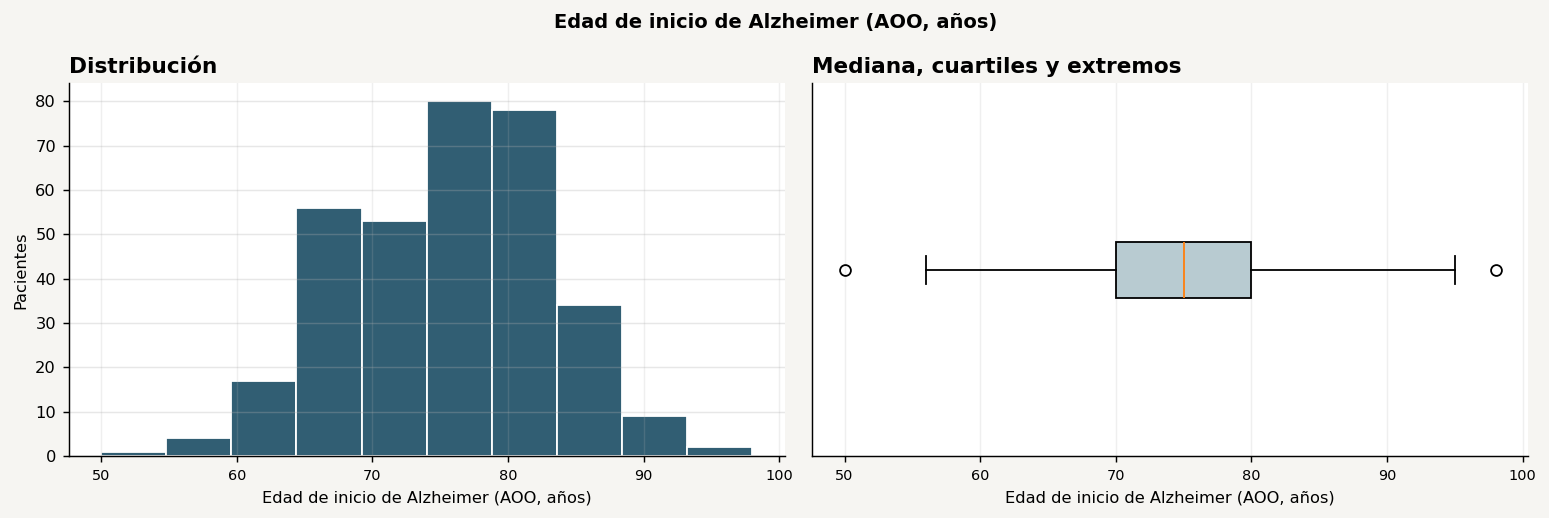

Casos marcados para revisión de coherencia: 16


,estado,n
0,Sin inconsistencia,318
1,AOO no disponible,57
2,Inconsistente solo en hxgen,8
3,Inconsistente en ambas fuentes,5
4,Inconsistente solo en neuro,3


In [109]:
n_total=len(base_full); n_aoo=base_full['aoo'].notna().sum()
display(pd.DataFrame([{'cohorte_total':n_total,'AOO_disponible':n_aoo,
                       'AOO_faltante':n_total-n_aoo,'disponibilidad_pct':round(100*n_aoo/n_total,1)}]))
display(resumen_numerico(base_full['aoo']))
display(tabla_frecuencias_numerica(base_full['aoo']))
grafico_numerico(base_full['aoo'],'Edad de inicio de Alzheimer (AOO, años)')
print('Casos marcados para revisión de coherencia:',int(base_full['estado_consistencia_aoo'].str.startswith('Inconsistente').sum()))
display(base_full['estado_consistencia_aoo'].value_counts(dropna=False).rename_axis('estado').reset_index(name='n'))


#### **Hallazgos principales**

La edad de inicio de la enfermedad de Alzheimer se concentra principalmente entre los 65 y 85 años, con una mayor frecuencia alrededor de los 75–83 años. La mediana se encuentra aproximadamente en 75 años y el 50 % central de los pacientes presenta edades de inicio entre cerca de 70 y 80 años, lo que se observa también en el boxplot. La distribución no presenta una asimetría marcada, aunque existen observaciones en los extremos de aproximadamente 50 y 98 años. Estos valores extremos no se eliminan automáticamente, ya que en el contexto del estudio pueden representar pacientes con inicio particularmente temprano o tardío y, por tanto, podrían ser relevantes para el posterior análisis de variantes genéticas modificadoras de la edad de inicio. Adicionalmente, se identificaron 15 casos marcados para revisión de coherencia entre la AOO y las edades registradas en las fuentes disponibles.

### **21.3. Variables sociodemográficas**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 11


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,genero,Femenino,259,66.8,3
1,IDIOMA,Español,388,100.0,3
2,Nivel educativo,Primaria,182,48.1,4
3,Estado civil,Casado,158,43.4,3
4,Estado Habitacional,"Vive con otra persona: familiar, amigo o compañero de cuarto",119,31.2,3
5,Nivel de independencia,Requiere asistencia para actividades complejas,209,54.1,4
6,Tipo de residencia,"Residencia privada (departamento, condominio, casa)",327,84.5,4
7,Lateralidad,Diestro,383,99.0,3


**Distribuciones**

Variables integradas en la familia: 11
Variables graficadas: 9
Variables resumidas sin gráfico: 2


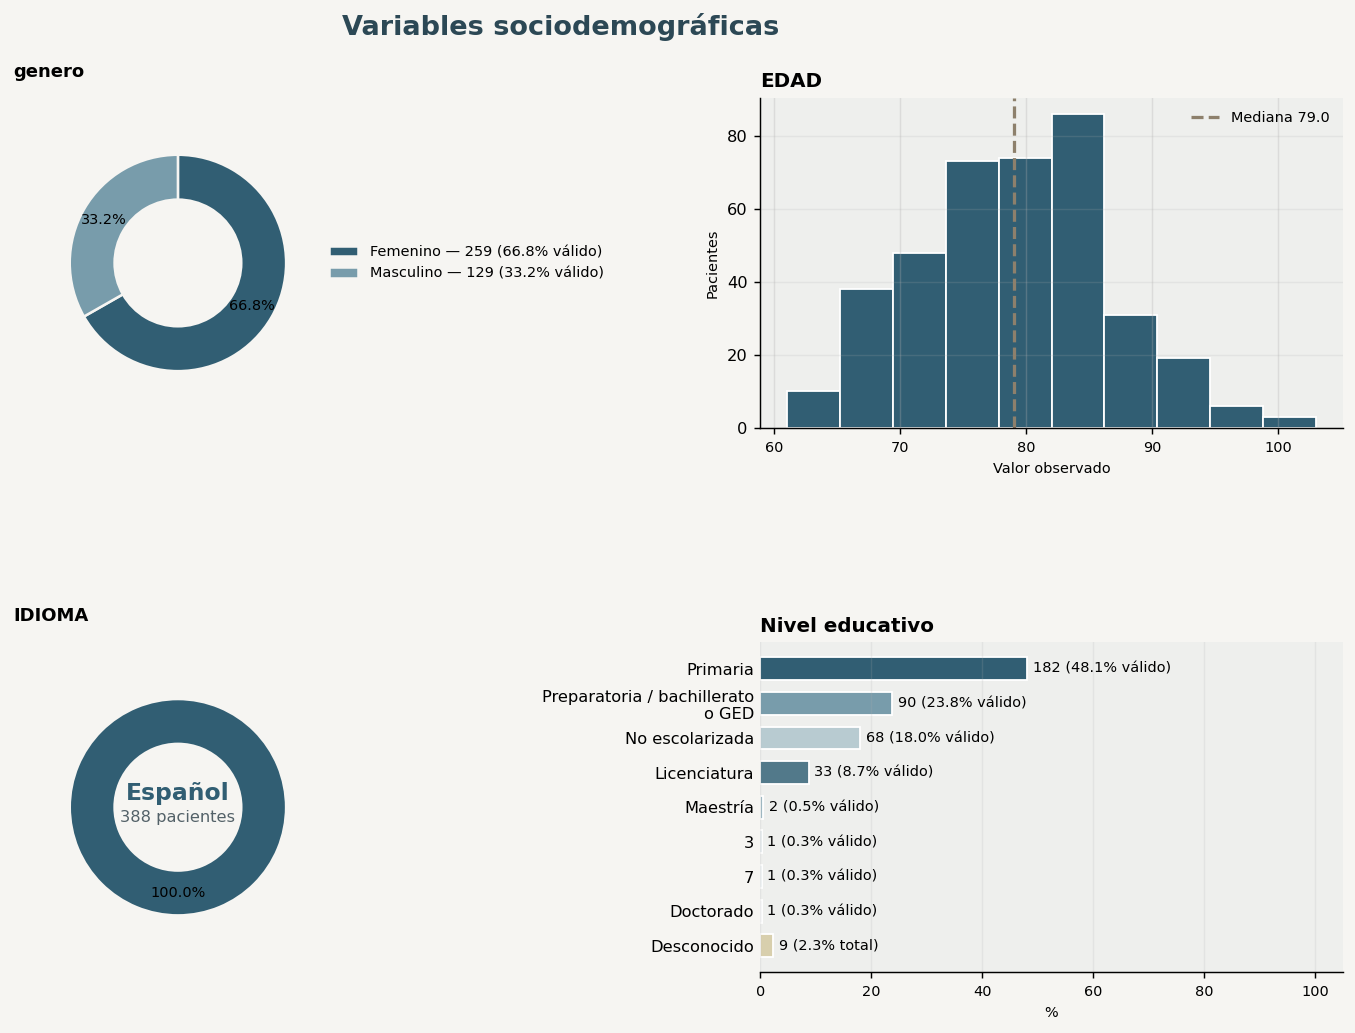

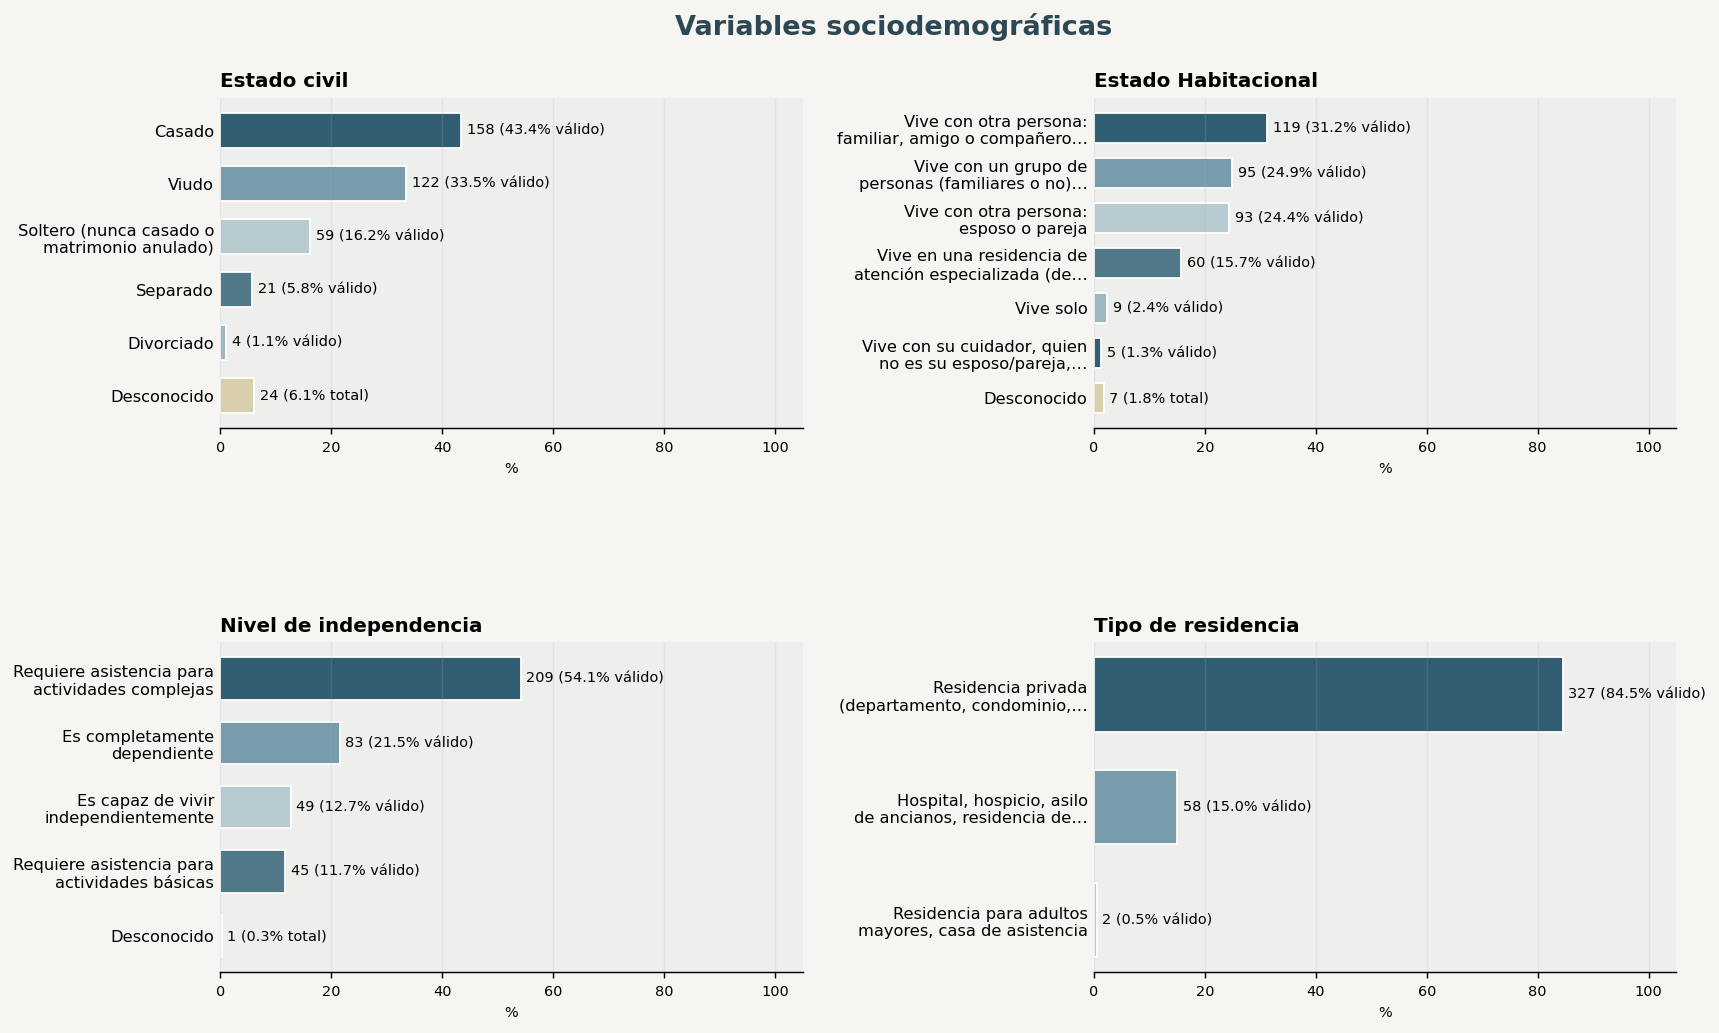

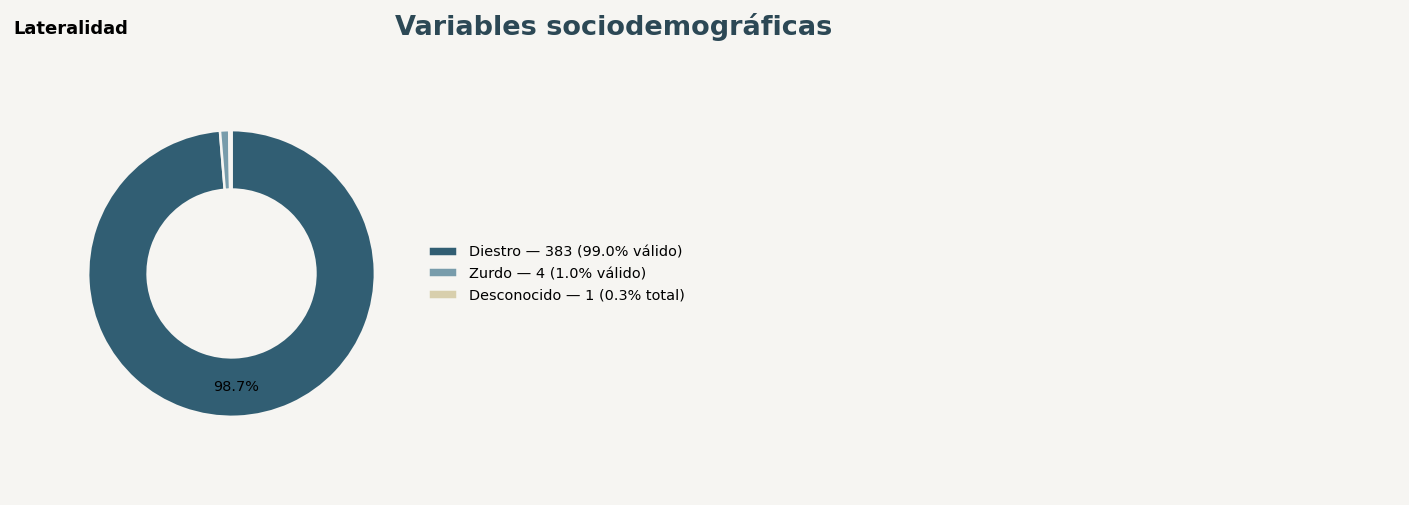

**Variables no graficadas por alta cardinalidad o tipo de dato**

,variable,tipo,n válido,faltantes,n únicos
0,mes y año de nacimiento,texto libre / alta cardinalidad,387,4,374
1,OTRO IDOMA,texto libre / alta cardinalidad,388,3,3


In [110]:
columnas = inventario.loc[
    (inventario["familia"] == "sociodemograficas") &
    (~inventario["tipo_analitico"].isin([
        "identificador",
        "variable auxiliar del EDA"
    ])),
    "columna"
].tolist()

print("Variables integradas en la familia:", len(columnas))

resumen_cat = []

for col in columnas:
    fila = inventario.loc[inventario["columna"].eq(col)]

    if fila.empty:
        continue

    tipo = fila["tipo_analitico"].iloc[0]

    if tipo not in [
        "categórica nominal",
        "categórica binaria",
        "ordinal"
    ]:
        continue

    s = serie_univariada(col)
    t = tabla_cat(s)

    if t.empty:
        continue

    # Se toma como categoría predominante la principal entre los valores válidos, excluyendo Desconocido/No registrado
    validas = t.loc[~t["especial"]]

    principal = (
        validas.iloc[0]
        if len(validas) > 0
        else t.iloc[0]
    )

    resumen_cat.append({
        "variable": etiqueta_bonita(col),
        "categoría predominante": principal["categoria"],
        "n": int(principal["n"]),
        "% válido": round(principal["pct"], 1),
        "faltantes": int(s.isna().sum())
    })

display(Markdown("**Resumen de variables categóricas**"))

if resumen_cat:
    display(
        pd.DataFrame(resumen_cat)
        .reset_index(drop=True)
    )
else:
    print("No se identificaron variables categóricas en esta familia.")

display(Markdown("**Distribuciones**"))

analisis_familia(
    columnas,
    "Variables sociodemográficas"
)

#### **Hallazgos principales**

La cohorte presenta una distribución etaria concentrada principalmente entre los 70 y 85 años, con una mediana cercana a los 79 años, lo que confirma que se trata mayoritariamente de una población adulta mayor. En la variable género, la categoría codificada como 1 concentra aproximadamente dos tercios de los registros válidos (66,8%), mientras que la categoría 0 representa el 33,2%; la interpretación sustantiva de estas categorías debe realizarse una vez se confirme su codificación. El nivel educativo muestra una fuerte concentración en unas pocas categorías, especialmente en los valores 5 y 12, mientras que otras categorías presentan frecuencias muy bajas. De forma similar, el estado civil, el estado habitacional, el nivel de independencia y el tipo de residencia presentan distribuciones desiguales, con una o dos categorías claramente predominantes. En lateralidad se observa una concentración casi total en la categoría 2 (98,7%), lo que indica una variabilidad mínima en esta variable dentro de la cohorte. Dado que varias de estas variables están codificadas numéricamente, estos resultados se interpretan por ahora en términos de distribución de categorías y no de su significado clínico o social hasta validar el diccionario de códigos con el investigador.

### **21.4. Informante y red de apoyo**

Variables integradas en la familia: 5


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,Relación del Informante,"Hijo (consanguíneo, hijastro, adoptado)",172,44.3,3
1,¿Vive el informante con el sujeto?,Sí,261,81.6,4
2,"Si el informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",Diario,242,91.7,5
3,"Si el informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?",Diario,246,93.2,5


**Distribuciones**

Variables integradas en la familia: 5
Variables graficadas: 4
Variables resumidas sin gráfico: 1


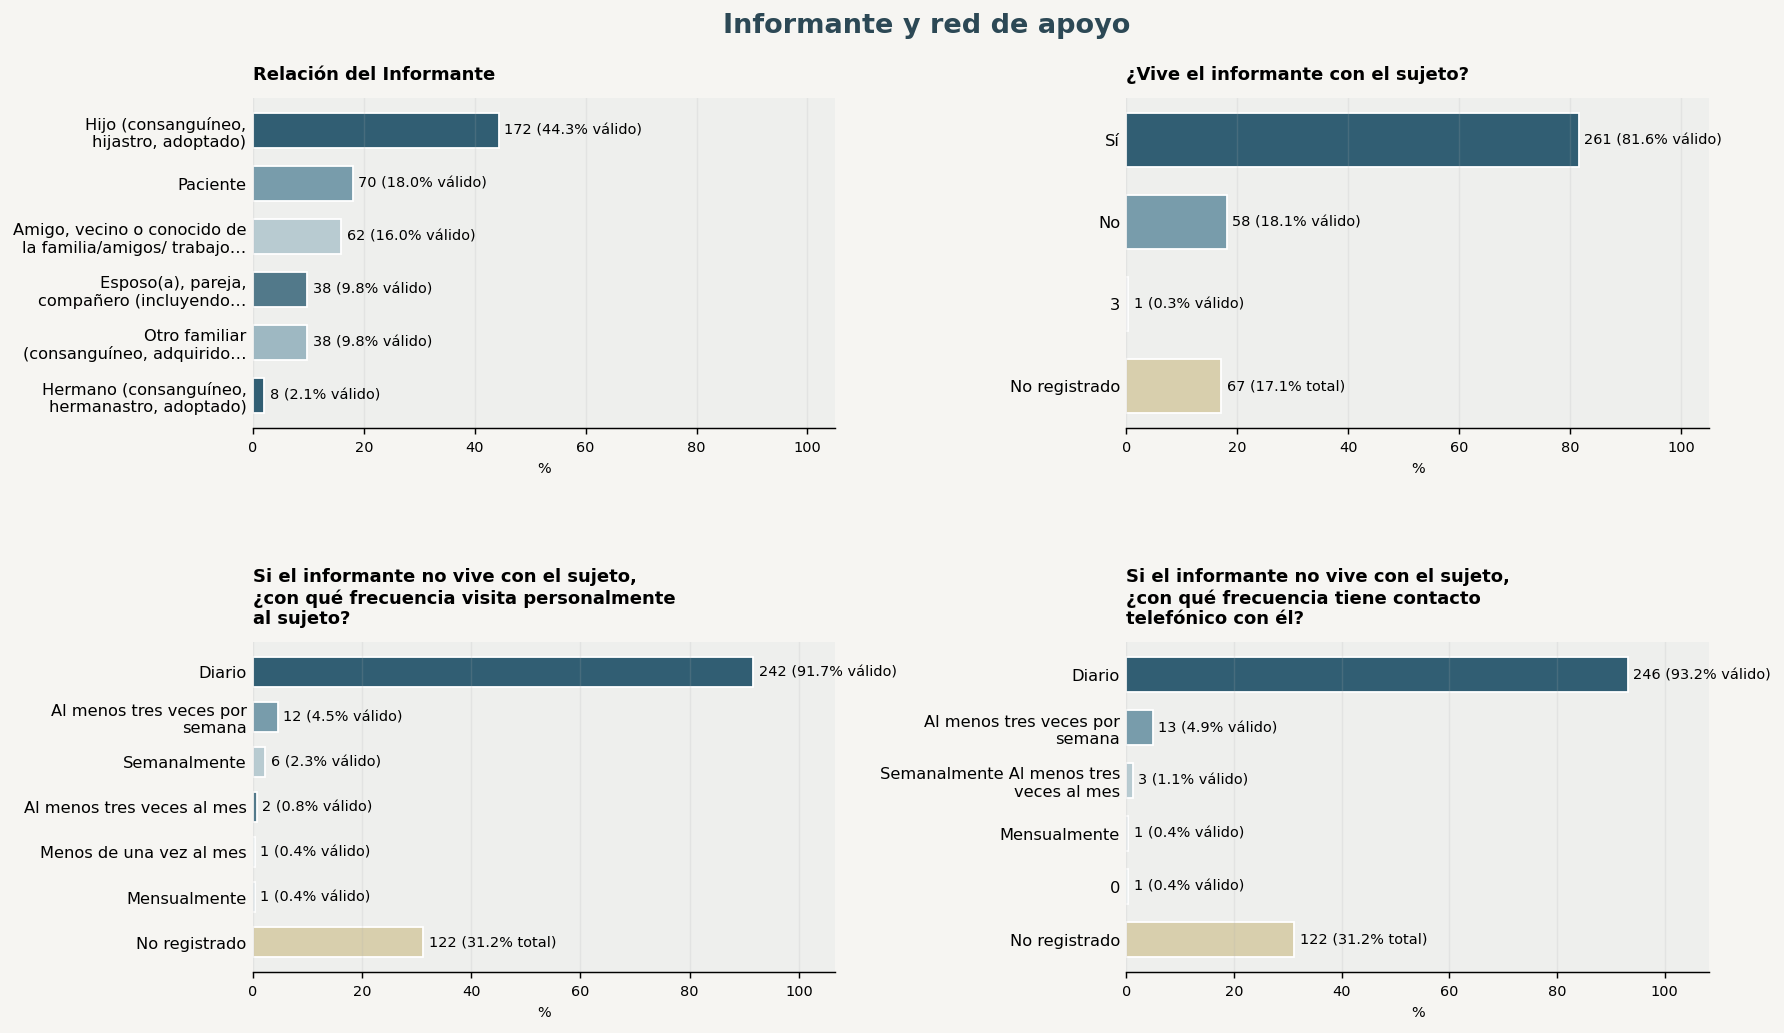

**Variables no graficadas por alta cardinalidad o tipo de dato**

,variable,tipo,n válido,faltantes,n únicos
0,Tiempo (años de conocerce),texto libre / alta cardinalidad,384,7,56


In [122]:
ejecutar_familia("informante_red_apoyo","Informante y red de apoyo")

#### **Hallazgos principales**

La información disponible muestra que la relación del informante con el participante se concentra principalmente en la categoría 2, que representa el 44,6% de los registros válidos, seguida por las categorías 6 y 5. En cuanto a la convivencia, la categoría 1 concentra el 67,3% de los registros válidos, mientras que el 15,1% corresponde a la categoría 0; además, aparece una proporción importante de registros que no indican. Entre los casos en los que se reporta que el informante no vive con el sujeto, la categoría 1 es la más frecuente tanto para las visitas personales (62,5%) como para el contacto telefónico (63,5%). Sin embargo, la interpretación sustantiva de estas categorías debe quedar pendiente hasta validar con el investigador qué significa cada código.

### **21.5. Historia familiar**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 2


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,"¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres),...",No,233,63.3,5
1,Familiar afectado,0,59,31.1,4


**Distribuciones**

Variables integradas en la familia: 2
Variables graficadas: 2
Variables resumidas sin gráfico: 0


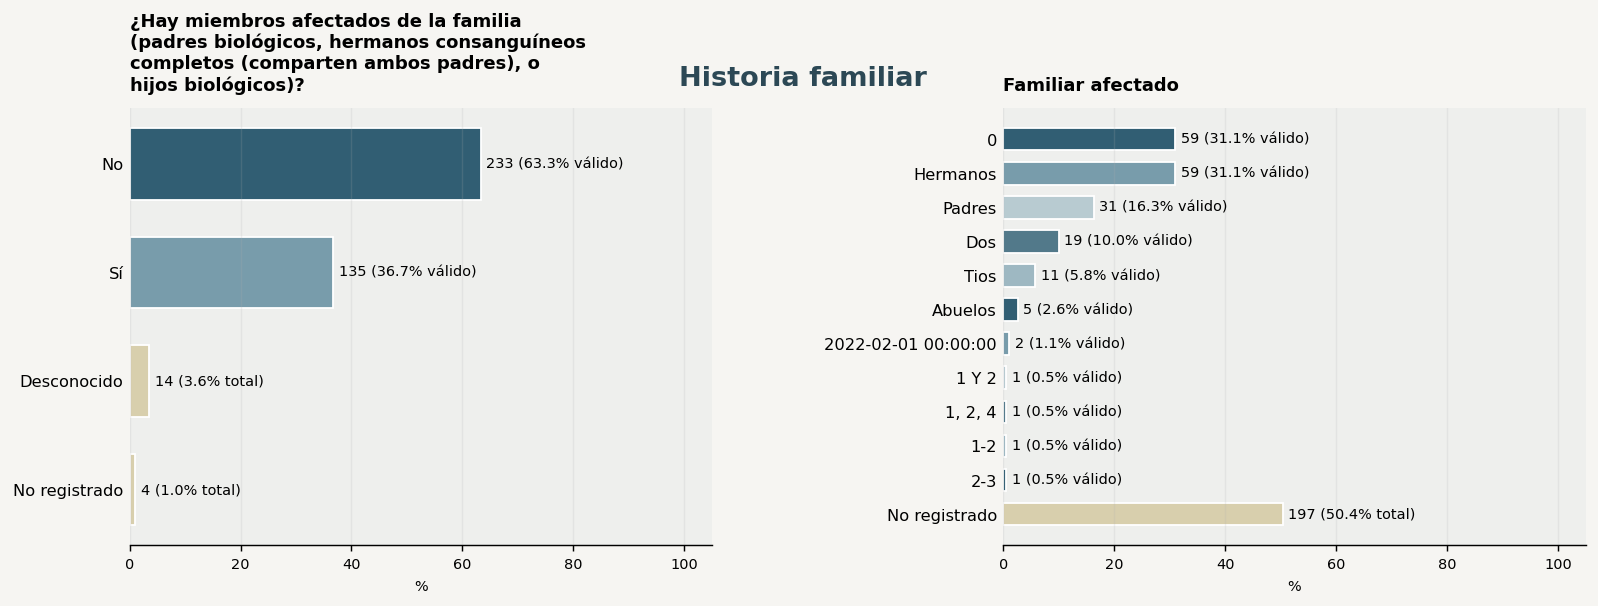

In [123]:
ejecutar_familia("historia_familiar","Historia familiar")

#### **Hallazgos principales**

En la variable sobre presencia de familiares biológicos afectados, la categoría 0 concentra el 60,2% de los registros y la categoría 1 el 34,9%. También aparecen algunos registros codificados como 9, NO y -; en este último caso, el guion corresponde a información no registrada para el paciente. En la variable Familiar afectado, el 50,9% de los registros no cuenta con información registrada, mientras que entre los casos con dato disponible predominan las categorías 0 y 2, cada una con 15,3%. Dado que esta información puede ser relevante para el componente genético del estudio, conviene validar el significado de los demás códigos y homologar las categorías antes de realizar análisis asociativos.

### **21.6. Antropometría**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 2


**Distribuciones**

Variables integradas en la familia: 2
Variables graficadas: 2
Variables resumidas sin gráfico: 0


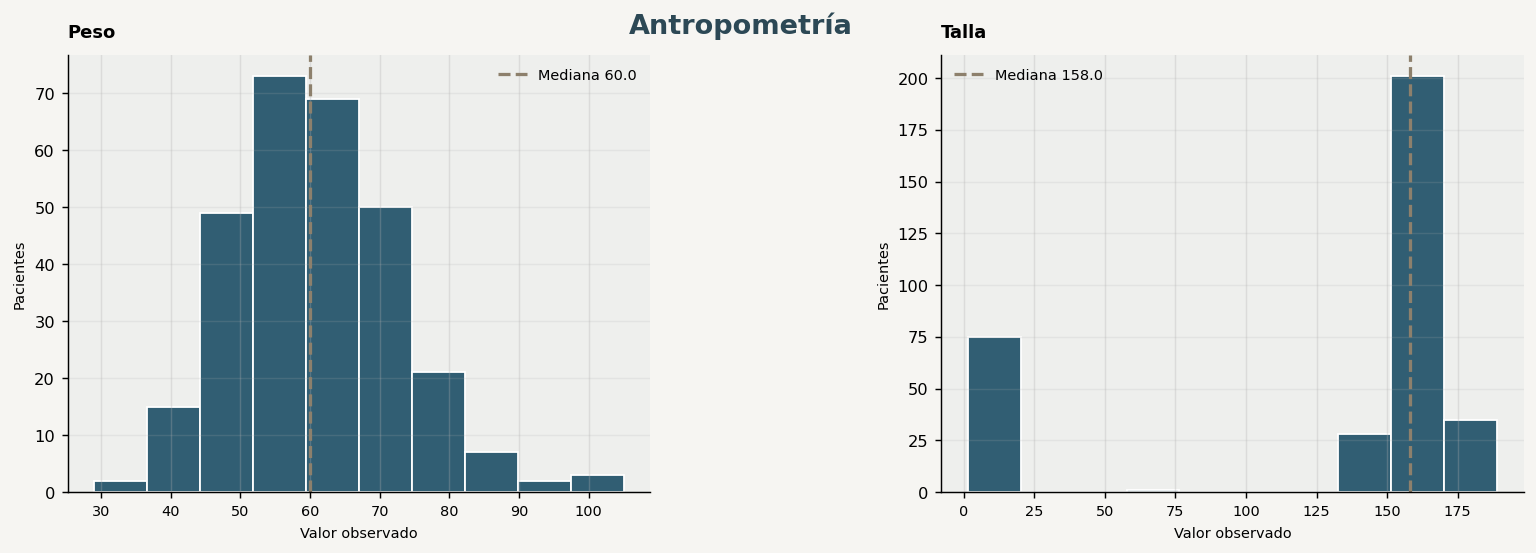

In [126]:
ejecutar_familia("antropometria","Antropometría")

#### **Hallazgos principales**

El peso presenta una distribución unimodal, con mayor concentración aproximadamente entre 50 y 75 kg y una mediana de 60 kg. La mayor parte de los pacientes se agrupa alrededor de valores intermedios, aunque se observan algunos registros en los extremos bajos y altos que conviene revisar individualmente antes de decidir si corresponden a valores reales o posibles errores de registro.

En la talla, la mediana se sitúa en 158 cm y la mayoría de los registros se concentra aproximadamente entre 145 y 175 cm. Sin embargo, la distribución muestra un grupo separado de valores muy bajos, cercanos a 0–20, claramente incompatibles con el rango esperado si toda la variable estuviera expresada en centímetros. Esto sugiere una posible mezcla de unidades, por ejemplo registros en metros y otros en centímetros, o errores de digitación. Antes de utilizar la talla en análisis posteriores, es necesario revisar y homogeneizar la unidad de medida.

### **21.7. Medicamentos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



In [127]:
ejecutar_familia("medicamentos","Medicamentos")

Variables integradas en la familia: 9


**Distribuciones**

Variables integradas en la familia: 9
Variables graficadas: 0
Variables resumidas sin gráfico: 9


**Variables no graficadas por alta cardinalidad o tipo de dato**

,variable,tipo,n válido,faltantes,n únicos
0,MEDICAMENTO DEL SUJETO 1,texto libre / alta cardinalidad,386,5,83
1,MEDICAMENTO DEL SUJETO 2,texto libre / alta cardinalidad,385,6,101
2,MEDICAMENTO DEL SUJETO 3,texto libre / alta cardinalidad,385,6,70
3,MEDICAMENTO DEL SUJETO 4,texto libre / alta cardinalidad,386,5,64
4,MEDICAMENTO DEL SUJETO 5,texto libre / alta cardinalidad,386,5,47
5,MEDICAMENTO DEL SUJETO 6,texto libre / alta cardinalidad,386,5,33
6,MEDICAMENTO DEL SUJETO 7,texto libre / alta cardinalidad,386,5,23
7,MEDICAMENTO DEL SUJETO 8,texto libre / alta cardinalidad,386,5,15
8,MEDICAMENTO DEL SUJETO 9,texto libre / alta cardinalidad,385,6,15


#### **Hallazgos principales**

Las variables de medicamentos presentan una alta cardinalidad, especialmente en las primeras posiciones del registro. El primer medicamento tiene 86 valores únicos y el segundo 103, mientras que la diversidad disminuye progresivamente hasta 15 valores únicos en los medicamentos 8 y 9. Esto indica que no es conveniente analizar cada columna como una variable categórica convencional mediante gráficos de barras, porque se generarían demasiadas categorías y la interpretación sería poco útil.

Además, en varias posiciones el valor modal es -, que en esta base corresponde a información no registrada para el paciente. En el primer medicamento, en cambio, el valor más frecuente registrado es losartán, lo que sugiere que este fármaco aparece con relativa frecuencia dentro de la cohorte. Sin embargo, estas columnas deben interpretarse con cautela, ya que la posición “Medicamento 1”, “Medicamento 2”, etc. no representa necesariamente una categoría clínica distinta, sino diferentes espacios disponibles para registrar tratamientos.

### **21.8. Tabaquismo y hábitos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.

Para los años de tabaquismo, el código 99 se presenta como faltante en la vista univariada. Se mantiene sin cambios la columna original.



Variables integradas en la familia: 3


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,El sujeto ha fumado en los pasados 30 días,No,374,98.9,3
1,¿El sujeto ha fumado más de 100 cigarros / cigarrillos en su vida?,No,276,74.0,3


**Distribuciones**

Variables integradas en la familia: 3
Variables graficadas: 3
Variables resumidas sin gráfico: 0


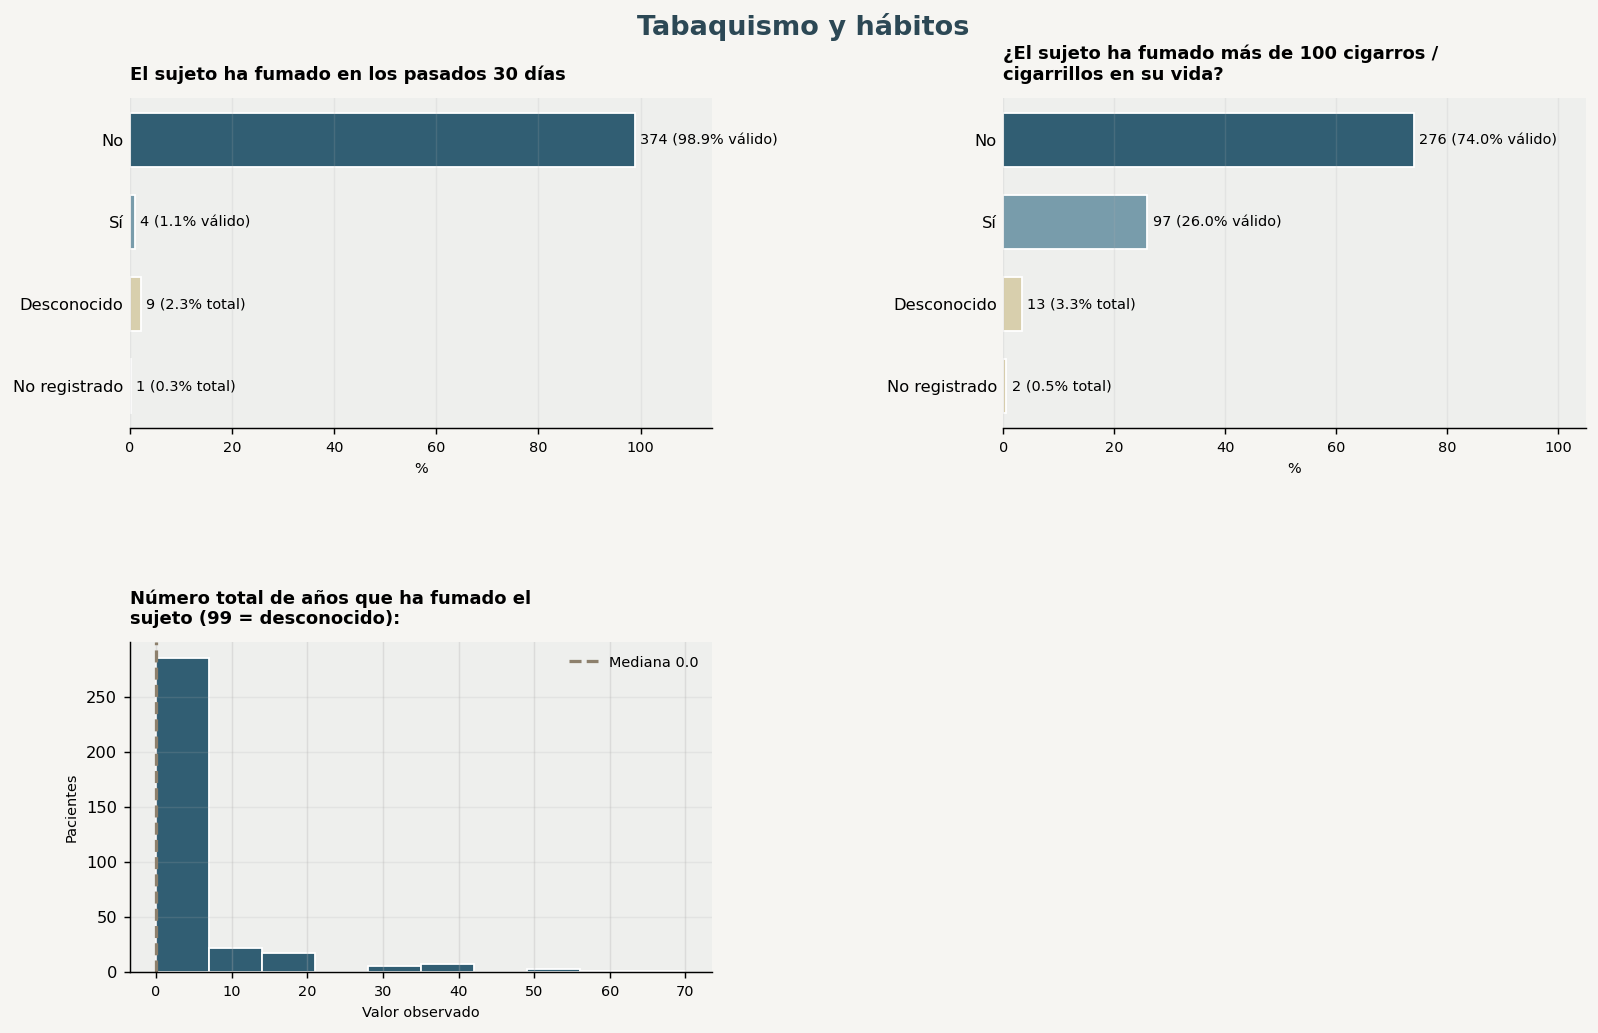

In [128]:
ejecutar_familia("tabaquismo","Tabaquismo y hábitos")

#### **Hallazgos principales**

En relación con el tabaquismo reciente, la gran mayoría de los participantes se encuentra en la categoría 0 (96,4%), mientras que la categoría 1 representa solo el 1,0%. La categoría 9 corresponde a desconocido y el símbolo - a dato no registrado, por lo que ambos deben tratarse como información faltante y no como categorías clínicas.

Para el antecedente de haber fumado más de 100 cigarrillos a lo largo de la vida, el 71,0% está en la categoría 0 y el 25,1% en la categoría 1, mientras que el 3,4% corresponde a 9 = desconocido. Esto sugiere que, aunque el tabaquismo reciente es poco frecuente, sí existe una proporción mayor con antecedente histórico de consumo.

En la variable número total de años fumados, la mediana es 0 años y la distribución está fuertemente concentrada en cero, con una cola hacia valores altos. El código 99 también representa desconocido, por lo que debe recodificarse como faltante antes de cualquier análisis cuantitativo.

### **21.9. Antecedentes cardiovasculares y cerebrovasculares**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 7


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,Ataque cardiaco o paro cardíaco,No,381,98.4,3
1,Fibrilación auricular,0,381,98.4,4
2,Angioplastía/ endarterectomía/ stent,0,388,100.0,3
3,Bypass cardíaco/coronario,0,388,100.0,3
4,Marcapasos y/o desfibrilador,0,383,98.7,3
5,Insuficiencia cardíaca congestiva,0,384,99.2,4
6,ENFERMEDAD CEREBRO-VASCULAR (ECV),0,377,97.4,4


**Distribuciones**

Variables integradas en la familia: 7
Variables graficadas: 7
Variables resumidas sin gráfico: 0


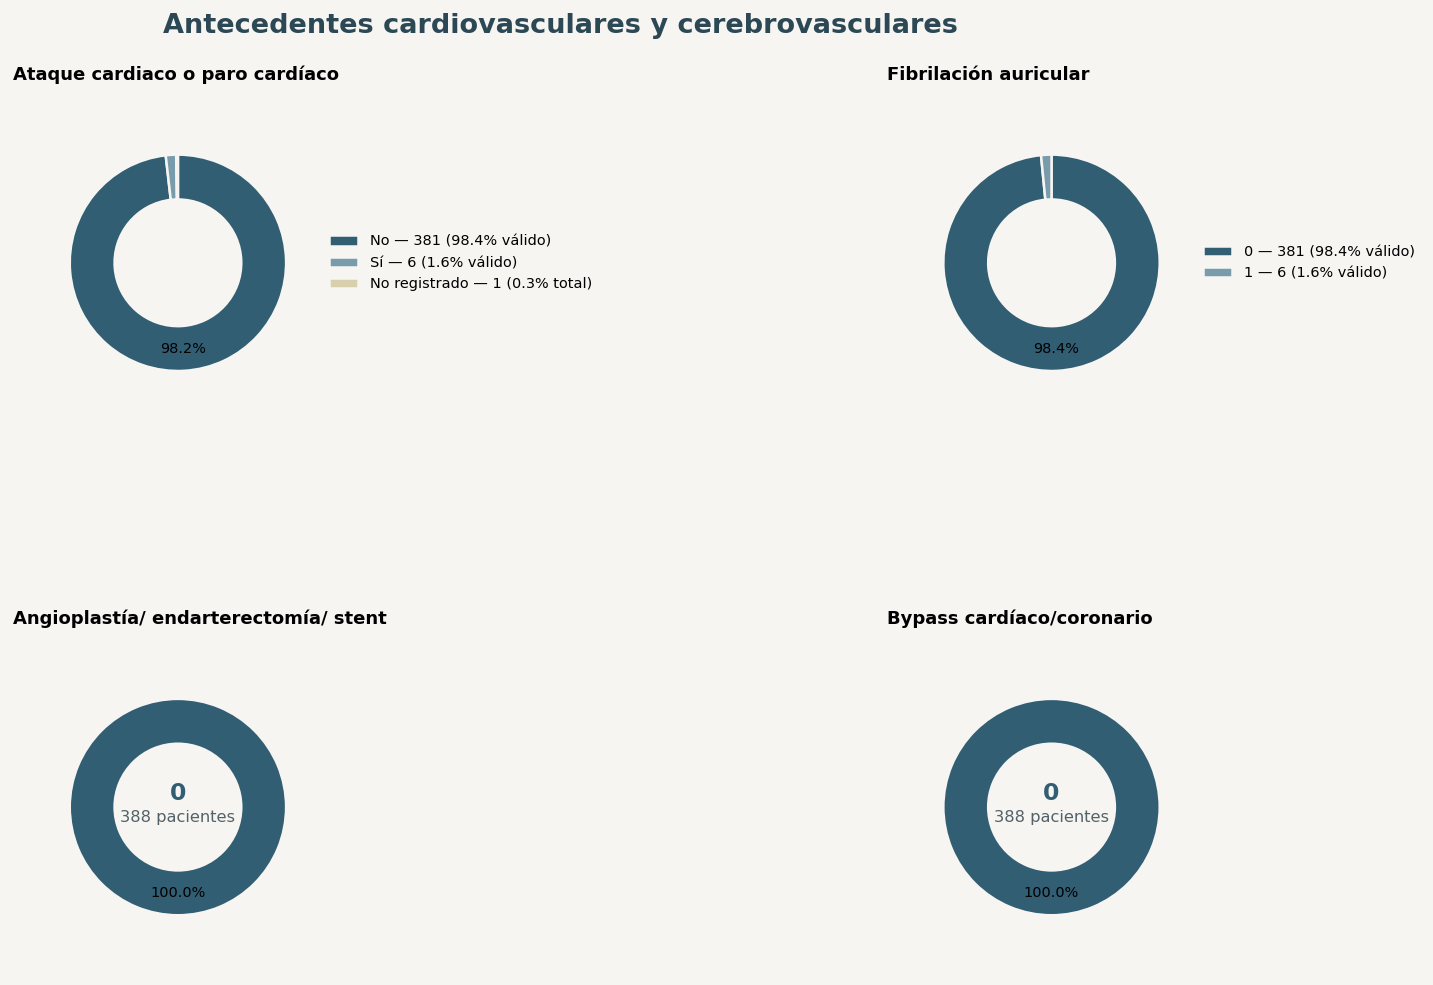

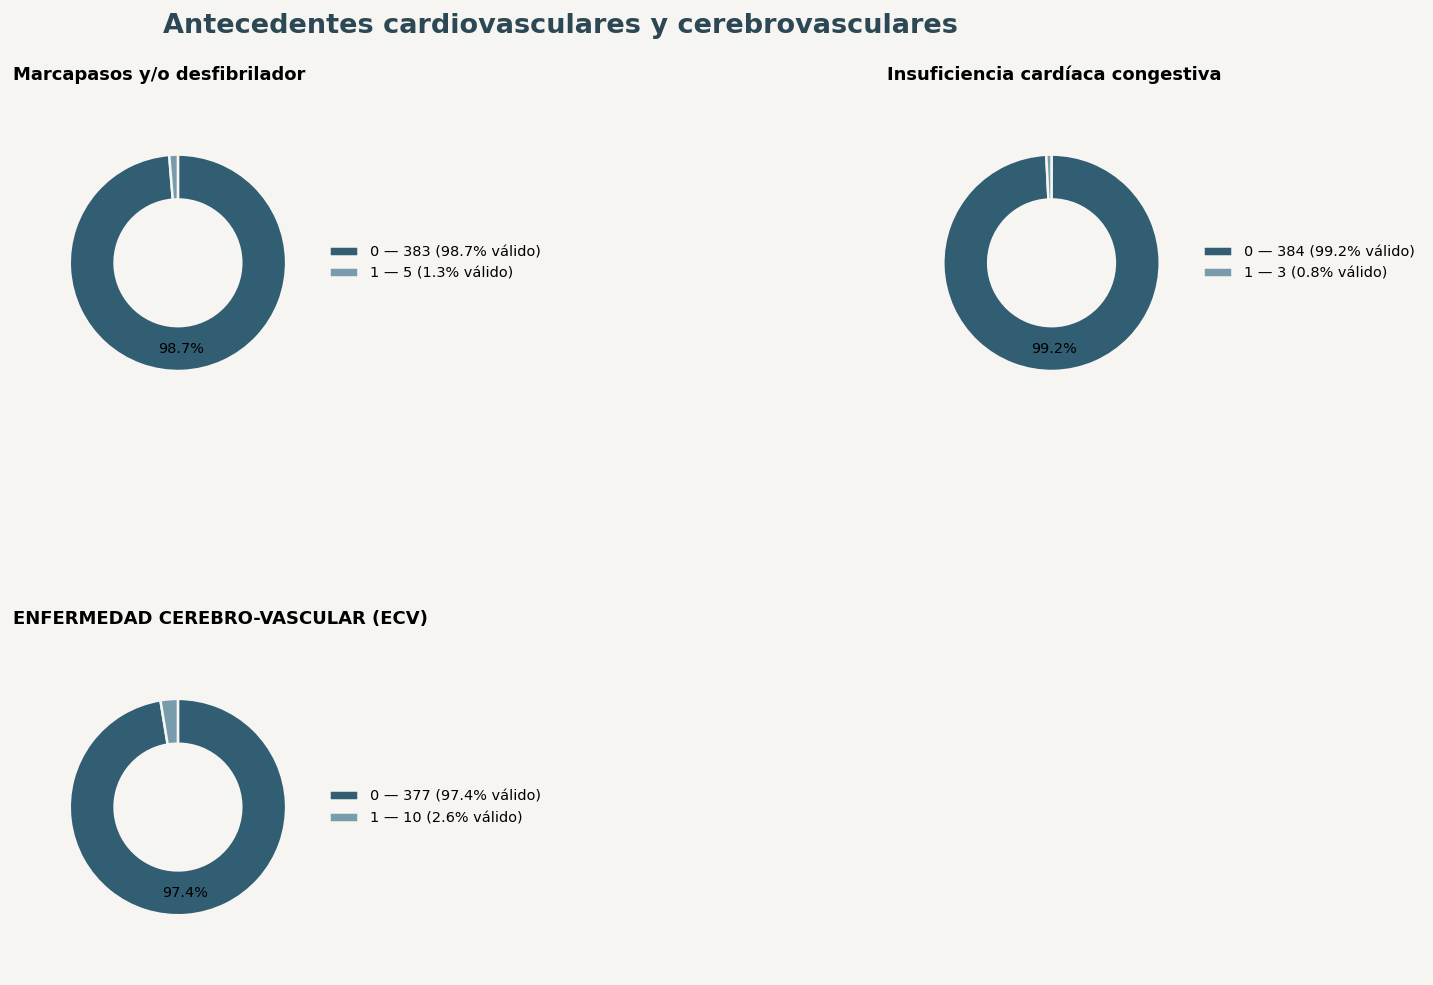

In [129]:
ejecutar_familia("cardiovasculares_cerebrovasculares","Antecedentes cardiovasculares y cerebrovasculares")

#### **Hallazgos principales**

Los antecedentes cardiovasculares y cerebrovasculares presentan una frecuencia baja en la cohorte. El antecedente de ataque cardíaco o paro cardíaco aparece en 6 pacientes (1,6%), al igual que la fibrilación auricular. Los procedimientos de angioplastia, endarterectomía o stent, así como el bypass cardíaco/coronario, no presentan casos positivos registrados en los datos disponibles, por lo que estas variables no muestran variabilidad en la cohorte. El uso de marcapasos o desfibrilador se registra en 5 pacientes (1,3%), mientras que la insuficiencia cardíaca congestiva aparece en 3 pacientes (0,8%). La enfermedad cerebrovascular es el antecedente más frecuente dentro de este grupo, con 10 pacientes (2,6%).

En conjunto, estas variables muestran prevalencias muy bajas, por lo que su capacidad para discriminar diferencias entre pacientes o aportar potencia estadística en análisis posteriores puede ser limitada. Además, en algunas variables aparece -, que corresponde a un dato no registrado y debe tratarse como faltante, no como ausencia del antecedente.

### **21.10. Antecedentes neurológicos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 3


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,PARKINSON,0,385,99.5,4
1,CONVULSIONES,0,384,99.0,3
2,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),0,388,100.0,3


**Distribuciones**

Variables integradas en la familia: 3
Variables graficadas: 3
Variables resumidas sin gráfico: 0


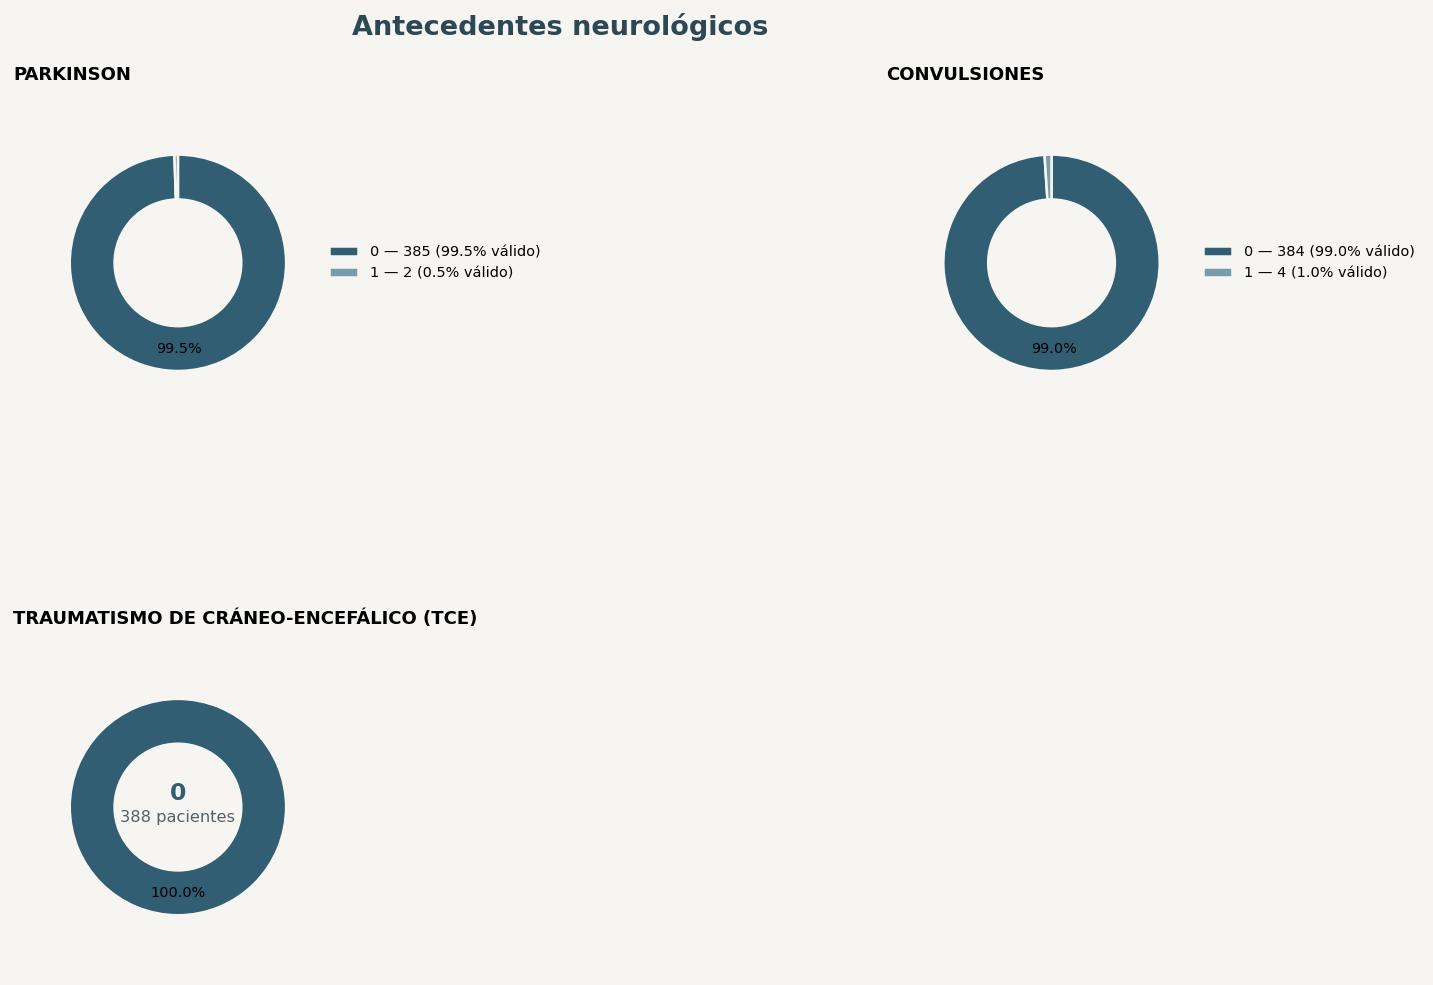

In [130]:
ejecutar_familia("neurologicos","Antecedentes neurológicos")

#### **Hallazgos principales**

Los antecedentes neurológicos son poco frecuentes en la cohorte. El antecedente de Parkinson aparece en 2 pacientes (0,5%) y las convulsiones en 4 pacientes (1,0%). En cuanto al traumatismo craneoencefálico, todos los registros disponibles se encuentran en la categoría 0, por lo que no presenta variabilidad dentro de la muestra analizada.

En conjunto, estas variables aportan principalmente a la caracterización clínica, pero su baja frecuencia limita su capacidad para diferenciar subgrupos o aportar potencia estadística en análisis posteriores. En particular, una variable completamente constante, como el antecedente de TCE en esta cohorte, no podría contribuir a explicar diferencias en AOO dentro de un modelo.

### **21.11. Comorbilidades y condiciones médicas**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 13


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,DIABETES,No,325,84.2,3
1,CANCER,0,380,98.2,4
2,Hipercholesterolemia,0,383,99.2,5
3,Hipertensión arterial,1,213,55.0,4
4,NIVELES DE VITAMINA D,0,388,100.0,3
5,Deficiencia de B12,0,387,99.7,3
6,Enfermedad tiroidea,0,365,94.1,3
7,Artritis,0,386,99.5,3
8,Artrosis,0,363,93.6,3
9,Osteoporosis,0,378,97.4,3


**Distribuciones**

Variables integradas en la familia: 13
Variables graficadas: 13
Variables resumidas sin gráfico: 0


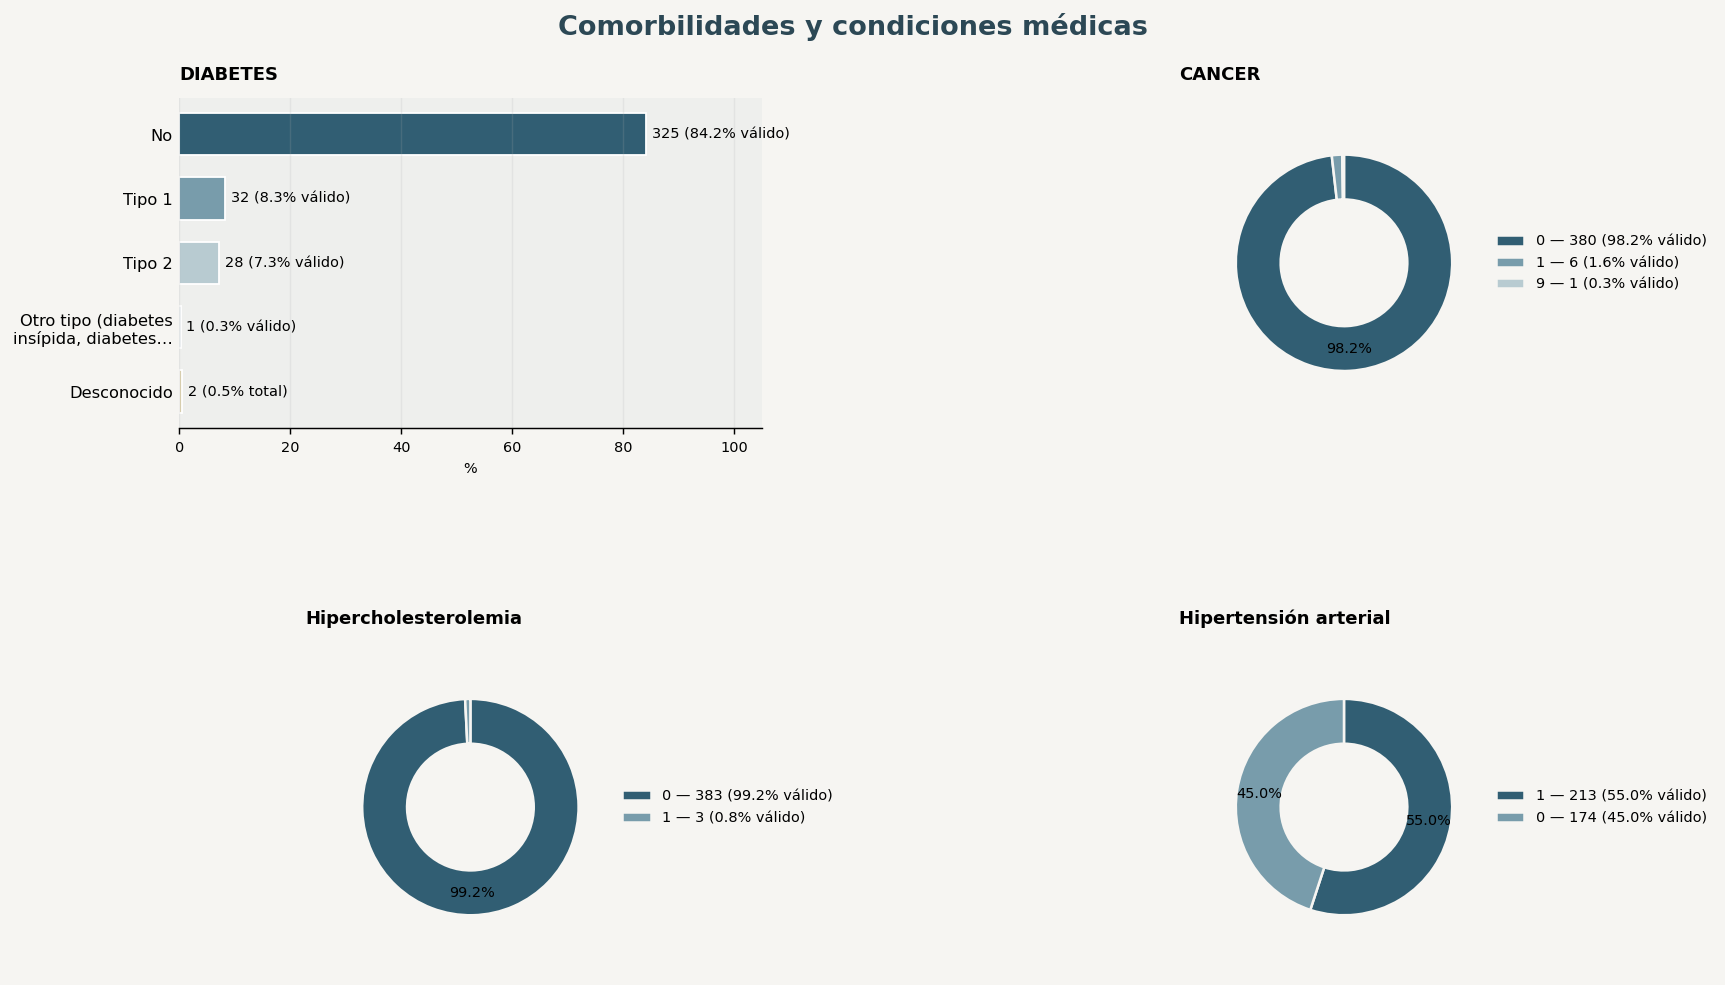

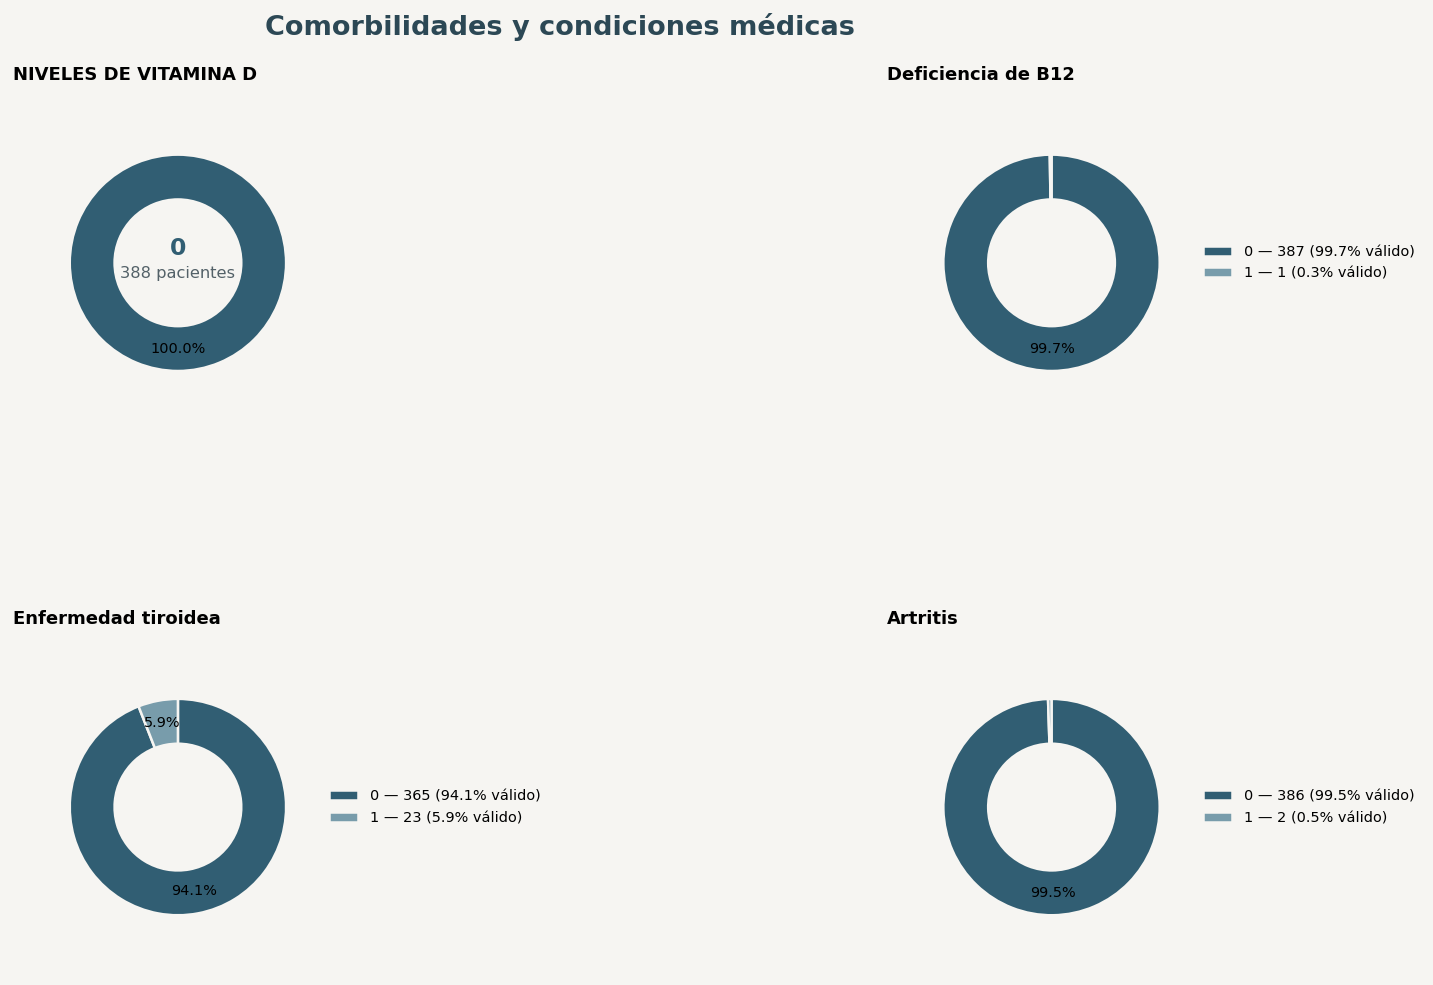

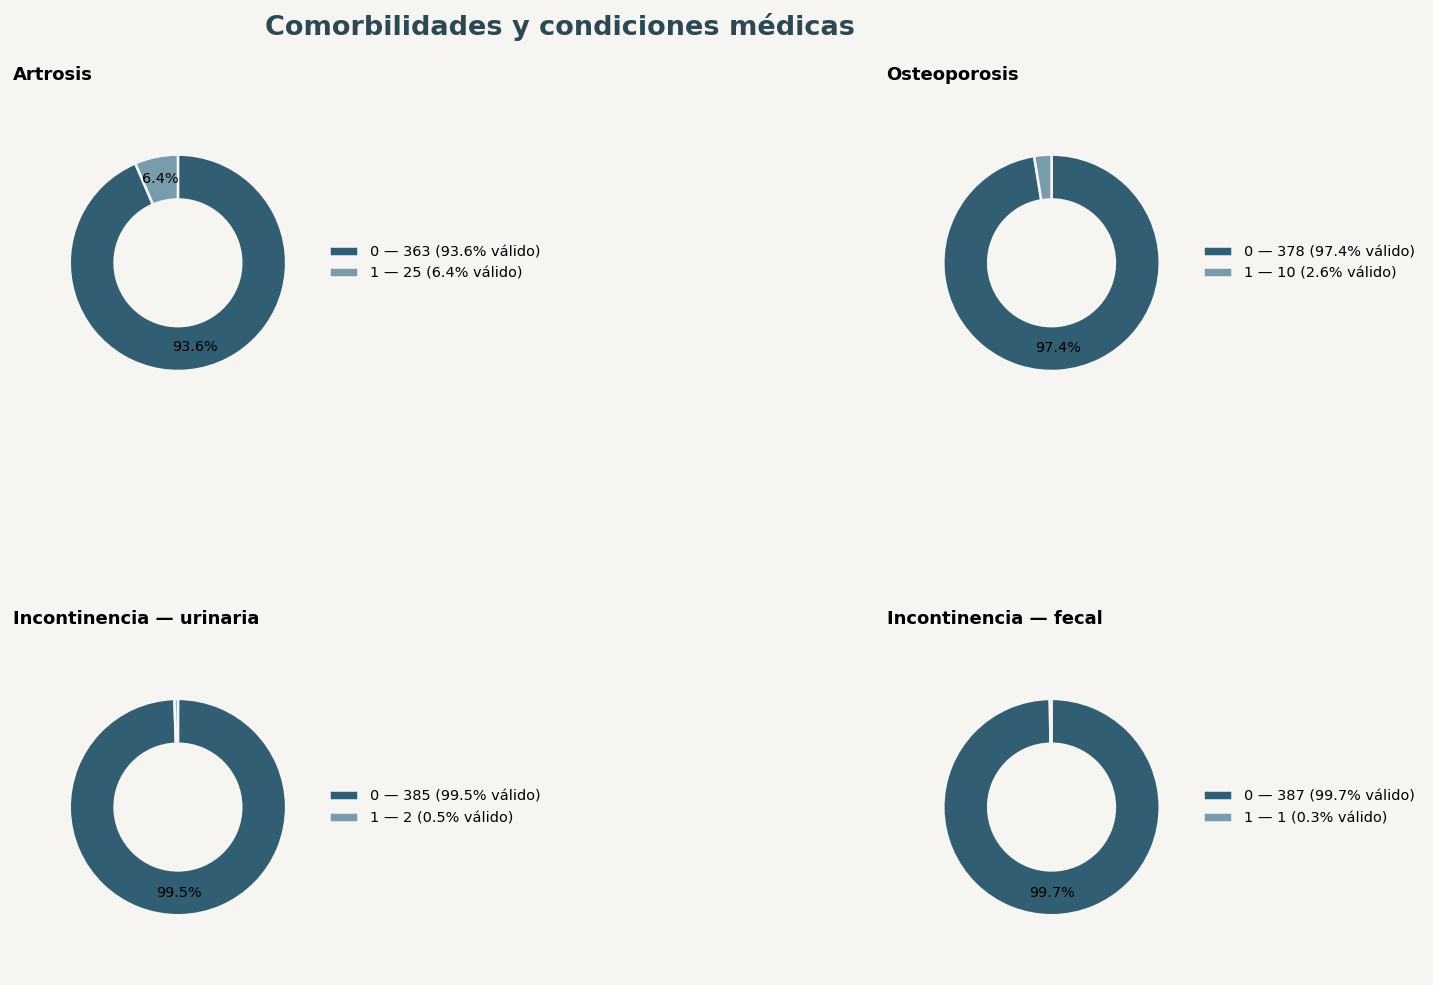

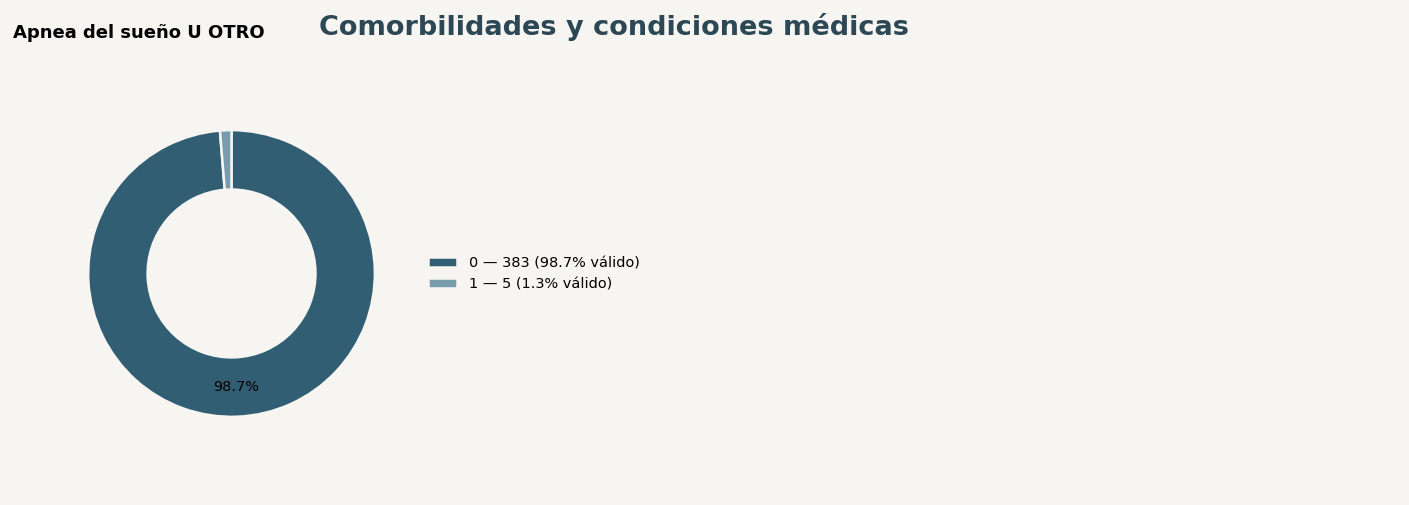

In [131]:
ejecutar_familia("metabolicos_otros","Comorbilidades y condiciones médicas")

#### **Hallazgos principales**

Dentro del grupo de comorbilidades y condiciones médicas, la hipertensión arterial destaca claramente como la condición más frecuente: la categoría 1 representa el 54,8% de los registros válidos, frente al 45,2% en la categoría 0. Esto indica que, a diferencia de muchas otras comorbilidades, la hipertensión sí presenta una frecuencia alta y suficiente variabilidad dentro de la cohorte.

La diabetes muestra una distribución más heterogénea: la categoría 0 concentra el 83,9%, mientras que las categorías 1 y 2 representan el 8,3% y 7,0%, respectivamente. También aparecen los códigos 9 y 3 en proporciones muy bajas. Dado que 9 corresponde a desconocido, y el significado clínico de 1, 2 y 3 debe confirmarse, esta variable requiere validación de su codificación antes de interpretarla como una condición binaria.

El resto de las comorbilidades presenta frecuencias mucho menores. El cáncer aparece en 1,6% de los registros, la hipercolesterolemia en 0,8%, la deficiencia de vitamina B12 en 0,3%, la enfermedad tiroidea en 6,0%, la artritis en 0,5%, la artrosis en 6,5%, la osteoporosis en 2,6%, la incontinencia urinaria en 0,5%, la incontinencia fecal en 0,3% y la apnea del sueño u otra condición relacionada en 1,3%. Los niveles de vitamina D aparecen sin variabilidad, con todos los registros disponibles en la categoría 0.

En conjunto, salvo hipertensión y en menor medida diabetes, enfermedad tiroidea y artrosis, la mayoría de estas variables son poco frecuentes o casi constantes. Esto limita su capacidad para diferenciar subgrupos dentro de la cohorte y su utilidad potencial en análisis posteriores. Además, cualquier uso de estas comorbilidades como covariables de AOO debe considerar primero su temporalidad respecto al inicio del Alzheimer, ya que si fueron registradas después del inicio de la enfermedad podrían introducir riesgo de leakage.

### **21.12. Antecedentes psiquiátricos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 7


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,Trastorno de estrés postraumático (TEPT),0,387,100.0,4
1,Trastorno bipolar,0,388,100.0,3
2,Esquizofrenia,0,384,99.2,4
3,Depresión,0,379,97.9,4
4,Ansiedad,0,382,98.5,3
5,Trastorno obsesivo-compulsivo (TOC),0,388,100.0,3
6,"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención...",0,388,100.0,3


**Distribuciones**

Variables integradas en la familia: 7
Variables graficadas: 7
Variables resumidas sin gráfico: 0


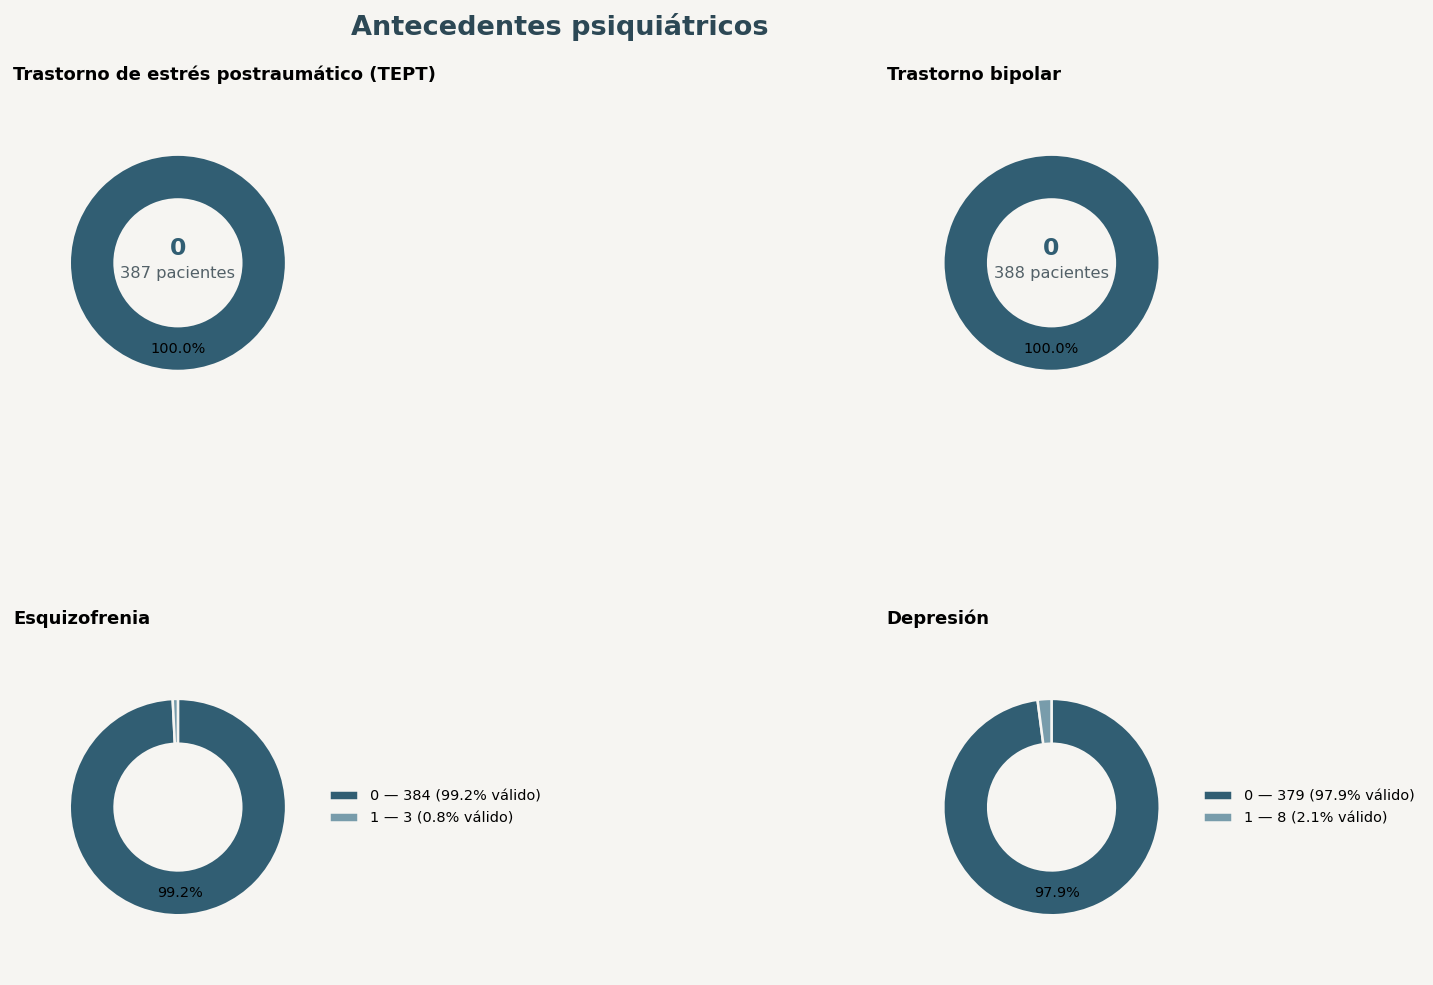

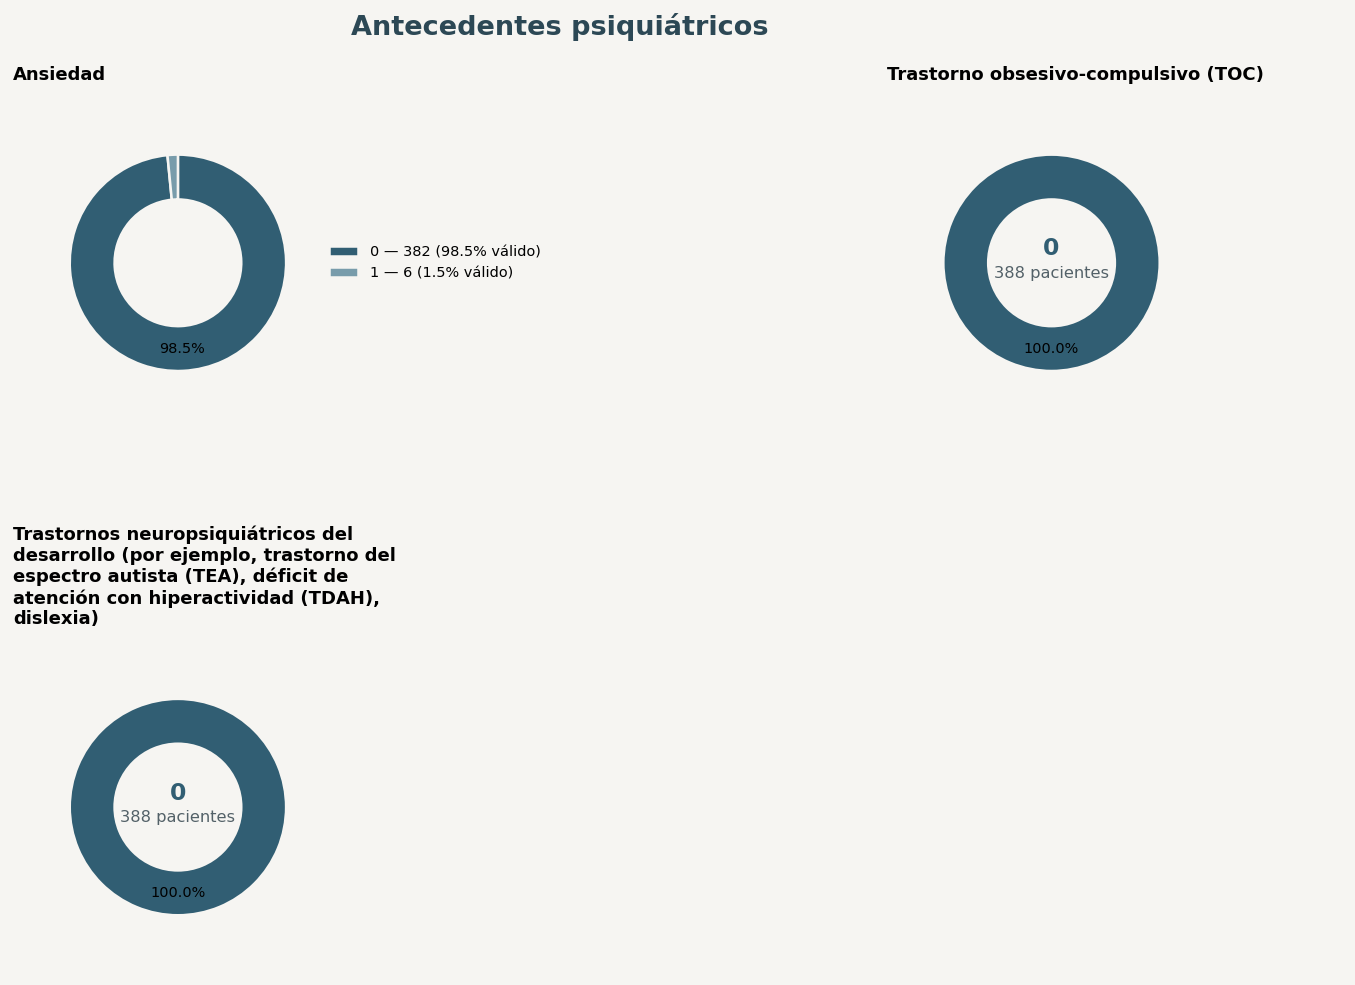

In [132]:
ejecutar_familia("psiquiatricos","Antecedentes psiquiátricos")

#### **Hallazgos principales**

Los antecedentes psiquiátricos son poco frecuentes en la cohorte. No se registran casos positivos de trastorno de estrés postraumático, trastorno bipolar, trastorno obsesivo-compulsivo ni trastornos neuropsiquiátricos del desarrollo en los datos disponibles, por lo que estas variables no presentan variabilidad dentro de la muestra. La esquizofrenia aparece en 3 pacientes (0,8%), la depresión en 8 pacientes (2,1%) y la ansiedad en 6 pacientes (1,6%).

En conjunto, estas condiciones aportan principalmente a la caracterización clínica, pero su baja frecuencia limita su capacidad para diferenciar subgrupos o contribuir de manera importante a análisis posteriores. Además, al igual que con otras comorbilidades, antes de utilizarlas como covariables de AOO debe confirmarse si corresponden a antecedentes previos al inicio del Alzheimer o a condiciones registradas durante una evaluación posterior.

### **21.13. Variables clínicas HXGEN**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 23


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,¿Actualmente se encuentra en algún tratamiento farmacológico?,Sí,322,82.6,1
1,¿Usted fuma?,No,384,98.2,0
2,¿Con que frecuencia consume alcohol?,Nunca,360,92.5,2
3,¿Le han realizado algún procedimiento quirúrgico?,No,318,81.3,0
4,¿Sufre de algún tipo de alergia?,No,379,96.9,0
5,Si la respuesta anterior es SI. ¿A que es alérgico?,Atópica,1,8.3,379
6,¿Alguien más en su familia tiene o tuvo Alzheimer?,No,215,61.8,43


**Distribuciones**

Variables integradas en la familia: 23
Variables graficadas: 10
Variables resumidas sin gráfico: 13


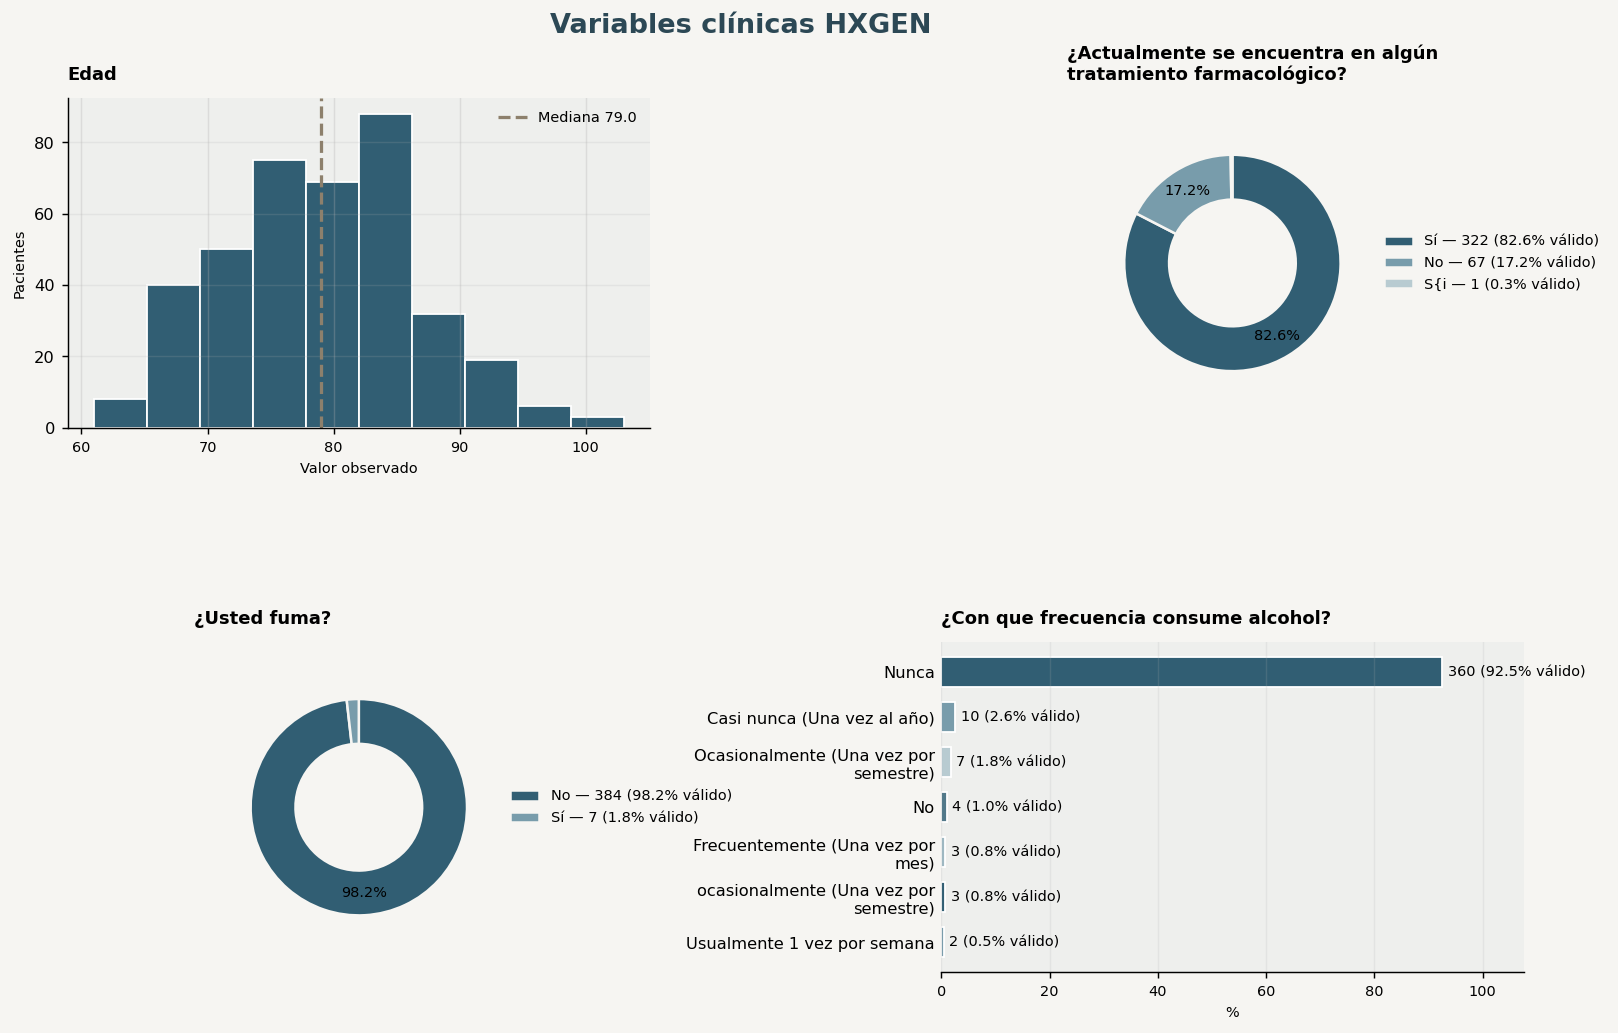

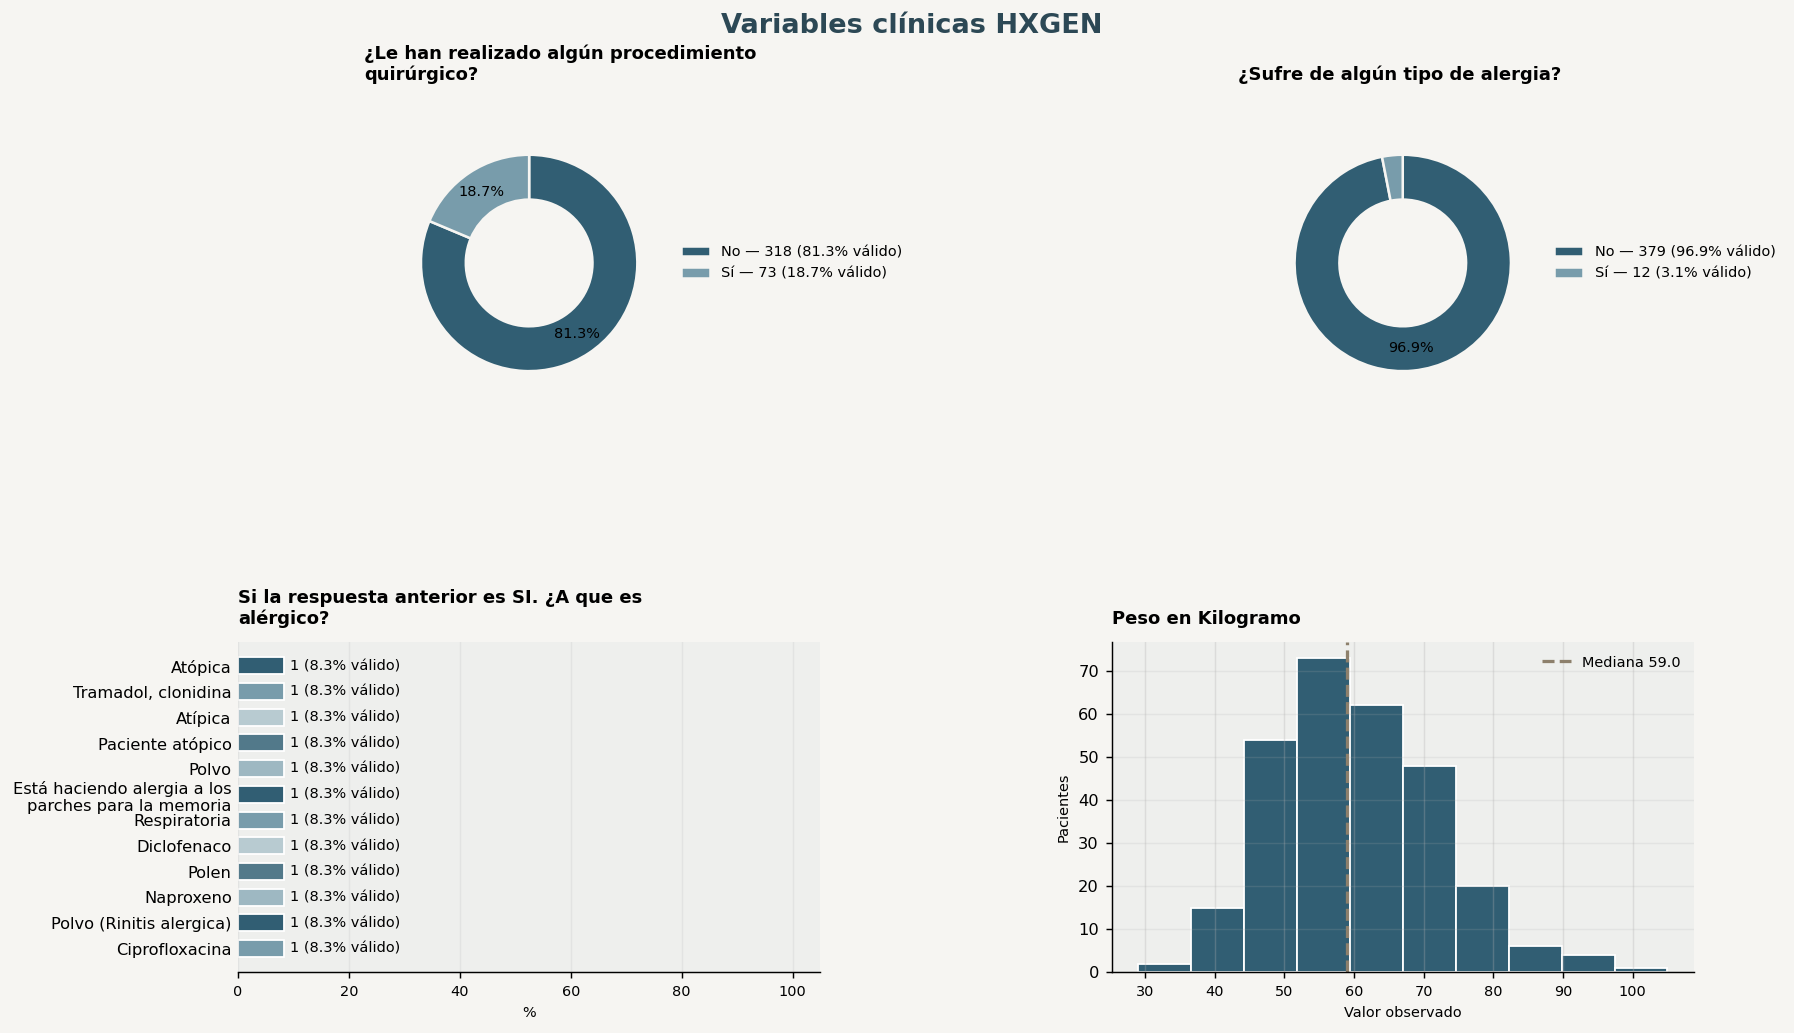

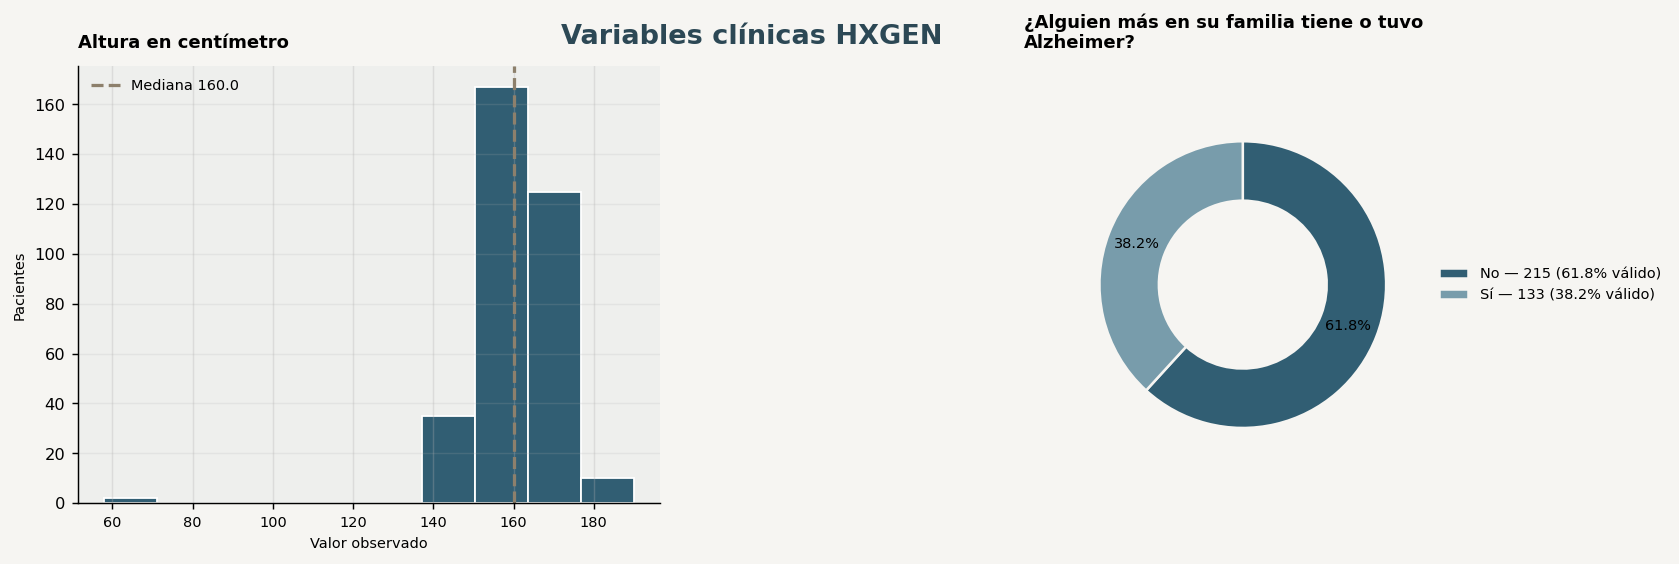

**Variables no graficadas por alta cardinalidad o tipo de dato**

,variable,tipo,n válido,faltantes,n únicos
0,Ciudad o municipio de residencia,texto libre / alta cardinalidad,391,0,78
1,Enfermedad actual,texto libre / alta cardinalidad,391,0,5
2,¿Qué síntomas presenta?,texto libre / alta cardinalidad,391,0,88
3,El Paciente necesita apoyo para realizar las siguientes tareas,texto libre / alta cardinalidad,380,11,38
4,Indique que estudios previos le han realizado.,texto libre / alta cardinalidad,384,7,24
5,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",texto libre / alta cardinalidad,374,17,33
6,Antecedentes,texto libre / alta cardinalidad,299,92,105
7,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",texto libre / alta cardinalidad,323,68,284
8,"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",texto libre / alta cardinalidad,15,376,15
9,Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?,texto libre / alta cardinalidad,75,316,62


In [133]:
ejecutar_familia("historia_clinica_genetica","Variables clínicas HXGEN")

#### **Hallazgos principales**

HXGEN tiene información clínica muy rica, pero aquí el hallazgo más importante es de calidad de datos: muchas respuestas equivalentes están escritas de formas distintas, por ejemplo Sí, SI, Si, si, o No y NO. Antes de interpretar proporciones necesitamos unificarlas. En hábitos, el alcohol destaca porque más del 90% reporta nunca consumir. En antropometría, peso y talla se ven razonables en general, aunque hay algunos valores extremos que conviene revisar. Y en antecedente familiar de Alzheimer también tenemos que homologar las respuestas antes de calcular una proporción real de historia familiar positiva.

### **21.14. Variables neuropsicológicas por dominio**

Primero se revisa calidad, rango, variabilidad y redundancia ya explorada en la sección 20. MMSE, MoCA y FAST reciben un panel conjunto y tablas descriptivas. Las demás pruebas se resumen por dominio, sin generar un gráfico por prueba. Sus valores pueden reflejar mediciones posteriores al inicio; `riesgo_leakage_aoo` se conserva como referencia para etapas posteriores, sin excluirlas del EDA.



**Cognición global**

Variables integradas en la familia: 3


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,ESC DETERIOROGLOBAL,DÉFECIT COGNTIVO MODERADO,319,82.4,4


**Distribuciones**

Variables integradas en la familia: 3
Variables graficadas: 3
Variables resumidas sin gráfico: 0


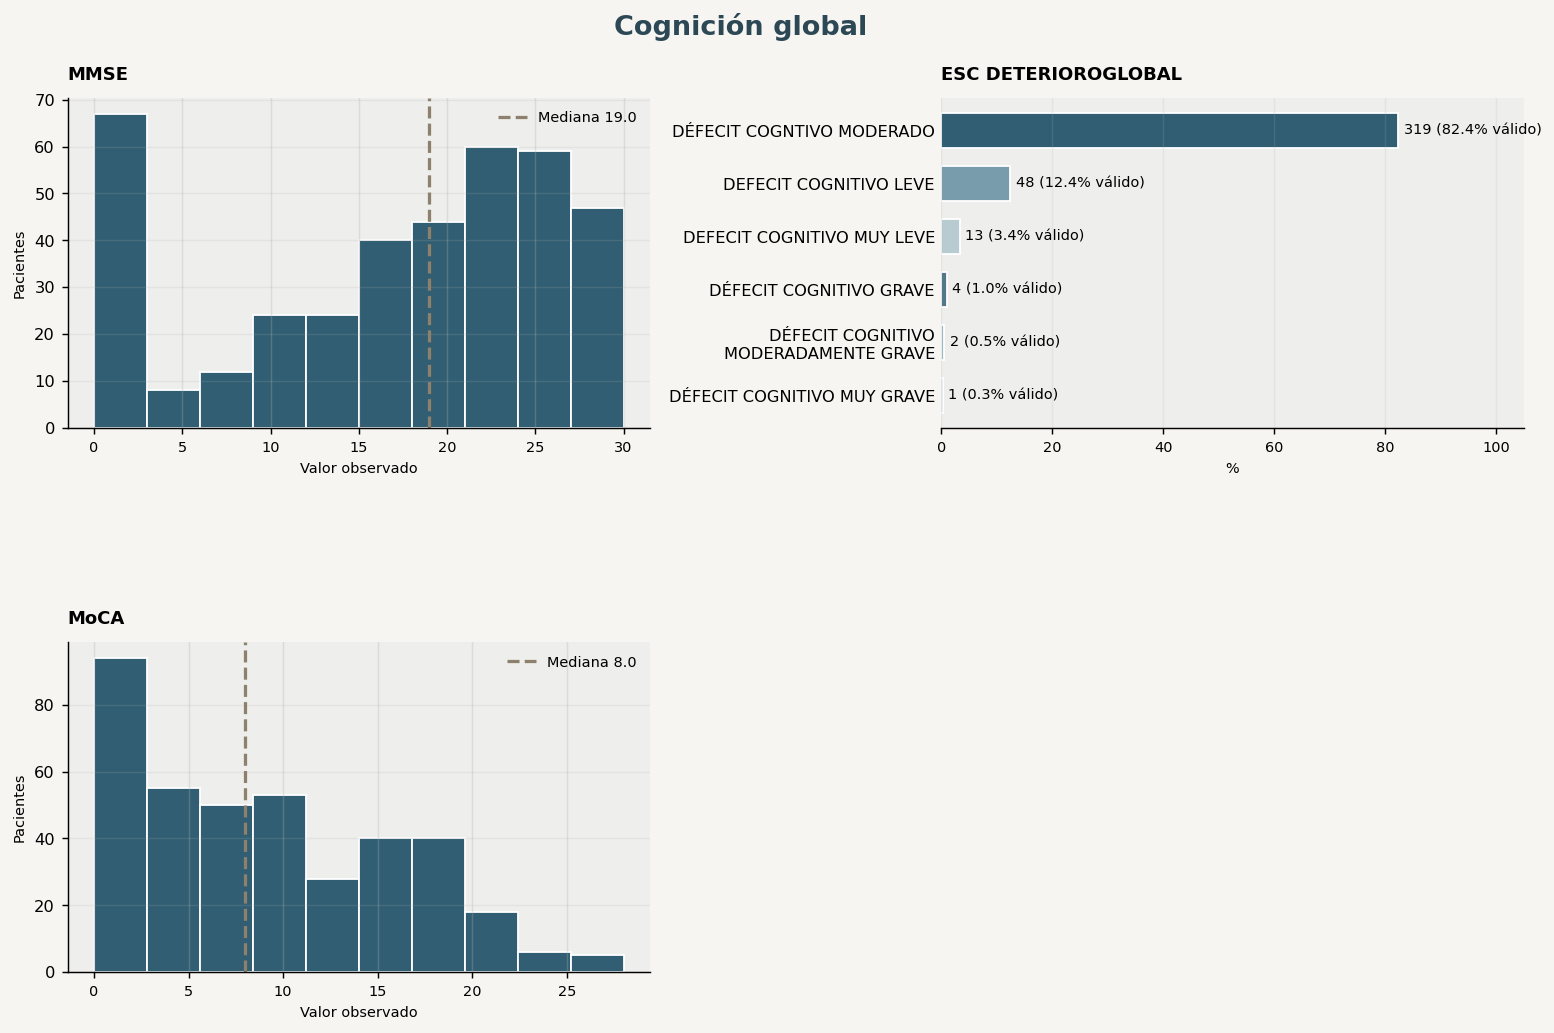

**Memoria**

Variables integradas en la familia: 11


**Distribuciones**

Variables integradas en la familia: 11
Variables graficadas: 11
Variables resumidas sin gráfico: 0


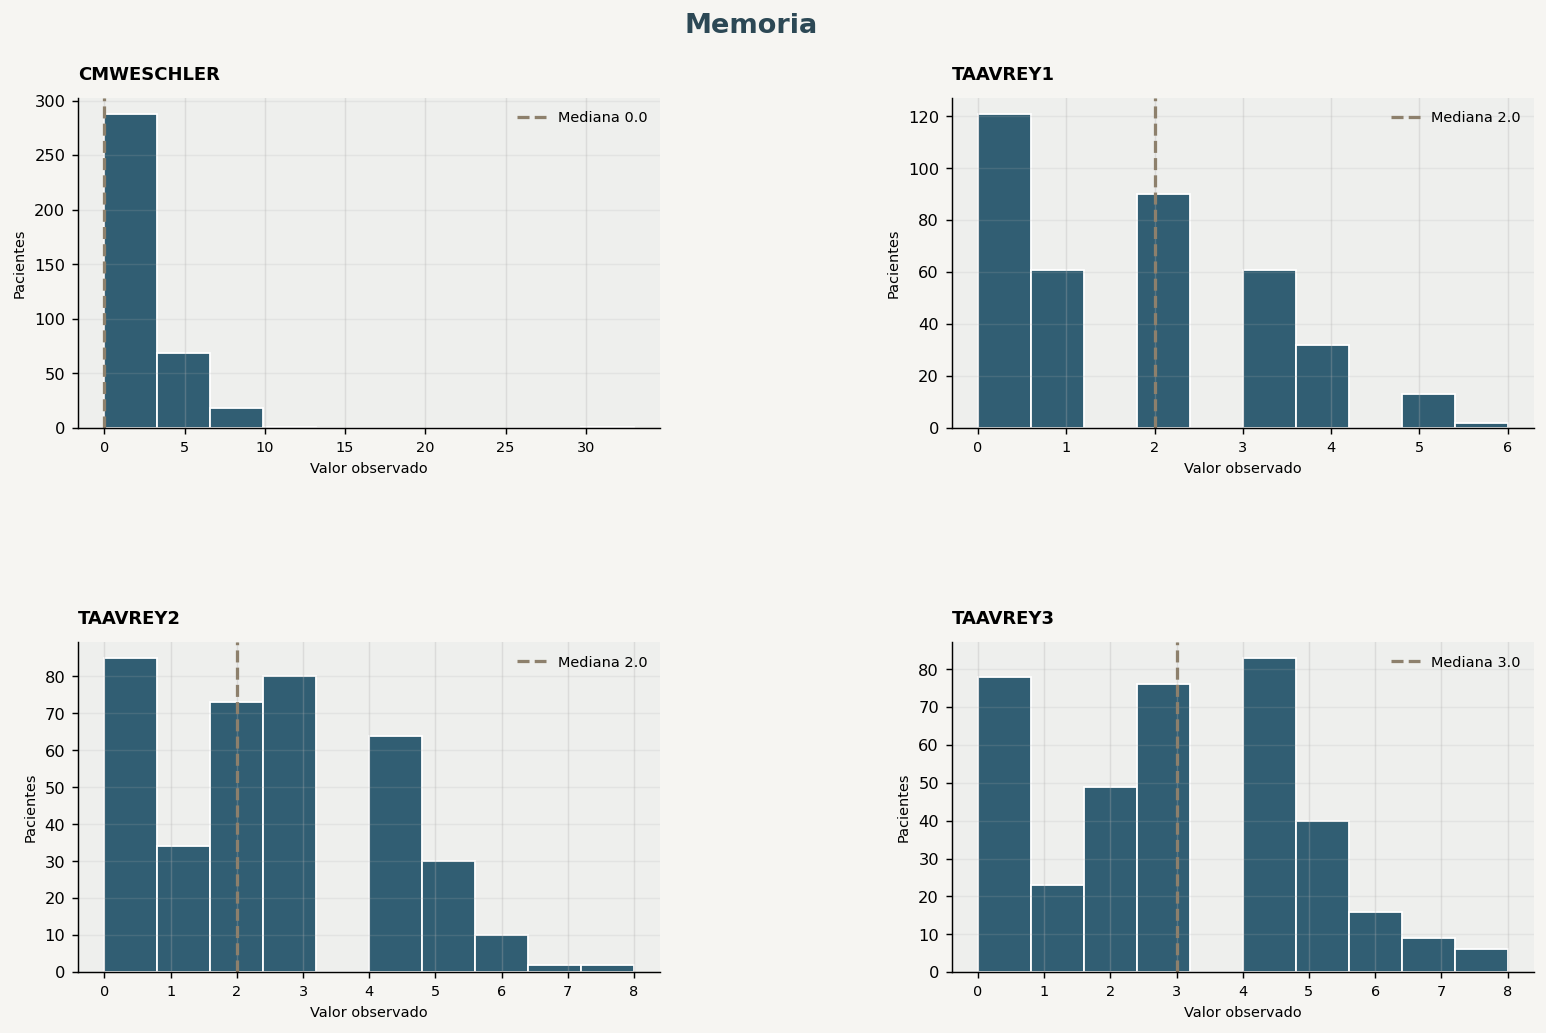

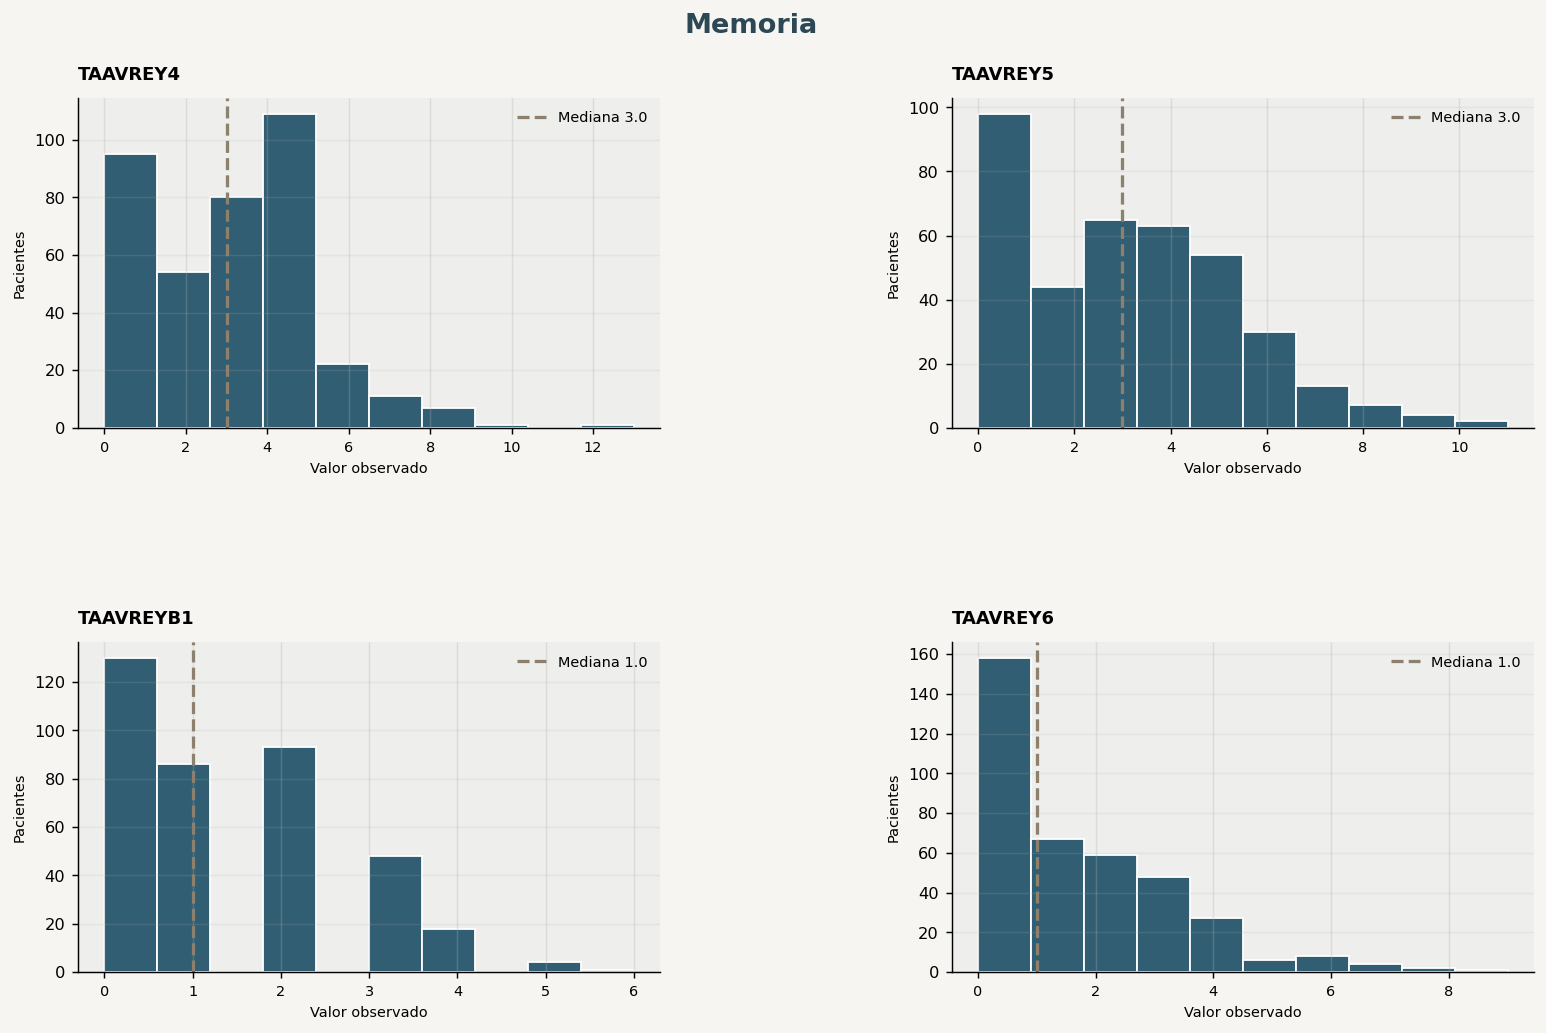

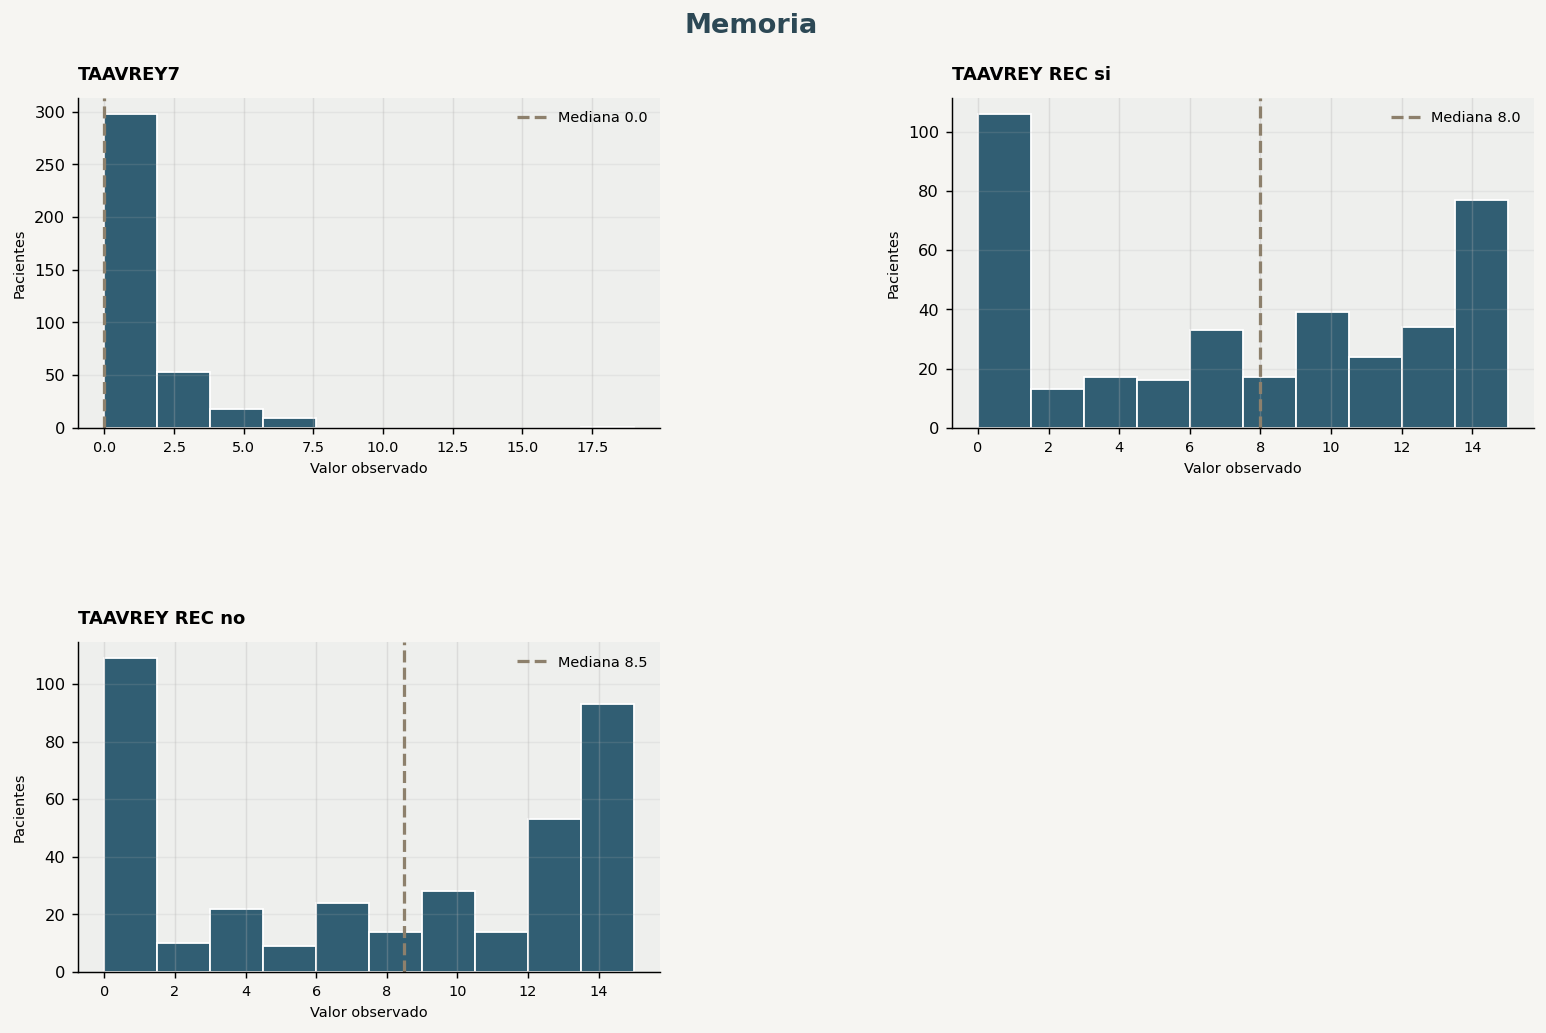

**Fluidez verbal**

Variables integradas en la familia: 15


**Distribuciones**

Variables integradas en la familia: 15
Variables graficadas: 15
Variables resumidas sin gráfico: 0


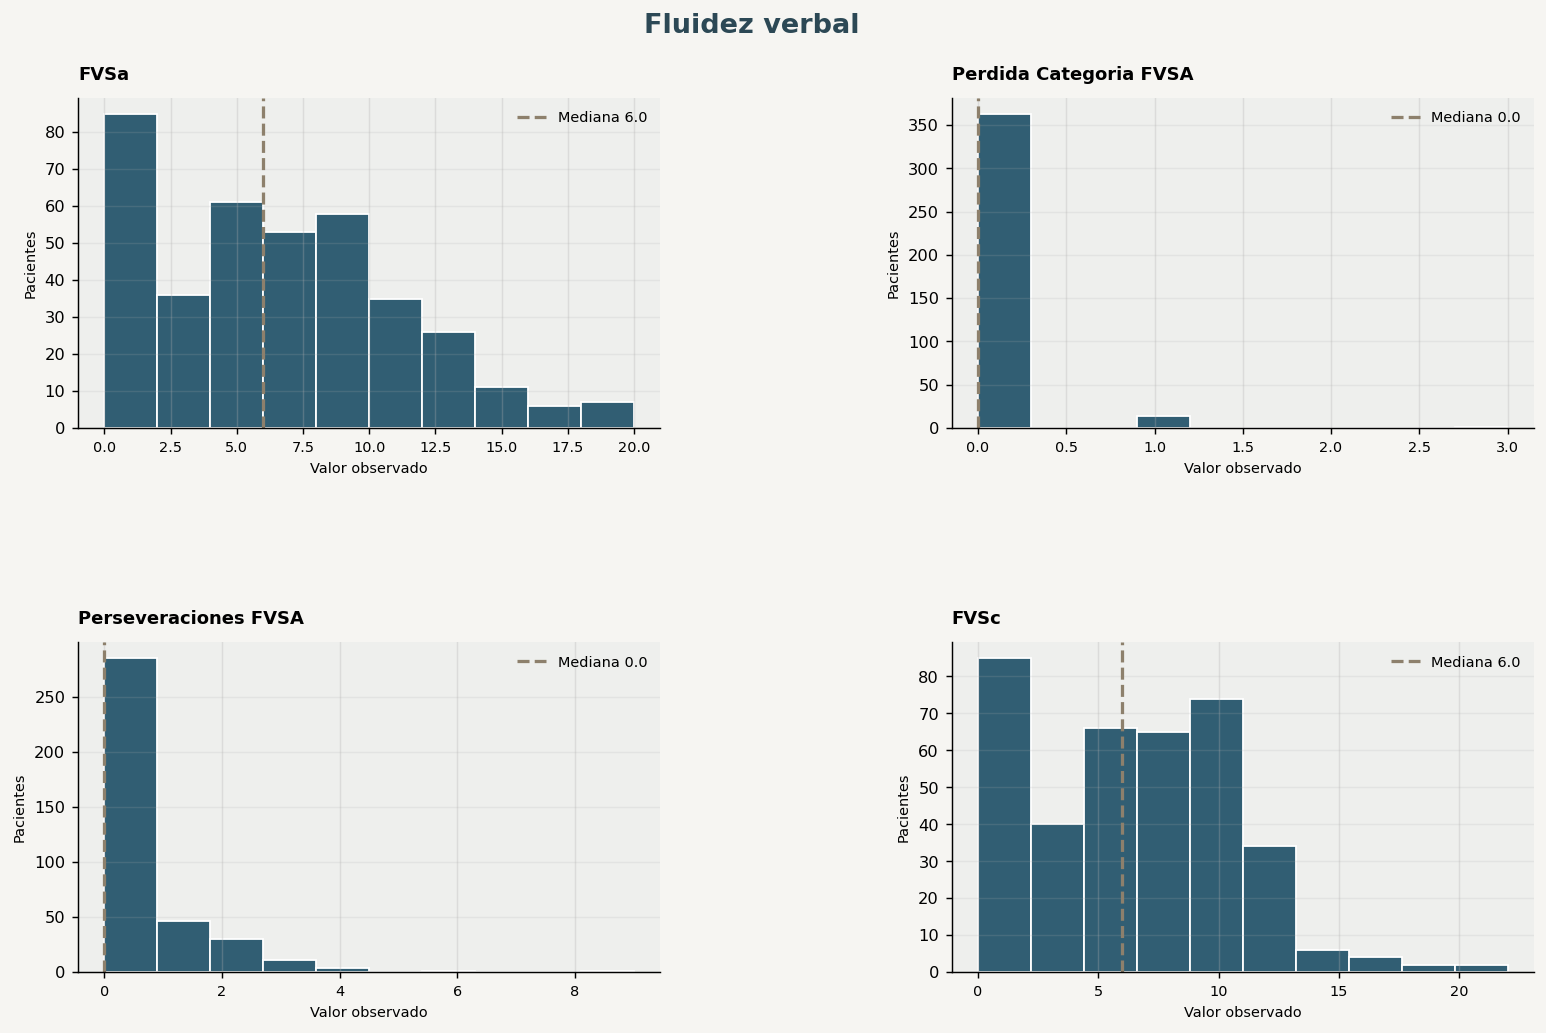

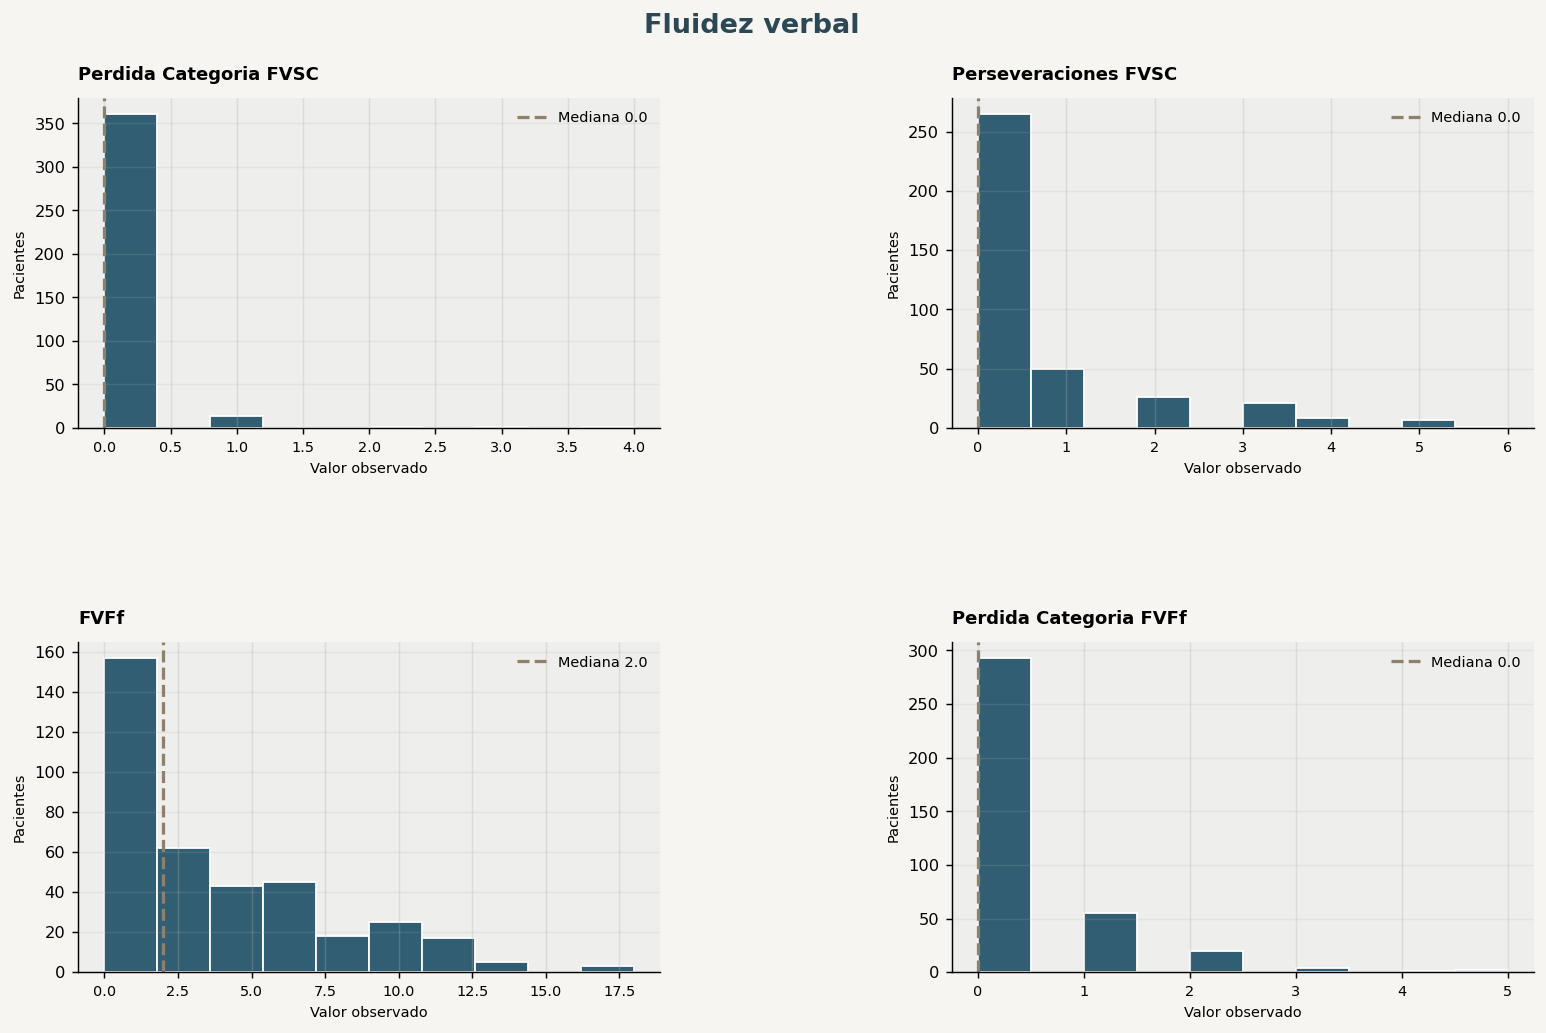

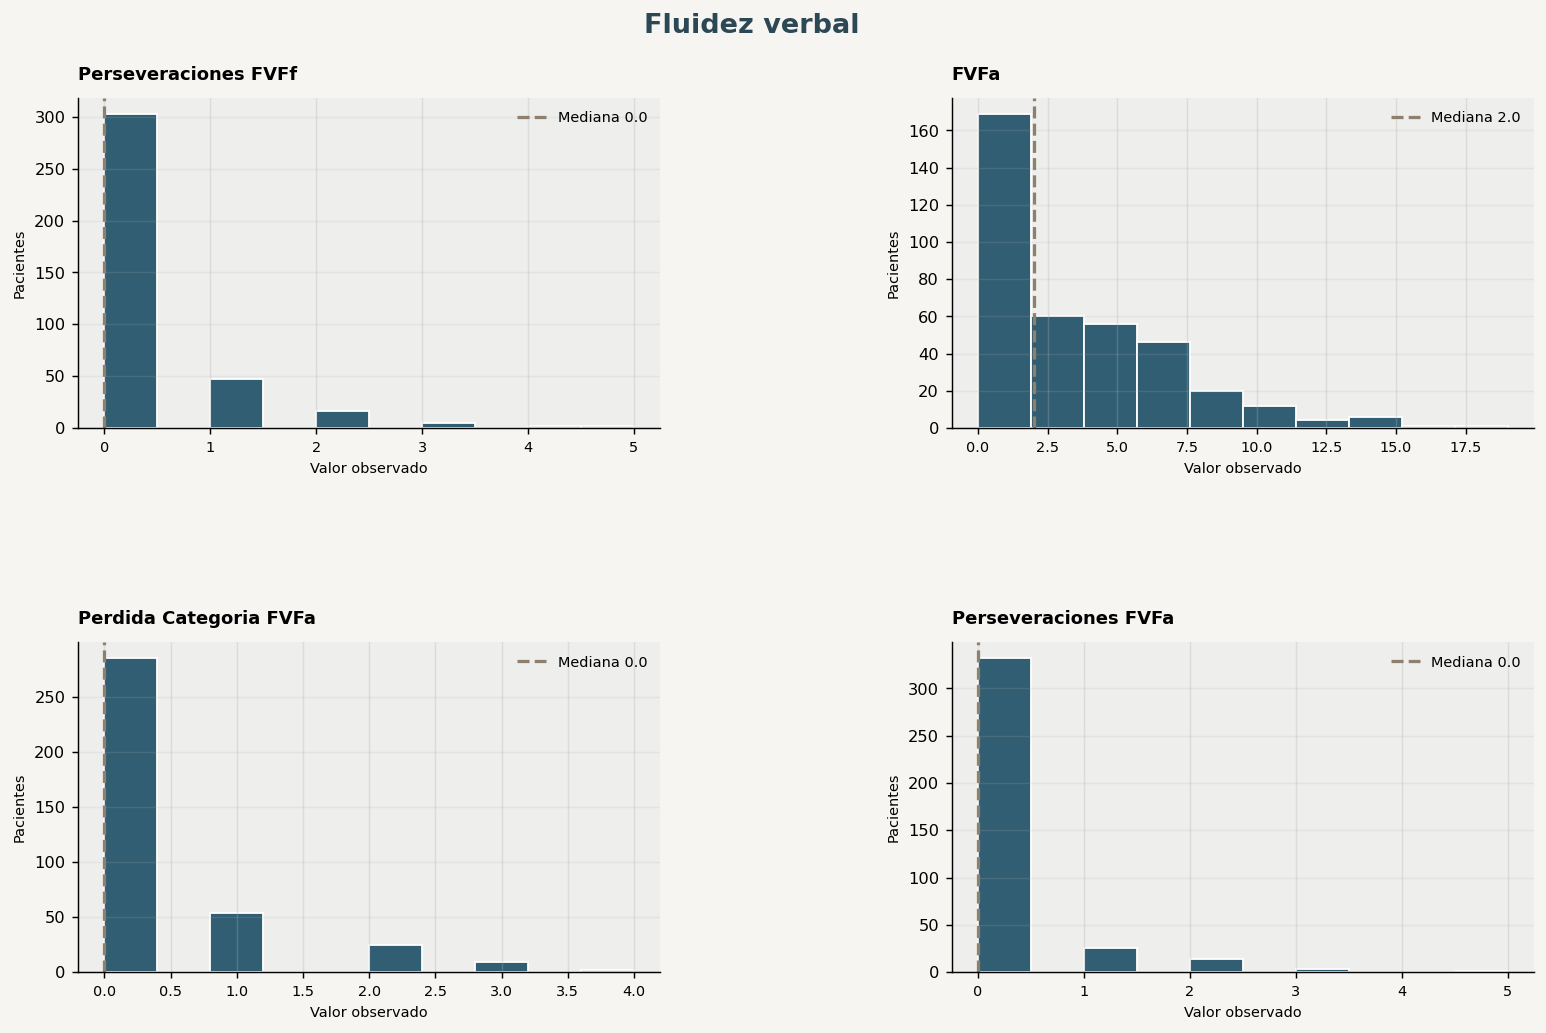

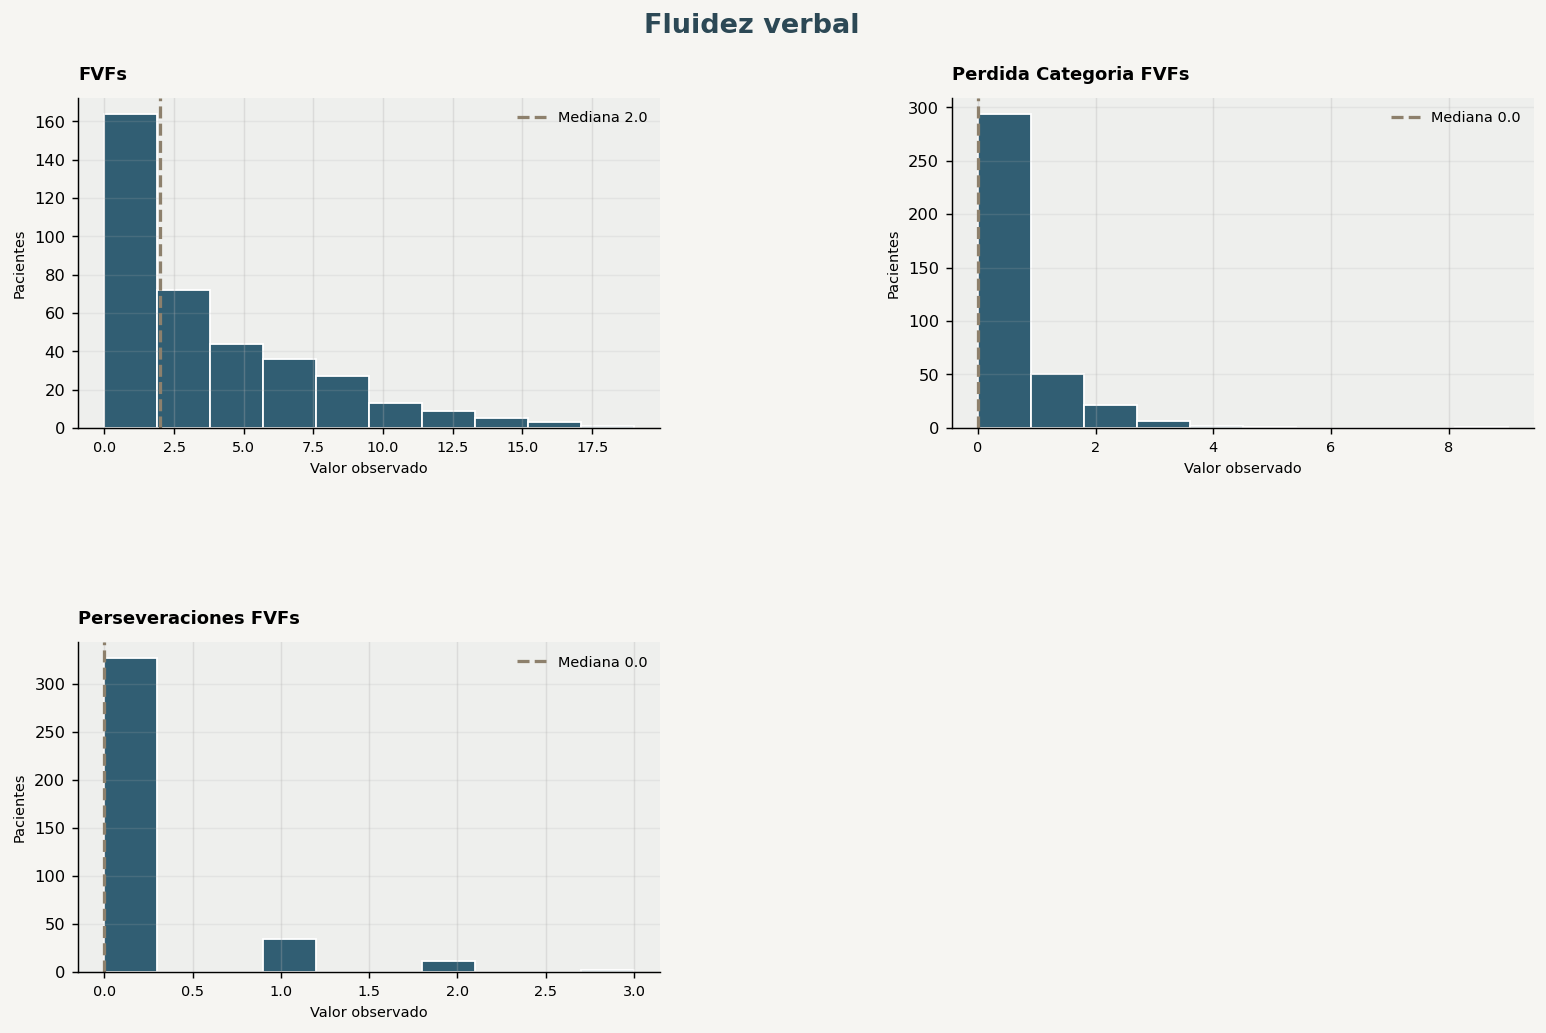

**Lenguaje**

Variables integradas en la familia: 4


**Distribuciones**

Variables integradas en la familia: 4
Variables graficadas: 4
Variables resumidas sin gráfico: 0


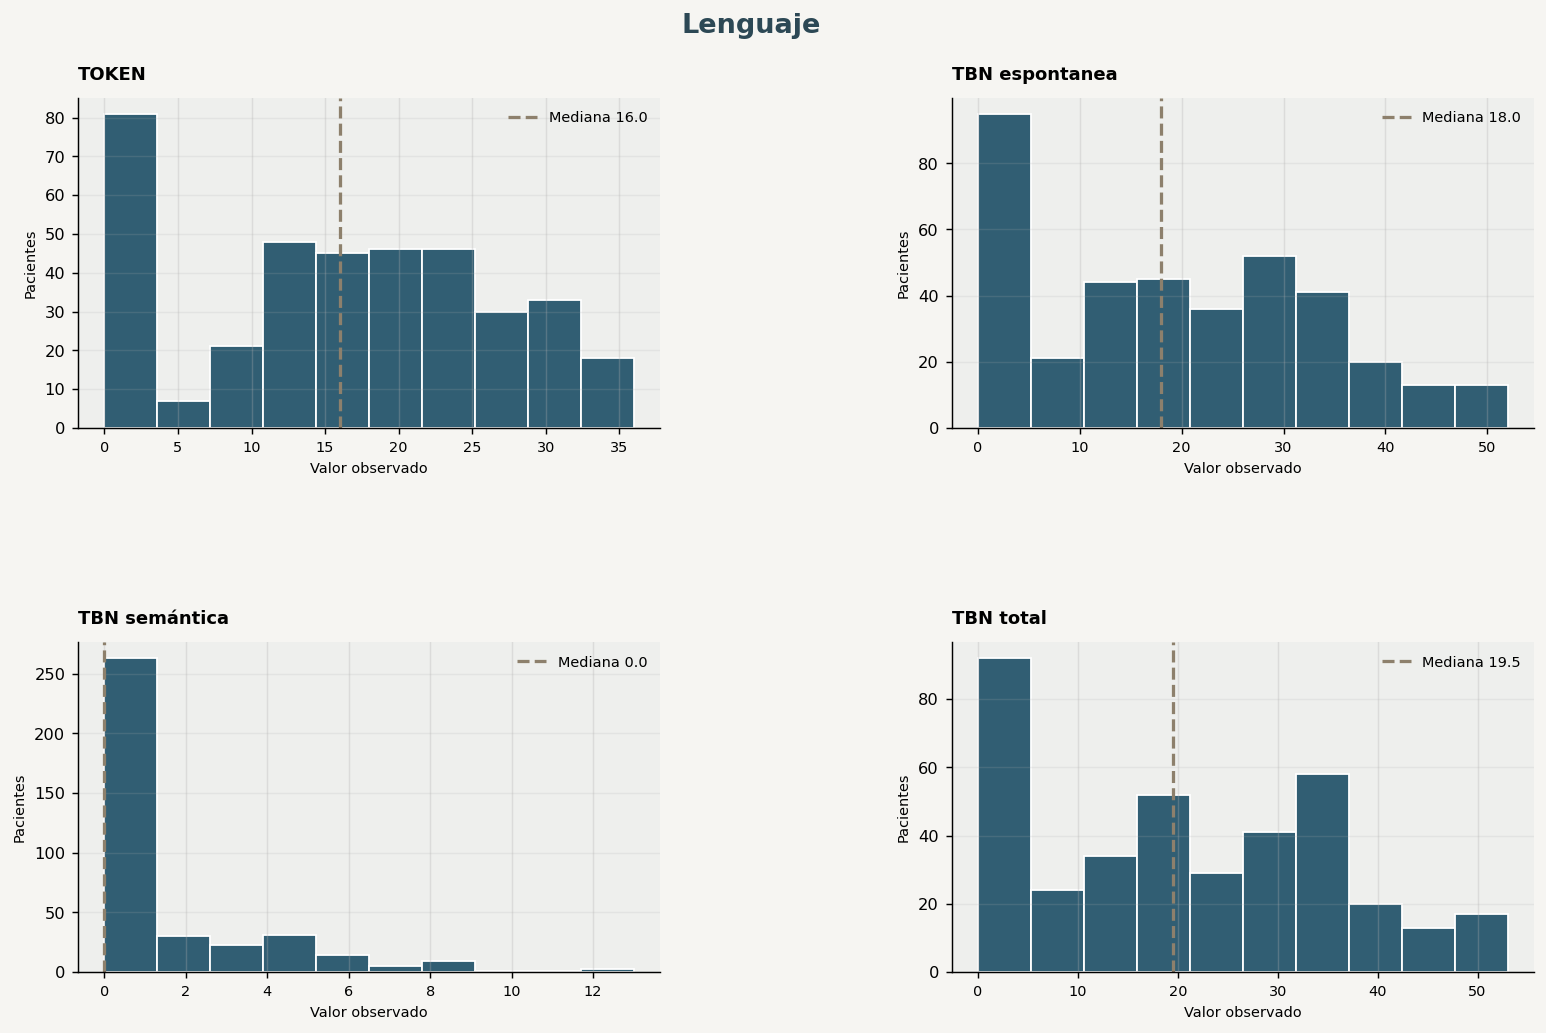

**Praxia y visuoconstrucción**

Variables integradas en la familia: 3


**Distribuciones**

Variables integradas en la familia: 3
Variables graficadas: 3
Variables resumidas sin gráfico: 0


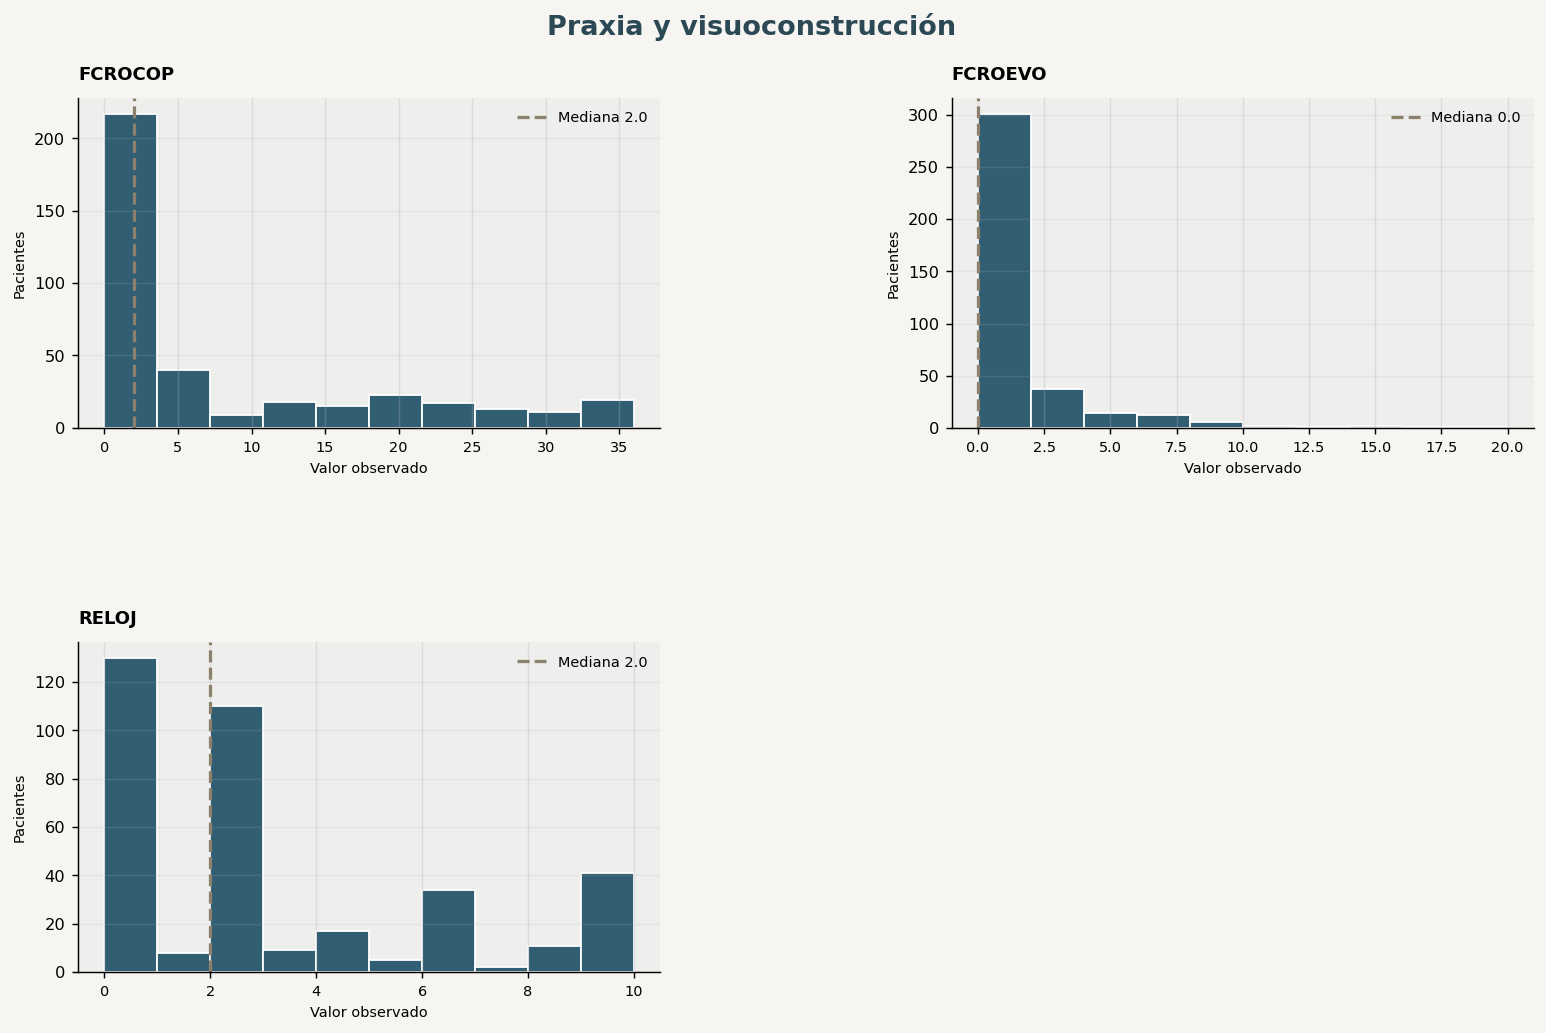

**Memoria semántica y conocimiento**

Variables integradas en la familia: 3


**Distribuciones**

Variables integradas en la familia: 3
Variables graficadas: 3
Variables resumidas sin gráfico: 0


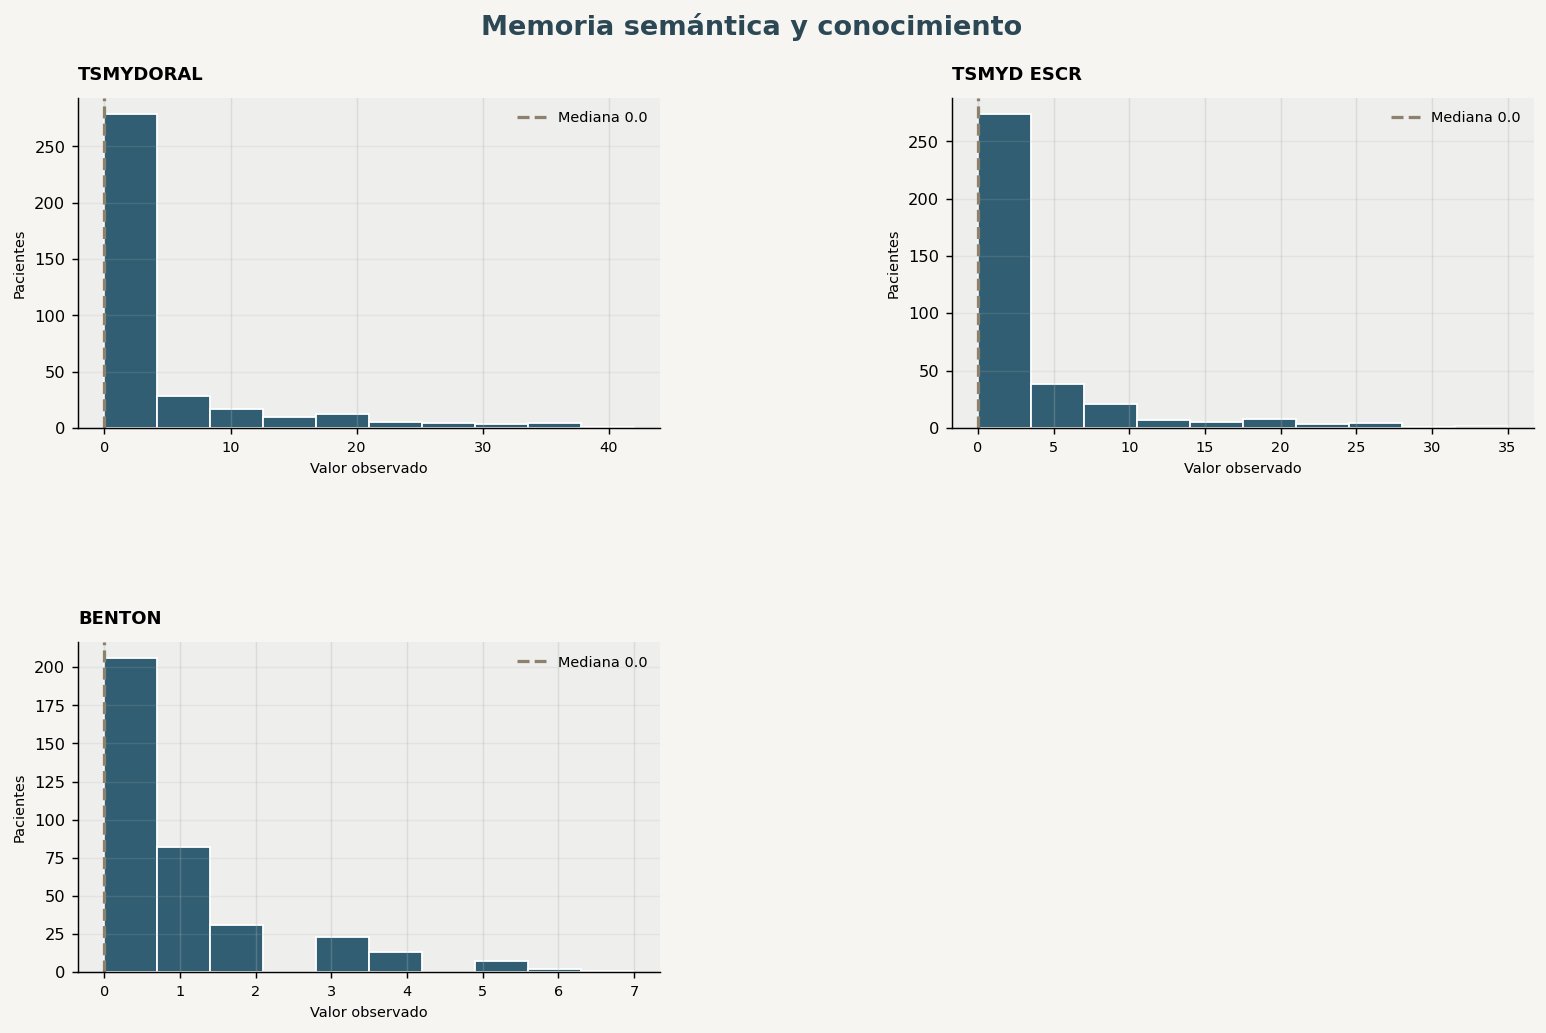

**Estado funcional, afectivo y quejas**

Variables integradas en la familia: 6


**Resumen de variables categóricas**

,variable,categoría predominante,n,% válido,faltantes
0,FAST,DISMINUCION EN LA CAPACIDAD ORGANIZACIONAL,193,49.7,3


**Distribuciones**

Variables integradas en la familia: 6
Variables graficadas: 5
Variables resumidas sin gráfico: 1


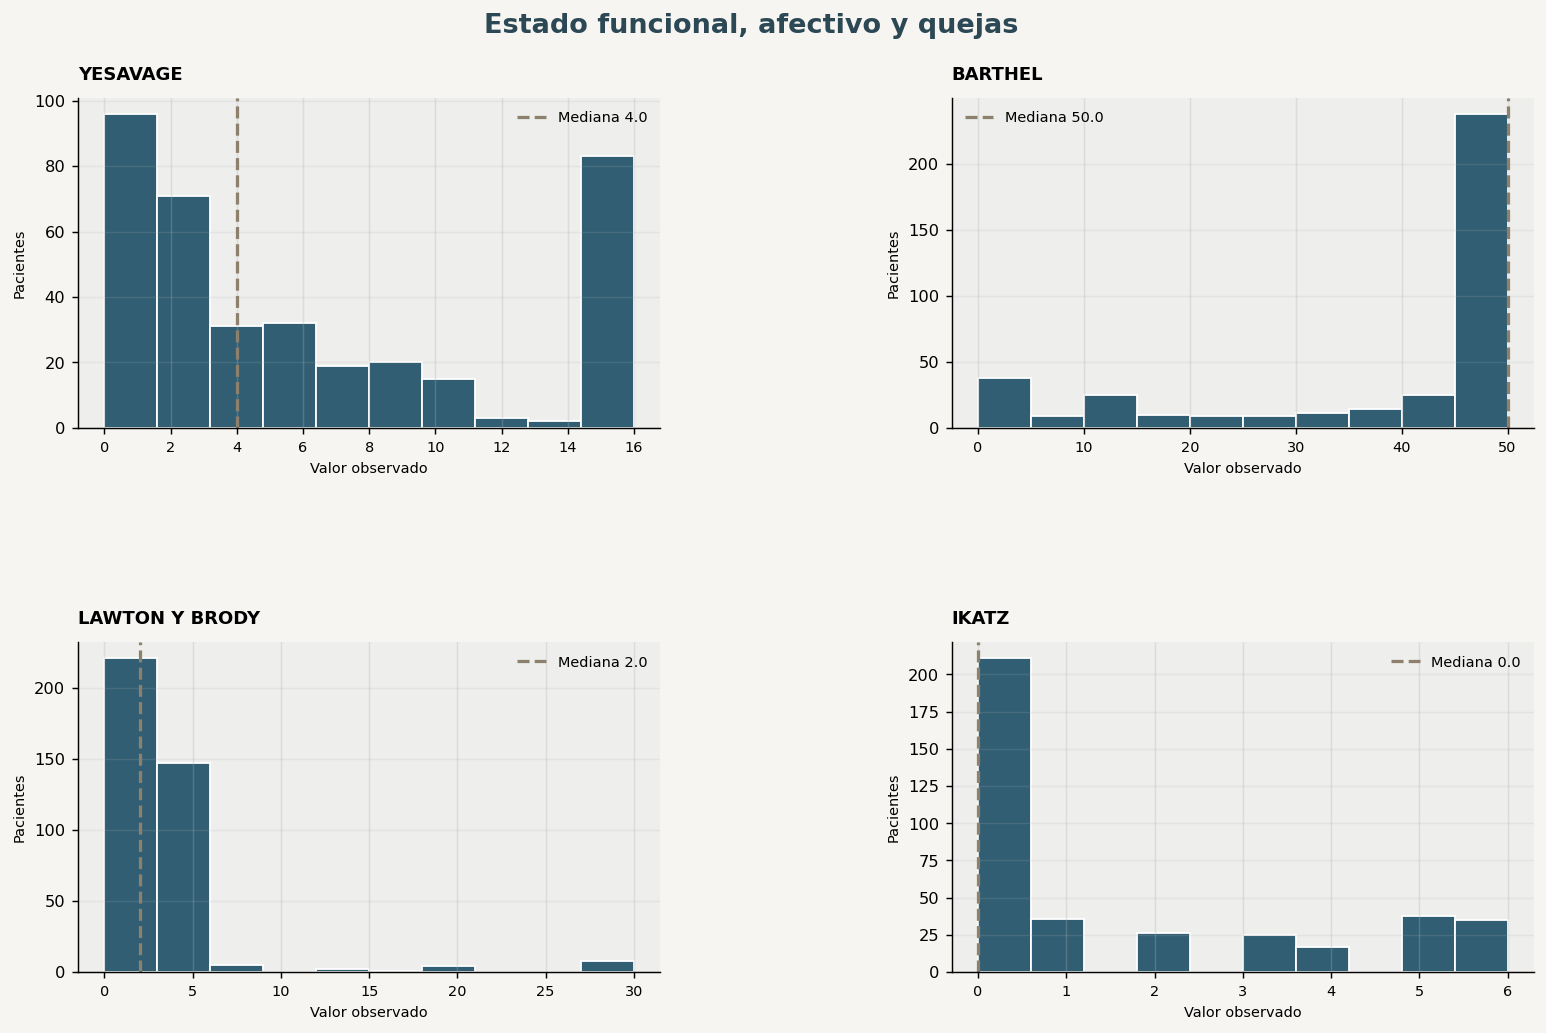

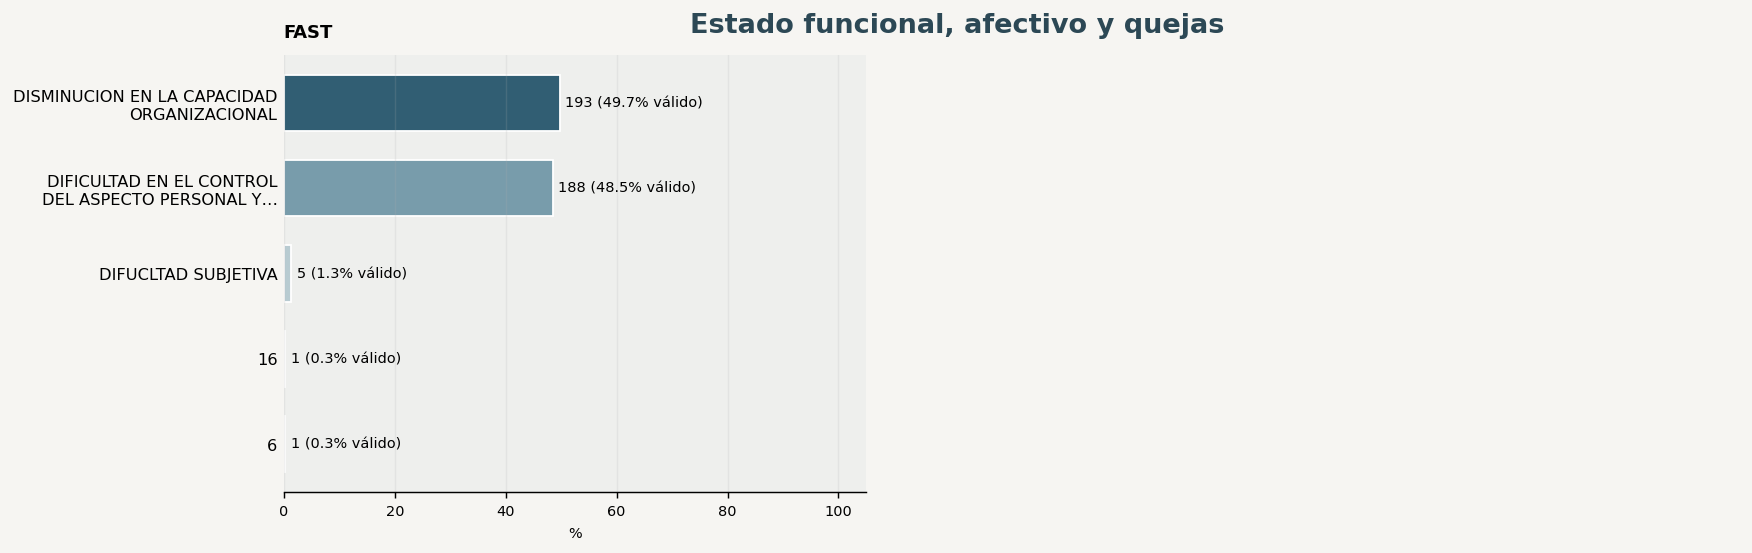

**Variables no graficadas por alta cardinalidad o tipo de dato**

,variable,tipo,n válido,faltantes,n únicos
0,QUEJAS SUBJETIVAS,texto libre / alta cardinalidad,383,8,7


In [134]:

dominios_nps={
    "cognicion_global":"Cognición global",
    "memoria":"Memoria",
    "fluidez_verbal":"Fluidez verbal",
    "lenguaje":"Lenguaje",
    "praxia_visuoconstruccion":"Praxia y visuoconstrucción",
    "funciones_ejecutivas_atencion":"Funciones ejecutivas y atención",
    "memoria_semantica_conocimiento":"Memoria semántica y conocimiento",
    "funcional_afectivo_quejas":"Estado funcional, afectivo y quejas"
}

for familia,titulo in dominios_nps.items():
    if familia in inventario["familia"].values:
        display(Markdown(f"**{titulo}**"))
        ejecutar_familia(familia,titulo)

#### **Hallazgos principales**

Las tres medidas muestran perfiles distintos de desempeño cognitivo y funcional. En MMSE, la mediana es de 19 puntos y la distribución es bastante amplia, con presencia de valores desde 0 hasta cerca de 30. Esto indica una heterogeneidad importante en el rendimiento cognitivo global de la cohorte, con un grupo considerable de pacientes en valores bajos y otro grupo concentrado en puntuaciones intermedias-altas.

En MoCA, la mediana es de 8 puntos y la distribución se concentra más hacia valores bajos, aunque también existen pacientes con puntuaciones más altas. Esto sugiere que, dentro de la cohorte, una proporción importante presenta bajo desempeño en esta medida de cognición global.

En FAST, casi toda la cohorte se concentra en las categorías 3 y 4, que representan aproximadamente el 49,7% y 48,4% de los registros válidos, respectivamente. Las demás categorías aparecen de forma muy infrecuente. Esto indica una fuerte concentración del estado funcional en dos niveles principales dentro de la muestra. Además, aparece un valor 16 con un solo registro, que conviene revisar porque se aparta claramente del patrón de codificación observado y podría corresponder a un error de digitación o a una codificación especial.

### **21.15. Resumen de hallazgos univariados y pendientes**

La sección caracteriza la cohorte completa sin imputar AOO, descartar extremos ni usar pruebas de hipótesis. Para el informe deben conservarse los denominadores de cada variable. Los códigos categóricos no documentados requieren confirmación de su significado y orden; las comorbilidades, medicación y medidas clínicas requieren confirmar si precedieron al inicio. El riesgo de leakage consignado en el diccionario orienta su uso futuro, pero no modifica estas descripciones.


In [136]:

n_neuro_revisadas = (
    len(tabla_seleccion_neuro)
    if "tabla_seleccion_neuro" in globals()
    else len(calidad_neuro)
    if "calidad_neuro" in globals()
    else inventario["grupo_principal"].eq("neuropsicologica").sum()
)

resumen_21 = pd.DataFrame([{
    "pacientes": len(base_full),
    "AOO_disponible": int(base_full["aoo"].notna().sum()),
    "variables_clinicas_inventariadas": int(
        (~inventario["tipo_analitico"].isin([
            "identificador",
            "variable auxiliar del EDA"
        ])).sum()
    ),
    "variables_sin_asignacion_validada": int(
        inventario["familia"].eq("sin_asignacion_validada").sum()
    ),
    "neuropsicologicas_revisadas": int(n_neuro_revisadas)
}])

display(resumen_21)

pendientes_familia = inventario.loc[
    inventario["familia"].eq("sin_asignacion_validada"),
    ["etiqueta","fuente","tipo_analitico","observacion"]
].reset_index(drop=True)

if pendientes_familia.empty:
    display(Markdown("**Asignación por familia:** todas las variables integradas quedaron asignadas."))
else:
    display(Markdown("**Variables pendientes de asignación por familia:**"))
    display(pendientes_familia)

assert len(base_full) == 391
assert base_full["id"].is_unique
assert not any(
    c in inventario["columna"].values
    for c in ["match_neuro","match_moca","aoo_original","aoo_actualizada"]
)

,pacientes,AOO_disponible,variables_clinicas_inventariadas,variables_sin_asignacion_validada,neuropsicologicas_revisadas
0,391,334,144,0,54


**Asignación por familia:** todas las variables integradas quedaron asignadas.

## **22. Análisis bivariado**

Este análisis retoma exactamente las familias de variables ya descritas univariadamente en la Sección 21 (`inventario`, `GRUPOS_DEMO`, `GRUPOS_NEURO`, `base_full`) y evalúa, variable por variable, su asociación estadística con la **Edad de Inicio (AOO)**. No se incorporan variables nuevas ni se modifica la clasificación analítica ya construida: se prueba únicamente lo que ya fue inventariado y descrito.

**Decisiones metodológicas:**

- **Unidad de análisis:** se usan pares completos por variable (`base_full[[variable, 'aoo']].dropna()`), sin imputar y sin eliminar valores extremos. Esto preserva el mismo principio de la Sección 21 de declarar siempre el denominador efectivo de cada prueba (`n`), que varía de una variable a otra según sus propios faltantes y los de la AOO (85.2% de disponibilidad, preliminar).
- **Pruebas no paramétricas:** se usan pruebas de rangos (Spearman, U de Mann-Whitney, Kruskal-Wallis) en lugar de pruebas paramétricas (Pearson, t, ANOVA), consistente con el uso de correlación de Spearman ya adoptado en la Sección 20 y con la naturaleza no necesariamente normal de la AOO y de varias covariables ordinales/discretas.
- **Corrección por comparaciones múltiples:** dado el número de pruebas realizadas, todos los p-valores se corrigen conjuntamente por FDR (Benjamini-Hochberg) en la Sección 22.15, evitando interpretar como "hallazgo" cualquier p<0.05 aislado.
- **Riesgo de leakage como filtro de interpretación, no de exclusión:** todas las variables se prueban, incluidas las de riesgo "Alto" o "Potencial" (p. ej. MMSE, MoCA, FAST, comorbilidades sin temporalidad confirmada). Una asociación estadísticamente significativa en esas variables **no se interpreta como factor de riesgo** para una AOO más temprana o tardía, sino como covariación entre el estado clínico actual y la AOO. La columna `riesgo_leakage_aoo` del inventario acompaña cada resultado para que esta distinción sea explícita en todo momento.
- **No se prueban:** identificadores, variables auxiliares del EDA (`edad de inicio`/`edad de inicio actualizada`, que son insumos de la propia AOO), variables de texto libre/alta cardinalidad, variables constantes, y variables cuyo `n` efectivo o cuyo tamaño de grupo sea insuficiente. Estas exclusiones se documentan explícitamente por variable en la tabla de resultados (columna `motivo`) y se resumen en la Sección 22.16.
- **Las celdas «Hallazgos principales» se dejan en blanco intencionalmente**, igual que en la Sección 21: deben completarse tras ejecutar el notebook con los archivos fuente, inspeccionando las tablas y gráficos generados.


### **22.1. Criterios metodológicos y funciones auxiliares del bivariado**

La prueba usada por variable depende de `tipo_analitico` (ya definido en el inventario de la Sección 21):

- `cuantitativa continua` / `cuantitativa discreta`: correlación de Spearman con AOO.
- `ordinal`: se intenta primero como numérica (si ≥80% de los valores no faltantes son convertibles a número, se asume que la codificación ordinal ya es numérica y se usa Spearman); si no, se trata como categórica sin orden validado (se documenta explícitamente) y se compara por grupos.
- `categórica binaria` (2 categorías con n suficiente): U de Mann-Whitney, con r biserial por rangos como medida de efecto.
- `categórica nominal` (≥3 categorías con n suficiente): Kruskal-Wallis, con épsilon al cuadrado como medida de efecto.
- `identificador`, `variable auxiliar del EDA`, `texto libre / alta cardinalidad`: no se prueban formalmente.

Las categorías con menos de `n_min_grupo` pacientes se excluyen de la prueba de grupos (no del inventario ni de la cohorte) y quedan fuera del cálculo de `k`; esto se documenta si reduce el número de grupos comparados.


In [163]:
# ============================================================
# 22.1. FUNCIONES DEL ANÁLISIS BIVARIADO
# ============================================================

import math,textwrap,re
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display,Markdown

assert len(base_full)==391 and base_full["id"].is_unique
assert "aoo" in base_full.columns and "riesgo_leakage_aoo" in inventario.columns

BC="#315e73"; BC2="#789cab"; BPANEL="#eeefed"; BFONDO="#f6f5f2"

def titulo_biv(x,w=42):
    return "\n".join(textwrap.wrap(str(x),width=w,break_long_words=False))

def clave_biv(v):
    if pd.isna(v): return None
    if isinstance(v,(int,np.integer)): return str(int(v))
    if isinstance(v,(float,np.floating)) and float(v).is_integer(): return str(int(v))
    s=str(v).strip()
    try:
        f=float(s)
        return str(int(f)) if f.is_integer() else s
    except: return s

def mapa_bivariado(col):
    """Mapa documentado + convención binaria confirmada 0=No, 1=Sí, 9=Desconocido."""
    fila=inventario.loc[inventario["columna"].eq(col)]
    if fila.empty:return {}

    mapa=_mapa_codigos_columna(col) if "_mapa_codigos_columna" in globals() else {}
    if mapa:return {clave_biv(k):v for k,v in mapa.items()}

    tipo=fila["tipo_analitico"].iloc[0]
    vals={clave_biv(v) for v in base_full[col].dropna()}
    vals.discard("-")

    if tipo=="categórica binaria" and vals.issubset({"0","1","9"}):
        return {"0":"No","1":"Sí","9":"Desconocido"}

    return {}

def serie_plot_bivariada(col):
    """Serie etiquetada para tablas/gráficos; no modifica base_full."""
    mapa=mapa_bivariado(col)

    def trad(v):
        if pd.isna(v):return np.nan
        k=clave_biv(v)
        if k=="-":return np.nan

        if k in mapa:
            e=mapa[k]
            return np.nan if e in {"Desconocido","No registrado"} else e

        canon=normalizar_para_match(k)
        if canon=="si":return "Sí"
        if canon=="no":return "No"

        return f"Código {k} (sin etiqueta documentada)"

    out=base_full[col].map(trad)
    out.name=col
    return out

def evaluar_codificacion(col,tipo):
    if tipo not in ("categórica nominal","categórica binaria","ordinal"):return True,""
    if col=="neuro__tmta":return False,"TMTA requiere validar su codificación"

    mapa=mapa_bivariado(col)

    if mapa:return True,""
    return False,"Codificación pendiente de validación"

def direccion_resultado(prueba,e):
    if pd.isna(e):return ""
    if prueba=="Spearman":
        if e>0:return "Valores mayores asociados con AOO mayor"
        if e<0:return "Valores mayores asociados con AOO menor"
        return "Sin dirección monotónica"
    return "Comparar medianas de AOO entre grupos"

def prueba_bivariada_aoo(col,y_col="aoo",n_min=10,n_min_grupo=5):
    meta=inventario.set_index("columna")

    if col not in meta.index:
        return {"variable":col,"columna":col,"evaluable":False,"motivo":"Fuera del inventario"}

    tipo=meta.at[col,"tipo_analitico"]
    familia=meta.at[col,"familia"]
    leakage=meta.at[col,"riesgo_leakage_aoo"]
    nombre=etiqueta_bonita(col)
    y=pd.to_numeric(base_full[y_col],errors="coerce")
    cod_ok,alerta=evaluar_codificacion(col,tipo)

    base={
        "variable":nombre,"columna":col,"familia":familia,
        "tipo_analitico":tipo,"riesgo_leakage_aoo":leakage,
        "codificacion_validada":cod_ok,"alerta_codificacion":alerta
    }

    if col=="neuro__tmta":
        return {**base,"evaluable":False,"motivo":alerta}

    if tipo in ("texto libre / alta cardinalidad","identificador","variable auxiliar del EDA"):
        return {**base,"evaluable":False,"motivo":"Tipo no apto para prueba formal"}

    # CUANTITATIVAS
    if tipo.startswith("cuantitativa"):
        x=pd.to_numeric(serie_analitica(col),errors="coerce")
        d=pd.DataFrame({"x":x,"y":y}).dropna(); n=len(d)

        if d.x.nunique()<=1:
            return {**base,"evaluable":False,"motivo":"Sin variación observable","n":n}

        if n<n_min:
            return {**base,"evaluable":False,"motivo":f"n insuficiente ({n}<{n_min})","n":n}

        rho,p=stats.spearmanr(d.x,d.y)

        return {
            **base,"evaluable":True,"prueba":"Spearman","n":n,
            "estadistico":rho,"p_valor":p,
            "medida_efecto":rho,"medida_efecto_nombre":"rho de Spearman",
            "direccion":direccion_resultado("Spearman",rho),
            "medianas_por_grupo":np.nan,"nota":alerta
        }

    # ORDINALES: Spearman solo si orden/codificación están validados
    if tipo=="ordinal":
        raw=serie_analitica(col)
        xn=pd.to_numeric(raw,errors="coerce")
        nobs=raw.notna().sum()

        if cod_ok and nobs and xn.notna().sum()/nobs>=.8:
            d=pd.DataFrame({"x":xn,"y":y}).dropna(); n=len(d)

            if d.x.nunique()<=1:
                return {**base,"evaluable":False,"motivo":"Sin variación observable","n":n}

            if n<n_min:
                return {**base,"evaluable":False,"motivo":f"n insuficiente ({n}<{n_min})","n":n}

            rho,p=stats.spearmanr(d.x,d.y)

            return {
                **base,"evaluable":True,"prueba":"Spearman","n":n,
                "estadistico":rho,"p_valor":p,
                "medida_efecto":rho,"medida_efecto_nombre":"rho de Spearman",
                "direccion":direccion_resultado("Spearman",rho),
                "medianas_por_grupo":np.nan,"nota":alerta
            }

    # CATEGÓRICAS
    x=serie_plot_bivariada(col)
    d=pd.DataFrame({"grupo":x,"y":y}).dropna()
    d["grupo"]=d["grupo"].astype(str)

    conteo=d.grupo.value_counts()
    validos=conteo[conteo>=n_min_grupo].index
    d=d[d.grupo.isin(validos)].copy()

    k=d.grupo.nunique(); n=len(d)

    if k<2:
        return {
            **base,"evaluable":False,
            "motivo":f"Menos de 2 categorías con n≥{n_min_grupo}","n":n
        }

    muestras=[g.y.to_numpy() for _,g in d.groupby("grupo")]
    medianas=d.groupby("grupo").y.median().round(1).to_dict()

    if k==2:
        a,b=muestras
        u,p=stats.mannwhitneyu(a,b,alternative="two-sided")
        rb=1-(2*u)/(len(a)*len(b))

        return {
            **base,"evaluable":True,"prueba":"U de Mann-Whitney","n":n,
            "estadistico":u,"p_valor":p,
            "medida_efecto":rb,"medida_efecto_nombre":"r biserial por rangos",
            "direccion":"Comparar medianas de AOO entre grupos",
            "medianas_por_grupo":medianas,"nota":alerta
        }

    h,p=stats.kruskal(*muestras)
    eps2=(h-k+1)/(n-k) if n>k else np.nan

    return {
        **base,"evaluable":True,"prueba":f"Kruskal-Wallis (k={k})","n":n,
        "estadistico":h,"p_valor":p,
        "medida_efecto":eps2,"medida_efecto_nombre":"épsilon cuadrado",
        "direccion":"Comparar medianas de AOO entre grupos",
        "medianas_por_grupo":medianas,"nota":alerta
    }

def panel_bivariado_numerico(ax,x,y,titulo):
    d=pd.DataFrame({
        "x":pd.to_numeric(x,errors="coerce"),
        "y":pd.to_numeric(y,errors="coerce")
    }).dropna()

    ax.set_facecolor(BPANEL)
    ax.set_title(titulo_biv(titulo),loc="left",fontsize=10,fontweight="bold",pad=10)

    if len(d)<3:
        ax.text(.5,.5,"Datos insuficientes",ha="center",va="center",transform=ax.transAxes)
        return

    ax.scatter(d.x,d.y,s=22,color=BC,alpha=.55,edgecolor="white",linewidth=.4)

    try:
        m,b=np.polyfit(d.x,d.y,1)
        xs=np.linspace(d.x.min(),d.x.max(),50)
        ax.plot(xs,m*xs+b,color="#8d806c",lw=2,ls="--")
    except: pass

    rho,p=stats.spearmanr(d.x,d.y)

    ax.text(
        .02,.96,f"ρ={rho:.2f}   p={p:.3g}   n={len(d)}",
        transform=ax.transAxes,va="top",fontsize=8,
        bbox=dict(boxstyle="round",fc="white",ec="none",alpha=.8)
    )

    ax.set_xlabel(titulo_biv(titulo,35),fontsize=8)
    ax.set_ylabel("AOO (años)",fontsize=8)
    ax.grid(alpha=.22)
    ax.spines[["top","right"]].set_visible(False)

def panel_bivariado_categorico(ax,cat,y,titulo,max_categorias=8,n_min_grupo=5):
    d=pd.DataFrame({
        "grupo":cat,
        "y":pd.to_numeric(y,errors="coerce")
    }).dropna()

    d["grupo"]=d.grupo.astype(str)
    counts=d.grupo.value_counts()
    d=d[d.grupo.isin(counts[counts>=n_min_grupo].index)]

    ax.set_facecolor(BPANEL)
    ax.set_title(titulo_biv(titulo),loc="left",fontsize=10,fontweight="bold",pad=10)

    if d.empty or d.grupo.nunique()<2:
        ax.text(.5,.5,"Datos/grupos insuficientes",ha="center",va="center",transform=ax.transAxes)
        return

    orden=d.groupby("grupo").y.median().sort_values(ascending=False).index
    cats=list(orden)[:max_categorias]
    datos=[d.loc[d.grupo.eq(c),"y"].to_numpy() for c in cats]
    etiquetas=[f"{titulo_biv(c,24)} (n={len(z)})" for c,z in zip(cats,datos)]

    bp=ax.boxplot(datos,vert=False,patch_artist=True,widths=.55)

    for j,b in enumerate(bp["boxes"]):
        b.set_facecolor(BC if j%2==0 else BC2)
        b.set_edgecolor(BC)

    for e in ("whiskers","caps"):
        for l in bp[e]:l.set_color(BC)

    for m in bp["medians"]:
        m.set_color("#8d806c")
        m.set_linewidth(2)

    ax.set_yticks(range(1,len(cats)+1),etiquetas,fontsize=8)
    ax.set_xlabel("AOO (años)",fontsize=8)
    ax.grid(axis="x",alpha=.22)
    ax.grid(axis="y",visible=False)
    ax.spines[["top","right","left"]].set_visible(False)

def analisis_bivariado_familia(columnas,titulo,acumulador=None):
    if not columnas:
        print("Sin variables integradas.")
        return pd.DataFrame()

    meta=inventario.set_index("columna")
    resultados=[prueba_bivariada_aoo(c) for c in columnas]
    tabla=pd.DataFrame(resultados)

    mostrar=[
        "variable","tipo_analitico","riesgo_leakage_aoo","evaluable",
        "prueba","n","estadistico","medida_efecto","medida_efecto_nombre",
        "direccion","medianas_por_grupo","codificacion_validada",
        "alerta_codificacion","p_valor","motivo","nota"
    ]

    for c in mostrar:
        if c not in tabla:tabla[c]=np.nan

    display(Markdown(f"**Pruebas de asociación con AOO — {titulo}**"))
    display(tabla[mostrar].round(4).reset_index(drop=True))

    if acumulador is not None:
        acumulador.extend(resultados)

    graficables=tabla.loc[tabla.evaluable.fillna(False),"columna"].tolist()

    for ini in range(0,len(graficables),4):
        lote=graficables[ini:ini+4]
        nr=math.ceil(len(lote)/2)

        fig,axes=plt.subplots(nr,2,figsize=(14,4.4*nr),squeeze=False)
        fig.patch.set_facecolor(BFONDO)
        fig.suptitle(
            f"{titulo} vs. AOO",
            fontsize=14,fontweight="bold",color="#263b43",y=.98
        )

        for ax,col in zip(axes.flat,lote):
            tipo=meta.at[col,"tipo_analitico"]
            nombre=etiqueta_bonita(col)
            y=base_full["aoo"]

            if tipo.startswith("cuantitativa") or tipo=="ordinal":
                resultado=tabla.loc[tabla.columna.eq(col)].iloc[0]

                if resultado["prueba"]=="Spearman":
                    panel_bivariado_numerico(
                        ax,serie_analitica(col),y,nombre
                    )
                else:
                    panel_bivariado_categorico(
                        ax,serie_plot_bivariada(col),y,nombre
                    )
            else:
                panel_bivariado_categorico(
                    ax,serie_plot_bivariada(col),y,nombre
                )

        for ax in axes.flat[len(lote):]:
            ax.axis("off")

        fig.subplots_adjust(
            left=.15,right=.95,top=.88,bottom=.09,
            hspace=.60,wspace=.48
        )
        plt.show()

    return tabla

def bootstrap_ic_efecto(col,prueba,n_boot=1000,seed=42,n_min_grupo=5):
    rng=np.random.default_rng(seed)
    y=base_full["aoo"]; vals=[]

    if prueba=="Spearman":
        x=pd.to_numeric(serie_analitica(col),errors="coerce")
        d=pd.DataFrame({"x":x,"y":y}).dropna()

        if len(d)<10:return np.nan,np.nan

        for _ in range(n_boot):
            b=d.iloc[rng.integers(0,len(d),len(d))]
            r=stats.spearmanr(b.x,b.y).statistic
            if np.isfinite(r):vals.append(r)

    else:
        x=serie_plot_bivariada(col)
        d=pd.DataFrame({"g":x,"y":y}).dropna()
        d["g"]=d.g.astype(str)

        counts=d.g.value_counts()
        d=d[d.g.isin(counts[counts>=n_min_grupo].index)]
        grupos=list(d.g.unique())

        if len(grupos)<2:return np.nan,np.nan

        for _ in range(n_boot):
            m=[
                rng.choice(d.loc[d.g.eq(g),"y"],size=(d.g==g).sum(),replace=True)
                for g in grupos
            ]

            if len(grupos)==2:
                u=stats.mannwhitneyu(m[0],m[1],alternative="two-sided").statistic
                vals.append(1-2*u/(len(m[0])*len(m[1])))
            else:
                h=stats.kruskal(*m).statistic
                n=sum(map(len,m)); k=len(m)
                vals.append((h-k+1)/(n-k) if n>k else np.nan)

    vals=np.asarray(vals,float)
    vals=vals[np.isfinite(vals)]

    return tuple(np.quantile(vals,[.025,.975])) if len(vals)>=100 else (np.nan,np.nan)

def posthoc_dunn(col,ajuste="holm",n_min_grupo=5):
    x=serie_plot_bivariada(col); y=base_full["aoo"]
    d=pd.DataFrame({"grupo":x,"y":y}).dropna()
    d["grupo"]=d.grupo.astype(str)

    counts=d.grupo.value_counts()
    d=d[d.grupo.isin(counts[counts>=n_min_grupo].index)].copy()

    if d.grupo.nunique()<3:return pd.DataFrame()

    d["rango"]=stats.rankdata(d.y)
    N=len(d); grupos=sorted(d.grupo.unique())
    emp=d.y.value_counts().to_numpy()
    tie=1-(np.sum(emp**3-emp)/(N**3-N)) if N>1 else np.nan
    var=(N*(N+1)/12)*tie
    filas=[]

    for i,g1 in enumerate(grupos):
        for g2 in grupos[i+1:]:
            a=d[d.grupo.eq(g1)]
            b=d[d.grupo.eq(g2)]

            z=(a.rango.mean()-b.rango.mean())/np.sqrt(
                var*(1/len(a)+1/len(b))
            )
            p=2*stats.norm.sf(abs(z))

            filas.append({
                "grupo_1":g1,"grupo_2":g2,
                "n_1":len(a),"n_2":len(b),
                "z":z,"p_sin_ajuste":p
            })

    out=pd.DataFrame(filas)

    if len(out):
        out["p_ajustado_holm"]=multipletests(
            out["p_sin_ajuste"],method=ajuste
        )[1]
        out["significativo_005"]=out["p_ajustado_holm"]<.05

    return out

def redactar_hallazgos_bivariados(tabla,nombre,max_destacados=4):
    if tabla is None or tabla.empty:
        return f"En {nombre.lower()} no hubo variables disponibles."

    ev=tabla.loc[tabla.evaluable.fillna(False)].copy()
    noev=tabla.loc[~tabla.evaluable.fillna(False)]

    if ev.empty:
        return f"En {nombre.lower()} ninguna variable reunió condiciones mínimas para comparación formal con AOO."

    sen=ev.loc[ev.p_valor<.05].sort_values("p_valor")
    txt=f"Se evaluaron {len(ev)} variables de {nombre.lower()}. "

    if sen.empty:
        txt+="No se observaron señales con p<0.05 antes del ajuste por comparaciones múltiples."
    else:
        txt+=f"{len(sen)} variable(s) mostraron señal preliminar antes del ajuste FDR. "

        frases=[]
        for _,r in sen.head(max_destacados).iterrows():
            if r.prueba=="Spearman":
                d="AOO mayor" if r.medida_efecto>0 else "AOO menor"
                frases.append(
                    f"{r.variable}: ρ={r.medida_efecto:.2f}, asociado con {d}."
                )
            else:
                frases.append(f"{r.variable}: se observaron diferencias entre grupos.")

        txt+=" ".join(frases)

    if len(noev):
        txt+=f" {len(noev)} variable(s) no fueron evaluables formalmente."

    return txt

def mostrar_hallazgos_bivariados(tabla,nombre):
    display(Markdown(redactar_hallazgos_bivariados(tabla,nombre)))

pruebas_bivariadas_globales=[]
print("Funciones bivariadas listas.")

Funciones bivariadas listas.


### **22.2. AOO y variables sociodemográficas**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación.

**Edad frente a AOO requiere una lectura especial.** Ambas variables están temporal y matemáticamente vinculadas: la edad de inicio no puede superar la edad actual y la duración de enfermedad conecta ambas medidas. Por ello, una correlación alta es esperable y no convierte la edad actual en una covariable independiente atractiva para modelar AOO sin considerar duración y temporalidad.

Las variables categóricas con códigos sin diccionario se marcan como **«Resultado estadístico preliminar sujeto a validación de codificación»**. Sus pruebas pueden calcularse, pero no se interpretan sustantivamente hasta confirmar las categorías y los códigos especiales (`9`, `-`, desconocido/no aplica).


Variables integradas en la familia: 11


**Pruebas de asociación con AOO — Variables sociodemográficas**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,genero,categórica binaria,Bajo,True,U de Mann-Whitney,334.0,11192.0000,0.0916,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'Femenino': 75.0, 'Masculino': 77.0}",True,,0.1736,NaN,
1,mes y año de nacimiento,texto libre / alta cardinalidad,Bajo / revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
2,EDAD,cuantitativa continua,Bajo / revisar temporalidad,True,Spearman,334.0,0.8403,0.8403,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.0000,NaN,
3,IDIOMA,categórica nominal,Bajo,False,NaN,334.0,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
4,OTRO IDOMA,texto libre / alta cardinalidad,Bajo,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
5,Nivel educativo,ordinal,Bajo,True,Spearman,324.0,-0.1763,-0.1763,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.0014,NaN,
6,Estado civil,categórica nominal,Bajo / revisar temporalidad,True,Kruskal-Wallis (k=4),311.0,15.7788,0.0416,épsilon cuadrado,Comparar medianas de AOO entre grupos,"{'Casado': 74.0, 'Separado': 75.0, 'Soltero (nunca casado o matrimonio anulado)': 74.0, 'Viudo': 79.0}",True,,0.0013,NaN,
7,Estado Habitacional,categórica nominal,Bajo / revisar temporalidad,True,Kruskal-Wallis (k=6),327.0,19.2000,0.0442,épsilon cuadrado,Comparar medianas de AOO entre grupos,"{'Vive con otra persona: esposo o pareja': 75.0, 'Vive con otra persona: familiar, amigo o compañero de cuarto': 78....",True,,0.0018,NaN,
8,Nivel de independencia,ordinal,Bajo / revisar temporalidad,True,Spearman,332.0,0.1208,0.1208,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.0278,NaN,
9,Tipo de residencia,categórica nominal,Bajo / revisar temporalidad,True,U de Mann-Whitney,332.0,7067.5000,-0.3265,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'Hospital, hospicio, asilo de ancianos, residencia de cuidados médicos especializados': 80.0, 'Residencia privada (...",True,,0.0014,NaN,


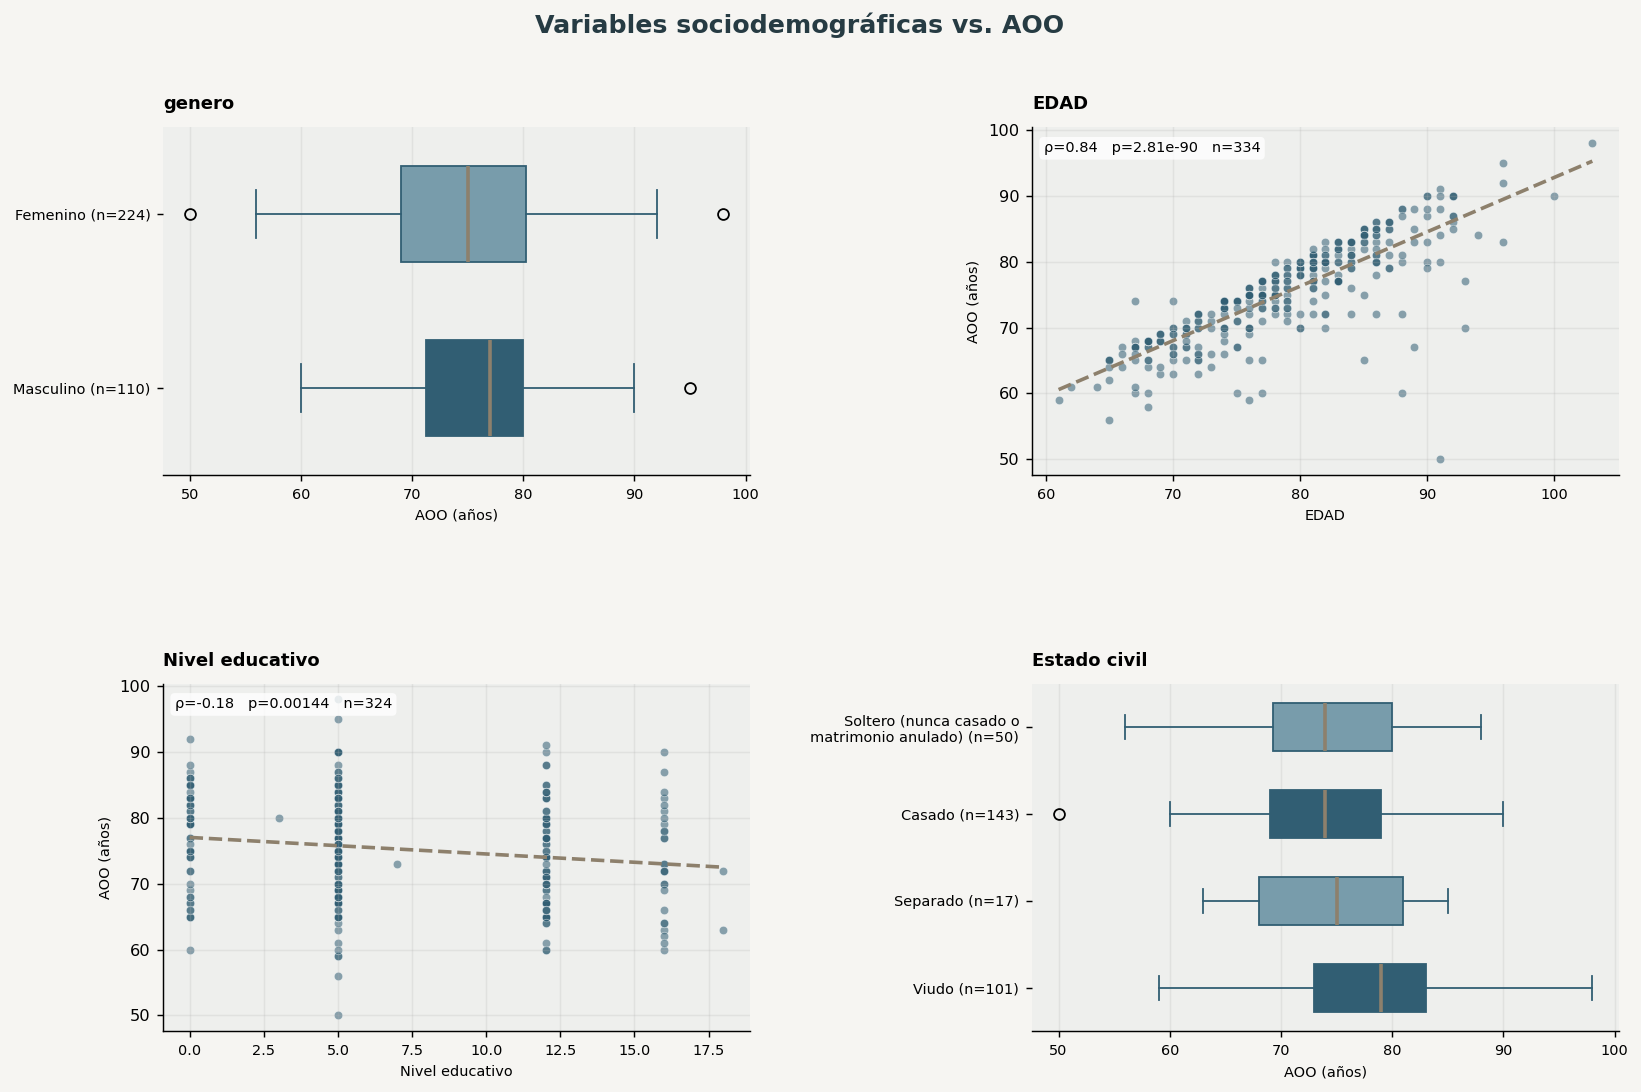

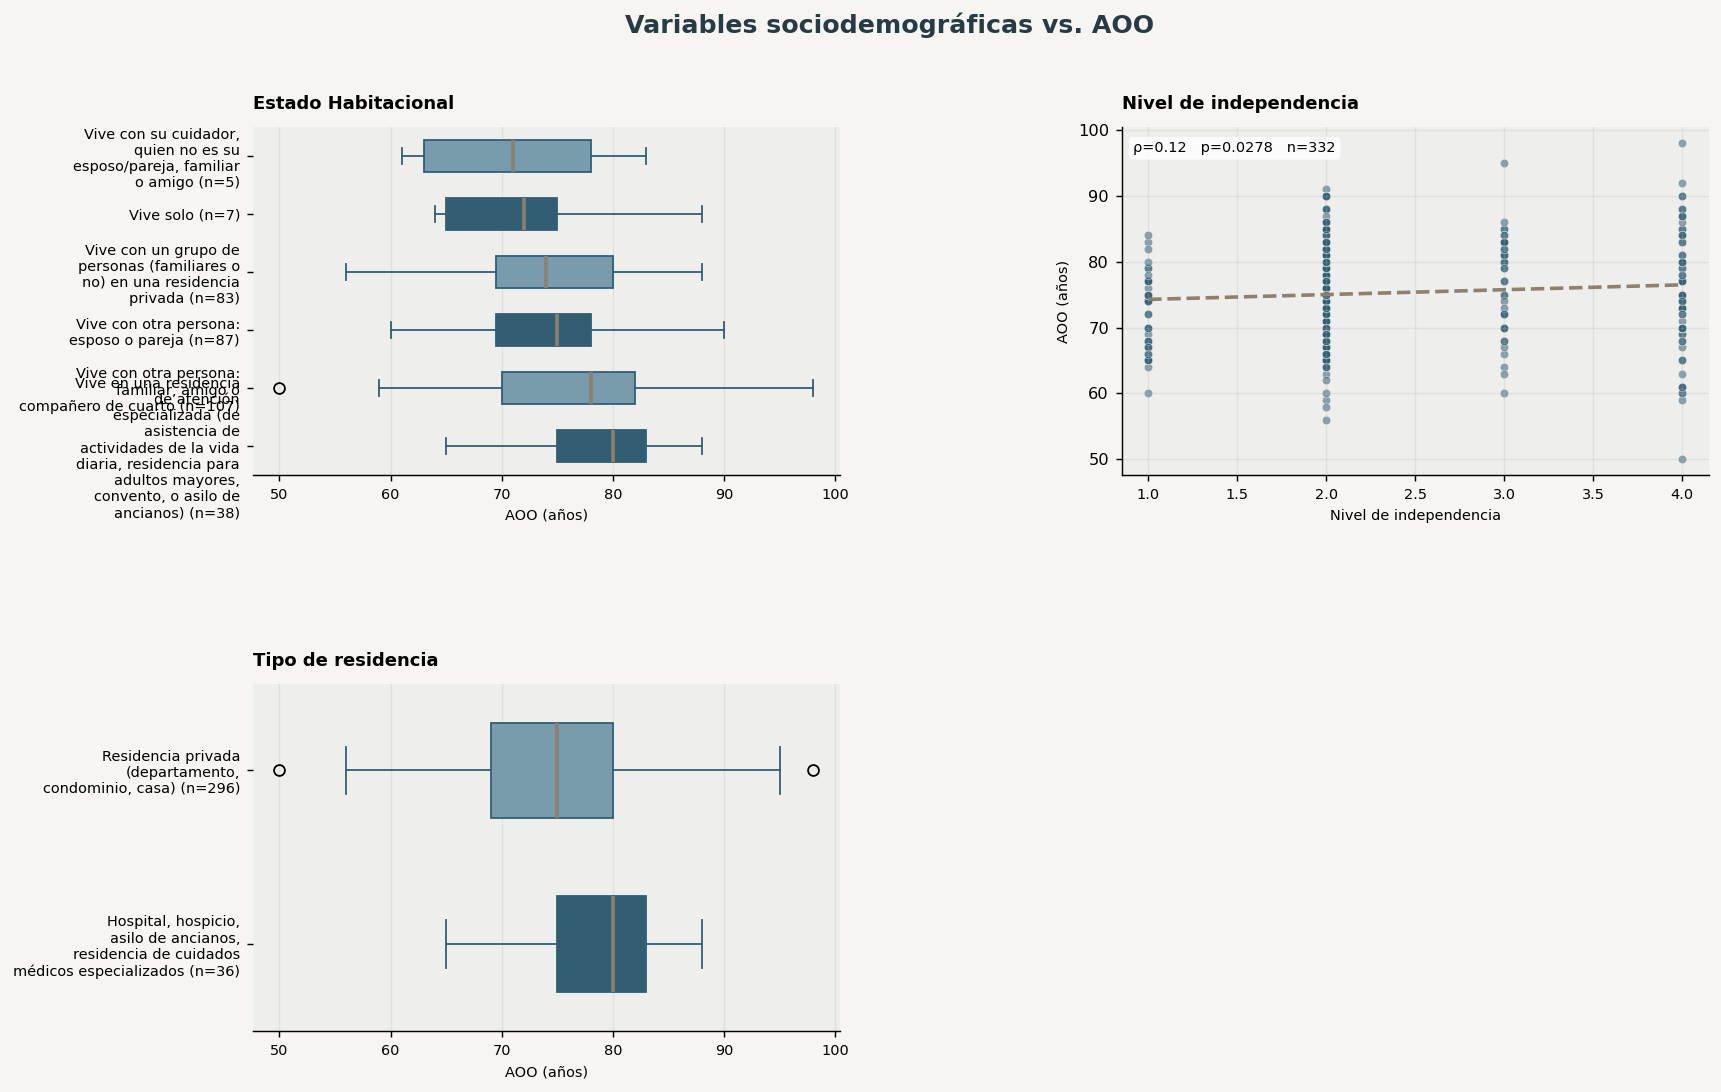

In [164]:
columnas = inventario.loc[(inventario.familia == 'sociodemograficas') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_sociodem = analisis_bivariado_familia(columnas, 'Variables sociodemográficas', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [62]:
mostrar_hallazgos_bivariados(tabla_biv_sociodem, 'variables sociodemográficas')


El análisis incluyó 8 variables sociodemográficas. 6 variables mostraron una señal estadística antes de corregir por las múltiples comparaciones. EDAD presentó una tendencia marcada: sus valores más altos coincidieron con una AOO mayor; su utilidad como covariable exige confirmar la temporalidad. Tipo de residencia mostró diferencias de AOO entre sus categorías (grupo Hospital, hospicio, asilo de ancianos, residencia de cuidados médicos especializados: 80.0 años, grupo Residencia privada (departamento, condominio, casa): 75.0 años); su utilidad como covariable exige confirmar la temporalidad. Estado Habitacional mostró diferencias de AOO entre sus categorías (grupo Vive con otra persona: esposo o pareja: 75.0 años, grupo Vive con otra persona: familiar, amigo o compañero de cuarto: 78.0 años, grupo Vive con su cuidador, quien no es su esposo/pareja, familiar o amigo: 71.0 años, grupo Vive con un grupo de personas (familiares o no) en una residencia privada: 74.0 años, grupo Vive en una residencia de atención especializada (de asistencia de actividades de la vida diaria, residencia para adultos mayores, convento, o asilo de ancianos): 80.0 años, y 1 grupo adicional); su utilidad como covariable exige confirmar la temporalidad. Nivel educativo presentó una tendencia débil: sus valores más altos coincidieron con una AOO menor; la interpretación de las categorías queda pendiente de validar su codificación. Otras 2 señales preliminares se detallan en la tabla. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudieron evaluarse formalmente 3 variables, entre ellas mes y año de nacimiento, IDIOMA, OTRO IDOMA.

### **22.3. AOO e informante y red de apoyo**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 5


**Pruebas de asociación con AOO — Informante y red de apoyo**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,Relación del Informante,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=6),334.0,14.5723,0.0292,épsilon cuadrado,Comparar medianas de AOO entre grupos,"{'Amigo, vecino o conocido de la familia/amigos/ trabajo o de la comunidad (por ejemplo, de la iglesia).': 80.0, 'Es...",True,,0.0124,NaN,
1,Tiempo (años de conocerce),texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
2,¿Vive el informante con el sujeto?,categórica nominal,Revisar temporalidad,True,U de Mann-Whitney,282.0,5589.5000,0.1046,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 74.0, 'Sí': 75.0}",True,,0.2287,NaN,
3,"Si el informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",ordinal,Revisar temporalidad,True,Spearman,226.0,-0.1027,-0.1027,rho de Spearman,Valores mayores se asocian con AOO menor,NaN,True,,0.1237,NaN,
4,"Si el informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?",ordinal,Revisar temporalidad,True,Spearman,226.0,-0.1011,-0.1011,rho de Spearman,Valores mayores se asocian con AOO menor,NaN,True,,0.1298,NaN,


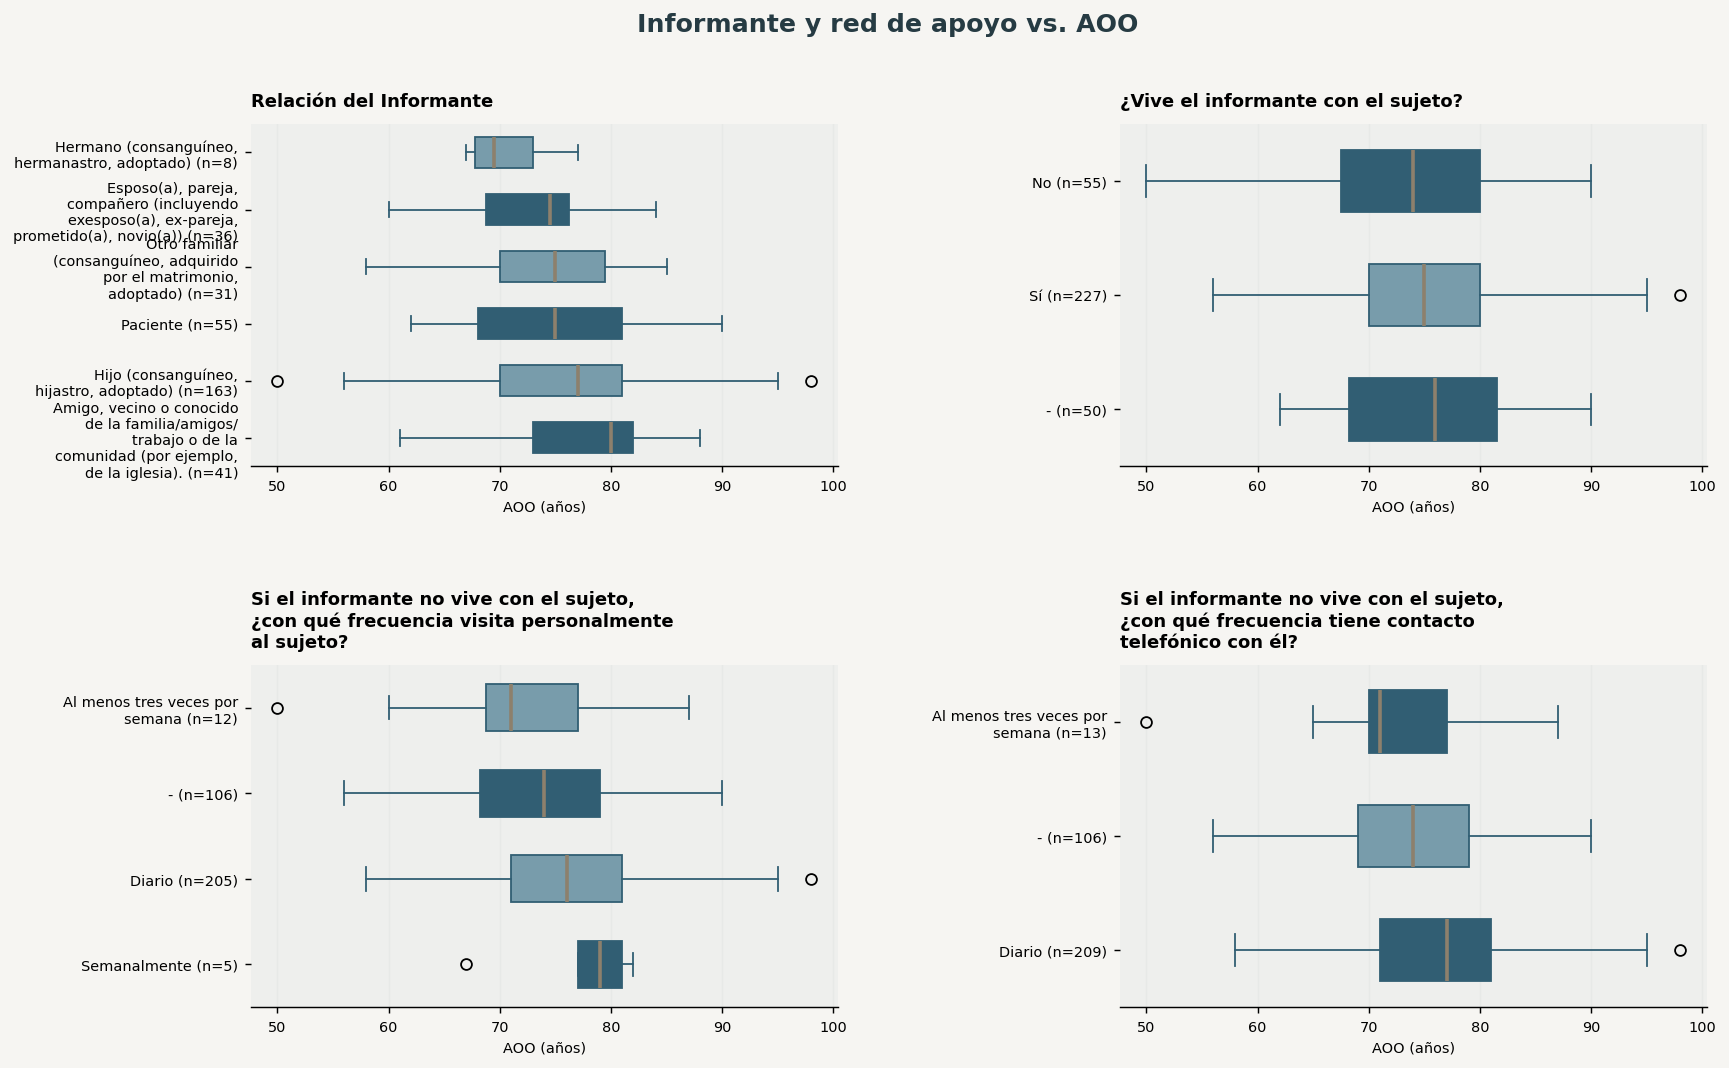

In [154]:
columnas = inventario.loc[(inventario.familia == 'informante_red_apoyo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_informante = analisis_bivariado_familia(columnas, 'Informante y red de apoyo', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [64]:
mostrar_hallazgos_bivariados(tabla_biv_informante, 'informante y red de apoyo')


El análisis incluyó 4 variables de informante y red de apoyo. Una variable mostró una señal estadística antes de corregir por las múltiples comparaciones. Relación del Informante mostró diferencias de AOO entre sus categorías (grupo Amigo, vecino o conocido de la familia/amigos/ trabajo o de la comunidad (por ejemplo, de la iglesia).: 80.0 años, grupo Esposo(a), pareja, compañero (incluyendo exesposo(a), ex-pareja, prometido(a), novio(a)): 74.5 años, grupo Hermano (consanguíneo, hermanastro, adoptado): 69.5 años, grupo Hijo (consanguíneo, hijastro, adoptado): 77.0 años, grupo Otro familiar (consanguíneo, adquirido por el matrimonio, adoptado): 74.5 años, y 1 grupo adicional); su utilidad como covariable exige confirmar la temporalidad. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudo evaluarse formalmente una variable: Tiempo (años de conocerce).

### **22.4. AOO e historia familiar**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 2


**Pruebas de asociación con AOO — Historia familiar**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,"¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres),...",categórica nominal,Bajo / revisar temporalidad,True,U de Mann-Whitney,320,13812.5000,-0.1241,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 76.0, 'Sí': 75.0}",True,,0.0599,NaN,
1,Familiar afectado,categórica nominal,Bajo,True,Kruskal-Wallis (k=6),171,4.0163,-0.0060,épsilon cuadrado,Comparar medianas de AOO entre grupos,"{'0': 74.0, 'Abuelos': 74.0, 'Dos': 72.0, 'Hermanos': 76.0, 'Padres': 72.5, 'Tios': 75.0}",True,,0.5471,NaN,


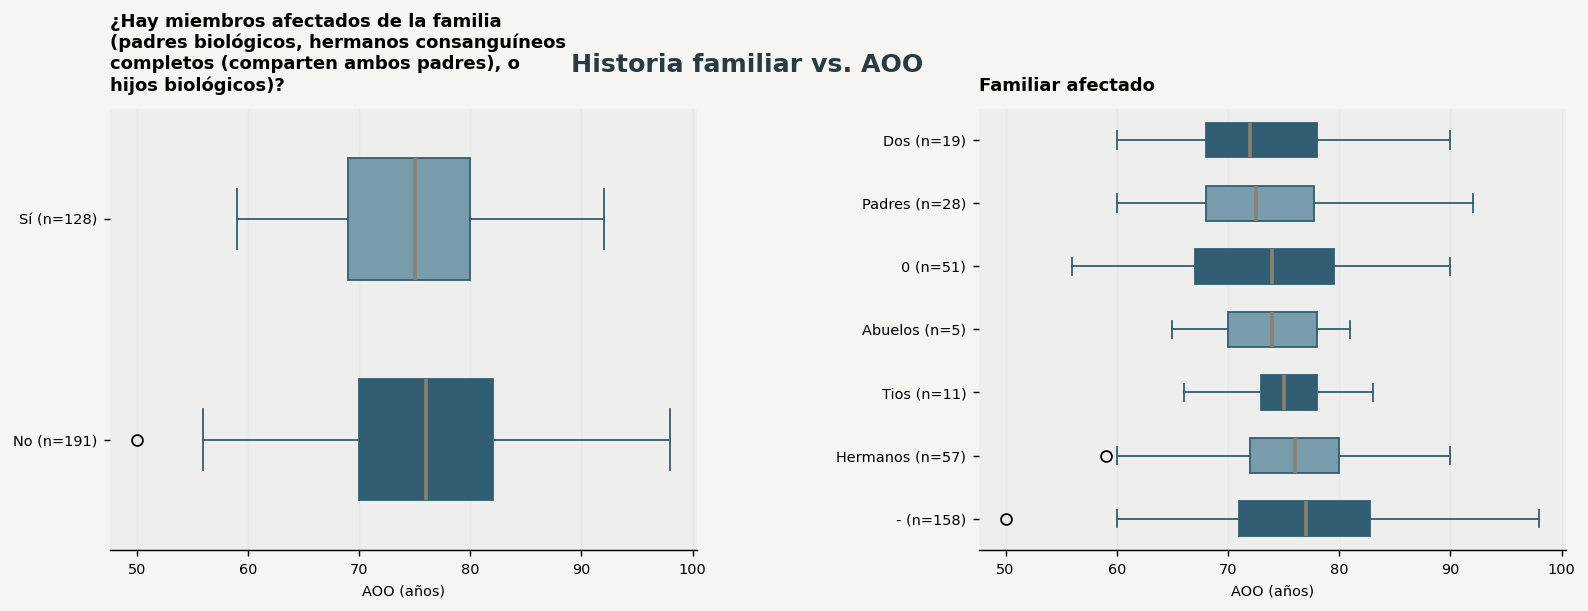

In [155]:
columnas = inventario.loc[(inventario.familia == 'historia_familiar') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_historia_familiar = analisis_bivariado_familia(columnas, 'Historia familiar', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [66]:
mostrar_hallazgos_bivariados(tabla_biv_historia_familiar, 'historia familiar')


El análisis incluyó 2 variables de historia familiar. En este análisis inicial no se observaron diferencias o tendencias claras de AOO para las variables de esta familia.

### **22.5. AOO y antropometría**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 2


**Pruebas de asociación con AOO — Antropometría**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,Peso,cuantitativa continua,Revisar temporalidad,True,Spearman,260,0.0281,0.0281,rho de Spearman,Valores mayores se asocian con AOO mayor,NaN,True,,0.6514,NaN,
1,Talla,cuantitativa continua,Revisar temporalidad,True,Spearman,299,0.0887,0.0887,rho de Spearman,Valores mayores se asocian con AOO mayor,NaN,True,,0.1259,NaN,


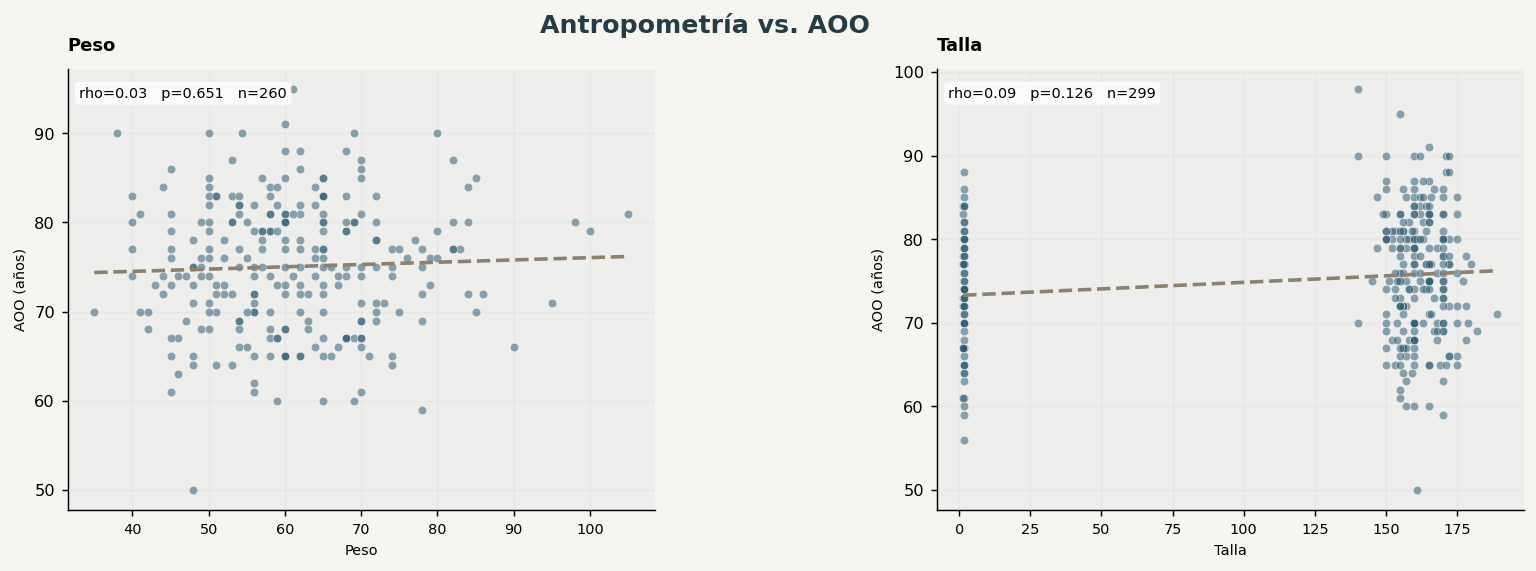

In [156]:
columnas = inventario.loc[(inventario.familia == 'antropometria') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_antropometria = analisis_bivariado_familia(columnas, 'Antropometría', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [68]:
mostrar_hallazgos_bivariados(tabla_biv_antropometria, 'antropometría')


El análisis incluyó 2 variables de antropometría. En este análisis inicial no se observaron diferencias o tendencias claras de AOO para las variables de esta familia.

### **22.6. AOO y medicamentos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


In [145]:
columnas = inventario.loc[(inventario.familia == 'medicamentos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_medicamentos = analisis_bivariado_familia(columnas, 'Medicamentos', pruebas_bivariadas_globales)


Variables integradas en la familia: 9


**Pruebas de asociación con AOO — Medicamentos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,MEDICAMENTO DEL SUJETO 1,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
1,MEDICAMENTO DEL SUJETO 2,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
2,MEDICAMENTO DEL SUJETO 3,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
3,MEDICAMENTO DEL SUJETO 4,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
4,MEDICAMENTO DEL SUJETO 5,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
5,MEDICAMENTO DEL SUJETO 6,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
6,MEDICAMENTO DEL SUJETO 7,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
7,MEDICAMENTO DEL SUJETO 8,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
8,MEDICAMENTO DEL SUJETO 9,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN


#### **Hallazgos principales**


In [70]:
mostrar_hallazgos_bivariados(tabla_biv_medicamentos, 'medicamentos')


En medicamentos ninguna variable reunió las condiciones mínimas para una comparación formal con la edad de inicio. Las 9 variables revisadas se excluyeron por tipo de dato, falta de variación o tamaño insuficiente.

### **22.7. AOO y tabaquismo/hábitos**

Se usa `serie_univariada`, que ya recodifica el código 99 de años de tabaquismo como faltante para esta vista, sin alterar la columna original.


Variables integradas en la familia: 3


**Pruebas de asociación con AOO — Tabaquismo y hábitos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,El sujeto ha fumado en los pasados 30 días,categórica nominal,Revisar temporalidad,False,NaN,327,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
1,¿El sujeto ha fumado más de 100 cigarros / cigarrillos en su vida?,categórica nominal,Revisar temporalidad,True,U de Mann-Whitney,326,9002.5000,0.0692,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 77.0}",True,,0.3564,NaN,
2,Número total de años que ha fumado el sujeto (99 = desconocido):,cuantitativa continua,Revisar temporalidad,True,Spearman,296,0.0731,0.0731,rho de Spearman,Valores mayores se asocian con AOO mayor,NaN,True,,0.2099,NaN,


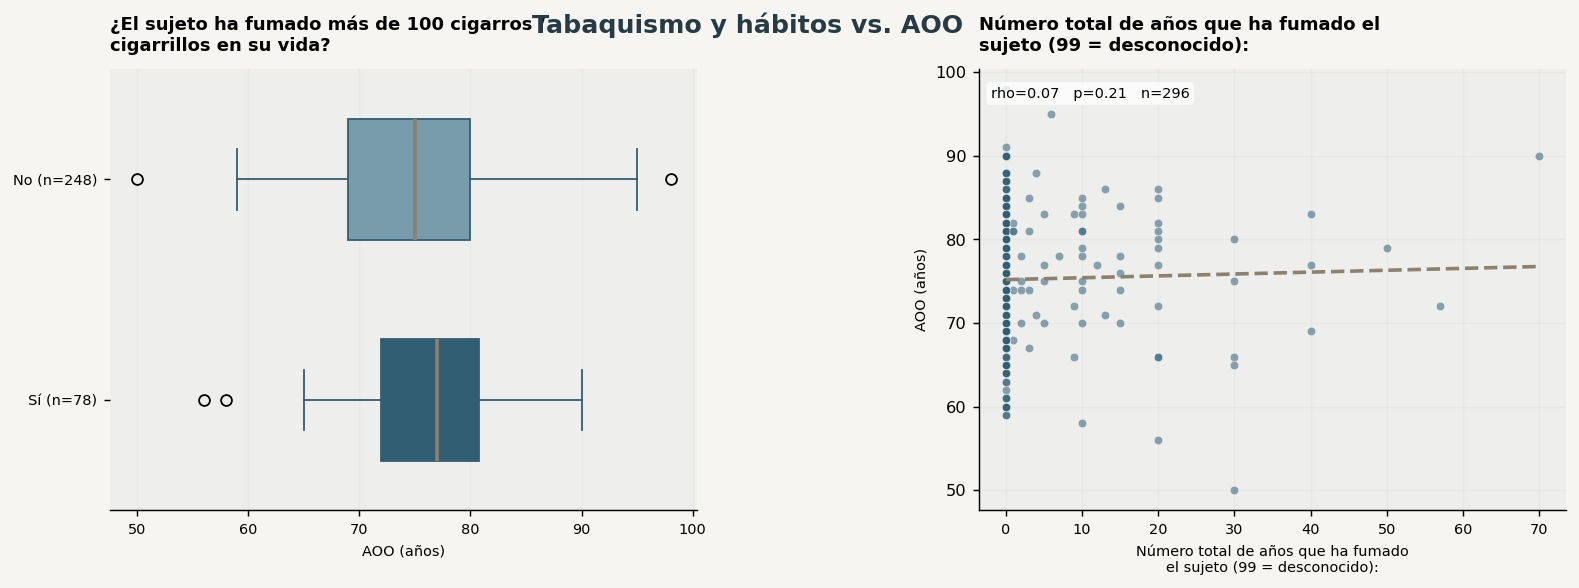

In [157]:
columnas = inventario.loc[(inventario.familia == 'tabaquismo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_tabaquismo = analisis_bivariado_familia(columnas, 'Tabaquismo y hábitos', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [72]:
mostrar_hallazgos_bivariados(tabla_biv_tabaquismo, 'tabaquismo y hábitos')


El análisis incluyó 3 variables de tabaquismo y hábitos. En este análisis inicial no se observaron diferencias o tendencias claras de AOO para las variables de esta familia.

### **22.8. AOO y antecedentes cardiovasculares/cerebrovasculares**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 7


**Pruebas de asociación con AOO — Antecedentes cardiovasculares y cerebrovasculares**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,Ataque cardiaco o paro cardíaco,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,333,1228.0,-0.2518,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 69.0}",True,,0.2910,NaN,
1,Fibrilación auricular,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,333,449.5,0.5418,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 80.5}",True,,0.0229,NaN,
2,Angioplastía/ endarterectomía/ stent,categórica nominal,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,False,Codificación pendiente de validación,NaN,Menos de 2 categorías con n≥5,NaN
3,Bypass cardíaco/coronario,categórica binaria,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
4,Marcapasos y/o desfibrilador,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,334,639.5,0.2225,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 80.0}",True,,0.3940,NaN,
5,Insuficiencia cardíaca congestiva,categórica binaria,Revisar temporalidad,False,NaN,330,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
6,ENFERMEDAD CEREBRO-VASCULAR (ECV),categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,333,1357.5,0.0689,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 75.0}",True,,0.7253,NaN,


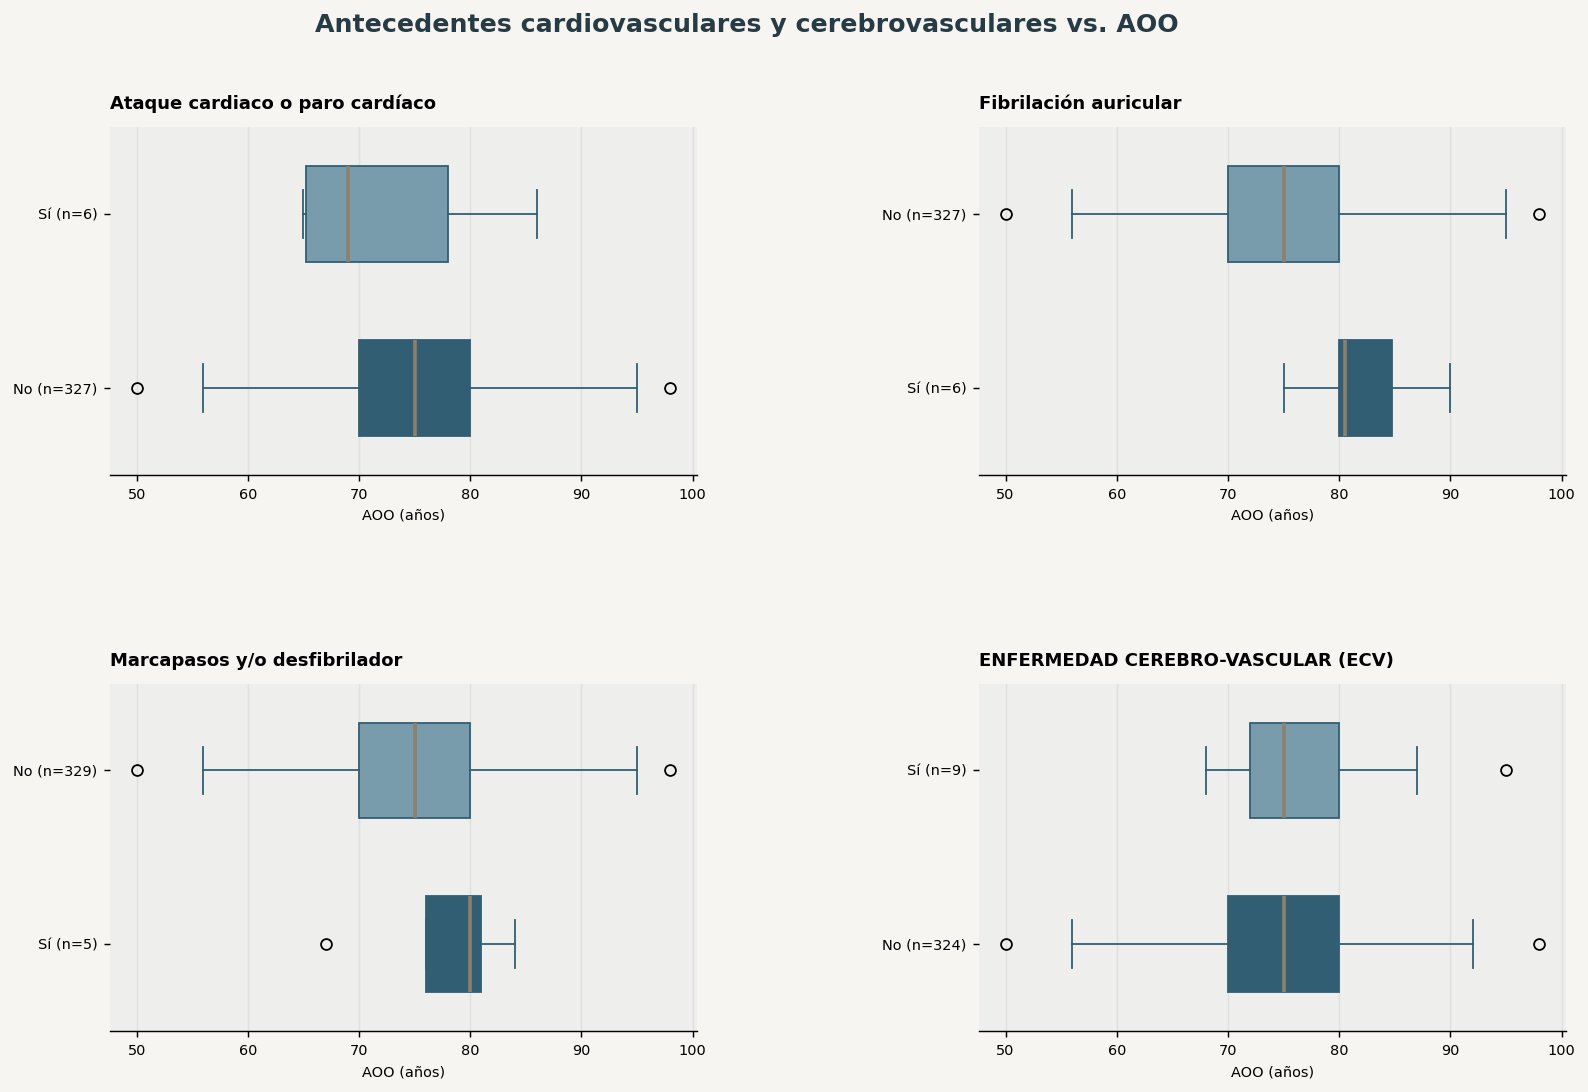

In [165]:
columnas = inventario.loc[(inventario.familia == 'cardiovasculares_cerebrovasculares') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_cardio = analisis_bivariado_familia(columnas, 'Antecedentes cardiovasculares y cerebrovasculares', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [74]:
mostrar_hallazgos_bivariados(tabla_biv_cardio, 'antecedentes cardiovasculares y cerebrovasculares')


El análisis incluyó 5 variables de antecedentes cardiovasculares y cerebrovasculares. Una variable mostró una señal estadística antes de corregir por las múltiples comparaciones. Fibrilación auricular mostró diferencias de AOO entre sus categorías (grupo 0: 75.0 años, grupo 1: 80.5 años); la interpretación de las categorías queda pendiente de validar su codificación; su utilidad como covariable exige confirmar la temporalidad. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudieron evaluarse formalmente 2 variables, entre ellas Angioplastía/ endarterectomía/ stent, Bypass cardíaco/coronario.

### **22.9. AOO y antecedentes neurológicos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


In [166]:
columnas = inventario.loc[(inventario.familia == 'neurologicos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_neurologicos = analisis_bivariado_familia(columnas, 'Antecedentes neurológicos', pruebas_bivariadas_globales)


Variables integradas en la familia: 3


**Pruebas de asociación con AOO — Antecedentes neurológicos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,PARKINSON,categórica binaria,Revisar temporalidad,False,NaN,331,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
1,CONVULSIONES,categórica binaria,Revisar temporalidad,False,NaN,330,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
2,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),categórica binaria,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN


Los antecedentes neurológicos no pudieron someterse a comparación formal con AOO debido a la baja frecuencia de casos positivos. Parkinson presentó menos de 5 pacientes en la categoría positiva, al igual que convulsiones, mientras que TCE no presentó variabilidad suficiente. Por tanto, estas variables se conservan para caracterización descriptiva, pero no se realiza inferencia bivariada.

#### **Hallazgos principales**


In [151]:
mostrar_hallazgos_bivariados(tabla_biv_neurologicos, 'antecedentes neurológicos')


En antecedentes neurológicos ninguna variable reunió las condiciones mínimas para una comparación formal con AOO.

### **22.10. AOO y comorbilidades/condiciones médicas**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 13


**Pruebas de asociación con AOO — Comorbilidades y condiciones médicas**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,DIABETES,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=3),332,1.4604,-0.0016,épsilon cuadrado,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Tipo 1': 77.0, 'Tipo 2': 76.0}",True,,0.4818,NaN,
1,CANCER,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,617.0000,0.2453,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 79.0}",True,,0.3473,NaN,
2,Hipercholesterolemia,categórica binaria,Revisar temporalidad,False,NaN,329,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
3,Hipertensión arterial,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,333,10615.0000,0.2212,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 73.0, 'Sí': 77.0}",True,,0.0005,NaN,
4,NIVELES DE VITAMINA D,categórica nominal,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,False,Codificación pendiente de validación,NaN,Menos de 2 categorías con n≥5,NaN
5,Deficiencia de B12,categórica binaria,Revisar temporalidad,False,NaN,333,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
6,Enfermedad tiroidea,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,334,2795.0000,0.0660,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 78.0}",True,,0.6295,NaN,
7,Artritis,categórica binaria,Revisar temporalidad,False,NaN,333,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
8,Artrosis,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,334,3326.5000,0.0307,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 76.5}",True,,0.8103,NaN,
9,Osteoporosis,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,334,1407.0000,0.0379,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 78.0}",True,,0.8472,NaN,


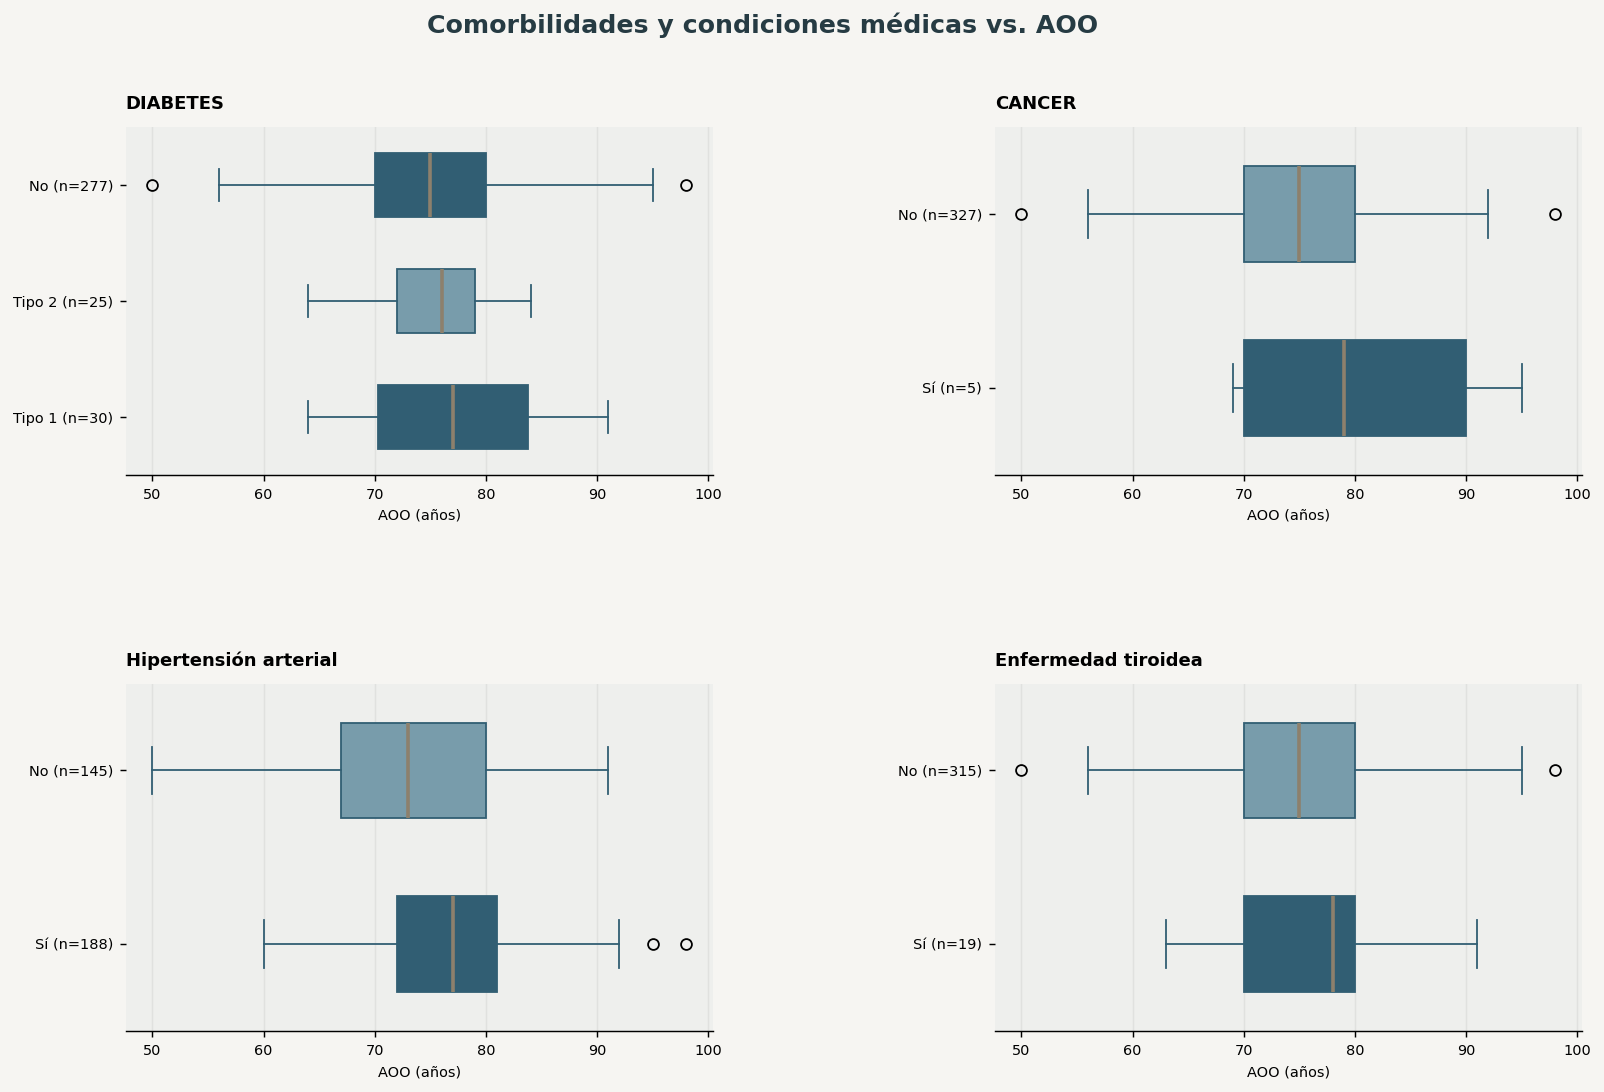

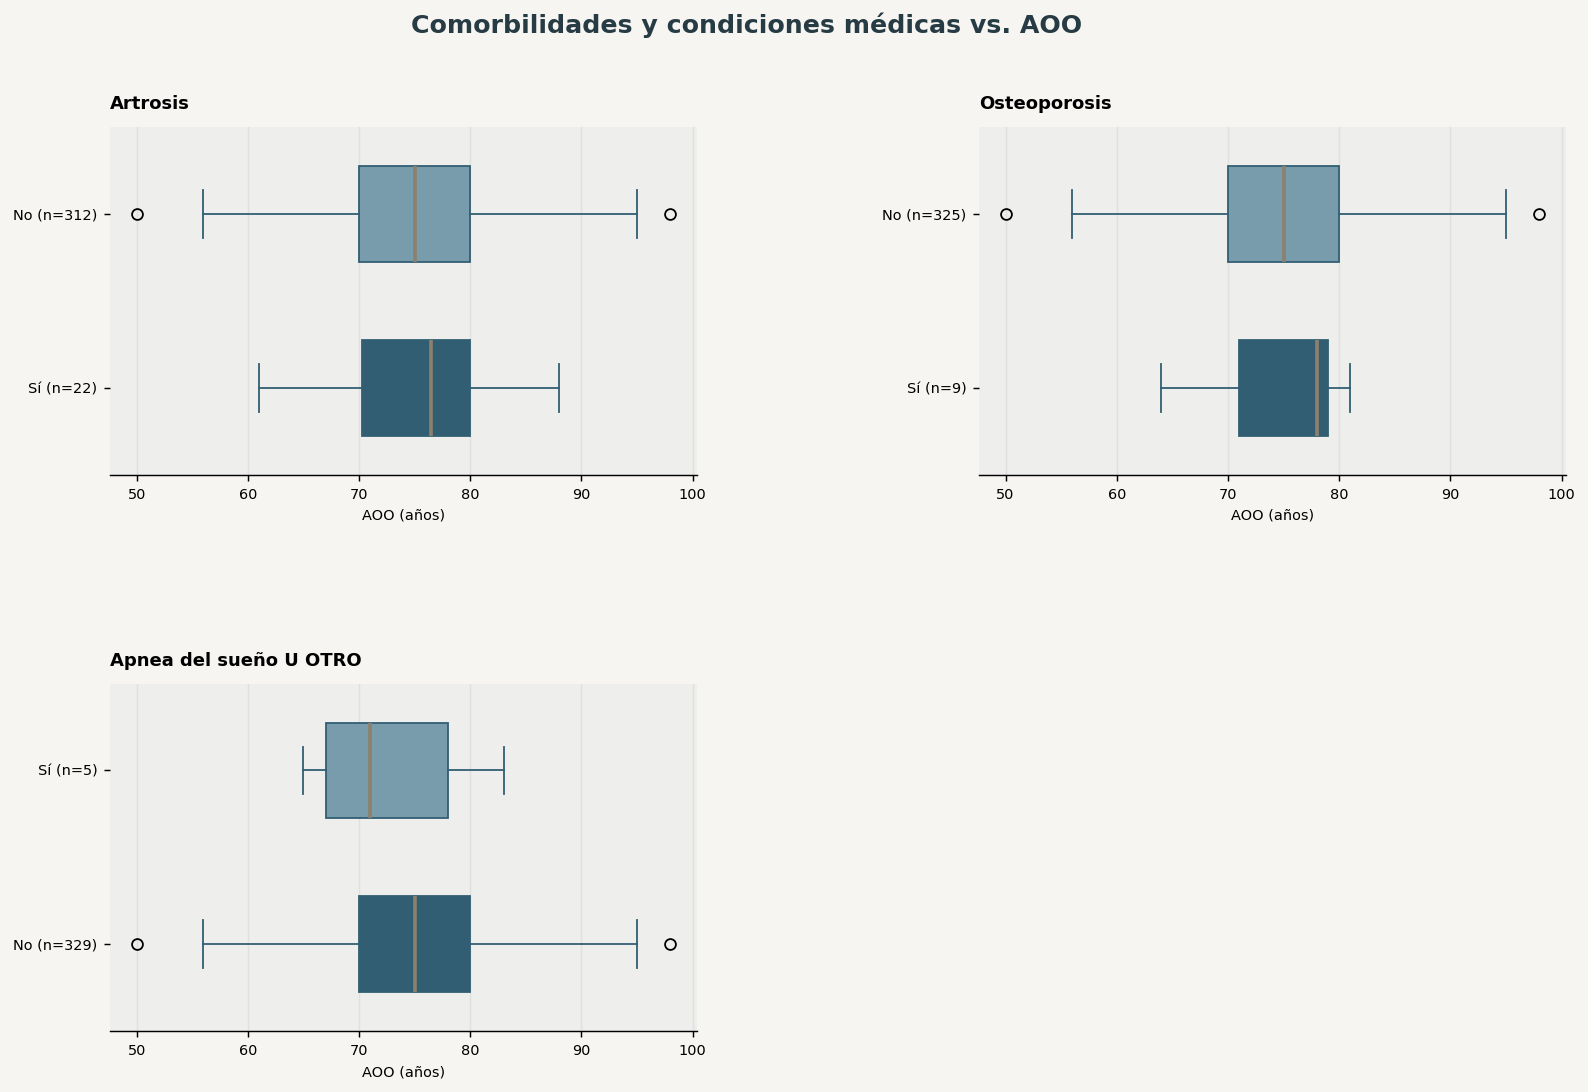

In [167]:
columnas = inventario.loc[(inventario.familia == 'metabolicos_otros') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_comorbilidades = analisis_bivariado_familia(columnas, 'Comorbilidades y condiciones médicas', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [78]:
mostrar_hallazgos_bivariados(tabla_biv_comorbilidades, 'comorbilidades y condiciones médicas')


El análisis incluyó 8 variables de comorbilidades y condiciones médicas. Una variable mostró una señal estadística antes de corregir por las múltiples comparaciones. Hipertensión arterial mostró diferencias de AOO entre sus categorías (grupo 0: 73.0 años, grupo 1: 77.0 años); la interpretación de las categorías queda pendiente de validar su codificación; su utilidad como covariable exige confirmar la temporalidad. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudieron evaluarse formalmente 5 variables, entre ellas NIVELES DE VITAMINA D, Deficiencia de B12, Artritis.

### **22.11. AOO y antecedentes psiquiátricos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 7


**Pruebas de asociación con AOO — Antecedentes psiquiátricos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,Trastorno de estrés postraumático (TEPT),categórica binaria,Revisar temporalidad,False,NaN,333,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
1,Trastorno bipolar,categórica binaria,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
2,Esquizofrenia,categórica binaria,Revisar temporalidad,False,NaN,331,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
3,Depresión,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,333,1225.0,-0.2487,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 75.0, 'Sí': 71.0}",True,,0.2969,NaN,
4,Ansiedad,categórica binaria,Revisar temporalidad,False,NaN,330,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
5,Trastorno obsesivo-compulsivo (TOC),categórica binaria,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN
6,"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención...",categórica binaria,Revisar temporalidad,False,NaN,334,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5,NaN


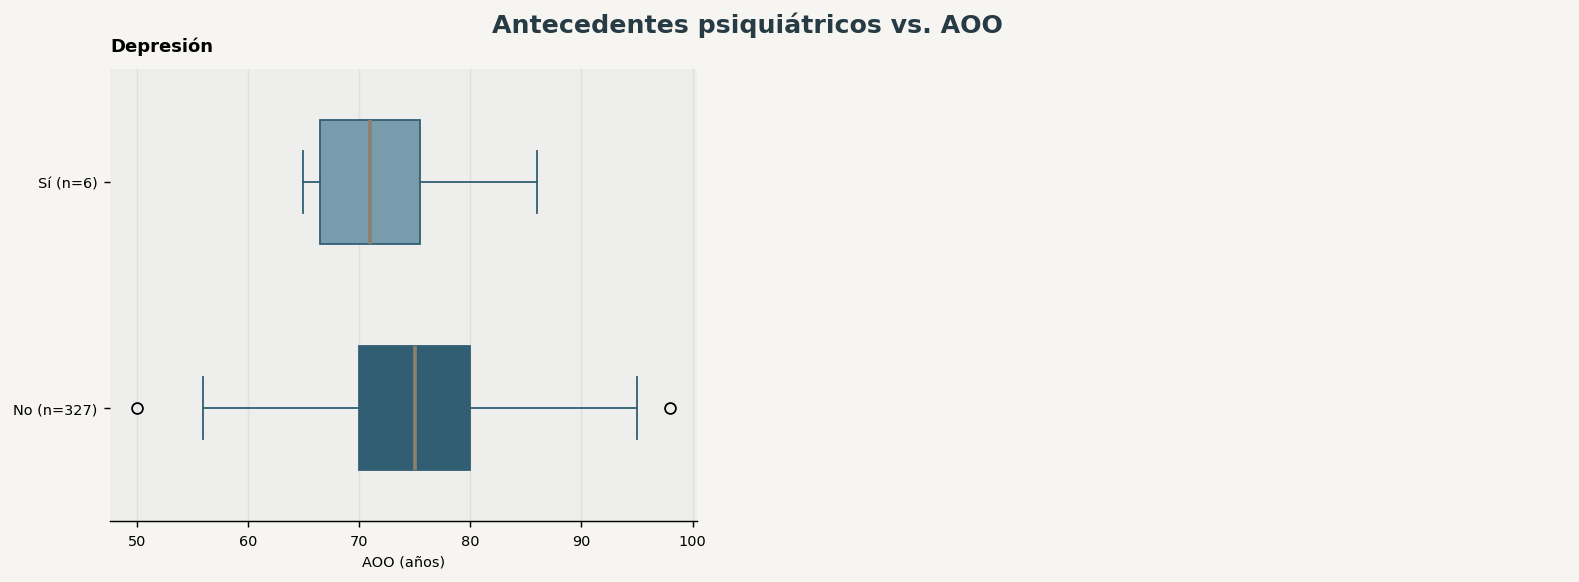

In [168]:
columnas = inventario.loc[(inventario.familia == 'psiquiatricos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_psiquiatricos = analisis_bivariado_familia(columnas, 'Antecedentes psiquiátricos', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [80]:
mostrar_hallazgos_bivariados(tabla_biv_psiquiatricos, 'antecedentes psiquiátricos')


El análisis incluyó 2 variables de antecedentes psiquiátricos. En este análisis inicial no se observaron diferencias o tendencias claras de AOO para las variables de esta familia. No pudieron evaluarse formalmente 5 variables, entre ellas Trastorno de estrés postraumático (TEPT), Trastorno bipolar, Esquizofrenia.

### **22.12. AOO y variables clínicas HXGEN**

Estas variables provienen de la cohorte maestra (`hxgen`); su relación con la temporalidad respecto al inicio de la enfermedad aún no está confirmada (riesgo de leakage «Revisar temporalidad» en la mayoría de los casos).


Variables integradas en la familia: 23


**Pruebas de asociación con AOO — Variables clínicas HXGEN**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,Edad,cuantitativa continua,Revisar temporalidad,True,Spearman,333.0,0.8244,0.8244,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.0000,NaN,
1,Ciudad o municipio de residencia,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
2,Enfermedad actual,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
3,¿Qué síntomas presenta?,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
4,El Paciente necesita apoyo para realizar las siguientes tareas,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
5,Indique que estudios previos le han realizado.,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
6,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
7,Antecedentes,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN
8,¿Actualmente se encuentra en algún tratamiento farmacológico?,categórica nominal,Revisar temporalidad,True,U de Mann-Whitney,333.0,6340.0000,0.1183,r biserial por rangos,Comparar medianas de AOO entre grupos,"{'No': 74.0, 'Sí': 76.0}",False,Codificación pendiente de validación,0.1784,NaN,Codificación pendiente de validación
9,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal,NaN


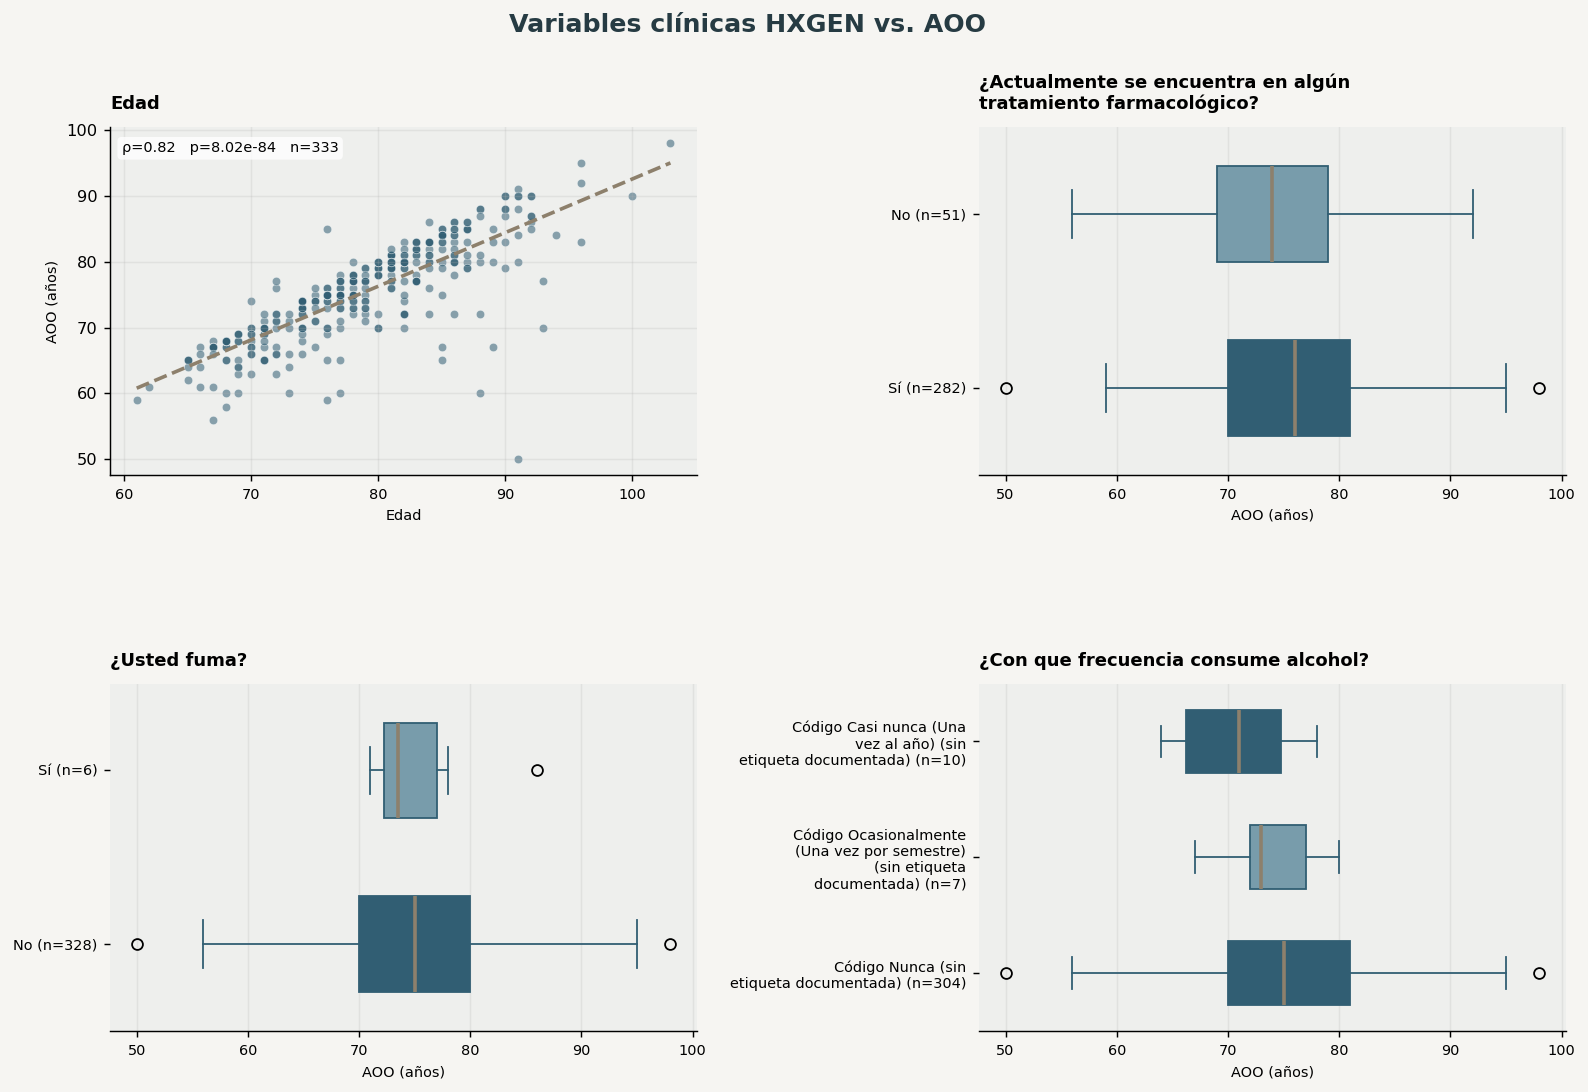

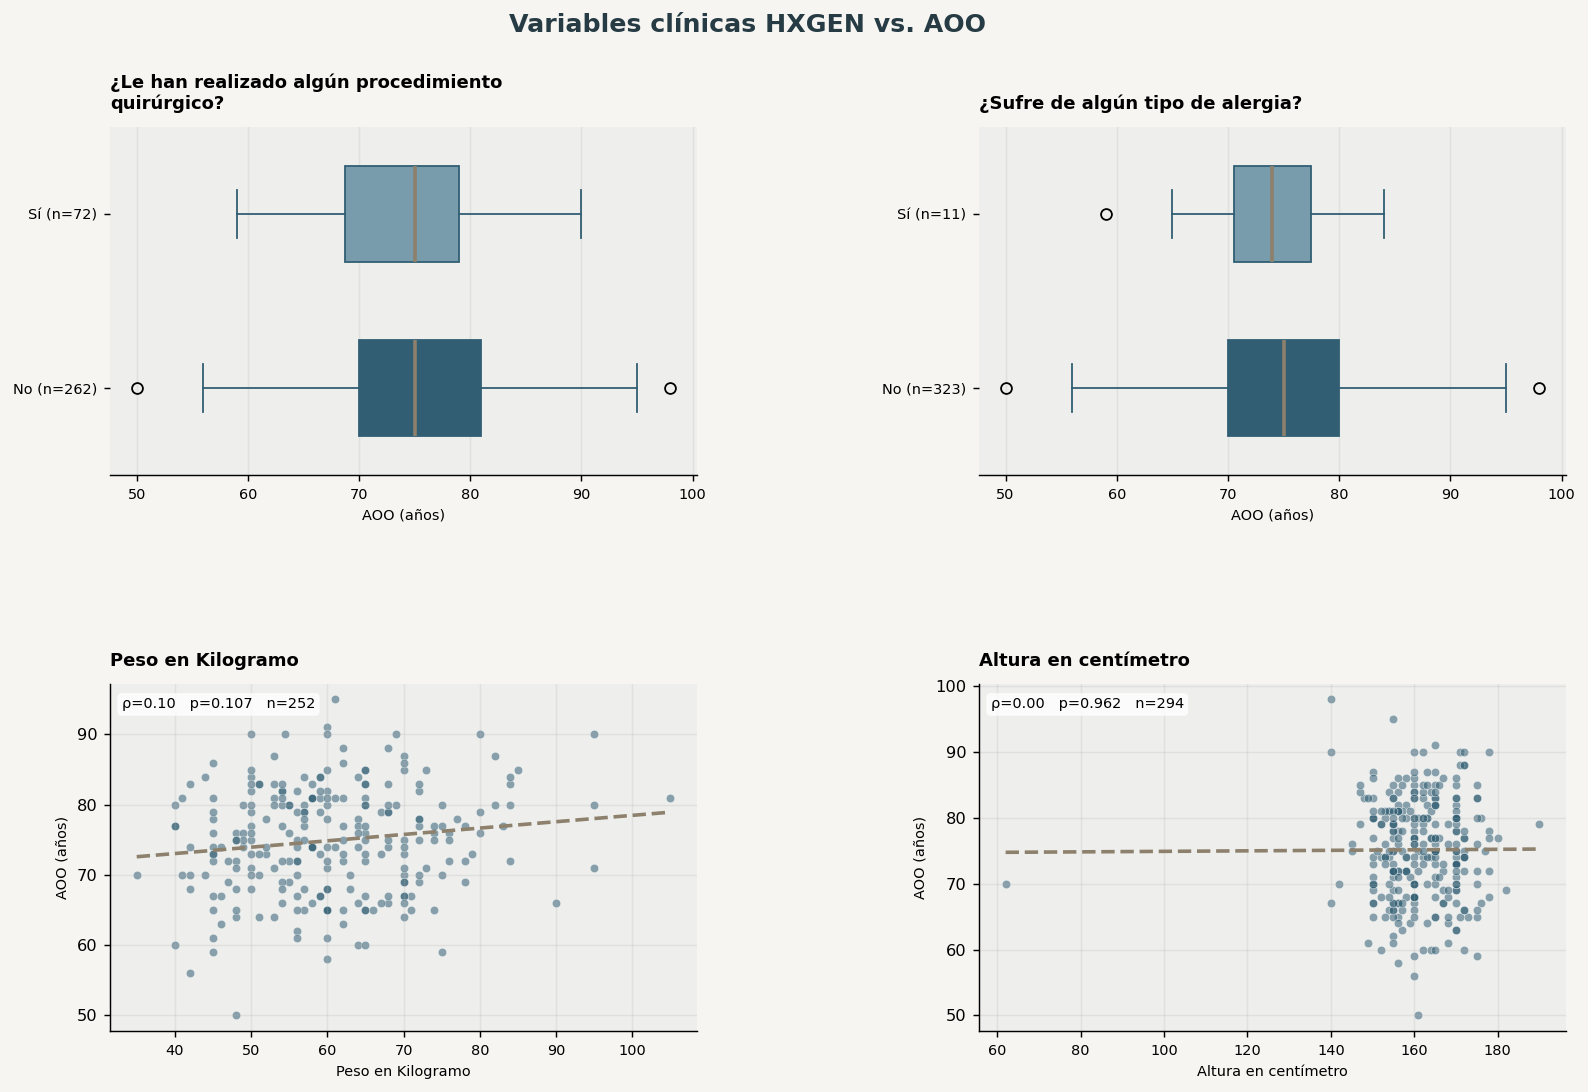

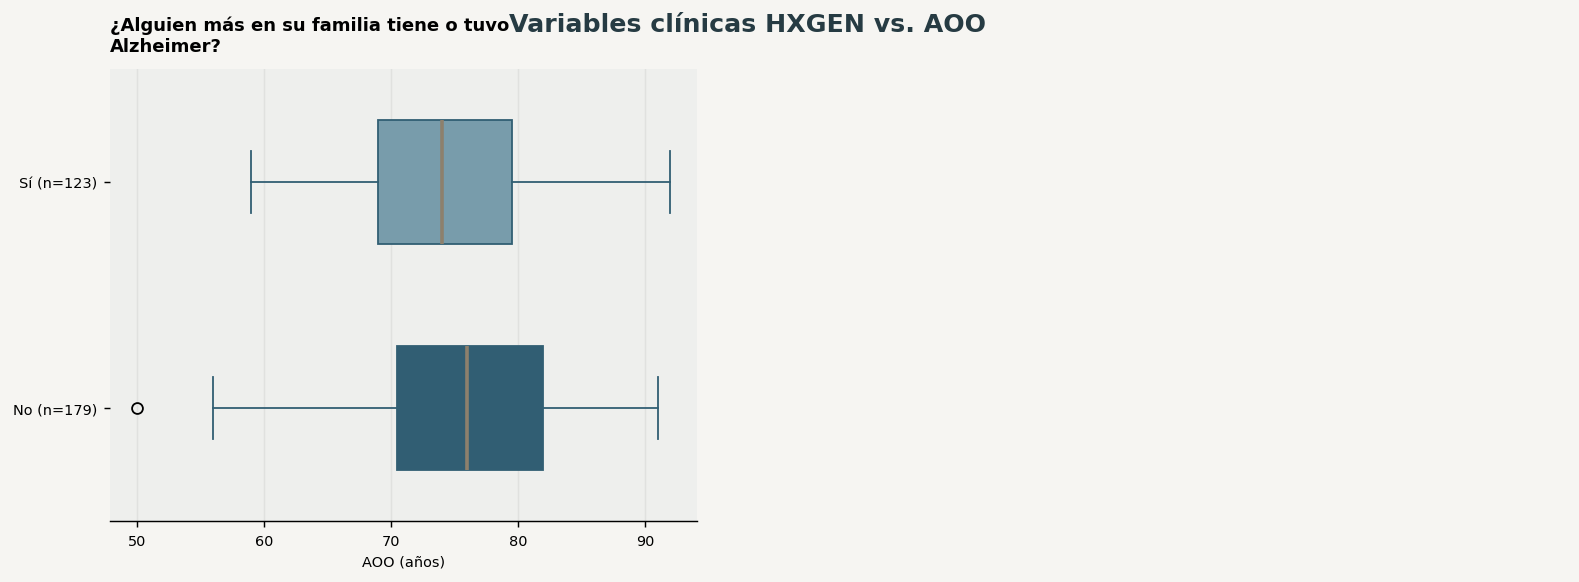

In [169]:
columnas = inventario.loc[(inventario.familia == 'historia_clinica_genetica') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_hxgen = analisis_bivariado_familia(columnas, 'Variables clínicas HXGEN', pruebas_bivariadas_globales)


#### **Hallazgos principales**


In [82]:
mostrar_hallazgos_bivariados(tabla_biv_hxgen, 'variables clínicas HXGEN')


El análisis incluyó 9 variables clínicas hxgen. 2 variables mostraron una señal estadística antes de corregir por las múltiples comparaciones. Edad presentó una tendencia marcada: sus valores más altos coincidieron con una AOO mayor; esta relación era esperable por el vínculo temporal entre edad actual y edad de inicio y no indica independencia como covariable; su utilidad como covariable exige confirmar la temporalidad. ¿Alguien más en su familia tiene o tuvo Alzheimer? mostró diferencias de AOO entre sus categorías (grupo No: 76.5 años, grupo Sí: 74.0 años); la interpretación de las categorías queda pendiente de validar su codificación; su utilidad como covariable exige confirmar la temporalidad. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudieron evaluarse formalmente 14 variables, entre ellas Ciudad o municipio de residencia, Enfermedad actual, ¿Qué síntomas presenta?.

### **22.13. Variables neuropsicológicas por dominio vs. AOO**

Se presenta una tabla de pruebas por dominio, sin un gráfico por variable. El panel gráfico completo se reserva para MMSE, MoCA y FAST.

> **Advertencia central:** estas pruebas constituyen una exploración secundaria. Muchas mediciones neuropsicológicas son contemporáneas o posteriores al inicio y tienen riesgo de leakage «Potencial» o «Alto». Que TSCOL, TSMYD, TSPAL u otra prueba sobreviva FDR significa únicamente que su valor actual covaría con AOO dentro de esta cohorte. **No demuestra que sea un modificador de la edad de inicio, un antecedente ni un predictor válido.**

TMTA se audita de forma específica porque mezcla números con comillas, signos `+`, guiones y ceros. No se fuerza su conversión ni se interpreta una prueba categórica mientras esa codificación no esté validada.


In [170]:
cols_nps_biv = list(dict.fromkeys([c for c in neuro_norm if c in base_full.columns] +
                                   (['moca__moca'] if 'moca__moca' in base_full.columns else [])))
resultados_nps_biv = [prueba_bivariada_aoo(c) for c in cols_nps_biv]
tabla_nps_biv = pd.DataFrame(resultados_nps_biv)
pruebas_bivariadas_globales.extend(resultados_nps_biv)

columnas_mostrar = ['variable', 'familia', 'tipo_analitico', 'riesgo_leakage_aoo', 'evaluable', 'prueba',
                     'n', 'estadistico', 'medida_efecto', 'medida_efecto_nombre', 'direccion',
                     'medianas_por_grupo', 'codificacion_validada', 'alerta_codificacion', 'p_valor', 'motivo']
for c in columnas_mostrar:
    if c not in tabla_nps_biv.columns: tabla_nps_biv[c] = np.nan

for dominio, tabla in tabla_nps_biv.groupby('familia', sort=False):
    display(Markdown('**' + dominio.replace('_', ' ').capitalize() + '**'))
    display(tabla[columnas_mostrar].drop(columns='familia').round(4).reset_index(drop=True))

display(Markdown(
    '**Nota de interpretación:** ver advertencia de leakage al inicio de esta subsección. '
    'Las correlaciones de redundancia entre pruebas neuropsicológicas ya figuran en la Sección 20.3 '
    'y no se repiten aquí.'))


display(Markdown('**Diagnóstico específico de formato para TMTA y TMTB**'))
display(pd.concat([diagnostico_conversion_numerica(c) for c in ('neuro__tmta','neuro__tmtb') if c in base_full.columns], ignore_index=True))
display(Markdown('TMTA queda fuera de inferencia formal hasta validar comillas, signo `+`, guiones y ceros. TMTB se conserva según la clasificación existente, pero también requiere confirmar el significado de cero antes de una interpretación clínica.'))


**Metadatos nps**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo
0,¿Hay valoración NPS anterior?,categórica binaria,Potencial,False,NaN,324.0,NaN,NaN,NaN,NaN,NaN,True,,NaN,Menos de 2 categorías con n≥5
1,Si tiene anteriormente valoración NPS ¿en que fecha se aplico?,texto libre / alta cardinalidad,Potencial,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal


**Cognicion global**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo
0,MMSE,cuantitativa discreta,Alto,True,Spearman,331.0,-0.0853,-0.0853,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.1216,NaN
1,ESC DETERIOROGLOBAL,ordinal,Alto,True,Spearman,333.0,-0.0102,-0.0102,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.8523,NaN
2,MoCA,cuantitativa discreta,Alto,True,Spearman,333.0,-0.0199,-0.0199,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.7169,NaN


**Memoria**

...

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo
0,QUEJAS SUBJETIVAS,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,,NaN,Tipo no apto para prueba formal
1,YESAVAGE,cuantitativa discreta,Alto,True,Spearman,320.0,0.0203,0.0203,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.7173,NaN
2,BARTHEL,cuantitativa discreta,Alto,True,Spearman,334.0,-0.0520,-0.0520,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.3430,NaN
3,LAWTON Y BRODY,cuantitativa discreta,Alto,True,Spearman,334.0,0.1419,0.1419,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.0094,NaN
4,IKATZ,cuantitativa discreta,Alto,True,Spearman,334.0,0.0415,0.0415,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.4493,NaN
5,FAST,ordinal,Alto,True,Spearman,334.0,0.0364,0.0364,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.5077,NaN


**Nota de interpretación:** ver advertencia de leakage al inicio de esta subsección. Las correlaciones de redundancia entre pruebas neuropsicológicas ya figuran en la Sección 20.3 y no se repiten aquí.

**Diagnóstico específico de formato para TMTA y TMTB**

,variable,n_no_faltante,convertible_directo_pct,convertible_limpio_pct,n_ceros,ejemplos_no_convertibles
0,TMTA,387,57.6,93.8,183,"{'No registrado': 24, '180""': 9, '240""': 4, '200""': 3, '70""': 3, '360""': 3, '179""': 2, '170""': 2, '160""': 2, '119""':..."
1,TMTB,306,100.0,100.0,286,{}


TMTA queda fuera de inferencia formal hasta validar comillas, signo `+`, guiones y ceros. TMTB se conserva según la clasificación existente, pero también requiere confirmar el significado de cero antes de una interpretación clínica.

#### **Hallazgos principales**


In [84]:
mostrar_hallazgos_bivariados(tabla_nps_biv, 'variables neuropsicológicas por dominio')


El análisis incluyó 54 variables neuropsicológicas por dominio. 18 variables mostraron una señal estadística antes de corregir por las múltiples comparaciones. TSCOL presentó una tendencia débil: sus valores más altos coincidieron con una AOO menor; por su riesgo de leakage, este resultado describe covariación clínica y no un modificador de AOO. TSMYDORAL presentó una tendencia débil: sus valores más altos coincidieron con una AOO menor; por su riesgo de leakage, este resultado describe covariación clínica y no un modificador de AOO. TSMYD ESCR presentó una tendencia débil: sus valores más altos coincidieron con una AOO menor; por su riesgo de leakage, este resultado describe covariación clínica y no un modificador de AOO. TSPAL presentó una tendencia débil: sus valores más altos coincidieron con una AOO menor; por su riesgo de leakage, este resultado describe covariación clínica y no un modificador de AOO. Otras 14 señales preliminares se detallan en la tabla. Estas señales deben contrastarse con el ajuste FDR del resumen consolidado. No pudieron evaluarse formalmente 3 variables, entre ellas Si tiene anteriormente valoración NPS ¿en que fecha se aplico?, TMTA, QUEJAS SUBJETIVAS.

### **22.14. Cognición global y estado funcional (MMSE, MoCA, FAST) vs. AOO**

Panel gráfico completo (dispersión para MMSE y MoCA, cajas por estadio para FAST) para las tres variables priorizadas en la Sección 20.4. Las tres tienen riesgo de leakage «Alto»: se exploran por su relevancia clínica, no como predictores válidos de AOO.


**Pruebas de asociación con AOO — Cognición global y estado funcional: MMSE, MoCA y FAST**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,direccion,medianas_por_grupo,codificacion_validada,alerta_codificacion,p_valor,motivo,nota
0,MMSE,cuantitativa discreta,Alto,True,Spearman,331,-0.0853,-0.0853,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.1216,NaN,
1,MoCA,cuantitativa discreta,Alto,True,Spearman,333,-0.0199,-0.0199,rho de Spearman,Valores mayores asociados con AOO menor,NaN,True,,0.7169,NaN,
2,FAST,ordinal,Alto,True,Spearman,334,0.0364,0.0364,rho de Spearman,Valores mayores asociados con AOO mayor,NaN,True,,0.5077,NaN,


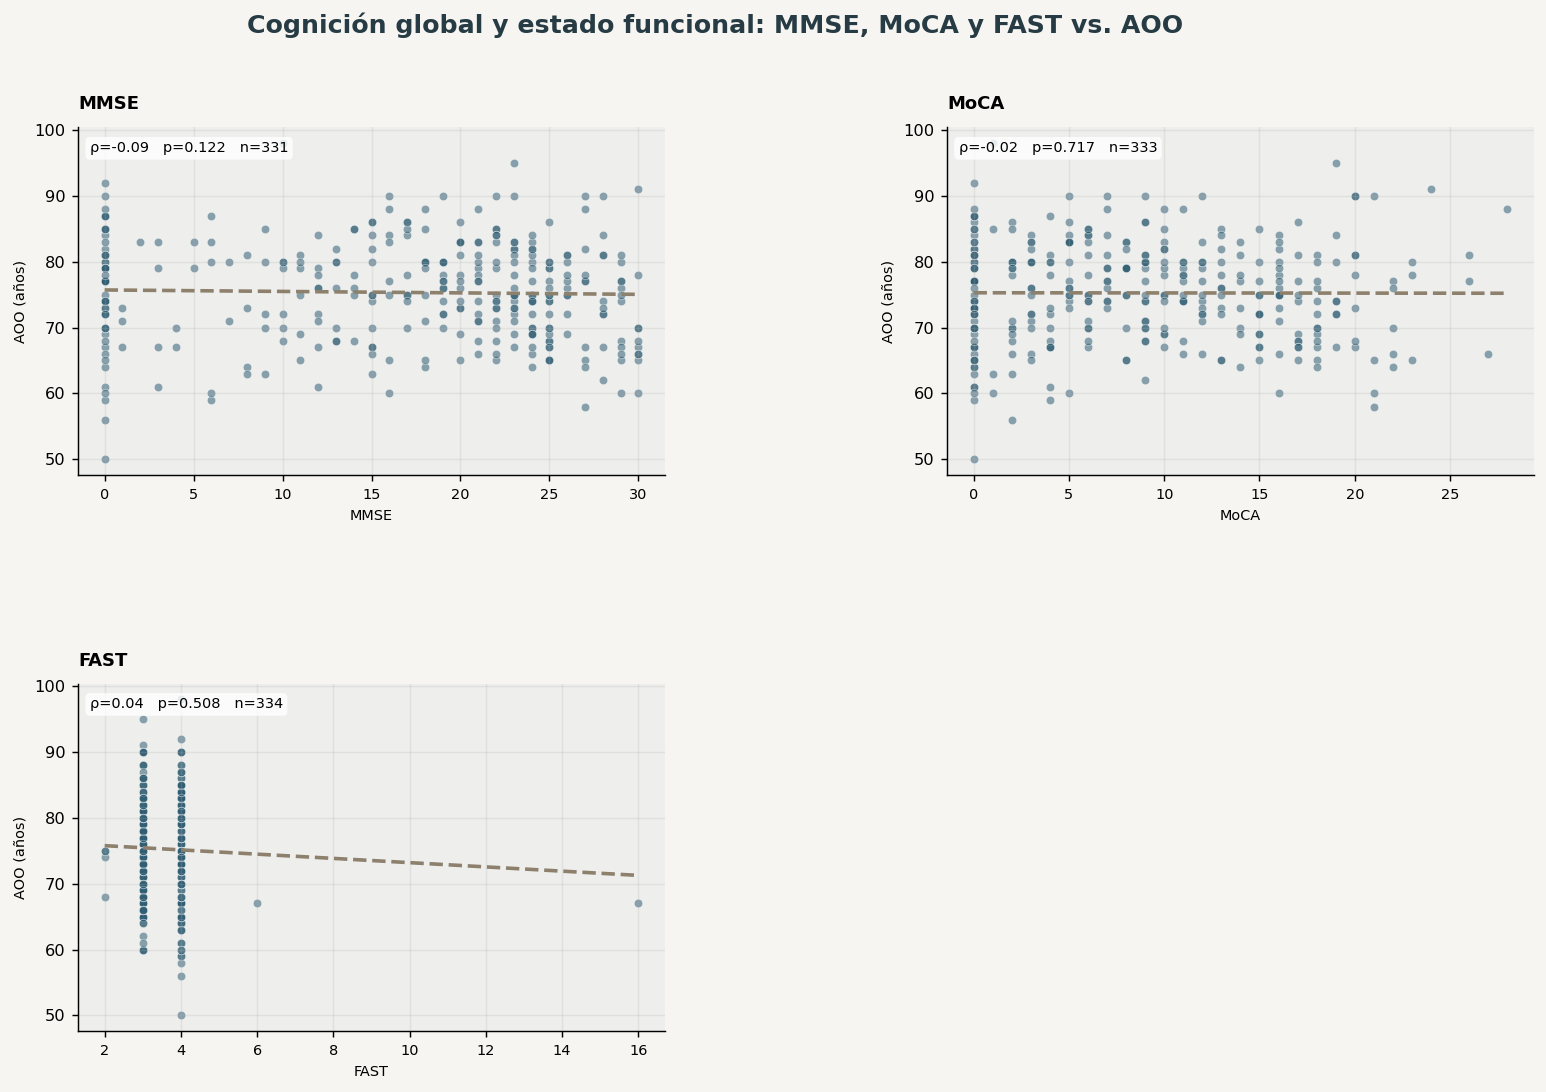

In [171]:
core_bivariado = [c for c in ('neuro__mmse', 'moca__moca', 'neuro__fast') if c in base_full.columns]
tabla_biv_core = analisis_bivariado_familia(
    core_bivariado,
    'Cognición global y estado funcional: MMSE, MoCA y FAST',
    pruebas_bivariadas_globales
)


#### **Hallazgos principales**


In [86]:
mostrar_hallazgos_bivariados(tabla_biv_core, 'cognición global y estado funcional')


El análisis incluyó 3 variables de cognición global y estado funcional. En este análisis inicial no se observaron diferencias o tendencias claras de AOO para las variables de esta familia.

### **22.15. Tabla consolidada de asociaciones con AOO y corrección por comparaciones múltiples**

Se consolidan todas las pruebas acumuladas en `pruebas_bivariadas_globales` (una fila por variable única; si una variable fue probada en más de una subsección —p. ej. MMSE, MoCA o FAST, presentes tanto en 22.13 como en 22.14— se conserva un único registro). Sobre el conjunto de pruebas evaluables se aplica la corrección de Benjamini-Hochberg (FDR) para controlar la tasa de falsos descubrimientos dado el número de comparaciones realizadas.

Los resultados se presentan también segmentados por `riesgo_leakage_aoo`, para separar explícitamente las asociaciones más interpretables como posibles covariables previas al inicio (riesgo «Bajo») de aquellas que reflejan sobre todo el estado clínico actual (riesgo «Alto»/«Potencial») o que requieren validar la temporalidad («Revisar temporalidad»).


In [173]:
tabla_global_bivariado = (pd.DataFrame(pruebas_bivariadas_globales)
                           .drop_duplicates(subset='columna').reset_index(drop=True))
evaluables = tabla_global_bivariado.loc[tabla_global_bivariado['evaluable']].copy()
no_evaluables = tabla_global_bivariado.loc[~tabla_global_bivariado['evaluable']].copy()

rechazo, p_ajustado, _, _ = multipletests(evaluables['p_valor'], method='fdr_bh', alpha=.05)
evaluables['p_ajustado_fdr'] = p_ajustado
evaluables['significativo_fdr_005'] = rechazo
evaluables = evaluables.sort_values('p_ajustado_fdr').reset_index(drop=True)

# Los IC se calculan para resultados destacados tras FDR, evitando una carga
# innecesaria para todas las pruebas exploratorias.
evaluables['ic95_efecto_inf'] = np.nan; evaluables['ic95_efecto_sup'] = np.nan
for idx, fila in evaluables.loc[evaluables.significativo_fdr_005].iterrows():
    lo, hi = bootstrap_ic_efecto(fila.columna, fila.prueba.split(' (')[0], n_boot=1000)
    evaluables.loc[idx, ['ic95_efecto_inf','ic95_efecto_sup']] = [lo, hi]

display(Markdown(
    f'**Benjamini–Hochberg (FDR, α=0.05):** {len(evaluables)} pruebas evaluables; '
    f'{int((evaluables.p_valor < .05).sum())} con p crudo < 0.05 y '
    f'{int(evaluables.significativo_fdr_005.sum())} significativas tras FDR. '
    'Los IC 95% bootstrap se muestran para estas últimas.'))

columnas_mostrar_global = ['variable','familia','tipo_analitico','riesgo_leakage_aoo',
    'codificacion_validada','alerta_codificacion','prueba','n','estadistico','medida_efecto',
    'ic95_efecto_inf','ic95_efecto_sup','direccion','medianas_por_grupo','p_valor',
    'p_ajustado_fdr','significativo_fdr_005']
for col in columnas_mostrar_global:
    if col not in evaluables: evaluables[col]=np.nan
display(evaluables[columnas_mostrar_global].round(4).head(10))


**Benjamini–Hochberg (FDR, α=0.05):** 81 pruebas evaluables; 28 con p crudo < 0.05 y 22 significativas tras FDR. Los IC 95% bootstrap se muestran para estas últimas.

,variable,familia,tipo_analitico,riesgo_leakage_aoo,codificacion_validada,alerta_codificacion,prueba,n,estadistico,medida_efecto,ic95_efecto_inf,ic95_efecto_sup,direccion,medianas_por_grupo,p_valor,p_ajustado_fdr,significativo_fdr_005
0,EDAD,sociodemograficas,cuantitativa continua,Bajo / revisar temporalidad,True,,Spearman,334.0,0.8403,0.8403,0.7825,0.8923,Valores mayores asociados con AOO mayor,NaN,0.0000,0.0000,True
1,Edad,historia_clinica_genetica,cuantitativa continua,Revisar temporalidad,True,,Spearman,333.0,0.8244,0.8244,0.7602,0.8751,Valores mayores asociados con AOO mayor,NaN,0.0000,0.0000,True
2,TSCOL,funcion_ejecutiva_atencion,cuantitativa discreta,Potencial,True,,Spearman,311.0,-0.2302,-0.2302,-0.3399,-0.1132,Valores mayores asociados con AOO menor,NaN,0.0000,0.0011,True
3,TSMYDORAL,memoria_semantica_conocimiento,cuantitativa discreta,Potencial,True,,Spearman,309.0,-0.2265,-0.2265,-0.3237,-0.1197,Valores mayores asociados con AOO menor,NaN,0.0001,0.0012,True
4,TSMYD ESCR,memoria_semantica_conocimiento,cuantitativa discreta,Potencial,True,,Spearman,309.0,-0.2177,-0.2177,-0.3228,-0.1092,Valores mayores asociados con AOO menor,NaN,0.0001,0.0018,True
5,TSPAL,funcion_ejecutiva_atencion,cuantitativa discreta,Potencial,True,,Spearman,312.0,-0.2027,-0.2027,-0.3058,-0.0910,Valores mayores asociados con AOO menor,NaN,0.0003,0.0043,True
6,Hipertensión arterial,metabolicos_otros,categórica binaria,Revisar temporalidad,True,,U de Mann-Whitney,333.0,10615.0000,0.2212,0.0971,0.3415,Comparar medianas de AOO entre grupos,"{'No': 73.0, 'Sí': 77.0}",0.0005,0.0062,True
7,Nivel educativo,sociodemograficas,ordinal,Bajo,True,,Spearman,324.0,-0.1763,-0.1763,-0.2815,-0.0687,Valores mayores asociados con AOO menor,NaN,0.0014,0.0099,True
8,TSPALCOL,funcion_ejecutiva_atencion,cuantitativa discreta,Potencial,True,,Spearman,311.0,-0.1797,-0.1797,-0.2928,-0.0668,Valores mayores asociados con AOO menor,NaN,0.0015,0.0099,True
9,FCROCOP,praxia_visuoconstruccion,cuantitativa discreta,Potencial,True,,Spearman,328.0,-0.1789,-0.1789,-0.2805,-0.0715,Valores mayores asociados con AOO menor,NaN,0.0011,0.0099,True


In [174]:
def grupo_interpretacion_fdr(riesgo):
    if riesgo == 'Bajo': return '1. Significativas tras FDR — riesgo Bajo'
    if riesgo in ('Revisar temporalidad','Bajo / revisar temporalidad','Revisar'):
        return '2. Significativas tras FDR — requiere revisar temporalidad'
    return '3. Significativas tras FDR — riesgo Potencial/Alto'

resumen_fdr_tres_grupos = evaluables.loc[evaluables.significativo_fdr_005].copy()
resumen_fdr_tres_grupos['grupo_metodologico'] = resumen_fdr_tres_grupos.riesgo_leakage_aoo.map(grupo_interpretacion_fdr)
cols_resumen = ['variable','familia','riesgo_leakage_aoo','prueba','n','medida_efecto',
                'ic95_efecto_inf','ic95_efecto_sup','direccion','medianas_por_grupo',
                'p_ajustado_fdr','codificacion_validada','alerta_codificacion']
for grupo in ['1. Significativas tras FDR — riesgo Bajo',
              '2. Significativas tras FDR — requiere revisar temporalidad',
              '3. Significativas tras FDR — riesgo Potencial/Alto']:
    display(Markdown('#### '+grupo))
    sub=resumen_fdr_tres_grupos.loc[resumen_fdr_tres_grupos.grupo_metodologico.eq(grupo),cols_resumen]
    if sub.empty: display(Markdown('Ninguna asociación en este grupo.'))
    else: display(sub.round(4).reset_index(drop=True))


#### 1. Significativas tras FDR — riesgo Bajo

,variable,familia,riesgo_leakage_aoo,prueba,n,medida_efecto,ic95_efecto_inf,ic95_efecto_sup,direccion,medianas_por_grupo,p_ajustado_fdr,codificacion_validada,alerta_codificacion
0,Nivel educativo,sociodemograficas,Bajo,Spearman,324.0,-0.1763,-0.2815,-0.0687,Valores mayores asociados con AOO menor,NaN,0.0099,True,


#### 2. Significativas tras FDR — requiere revisar temporalidad

,variable,familia,riesgo_leakage_aoo,prueba,n,medida_efecto,ic95_efecto_inf,ic95_efecto_sup,direccion,medianas_por_grupo,p_ajustado_fdr,codificacion_validada,alerta_codificacion
0,EDAD,sociodemograficas,Bajo / revisar temporalidad,Spearman,334.0,0.8403,0.7825,0.8923,Valores mayores asociados con AOO mayor,NaN,0.0000,True,
1,Edad,historia_clinica_genetica,Revisar temporalidad,Spearman,333.0,0.8244,0.7602,0.8751,Valores mayores asociados con AOO mayor,NaN,0.0000,True,
2,Hipertensión arterial,metabolicos_otros,Revisar temporalidad,U de Mann-Whitney,333.0,0.2212,0.0971,0.3415,Comparar medianas de AOO entre grupos,"{'No': 73.0, 'Sí': 77.0}",0.0062,True,
3,Tipo de residencia,sociodemograficas,Bajo / revisar temporalidad,U de Mann-Whitney,332.0,-0.3265,0.1275,0.4927,Comparar medianas de AOO entre grupos,"{'Hospital, hospicio, asilo de ancianos, residencia de cuidados médicos especializados': 80.0, 'Residencia privada (...",0.0099,True,
4,Estado civil,sociodemograficas,Bajo / revisar temporalidad,Kruskal-Wallis (k=4),311.0,0.0416,0.0090,0.1087,Comparar medianas de AOO entre grupos,"{'Casado': 74.0, 'Separado': 75.0, 'Soltero (nunca casado o matrimonio anulado)': 74.0, 'Viudo': 79.0}",0.0099,True,
5,Estado Habitacional,sociodemograficas,Bajo / revisar temporalidad,Kruskal-Wallis (k=6),327.0,0.0442,0.0169,0.1170,Comparar medianas de AOO entre grupos,"{'Vive con otra persona: esposo o pareja': 75.0, 'Vive con otra persona: familiar, amigo o compañero de cuarto': 78....",0.0110,True,
6,¿Alguien más en su familia tiene o tuvo Alzheimer?,historia_clinica_genetica,Revisar temporalidad,U de Mann-Whitney,302.0,-0.1675,-0.2982,-0.0365,Comparar medianas de AOO entre grupos,"{'No': 76.0, 'Sí': 74.0}",0.0491,False,Codificación pendiente de validación


#### 3. Significativas tras FDR — riesgo Potencial/Alto

,variable,familia,riesgo_leakage_aoo,prueba,n,medida_efecto,ic95_efecto_inf,ic95_efecto_sup,direccion,medianas_por_grupo,p_ajustado_fdr,codificacion_validada,alerta_codificacion
0,TSCOL,funcion_ejecutiva_atencion,Potencial,Spearman,311.0,-0.2302,-0.3399,-0.1132,Valores mayores asociados con AOO menor,NaN,0.0011,True,
1,TSMYDORAL,memoria_semantica_conocimiento,Potencial,Spearman,309.0,-0.2265,-0.3237,-0.1197,Valores mayores asociados con AOO menor,NaN,0.0012,True,
2,TSMYD ESCR,memoria_semantica_conocimiento,Potencial,Spearman,309.0,-0.2177,-0.3228,-0.1092,Valores mayores asociados con AOO menor,NaN,0.0018,True,
3,TSPAL,funcion_ejecutiva_atencion,Potencial,Spearman,312.0,-0.2027,-0.3058,-0.0910,Valores mayores asociados con AOO menor,NaN,0.0043,True,
4,TSPALCOL,funcion_ejecutiva_atencion,Potencial,Spearman,311.0,-0.1797,-0.2928,-0.0668,Valores mayores asociados con AOO menor,NaN,0.0099,True,
5,FCROCOP,praxia_visuoconstruccion,Potencial,Spearman,328.0,-0.1789,-0.2805,-0.0715,Valores mayores asociados con AOO menor,NaN,0.0099,True,
6,CMWESCHLER,memoria,Potencial,Spearman,323.0,-0.1633,-0.2743,-0.0604,Valores mayores asociados con AOO menor,NaN,0.0188,True,
7,TAAVREY7,memoria,Potencial,Spearman,325.0,-0.1576,-0.2561,-0.0601,Valores mayores asociados con AOO menor,NaN,0.0210,True,
8,TMTB,funcion_ejecutiva_atencion,Potencial,Spearman,257.0,-0.1783,-0.2904,-0.0578,Valores mayores asociados con AOO menor,NaN,0.0210,True,
9,BENTON,memoria_semantica_conocimiento,Potencial,Spearman,312.0,-0.1625,-0.2765,-0.0568,Valores mayores asociados con AOO menor,NaN,0.0210,True,


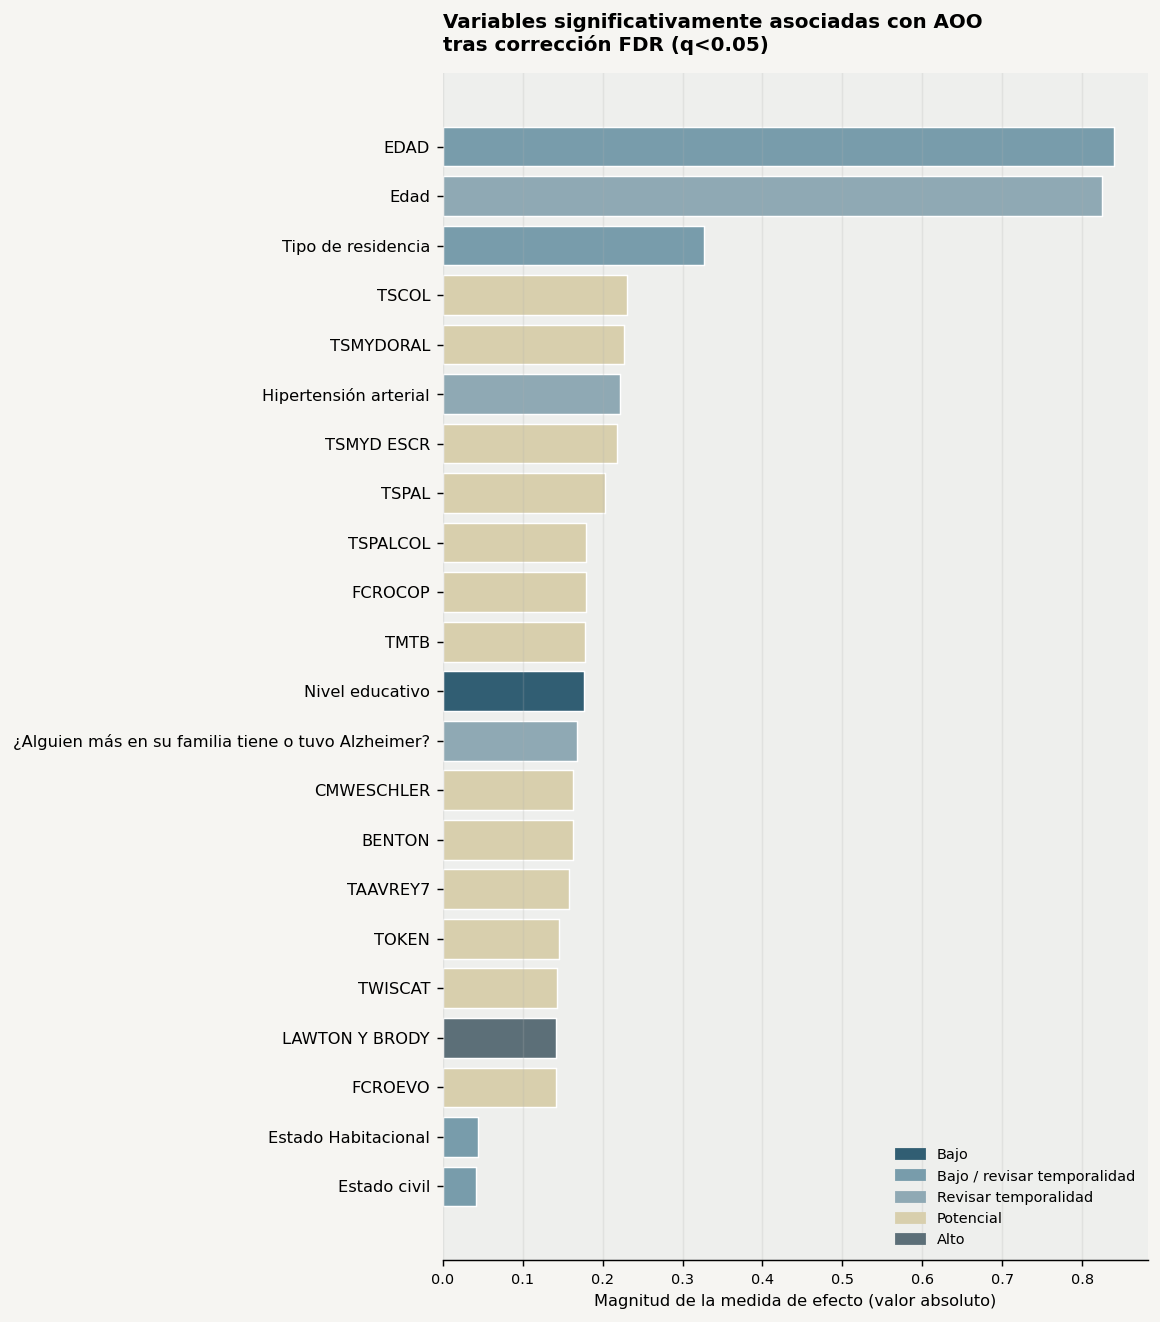

**Color por riesgo de leakage:** los tonos azules representan menor riesgo; los tonos beige/gris indican variables cuya temporalidad o interpretación requiere mayor precaución.

In [177]:
sig = evaluables.loc[evaluables.significativo_fdr_005].copy()
if sig.empty:
    display(Markdown('Ninguna variable resultó significativa tras la corrección por FDR (q<0.05).'))
else:
    sig['efecto_abs'] = sig['medida_efecto'].abs()
    sig = sig.sort_values('efecto_abs')
    sig=evaluables.loc[evaluables.significativo_fdr_005].copy()

if sig.empty:
    display(Markdown("Ninguna variable resultó significativa tras la corrección por FDR (q<0.05)."))
else:
    sig["efecto_abs"]=sig["medida_efecto"].abs()
    sig=sig.sort_values("efecto_abs")

    colores_riesgo={
        "Bajo":BC,
        "Bajo / revisar temporalidad":BC2,
        "Revisar temporalidad":"#8fa9b4",
        "Potencial":BES,
        "Alto":"#5c6f78",
        "Revisar":"#a8b7bd"
    }

    colores=[colores_riesgo.get(r,BC2) for r in sig["riesgo_leakage_aoo"]]

    fig,ax=plt.subplots(
        figsize=(9,max(3.5,.42*len(sig)+1))
    )

    fig.patch.set_facecolor(BFONDO)
    ax.set_facecolor(BPANEL)

    ax.barh(
        sig["variable"],
        sig["efecto_abs"],
        color=colores,
        edgecolor="white",
        linewidth=.8
    )

    ax.set_xlabel("Magnitud de la medida de efecto (valor absoluto)")
    ax.set_title(
        "Variables significativamente asociadas con AOO\ntras corrección FDR (q<0.05)",
        loc="left",
        fontsize=11,
        fontweight="bold",
        pad=12
    )

    ax.grid(axis="x",alpha=.22)
    ax.grid(axis="y",visible=False)
    ax.spines[["top","right","left"]].set_visible(False)

    leyenda=[
        (k,v) for k,v in colores_riesgo.items()
        if k in set(sig["riesgo_leakage_aoo"])
    ]

    handles=[
        plt.Rectangle((0,0),1,1,color=color,label=etiqueta)
        for etiqueta,color in leyenda
    ]

    if handles:
        ax.legend(
            handles=handles,
            frameon=False,
            fontsize=8,
            loc="lower right"
        )

    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Color por riesgo de leakage:** los tonos azules representan menor riesgo; "
        "los tonos beige/gris indican variables cuya temporalidad o interpretación "
        "requiere mayor precaución."
    ))


#### **Hallazgos principales**


In [178]:
hallazgos_consolidados = []
for grupo, etiqueta in [
    ('1. Significativas tras FDR — riesgo Bajo','riesgo bajo'),
    ('2. Significativas tras FDR — requiere revisar temporalidad','temporalidad pendiente'),
    ('3. Significativas tras FDR — riesgo Potencial/Alto','riesgo potencial o alto')]:
    k=int((resumen_fdr_tres_grupos.grupo_metodologico==grupo).sum())
    hallazgos_consolidados.append(f'{k} con {etiqueta}')
display(Markdown(
    f'Después de controlar las comparaciones múltiples permanecieron {int(evaluables.significativo_fdr_005.sum())} asociaciones: '
    + ', '.join(hallazgos_consolidados) + '. La mayor parte de los resultados persistentes no puede trasladarse directamente a un modelo de AOO: requiere validar temporalidad o corresponde a mediciones clínicas contemporáneas. Los intervalos de confianza muestran la precisión de los efectos destacados y deben leerse junto con estas restricciones metodológicas.'))


Después de controlar las comparaciones múltiples permanecieron 22 asociaciones: 1 con riesgo bajo, 7 con temporalidad pendiente, 14 con riesgo potencial o alto. La mayor parte de los resultados persistentes no puede trasladarse directamente a un modelo de AOO: requiere validar temporalidad o corresponde a mediciones clínicas contemporáneas. Los intervalos de confianza muestran la precisión de los efectos destacados y deben leerse junto con estas restricciones metodológicas.

### **22.16. Post hoc condicionado para Kruskal–Wallis**

El post hoc de Dunn se ejecuta únicamente cuando el resultado global es significativo tras FDR, la codificación está validada y la variable es interpretable. Se usa ajuste Holm dentro de cada comparación por pares. Si no se cumplen estas condiciones, no se generan comparaciones que aparenten una interpretación inexistente.


In [179]:
candidatas_dunn = evaluables.loc[
    evaluables.significativo_fdr_005 & evaluables.prueba.str.startswith('Kruskal-Wallis',na=False) &
    evaluables.codificacion_validada.fillna(False)]
if candidatas_dunn.empty:
    display(Markdown('No hay variables que cumplan simultáneamente los tres criterios para ejecutar Dunn.'))
else:
    for fila in candidatas_dunn.itertuples():
        display(Markdown(f'**{fila.variable} — Dunn con ajuste Holm**'))
        display(posthoc_dunn(fila.columna).round(4))


**Estado civil — Dunn con ajuste Holm**

,grupo_1,grupo_2,n_1,n_2,z,p_sin_ajuste,p_ajustado_holm,significativo_005
0,Casado,Separado,143,17,-0.1550,0.8768,1.0000,False
1,Casado,Soltero (nunca casado o matrimonio anulado),143,50,-0.2480,0.8041,1.0000,False
2,Casado,Viudo,143,101,-3.7913,0.0001,0.0009,True
3,Separado,Soltero (nunca casado o matrimonio anulado),17,50,-0.0035,0.9972,1.0000,False
4,Separado,Viudo,17,101,-1.7280,0.0840,0.3359,False
5,Soltero (nunca casado o matrimonio anulado),Viudo,50,101,-2.6141,0.0089,0.0447,True


**Estado Habitacional — Dunn con ajuste Holm**

,grupo_1,grupo_2,n_1,n_2,z,p_sin_ajuste,p_ajustado_holm,significativo_005
0,Vive con otra persona: esposo o pareja,"Vive con otra persona: familiar, amigo o compañero de cuarto",87,107,-2.3763,0.0175,0.2099,False
1,Vive con otra persona: esposo o pareja,"Vive con su cuidador, quien no es su esposo/pareja, familiar o amigo",87,5,0.6040,0.5458,1.0000,False
2,Vive con otra persona: esposo o pareja,Vive con un grupo de personas (familiares o no) en una residencia privada,87,83,-0.3471,0.7286,1.0000,False
3,Vive con otra persona: esposo o pareja,"Vive en una residencia de atención especializada (de asistencia de actividades de la vida diaria, residencia para ad...",87,38,-3.4878,0.0005,0.0073,True
4,Vive con otra persona: esposo o pareja,Vive solo,87,7,0.8264,0.4086,1.0000,False
5,"Vive con otra persona: familiar, amigo o compañero de cuarto","Vive con su cuidador, quien no es su esposo/pareja, familiar o amigo",107,5,1.3569,0.1748,1.0000,False
6,"Vive con otra persona: familiar, amigo o compañero de cuarto",Vive con un grupo de personas (familiares o no) en una residencia privada,107,83,1.9813,0.0476,0.4893,False
7,"Vive con otra persona: familiar, amigo o compañero de cuarto","Vive en una residencia de atención especializada (de asistencia de actividades de la vida diaria, residencia para ad...",107,38,-1.7747,0.0759,0.6835,False
8,"Vive con otra persona: familiar, amigo o compañero de cuarto",Vive solo,107,7,1.7115,0.0870,0.6959,False
9,"Vive con su cuidador, quien no es su esposo/pareja, familiar o amigo",Vive con un grupo de personas (familiares o no) en una residencia privada,5,83,-0.7189,0.4722,1.0000,False


### **22.17. Resumen de hallazgos bivariados y pendientes**

Se caracteriza el conjunto completo de pruebas bivariadas realizadas, sin seleccionar predictores finales ni construir un modelo: esa etapa corresponde a una fase multivariada posterior (para la cual ya están importados `StandardScaler`, `PCA`, `KMeans` y `statsmodels`, aún sin usar), que además deberá incorporar las variables genéticas mencionadas en el objetivo general una vez estén disponibles y merged (Sección 23, discrepancia formal ya documentada en la Sección 3).


In [180]:
resumen_22 = pd.DataFrame([{
    'pacientes_cohorte': len(base_full),
    'AOO_disponible': int(base_full['aoo'].notna().sum()),
    'variables_evaluadas_bivariado': len(tabla_global_bivariado),
    'variables_evaluables': len(evaluables),
    'variables_no_evaluables': len(no_evaluables),
    'significativas_p_crudo_005': int((evaluables.p_valor < .05).sum()),
    'significativas_fdr_005': int(evaluables.significativo_fdr_005.sum())
}])
display(resumen_22)

if no_evaluables.empty:
    display(Markdown('**Variables no evaluables:** ninguna.'))
else:
    display(Markdown('**Variables no evaluables para prueba formal, con motivo:**'))
    display(no_evaluables[['variable', 'familia', 'tipo_analitico', 'motivo']].reset_index(drop=True))

assert len(base_full) == 391 and base_full['id'].is_unique


# Síntesis interpretativa reproducible de los resultados principales.
n_bajo = int((resumen_fdr_tres_grupos.grupo_metodologico == '1. Significativas tras FDR — riesgo Bajo').sum())
n_temporal = int((resumen_fdr_tres_grupos.grupo_metodologico == '2. Significativas tras FDR — requiere revisar temporalidad').sum())
n_leak = int((resumen_fdr_tres_grupos.grupo_metodologico == '3. Significativas tras FDR — riesgo Potencial/Alto').sum())
display(Markdown(
    f'**Lectura final:** de las {int(evaluables.significativo_fdr_005.sum())} asociaciones que sobreviven FDR, '
    f'**{n_bajo}** tienen riesgo Bajo, **{n_temporal}** requieren revisar temporalidad y '
    f'**{n_leak}** tienen riesgo Potencial/Alto. La correlación Edad–AOO (rho≈0.84) se considera '
    'estructuralmente esperable y no evidencia independencia como covariable. Las asociaciones con '
    'códigos no validados continúan rotuladas como preliminares, y las neuropsicológicas describen '
    'covariación contemporánea dentro de la cohorte, no modificadores demostrados de AOO.'))


,pacientes_cohorte,AOO_disponible,variables_evaluadas_bivariado,variables_evaluables,variables_no_evaluables,significativas_p_crudo_005,significativas_fdr_005
0,391,334,121,81,40,28,22


**Variables no evaluables para prueba formal, con motivo:**

,variable,familia,tipo_analitico,motivo
0,mes y año de nacimiento,sociodemograficas,texto libre / alta cardinalidad,Tipo no apto para prueba formal
1,IDIOMA,sociodemograficas,categórica nominal,Menos de 2 categorías con n≥5
2,OTRO IDOMA,sociodemograficas,texto libre / alta cardinalidad,Tipo no apto para prueba formal
3,Lateralidad,sociodemograficas,categórica nominal,Menos de 2 categorías con n≥5
4,Angioplastía/ endarterectomía/ stent,cardiovasculares_cerebrovasculares,categórica nominal,Menos de 2 categorías con n≥5
5,Bypass cardíaco/coronario,cardiovasculares_cerebrovasculares,categórica binaria,Menos de 2 categorías con n≥5
6,Insuficiencia cardíaca congestiva,cardiovasculares_cerebrovasculares,categórica binaria,Menos de 2 categorías con n≥5
7,PARKINSON,neurologicos,categórica binaria,Menos de 2 categorías con n≥5
8,CONVULSIONES,neurologicos,categórica binaria,Menos de 2 categorías con n≥5
9,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),neurologicos,categórica binaria,Menos de 2 categorías con n≥5


**Lectura final:** de las 22 asociaciones que sobreviven FDR, **1** tienen riesgo Bajo, **7** requieren revisar temporalidad y **14** tienen riesgo Potencial/Alto. La correlación Edad–AOO (rho≈0.84) se considera estructuralmente esperable y no evidencia independencia como covariable. Las asociaciones con códigos no validados continúan rotuladas como preliminares, y las neuropsicológicas describen covariación contemporánea dentro de la cohorte, no modificadores demostrados de AOO.